In [1]:
# ============================================================
# MCX COMMODITY RESEARCH — PHASE 0
# BLOCK 1: ENVIRONMENT & UNIVERSE SETUP
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime

# ------------------------------------------------------------
# MCX REPRESENTATIVE UNIVERSE
# ------------------------------------------------------------

MCX_COMMODITIES = {
    "GOLD": "Bullion",
    "SILVER": "Bullion",
    "COPPER": "Base Metal",
    "ALUMINIUM": "Base Metal",
    "ZINC": "Base Metal",
    "LEAD": "Base Metal",
    "NICKEL": "Base Metal",
    "CRUDEOIL": "Energy",
    "NATURALGAS": "Energy",
    "COTTON": "Agriculture",
    "CARDAMOM": "Agriculture",
    "MENTHAOIL": "Agriculture"
}

print("=" * 70)
print("MCX COMMODITY STRATEGY ARCHETYPE RESEARCH")
print("=" * 70)

print(f"\nUniverse size: {len(MCX_COMMODITIES)} commodities\n")

for i, (commodity, sector) in enumerate(MCX_COMMODITIES.items(), 1):
    print(f"{i:2}. {commodity:<15} | {sector}")

print("\n" + "=" * 70)
print("Environment ready.")
print("=" * 70)

MCX COMMODITY STRATEGY ARCHETYPE RESEARCH

Universe size: 12 commodities

 1. GOLD            | Bullion
 2. SILVER          | Bullion
 3. COPPER          | Base Metal
 4. ALUMINIUM       | Base Metal
 5. ZINC            | Base Metal
 6. LEAD            | Base Metal
 7. NICKEL          | Base Metal
 8. CRUDEOIL        | Energy
 9. NATURALGAS      | Energy
10. COTTON          | Agriculture
11. CARDAMOM        | Agriculture
12. MENTHAOIL       | Agriculture

Environment ready.


In [2]:
# ============================================================
# MCX COMMODITY STRATEGY ARCHETYPE RESEARCH
# PHASE 0 — BLOCK 2
# DATA SOURCE / TICKER AVAILABILITY TEST
# ============================================================

# Candidate Yahoo Finance ticker mappings.
# These are TEST candidates only — we will NOT assume they are
# correct until the download results confirm them.

MCX_YF_CANDIDATES = {
    "GOLD": [
        "GOLD",
        "GOLDMCX",
        "GOLDM",
        "GC=F"
    ],
    
    "SILVER": [
        "SILVER",
        "SILVERMCX",
        "SI=F"
    ],
    
    "COPPER": [
        "COPPER",
        "COPPERMCX",
        "HG=F"
    ],
    
    "ALUMINIUM": [
        "ALUMINIUM",
        "ALUMINIUMMCX"
    ],
    
    "ZINC": [
        "ZINC",
        "ZINCMC X"
    ],
    
    "LEAD": [
        "LEAD",
        "LEADMCX"
    ],
    
    "NICKEL": [
        "NICKEL",
        "NICKELMCX"
    ],
    
    "CRUDEOIL": [
        "CRUDEOIL",
        "CRUDEOILMCX",
        "CL=F"
    ],
    
    "NATURALGAS": [
        "NATURALGAS",
        "NATURALGASMCX",
        "NG=F"
    ],
    
    "COTTON": [
        "COTTON",
        "COTTONMCX",
        "CT=F"
    ],
    
    "CARDAMOM": [
        "CARDAMOM",
        "CARDAMOMMCX"
    ],
    
    "MENTHAOIL": [
        "MENTHAOIL",
        "MENTHAOILMCX"
    ]
}


def test_yfinance_ticker(ticker):
    """
    Test whether Yahoo Finance returns usable historical
    OHLC data for a candidate ticker.
    """

    try:
        data = yf.download(
            ticker,
            period="max",
            interval="1d",
            auto_adjust=False,
            progress=False,
            threads=False
        )

        if data is None or data.empty:
            return {
                "Ticker": ticker,
                "Status": "NO DATA",
                "Rows": 0,
                "First Date": None,
                "Last Date": None
            }

        # Handle possible MultiIndex columns
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        data = data.dropna(how="all")

        if data.empty:
            return {
                "Ticker": ticker,
                "Status": "NO VALID DATA",
                "Rows": 0,
                "First Date": None,
                "Last Date": None
            }

        return {
            "Ticker": ticker,
            "Status": "DATA FOUND",
            "Rows": len(data),
            "First Date": data.index.min().date(),
            "Last Date": data.index.max().date()
        }

    except Exception as e:

        return {
            "Ticker": ticker,
            "Status": f"ERROR: {str(e)[:80]}",
            "Rows": 0,
            "First Date": None,
            "Last Date": None
        }


# ------------------------------------------------------------
# RUN TEST
# ------------------------------------------------------------

availability_results = []

print("=" * 90)
print("MCX / YAHOO FINANCE DATA AVAILABILITY TEST")
print("=" * 90)

for commodity, candidates in MCX_YF_CANDIDATES.items():

    print(f"\n{'-' * 90}")
    print(f"{commodity}")

    for ticker in candidates:

        result = test_yfinance_ticker(ticker)

        result["Commodity"] = commodity

        availability_results.append(result)

        print(
            f"  {ticker:<18} | "
            f"{result['Status']:<20} | "
            f"Rows: {result['Rows']:<8} | "
            f"{result['First Date']} → {result['Last Date']}"
        )


# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

availability_df = pd.DataFrame(availability_results)

availability_df = availability_df[
    [
        "Commodity",
        "Ticker",
        "Status",
        "Rows",
        "First Date",
        "Last Date"
    ]
]

print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

display(availability_df)

MCX / YAHOO FINANCE DATA AVAILABILITY TEST

------------------------------------------------------------------------------------------
GOLD
  GOLD               | DATA FOUND           | Rows: 3138     | 2014-03-17 → 2026-09-04


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GOLDMCX"}}}
$GOLDMCX: possibly delisted; no timezone found

1 Failed download:
['GOLDMCX']: possibly delisted; no timezone found


  GOLDMCX            | NO DATA              | Rows: 0        | None → None


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GOLDM"}}}
$GOLDM: possibly delisted; no timezone found

1 Failed download:
['GOLDM']: possibly delisted; no timezone found


  GOLDM              | NO DATA              | Rows: 0        | None → None
  GC=F               | DATA FOUND           | Rows: 6528     | 2000-08-30 → 2026-09-04

------------------------------------------------------------------------------------------
SILVER


...

$MENTHAOIL: possibly delisted; no timezone found

1 Failed download:
['MENTHAOIL']: possibly delisted; no timezone found


  MENTHAOIL          | NO DATA              | Rows: 0        | None → None


$MENTHAOILMCX: possibly delisted; no timezone found

1 Failed download:
['MENTHAOILMCX']: possibly delisted; no timezone found


  MENTHAOILMCX       | NO DATA              | Rows: 0        | None → None

SUMMARY


,Commodity,Ticker,Status,Rows,First Date,Last Date
0,GOLD,GOLD,DATA FOUND,3138,2014-03-17,2026-09-04
1,GOLD,GOLDMCX,NO DATA,0,None,None
2,GOLD,GOLDM,NO DATA,0,None,None
3,GOLD,GC=F,DATA FOUND,6528,2000-08-30,2026-09-04
4,SILVER,SILVER,NO DATA,0,None,None
5,SILVER,SILVERMCX,NO DATA,0,None,None
6,SILVER,SI=F,DATA FOUND,6530,2000-08-30,2026-09-04
7,COPPER,COPPER,NO DATA,0,None,None
8,COPPER,COPPERMCX,NO DATA,0,None,None
9,COPPER,HG=F,DATA FOUND,6533,2000-08-30,2026-09-04


In [3]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 0 — BLOCK 2
# HISTORICAL DATA DOWNLOAD & QUALITY AUDIT
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf

# ------------------------------------------------------------
# COMMODITY UNIVERSE
# ------------------------------------------------------------

COMMODITY_FUTURES = {
    "GOLD": "GC=F",
    "SILVER": "SI=F",
    "COPPER": "HG=F",
    "CRUDE_OIL": "CL=F",
    "NATURAL_GAS": "NG=F"
}

START_DATE = "2000-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")


# ------------------------------------------------------------
# DATA STORAGE
# ------------------------------------------------------------

commodity_data = {}
audit_results = []


# ------------------------------------------------------------
# DOWNLOAD FUNCTION
# ------------------------------------------------------------

def download_commodity_data(name, ticker):

    print(f"\n{'=' * 75}")
    print(f"Downloading: {name} ({ticker})")
    print(f"{'=' * 75}")

    try:

        data = yf.download(
            ticker,
            start=START_DATE,
            end=END_DATE,
            interval="1d",
            auto_adjust=False,
            progress=False,
            threads=False
        )

        if data is None or data.empty:
            print("❌ No data returned.")
            return None

        # ----------------------------------------------------
        # HANDLE MULTIINDEX COLUMNS
        # ----------------------------------------------------

        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        # ----------------------------------------------------
        # STANDARDIZE COLUMN NAMES
        # ----------------------------------------------------

        data.columns = [str(col).strip().title() for col in data.columns]

        # ----------------------------------------------------
        # KEEP STANDARD OHLCV FIELDS
        # ----------------------------------------------------

        required_columns = [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]

        available_columns = [
            col for col in required_columns
            if col in data.columns
        ]

        data = data[available_columns].copy()

        # ----------------------------------------------------
        # DATE CLEANING
        # ----------------------------------------------------

        data.index = pd.to_datetime(data.index)

        # Remove timezone if present
        if getattr(data.index, "tz", None) is not None:
            data.index = data.index.tz_localize(None)

        data = data.sort_index()

        # ----------------------------------------------------
        # REMOVE DUPLICATE DATES
        # ----------------------------------------------------

        duplicate_count = data.index.duplicated().sum()

        if duplicate_count > 0:
            data = data[~data.index.duplicated(keep="first")]

        # ----------------------------------------------------
        # REMOVE COMPLETELY EMPTY ROWS
        # ----------------------------------------------------

        data = data.dropna(how="all")

        # ----------------------------------------------------
        # PRICE VALIDATION
        # ----------------------------------------------------

        if "Close" not in data.columns:
            print("❌ Close price unavailable.")
            return None

        # Invalid/non-positive prices
        invalid_price_count = (
            data["Close"].notna() &
            (data["Close"] <= 0)
        ).sum()

        # ----------------------------------------------------
        # DAILY RETURNS
        # ----------------------------------------------------

        data["Daily_Return"] = data["Close"].pct_change() * 100

        # ----------------------------------------------------
        # BASIC STATISTICS
        # ----------------------------------------------------

        first_date = data.index.min()
        last_date = data.index.max()

        total_rows = len(data)

        years_available = (
            (last_date - first_date).days / 365.25
        )

        # Missingness
        missing_open = (
            data["Open"].isna().mean() * 100
            if "Open" in data.columns else np.nan
        )

        missing_high = (
            data["High"].isna().mean() * 100
            if "High" in data.columns else np.nan
        )

        missing_low = (
            data["Low"].isna().mean() * 100
            if "Low" in data.columns else np.nan
        )

        missing_close = (
            data["Close"].isna().mean() * 100
        )

        missing_volume = (
            data["Volume"].isna().mean() * 100
            if "Volume" in data.columns else np.nan
        )

        # Daily return statistics
        returns = data["Daily_Return"].dropna()

        if len(returns) > 0:

            largest_daily_gain = returns.max()
            largest_daily_loss = returns.min()

            median_daily_return = returns.median()
            mean_daily_return = returns.mean()

            daily_volatility = returns.std()

        else:

            largest_daily_gain = np.nan
            largest_daily_loss = np.nan
            median_daily_return = np.nan
            mean_daily_return = np.nan
            daily_volatility = np.nan

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        commodity_data[name] = data

        # ----------------------------------------------------
        # AUDIT RECORD
        # ----------------------------------------------------

        audit_results.append({
            "Commodity": name,
            "Ticker": ticker,
            "First Date": first_date.date(),
            "Last Date": last_date.date(),
            "Rows": total_rows,
            "Years": round(years_available, 2),
            "Duplicate Dates Removed": int(duplicate_count),
            "Invalid Prices": int(invalid_price_count),
            "Missing Open %": round(missing_open, 3),
            "Missing High %": round(missing_high, 3),
            "Missing Low %": round(missing_low, 3),
            "Missing Close %": round(missing_close, 3),
            "Missing Volume %": round(missing_volume, 3),
            "Mean Daily Return %": round(mean_daily_return, 4),
            "Median Daily Return %": round(median_daily_return, 4),
            "Daily Volatility %": round(daily_volatility, 4),
            "Largest Daily Gain %": round(largest_daily_gain, 2),
            "Largest Daily Loss %": round(largest_daily_loss, 2)
        })

        print(f"✅ Rows:       {total_rows:,}")
        print(f"✅ Period:     {first_date.date()} → {last_date.date()}")
        print(f"✅ Years:      {years_available:.2f}")
        print(f"✅ Duplicates: {duplicate_count}")
        print(f"✅ Invalid Px: {invalid_price_count}")

        return data

    except Exception as e:

        print(f"❌ ERROR: {e}")
        return None


# ------------------------------------------------------------
# DOWNLOAD ALL COMMODITIES
# ------------------------------------------------------------

for commodity, ticker in COMMODITY_FUTURES.items():

    download_commodity_data(
        commodity,
        ticker
    )


# ------------------------------------------------------------
# CREATE AUDIT TABLE
# ------------------------------------------------------------

audit_df = pd.DataFrame(audit_results)


# ------------------------------------------------------------
# DISPLAY AUDIT
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("COMMODITY DATA QUALITY AUDIT")
print("=" * 120)

display(audit_df)


# ------------------------------------------------------------
# DATASET SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("DATASET SUMMARY")
print("=" * 120)

print(f"Commodities requested : {len(COMMODITY_FUTURES)}")
print(f"Commodities downloaded: {len(commodity_data)}")

if len(audit_df) > 0:

    print(
        f"Total observations    : "
        f"{audit_df['Rows'].sum():,}"
    )

    print(
        f"Earliest start        : "
        f"{audit_df['First Date'].min()}"
    )

    print(
        f"Latest date           : "
        f"{audit_df['Last Date'].max()}"
    )


# ------------------------------------------------------------
# AVAILABLE DATASETS
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("DATASETS STORED IN MEMORY")
print("=" * 120)

for name, data in commodity_data.items():

    print(
        f"{name:<15} "
        f"| {len(data):>6,} rows "
        f"| {data.index.min().date()} → {data.index.max().date()}"
    )


Downloading: GOLD (GC=F)
✅ Rows:       6,528
✅ Period:     2000-08-30 → 2026-09-04
✅ Years:      26.01
✅ Duplicates: 0
✅ Invalid Px: 0

Downloading: SILVER (SI=F)
✅ Rows:       6,530
✅ Period:     2000-08-30 → 2026-09-04
✅ Years:      26.01
✅ Duplicates: 0
✅ Invalid Px: 0

Downloading: COPPER (HG=F)
✅ Rows:       6,533
✅ Period:     2000-08-30 → 2026-09-04
✅ Years:      26.01
✅ Duplicates: 0
✅ Invalid Px: 0

Downloading: CRUDE_OIL (CL=F)
✅ Rows:       6,537
✅ Period:     2000-08-23 → 2026-09-04
✅ Years:      26.03
✅ Duplicates: 0
✅ Invalid Px: 1

Downloading: NATURAL_GAS (NG=F)
✅ Rows:       6,534
✅ Period:     2000-08-30 → 2026-09-04
✅ Years:      26.01
✅ Duplicates: 0
✅ Invalid Px: 0


COMMODITY DATA QUALITY AUDIT


,Commodity,Ticker,First Date,Last Date,Rows,Years,Duplicate Dates Removed,Invalid Prices,Missing Open %,Missing High %,Missing Low %,Missing Close %,Missing Volume %,Mean Daily Return %,Median Daily Return %,Daily Volatility %,Largest Daily Gain %,Largest Daily Loss %
0,GOLD,GC=F,2000-08-30,2026-09-04,6528,26.01,0,0,0.0,0.0,0.0,0.0,0.0,0.0490,0.0503,1.1268,9.03,-11.37
1,SILVER,SI=F,2000-08-30,2026-09-04,6530,26.01,0,0,0.0,0.0,0.0,0.0,0.0,0.0619,0.1039,2.0858,14.03,-31.35
2,COPPER,HG=F,2000-08-30,2026-09-04,6533,26.01,0,0,0.0,0.0,0.0,0.0,0.0,0.0455,0.0273,1.7138,13.25,-22.25
3,CRUDE_OIL,CL=F,2000-08-23,2026-09-04,6537,26.03,0,1,0.0,0.0,0.0,0.0,0.0,-0.0064,0.1087,4.8708,37.66,-305.97
4,NATURAL_GAS,NG=F,2000-08-30,2026-09-04,6534,26.01,0,0,0.0,0.0,0.0,0.0,0.0,0.0666,-0.0313,3.8553,46.48,-47.48




DATASET SUMMARY
Commodities requested : 5
Commodities downloaded: 5
Total observations    : 32,662
Earliest start        : 2000-08-23
Latest date           : 2026-09-04


DATASETS STORED IN MEMORY
GOLD            |  6,528 rows | 2000-08-30 → 2026-09-04
SILVER          |  6,530 rows | 2000-08-30 → 2026-09-04
COPPER          |  6,533 rows | 2000-08-30 → 2026-09-04
CRUDE_OIL       |  6,537 rows | 2000-08-23 → 2026-09-04
NATURAL_GAS     |  6,534 rows | 2000-08-30 → 2026-09-04


In [4]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 0 — BLOCK 3
# FUTURES PRICE INTEGRITY & EXTREME-EVENT AUDIT
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# EXTREME RETURN THRESHOLD
# ------------------------------------------------------------

EXTREME_RETURN_THRESHOLD = 10.0   # ±10% daily move


# ------------------------------------------------------------
# AUDIT STORAGE
# ------------------------------------------------------------

extreme_events = []
price_integrity = []


# ------------------------------------------------------------
# RUN AUDIT FOR EACH COMMODITY
# ------------------------------------------------------------

for commodity, data in commodity_data.items():

    df = data.copy()

    # --------------------------------------------------------
    # PRICE CONDITIONS
    # --------------------------------------------------------

    non_positive_close = df[
        df["Close"] <= 0
    ].copy()

    zero_close = df[
        df["Close"] == 0
    ].copy()

    negative_close = df[
        df["Close"] < 0
    ].copy()

    # --------------------------------------------------------
    # OHLC CONSISTENCY
    # --------------------------------------------------------

    if all(
        col in df.columns
        for col in ["Open", "High", "Low", "Close"]
    ):

        invalid_ohlc = df[
            (df["High"] < df["Low"]) |
            (df["High"] < df["Open"]) |
            (df["High"] < df["Close"]) |
            (df["Low"] > df["Open"]) |
            (df["Low"] > df["Close"])
        ].copy()

    else:

        invalid_ohlc = pd.DataFrame()

    # --------------------------------------------------------
    # EXTREME DAILY RETURNS
    # --------------------------------------------------------

    extreme = df[
        df["Daily_Return"].abs() >= EXTREME_RETURN_THRESHOLD
    ].copy()

    # --------------------------------------------------------
    # STORE EXTREME EVENTS
    # --------------------------------------------------------

    for date, row in extreme.iterrows():

        extreme_events.append({
            "Commodity": commodity,
            "Date": date.date(),
            "Close": row["Close"],
            "Daily Return %": row["Daily_Return"],
            "Volume": row["Volume"]
            if "Volume" in df.columns else np.nan
        })

    # --------------------------------------------------------
    # PRICE INTEGRITY SUMMARY
    # --------------------------------------------------------

    price_integrity.append({
        "Commodity": commodity,
        "Rows": len(df),
        "Zero Prices": len(zero_close),
        "Negative Prices": len(negative_close),
        "Non-Positive Prices": len(non_positive_close),
        "Invalid OHLC Rows": len(invalid_ohlc),
        "Extreme Return Events": len(extreme),
        "Minimum Close": df["Close"].min(),
        "Maximum Close": df["Close"].max(),
        "Minimum Daily Return %": df["Daily_Return"].min(),
        "Maximum Daily Return %": df["Daily_Return"].max()
    })


# ------------------------------------------------------------
# PRICE INTEGRITY TABLE
# ------------------------------------------------------------

integrity_df = pd.DataFrame(price_integrity)

print("=" * 120)
print("PRICE INTEGRITY SUMMARY")
print("=" * 120)

display(integrity_df)


# ------------------------------------------------------------
# EXTREME EVENT TABLE
# ------------------------------------------------------------

extreme_df = pd.DataFrame(extreme_events)

if not extreme_df.empty:

    extreme_df = extreme_df.sort_values(
        by="Daily Return %",
        key=lambda x: x.abs(),
        ascending=False
    )

    print("\n")
    print("=" * 120)
    print("EXTREME DAILY RETURN EVENTS (±10%)")
    print("=" * 120)

    display(extreme_df.head(100))

else:

    print("\nNo extreme daily return events detected.")


# ------------------------------------------------------------
# CRUDE OIL — APRIL 2020 EVENT
# ------------------------------------------------------------

if "CRUDE_OIL" in commodity_data:

    crude = commodity_data["CRUDE_OIL"].copy()

    crude_2020 = crude.loc[
        "2020-04-01":"2020-04-30"
    ].copy()

    print("\n")
    print("=" * 120)
    print("CRUDE OIL — APRIL 2020")
    print("=" * 120)

    display(crude_2020)


# ------------------------------------------------------------
# ALL NON-POSITIVE PRICES
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("NON-POSITIVE CLOSE PRICES")
print("=" * 120)

found_non_positive = False

for commodity, data in commodity_data.items():

    bad_prices = data[
        data["Close"] <= 0
    ].copy()

    if not bad_prices.empty:

        found_non_positive = True

        print(f"\n{commodity}")

        display(
            bad_prices[
                [
                    col for col in
                    ["Open", "High", "Low", "Close", "Volume", "Daily_Return"]
                    if col in bad_prices.columns
                ]
            ]
        )

if not found_non_positive:

    print("No non-positive closing prices found.")

PRICE INTEGRITY SUMMARY


,Commodity,Rows,Zero Prices,Negative Prices,Non-Positive Prices,Invalid OHLC Rows,Extreme Return Events,Minimum Close,Maximum Close,Minimum Daily Return %,Maximum Daily Return %
0,GOLD,6528,0,0,0,441,1,255.100006,5318.399902,-11.366201,9.027685
1,SILVER,6530,0,0,0,243,17,4.026000,115.080002,-31.346844,14.025265
2,COPPER,6533,0,0,0,300,6,0.604000,6.709500,-22.253142,13.251080
3,CRUDE_OIL,6537,0,1,1,7,47,-37.630001,145.289993,-305.966065,37.662332
4,NATURAL_GAS,6534,0,0,0,32,134,1.482000,15.378000,-47.479893,46.481177




EXTREME DAILY RETURN EVENTS (±10%)


,Commodity,Date,Close,Daily Return %,Volume
55,CRUDE_OIL,2020-04-20,-37.630001,-305.966065,247947.0
56,CRUDE_OIL,2020-04-21,10.010000,-126.601116,2288230.0
202,NATURAL_GAS,2026-01-29,3.918000,-47.479893,234642.0
157,NATURAL_GAS,2022-01-27,6.265000,46.481177,193252.0
89,NATURAL_GAS,2003-02-24,9.137000,38.229953,55081.0
...,...,...,...,...,...
186,NATURAL_GAS,2024-09-27,2.902000,12.263053,224258.0
35,CRUDE_OIL,2009-01-07,42.630001,-12.247840,306262.0
87,NATURAL_GAS,2001-12-27,2.555000,-12.229473,47782.0
65,CRUDE_OIL,2026-03-06,90.900002,12.208368,996251.0




CRUDE OIL — APRIL 2020


,Open,High,Low,Close,Volume,Daily_Return
Date,,,,,,
2020-04-01,20.100000,21.549999,19.900000,20.309999,703286,-0.830079
2020-04-02,21.219999,27.389999,20.760000,25.320000,1095972,24.667653
2020-04-03,24.809999,29.129999,23.520000,28.340000,1007577,11.927332
2020-04-06,26.090000,28.240000,25.280001,26.080000,752710,-7.974595
2020-04-07,26.340000,27.240000,23.540001,23.629999,797707,-9.394175
2020-04-08,24.299999,26.450001,23.740000,25.090000,823554,6.178591
2020-04-09,26.280001,28.360001,22.570000,22.760000,1122149,-9.286568
2020-04-13,24.600000,24.740000,22.030001,22.410000,775120,-1.537787
2020-04-14,22.360001,23.080000,19.950001,20.110001,785478,-10.263272




NON-POSITIVE CLOSE PRICES

CRUDE_OIL


,Open,High,Low,Close,Volume,Daily_Return
Date,,,,,,
2020-04-20,17.73,17.85,-40.32,-37.630001,247947,-305.966065


In [5]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 0 — BLOCK 4
# BACKTEST DATASET PREPARATION & RETURN INTEGRITY
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

strategy_data = {}
return_audit = []


# ------------------------------------------------------------
# PROCESS EACH COMMODITY
# ------------------------------------------------------------

for commodity, raw_data in commodity_data.items():

    df = raw_data.copy()

    # --------------------------------------------------------
    # PRESERVE RAW PRICE DATA
    # --------------------------------------------------------

    df["Raw_Close"] = df["Close"]

    # --------------------------------------------------------
    # VALID POSITIVE-PRICE MASK
    # --------------------------------------------------------

    positive_price = df["Close"] > 0

    # --------------------------------------------------------
    # STANDARD PERCENTAGE RETURN
    #
    # Only calculate when BOTH today's and yesterday's
    # closing prices are positive.
    # --------------------------------------------------------

    valid_pct_return = (
        positive_price &
        positive_price.shift(1)
    )

    df["Pct_Return"] = np.nan

    df.loc[valid_pct_return, "Pct_Return"] = (
        df.loc[valid_pct_return, "Close"]
        .pct_change()
    )

    # --------------------------------------------------------
    # LOG RETURN
    #
    # Only mathematically valid for positive prices.
    # --------------------------------------------------------

    df["Log_Return"] = np.nan

    df.loc[valid_pct_return, "Log_Return"] = (
        np.log(
            df.loc[valid_pct_return, "Close"] /
            df["Close"].shift(1).loc[valid_pct_return]
        )
    )

    # --------------------------------------------------------
    # EXTREME VALID RETURNS
    # --------------------------------------------------------

    valid_returns = df["Pct_Return"].dropna()

    extreme_10 = (
        valid_returns.abs() >= 0.10
    ).sum()

    extreme_20 = (
        valid_returns.abs() >= 0.20
    ).sum()

    extreme_50 = (
        valid_returns.abs() >= 0.50
    ).sum()

    # --------------------------------------------------------
    # INVALID RETURN OBSERVATIONS
    # --------------------------------------------------------

    invalid_return_count = (
        df["Pct_Return"].isna()
    ).sum()

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    strategy_data[commodity] = df

    # --------------------------------------------------------
    # AUDIT
    # --------------------------------------------------------

    return_audit.append({
        "Commodity": commodity,
        "Total Rows": len(df),
        "Valid % Returns": int(df["Pct_Return"].notna().sum()),
        "Invalid % Returns": int(df["Pct_Return"].isna().sum()),
        "Valid Log Returns": int(df["Log_Return"].notna().sum()),
        "≥10% Moves": int(extreme_10),
        "≥20% Moves": int(extreme_20),
        "≥50% Moves": int(extreme_50),
        "Max Valid Return %": round(
            valid_returns.max() * 100, 2
        ) if len(valid_returns) else np.nan,
        "Min Valid Return %": round(
            valid_returns.min() * 100, 2
        ) if len(valid_returns) else np.nan
    })


# ------------------------------------------------------------
# AUDIT TABLE
# ------------------------------------------------------------

return_audit_df = pd.DataFrame(return_audit)


print("=" * 120)
print("RETURN INTEGRITY AUDIT")
print("=" * 120)

display(return_audit_df)


# ------------------------------------------------------------
# EXPLICIT CRUDE-OIL CHECK
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("CRUDE OIL — RETURN TRANSITION CHECK")
print("=" * 120)

if "CRUDE_OIL" in strategy_data:

    crude_check = strategy_data["CRUDE_OIL"].loc[
        "2020-04-17":"2020-04-23",
        [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume",
            "Raw_Close",
            "Pct_Return",
            "Log_Return"
        ]
    ]

    display(crude_check)


# ------------------------------------------------------------
# VERIFY RAW DATA PRESERVATION
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("RAW DATA PRESERVATION CHECK")
print("=" * 120)

for commodity, df in strategy_data.items():

    raw_negative = (
        df["Raw_Close"] <= 0
    ).sum()

    print(
        f"{commodity:<15} | "
        f"Rows: {len(df):>6,} | "
        f"Non-positive raw closes: {raw_negative}"
    )


# ------------------------------------------------------------
# DATASET OBJECT SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 120)
print("STRATEGY DATASETS READY")
print("=" * 120)

for commodity, df in strategy_data.items():

    print(
        f"{commodity:<15} | "
        f"{len(df):>6,} rows | "
        f"{df.index.min().date()} → "
        f"{df.index.max().date()}"
    )

RETURN INTEGRITY AUDIT


,Commodity,Total Rows,Valid % Returns,Invalid % Returns,Valid Log Returns,≥10% Moves,≥20% Moves,≥50% Moves,Max Valid Return %,Min Valid Return %
0,GOLD,6528,6526,2,6527,1,0,0,9.03,-11.37
1,SILVER,6530,6528,2,6529,17,1,0,14.03,-31.35
2,COPPER,6533,6531,2,6532,6,1,0,13.25,-22.25
3,CRUDE_OIL,6537,6533,4,6534,45,9,0,25.10,-24.59
4,NATURAL_GAS,6534,6532,2,6533,134,15,0,46.48,-47.48




CRUDE OIL — RETURN TRANSITION CHECK


,Open,High,Low,Close,Volume,Raw_Close,Pct_Return,Log_Return
Date,,,,,,,,
2020-04-17,20.00,20.219999,17.309999,18.270000,240628,18.270000,-0.080523,-0.083951
2020-04-20,17.73,17.850000,-40.320000,-37.630001,247947,-37.630001,NaN,NaN
2020-04-21,-14.00,13.860000,-16.740000,10.010000,2288230,10.010000,NaN,NaN
2020-04-22,13.12,16.180000,10.260000,13.780000,1235218,13.780000,-0.245758,0.319634
2020-04-23,14.20,18.260000,13.350000,16.500000,833584,16.500000,0.197388,0.180142




RAW DATA PRESERVATION CHECK
GOLD            | Rows:  6,528 | Non-positive raw closes: 0
SILVER          | Rows:  6,530 | Non-positive raw closes: 0
COPPER          | Rows:  6,533 | Non-positive raw closes: 0
CRUDE_OIL       | Rows:  6,537 | Non-positive raw closes: 1
NATURAL_GAS     | Rows:  6,534 | Non-positive raw closes: 0


STRATEGY DATASETS READY
GOLD            |  6,528 rows | 2000-08-30 → 2026-09-04
SILVER          |  6,530 rows | 2000-08-30 → 2026-09-04
COPPER          |  6,533 rows | 2000-08-30 → 2026-09-04
CRUDE_OIL       |  6,537 rows | 2000-08-23 → 2026-09-04
NATURAL_GAS     |  6,534 rows | 2000-08-30 → 2026-09-04


CROSS-COMMODITY CALENDAR AUDIT


,Commodity,Observations,First Date,Last Date,Median Calendar Gap,Maximum Calendar Gap,Gaps > 7 Days,Gaps > 14 Days,Gaps > 30 Days
0,GOLD,6528,2000-08-30,2026-09-04,1.0,5,0,0,0
1,SILVER,6530,2000-08-30,2026-09-04,1.0,5,0,0,0
2,COPPER,6533,2000-08-30,2026-09-04,1.0,5,0,0,0
3,CRUDE_OIL,6537,2000-08-23,2026-09-04,1.0,5,0,0,0
4,NATURAL_GAS,6534,2000-08-30,2026-09-04,1.0,5,0,0,0




COMMON SAMPLE PERIOD
Earliest common date : 2000-08-30
Latest common date   : 2026-09-04
Common sample years  : 26.01


COMMON-SAMPLE OBSERVATIONS


,Commodity,Common-Sample Rows
0,GOLD,6528
1,SILVER,6530
2,COPPER,6533
3,CRUDE_OIL,6532
4,NATURAL_GAS,6534


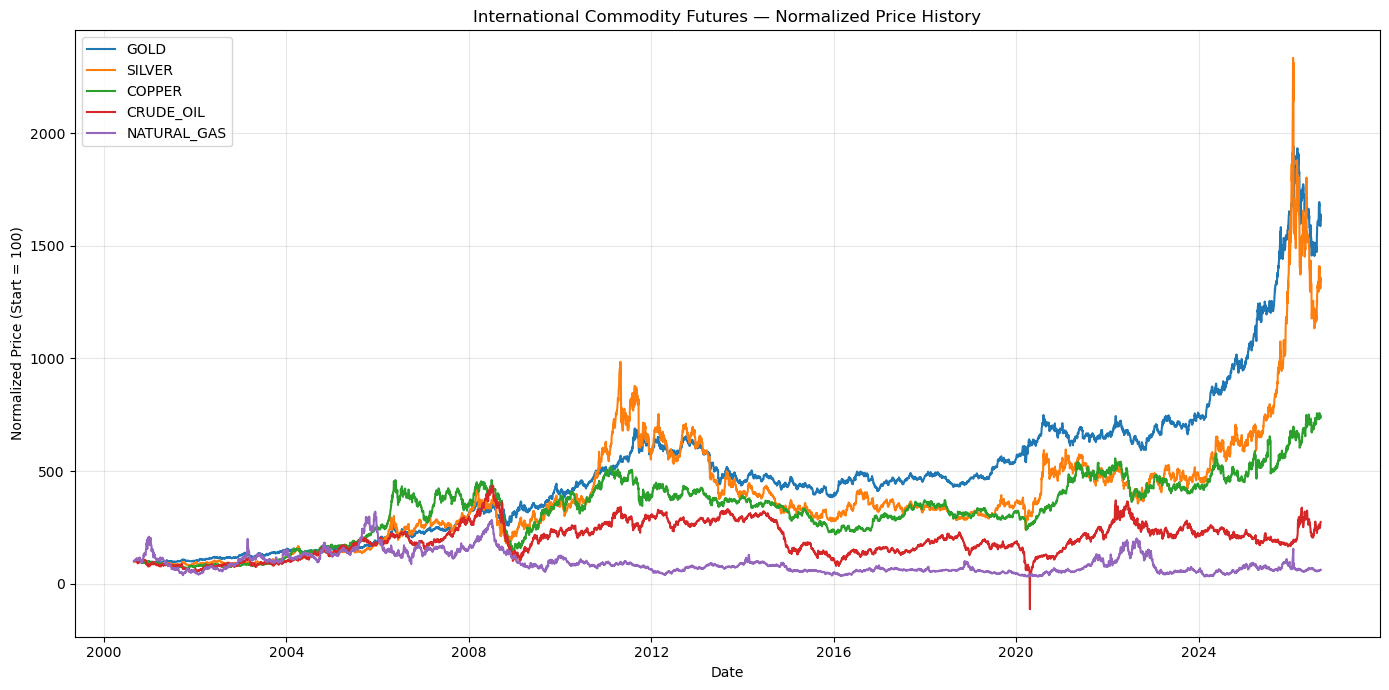



DAILY RETURN DISTRIBUTION AUDIT


,Commodity,Mean Return %,Median Return %,Std Dev %,Min Return %,Max Return %,10th Percentile %,90th Percentile %,1st Percentile %,99th Percentile %
0,GOLD,0.0488,0.0501,1.1267,-11.37,9.03,-1.21,1.29,-3.12,2.88
1,SILVER,0.0616,0.1038,2.0859,-31.35,14.03,-2.08,2.22,-6.01,5.61
2,COPPER,0.0455,0.0276,1.7139,-22.25,13.25,-1.79,1.98,-4.72,4.52
3,CRUDE_OIL,0.0505,0.1089,2.6121,-24.59,25.10,-2.72,2.75,-6.99,6.60
4,NATURAL_GAS,0.0666,-0.0312,3.8556,-47.48,46.48,-4.03,4.21,-9.01,10.77




FINAL PHASE 0 DATA CHECK
GOLD            | READY
SILVER          | READY
COPPER          | READY
CRUDE_OIL       | READY
NATURAL_GAS     | READY


In [6]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 0 — BLOCK 5
# CROSS-COMMODITY CALENDAR & VISUAL AUDIT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. CALENDAR / OBSERVATION AUDIT
# ------------------------------------------------------------

calendar_audit = []

for commodity, df in strategy_data.items():

    dates = pd.DatetimeIndex(df.index)

    # Differences between consecutive observations
    date_gaps = dates.to_series().diff().dt.days.dropna()

    calendar_audit.append({
        "Commodity": commodity,
        "Observations": len(df),
        "First Date": dates.min().date(),
        "Last Date": dates.max().date(),
        "Median Calendar Gap": round(date_gaps.median(), 1),
        "Maximum Calendar Gap": int(date_gaps.max()),
        "Gaps > 7 Days": int((date_gaps > 7).sum()),
        "Gaps > 14 Days": int((date_gaps > 14).sum()),
        "Gaps > 30 Days": int((date_gaps > 30).sum())
    })


calendar_df = pd.DataFrame(calendar_audit)

print("=" * 110)
print("CROSS-COMMODITY CALENDAR AUDIT")
print("=" * 110)

display(calendar_df)


# ------------------------------------------------------------
# 2. COMMON DATE RANGE
# ------------------------------------------------------------

common_start = max(
    df.index.min()
    for df in strategy_data.values()
)

common_end = min(
    df.index.max()
    for df in strategy_data.values()
)

print("\n")
print("=" * 110)
print("COMMON SAMPLE PERIOD")
print("=" * 110)

print(f"Earliest common date : {common_start.date()}")
print(f"Latest common date   : {common_end.date()}")

common_years = (
    (common_end - common_start).days / 365.25
)

print(f"Common sample years  : {common_years:.2f}")


# ------------------------------------------------------------
# 3. COMMON-SAMPLE OBSERVATION COUNTS
# ------------------------------------------------------------

common_counts = []

for commodity, df in strategy_data.items():

    common_df = df.loc[
        common_start:common_end
    ]

    common_counts.append({
        "Commodity": commodity,
        "Common-Sample Rows": len(common_df)
    })


common_counts_df = pd.DataFrame(common_counts)

print("\n")
print("=" * 110)
print("COMMON-SAMPLE OBSERVATIONS")
print("=" * 110)

display(common_counts_df)


# ------------------------------------------------------------
# 4. NORMALIZED PRICE PERFORMANCE
# ------------------------------------------------------------
#
# This is NOT a strategy equity curve.
#
# Every commodity starts at 100 so we can visually compare
# long-term price behavior.
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for commodity, df in strategy_data.items():

    common_df = df.loc[
        common_start:common_end
    ].copy()

    normalized_price = (
        common_df["Close"] /
        common_df["Close"].iloc[0]
    ) * 100

    plt.plot(
        normalized_price.index,
        normalized_price,
        label=commodity
    )

plt.title(
    "International Commodity Futures — Normalized Price History"
)

plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. DAILY RETURN DISTRIBUTION SUMMARY
# ------------------------------------------------------------

distribution_audit = []

for commodity, df in strategy_data.items():

    returns = df["Pct_Return"].dropna()

    distribution_audit.append({
        "Commodity": commodity,
        "Mean Return %": round(returns.mean() * 100, 4),
        "Median Return %": round(returns.median() * 100, 4),
        "Std Dev %": round(returns.std() * 100, 4),
        "Min Return %": round(returns.min() * 100, 2),
        "Max Return %": round(returns.max() * 100, 2),
        "10th Percentile %": round(
            returns.quantile(0.10) * 100, 2
        ),
        "90th Percentile %": round(
            returns.quantile(0.90) * 100, 2
        ),
        "1st Percentile %": round(
            returns.quantile(0.01) * 100, 2
        ),
        "99th Percentile %": round(
            returns.quantile(0.99) * 100, 2
        )
    })


distribution_df = pd.DataFrame(distribution_audit)

print("\n")
print("=" * 110)
print("DAILY RETURN DISTRIBUTION AUDIT")
print("=" * 110)

display(distribution_df)


# ------------------------------------------------------------
# 6. FINAL DATASET CHECK
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("FINAL PHASE 0 DATA CHECK")
print("=" * 110)

for commodity, df in strategy_data.items():

    required = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Pct_Return",
        "Log_Return"
    ]

    missing_columns = [
        col for col in required
        if col not in df.columns
    ]

    if not missing_columns:
        status = "READY"
    else:
        status = f"MISSING: {missing_columns}"

    print(
        f"{commodity:<15} | {status}"
    )

In [7]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 1 — BLOCK 6
# STRATEGY ENGINE ADAPTER & MACD VALIDATION
# ============================================================

from abc import ABC, abstractmethod
from tqdm import tqdm
import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE COMMODITY DATA FOR STRATEGY ENGINE
# ============================================================

strategy_engine_data = {}

for commodity, df in strategy_data.items():

    temp = df.copy()

    # --------------------------------------------------------
    # Strategy engine expects a "Price" column
    # --------------------------------------------------------

    temp["Price"] = temp["Close"]

    # --------------------------------------------------------
    # Prevent non-positive prices from generating technical
    # indicator values.
    #
    # Raw Close remains untouched.
    # --------------------------------------------------------

    temp.loc[
        temp["Price"] <= 0,
        "Price"
    ] = np.nan

    strategy_engine_data[commodity] = temp


print("=" * 100)
print("COMMODITY STRATEGY ENGINE DATA")
print("=" * 100)

for commodity, df in strategy_engine_data.items():

    print(
        f"{commodity:<15} | "
        f"{len(df):>6,} rows | "
        f"Price column: {'Price' in df.columns} | "
        f"Non-positive strategy prices: "
        f"{int(df['Price'].isna().sum())}"
    )


# ============================================================
# 2. BASE RESEARCH TRADE ENGINE
# ============================================================

class BaseResearchStrategy(ABC):

    def __init__(self, strategy_name):

        self.strategy_name = strategy_name

    @abstractmethod
    def generate_signals(self, data):
        pass

    def generate_trades(
        self,
        ticker,
        data
    ):

        df = self.generate_signals(
            data.copy()
        )

        trades = []

        position = 0

        entry_price = None
        entry_date = None

        for i in range(
            1,
            len(df) - 1
        ):

            today = df.iloc[i]

            tomorrow = df.iloc[i + 1]

            signal = int(
                today["Signal"]
            )

            next_open = float(
                tomorrow["Open"]
            )

            # ------------------------------------------------
            # Skip non-positive execution prices
            # ------------------------------------------------

            if not np.isfinite(next_open) or next_open <= 0:

                continue

            # ===============================================
            # ENTRY
            # ===============================================

            if position == 0:

                if signal != 0:

                    position = signal

                    entry_price = next_open

                    entry_date = tomorrow.name

            # ===============================================
            # EXIT
            # ===============================================

            else:

                exit_trade = False

                # LONG EXIT
                if position == 1:

                    if bool(today["Long Exit"]):

                        exit_trade = True

                # SHORT EXIT
                elif position == -1:

                    if bool(today["Short Exit"]):

                        exit_trade = True

                if exit_trade:

                    exit_price = next_open

                    exit_date = tomorrow.name

                    # ------------------------------------------------
                    # Safety check
                    # ------------------------------------------------

                    if (
                        entry_price is None
                        or entry_price <= 0
                        or not np.isfinite(entry_price)
                        or not np.isfinite(exit_price)
                        or exit_price <= 0
                    ):

                        position = 0
                        entry_price = None
                        entry_date = None

                        continue

                    # ------------------------------------------------
                    # TRADE RETURN
                    # ------------------------------------------------

                    trade_return = (
                        (exit_price - entry_price)
                        / entry_price
                    )

                    if position == -1:

                        trade_return *= -1

                    holding_days = (
                        exit_date
                        - entry_date
                    ).days

                    trades.append({

                        "Ticker":
                            ticker,

                        "Strategy":
                            self.strategy_name,

                        "Entry Date":
                            entry_date,

                        "Exit Date":
                            exit_date,

                        "Position":
                            "Long"
                            if position == 1
                            else "Short",

                        "Entry Price":
                            round(
                                entry_price,
                                4
                            ),

                        "Exit Price":
                            round(
                                exit_price,
                                4
                            ),

                        "Return %":
                            trade_return * 100,

                        "Holding Days":
                            holding_days

                    })

                    position = 0

                    entry_price = None
                    entry_date = None

        return pd.DataFrame(trades)


# ============================================================
# 3. MACD TREND FOLLOWING
# ============================================================

class MACDStrategy(
    BaseResearchStrategy
):

    def __init__(self):

        super().__init__(
            "MACD Trend Following"
        )

    def generate_signals(
        self,
        data
    ):

        price = data["Price"]

        # ----------------------------------------------------
        # MACD 12 / 26 / 9
        # ----------------------------------------------------

        ema_fast = price.ewm(
            span=12,
            adjust=False
        ).mean()

        ema_slow = price.ewm(
            span=26,
            adjust=False
        ).mean()

        macd = (
            ema_fast
            - ema_slow
        )

        signal_line = (
            macd
            .ewm(
                span=9,
                adjust=False
            )
            .mean()
        )

        # ----------------------------------------------------
        # ENTRY SIGNALS
        # ----------------------------------------------------

        data["Signal"] = 0

        long_entry = (

            (macd > signal_line)

            &

            (
                macd.shift(1)
                <= signal_line.shift(1)
            )
        )

        short_entry = (

            (macd < signal_line)

            &

            (
                macd.shift(1)
                >= signal_line.shift(1)
            )
        )

        data.loc[
            long_entry,
            "Signal"
        ] = 1

        data.loc[
            short_entry,
            "Signal"
        ] = -1

        # ----------------------------------------------------
        # 20-DAY CHANNEL EXITS
        # ----------------------------------------------------

        lowest_20 = (

            data["Low"]
            .rolling(20)
            .min()
            .shift(1)
        )

        highest_20 = (

            data["High"]
            .rolling(20)
            .max()
            .shift(1)
        )

        data["Long Exit"] = (

            data["Low"]
            < lowest_20
        )

        data["Short Exit"] = (

            data["High"]
            > highest_20
        )

        return data


print("\n✅ MACD strategy loaded.")


# ============================================================
# 4. TEST MACD ON GOLD
# ============================================================

sample_ticker = "GOLD"

sample_df = strategy_engine_data[
    sample_ticker
]

macd_strategy = MACDStrategy()

gold_macd_trades = (
    macd_strategy.generate_trades(
        sample_ticker,
        sample_df
    )
)


# ============================================================
# 5. DISPLAY TEST RESULT
# ============================================================

print("\n")
print("=" * 100)
print("MACD TEST — GOLD")
print("=" * 100)

print(
    f"Ticker: {sample_ticker}"
)

print(
    f"Trades Generated: "
    f"{len(gold_macd_trades):,}"
)

if not gold_macd_trades.empty:

    display(
        gold_macd_trades.head(10)
    )

else:

    print("⚠️ No trades generated.")


# ============================================================
# 6. BASIC VALIDATION
# ============================================================

if not gold_macd_trades.empty:

    print("\n")
    print("=" * 100)
    print("MACD TEST VALIDATION")
    print("=" * 100)

    print(
        "Long trades:",
        (
            gold_macd_trades["Position"]
            == "Long"
        ).sum()
    )

    print(
        "Short trades:",
        (
            gold_macd_trades["Position"]
            == "Short"
        ).sum()
    )

    print(
        "Earliest entry:",
        gold_macd_trades["Entry Date"].min()
    )

    print(
        "Latest exit:",
        gold_macd_trades["Exit Date"].max()
    )

    print(
        "Average return:",
        round(
            gold_macd_trades["Return %"].mean(),
            4
        ),
        "%"
    )

    print(
        "Average holding days:",
        round(
            gold_macd_trades["Holding Days"].mean(),
            2
        )
    )

print("\n✅ Block 6 completed.")

COMMODITY STRATEGY ENGINE DATA
GOLD            |  6,528 rows | Price column: True | Non-positive strategy prices: 0
SILVER          |  6,530 rows | Price column: True | Non-positive strategy prices: 0
COPPER          |  6,533 rows | Price column: True | Non-positive strategy prices: 0
CRUDE_OIL       |  6,537 rows | Price column: True | Non-positive strategy prices: 1
NATURAL_GAS     |  6,534 rows | Price column: True | Non-positive strategy prices: 0

✅ MACD strategy loaded.


MACD TEST — GOLD
Ticker: GOLD
Trades Generated: 154


,Ticker,Strategy,Entry Date,Exit Date,Position,Entry Price,Exit Price,Return %,Holding Days
0,GOLD,MACD Trend Following,2000-09-01,2000-10-26,Long,277.0,266.0,-3.971119,55
1,GOLD,MACD Trend Following,2000-11-10,2001-01-05,Long,264.5,268.0,1.323251,56
2,GOLD,MACD Trend Following,2001-01-31,2001-02-07,Long,265.2,262.8,-0.904987,7
3,GOLD,MACD Trend Following,2001-02-09,2001-03-12,Short,260.5,271.6,-4.261039,31
4,GOLD,MACD Trend Following,2001-03-19,2001-04-17,Short,259.8,260.5,-0.269443,29
5,GOLD,MACD Trend Following,2001-05-31,2001-06-27,Short,265.1,275.7,-3.998493,27
6,GOLD,MACD Trend Following,2001-06-29,2001-08-10,Short,270.6,273.4,-1.034733,42
7,GOLD,MACD Trend Following,2001-08-28,2001-09-17,Short,272.3,289.8,-6.426736,20
8,GOLD,MACD Trend Following,2001-10-04,2001-12-17,Short,290.0,278.2,4.068961,74
9,GOLD,MACD Trend Following,2002-01-24,2002-02-04,Short,278.1,286.0,-2.840703,11




MACD TEST VALIDATION
Long trades: 87
Short trades: 67
Earliest entry: 2000-09-01 00:00:00
Latest exit: 2026-06-25 00:00:00
Average return: 0.7286 %
Average holding days: 44.21

✅ Block 6 completed.


In [8]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 1 — BLOCK 7
# MACD TREND FOLLOWING — FULL UNIVERSE
# ============================================================

# ------------------------------------------------------------
# BUILD STRATEGY DATASET
# ------------------------------------------------------------

def build_strategy_dataset(
    strategy,
    data_dict
):

    all_trades = []

    print(
        f"\n🚀 Running {strategy.strategy_name}\n"
    )

    for ticker, df in tqdm(
        data_dict.items(),
        desc=strategy.strategy_name,
        ncols=90
    ):

        try:

            trades = strategy.generate_trades(
                ticker,
                df
            )

            if not trades.empty:

                all_trades.append(
                    trades
                )

        except Exception as e:

            print(
                f"\n⚠️ {ticker} failed: {e}"
            )

    if len(all_trades) == 0:

        return pd.DataFrame()

    return pd.concat(
        all_trades,
        ignore_index=True
    )


# ------------------------------------------------------------
# RUN MACD
# ------------------------------------------------------------

macd_strategy = MACDStrategy()

macd_trades = build_strategy_dataset(
    macd_strategy,
    strategy_engine_data
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("MACD — FULL COMMODITY UNIVERSE")
print("=" * 110)

print(
    f"Total MACD trades: "
    f"{len(macd_trades):,}"
)


# ------------------------------------------------------------
# TRADES BY COMMODITY
# ------------------------------------------------------------

if not macd_trades.empty:

    macd_trade_counts = (
        macd_trades
        .groupby("Ticker")
        .size()
        .reset_index(
            name="Trades"
        )
        .sort_values(
            "Trades",
            ascending=False
        )
    )

    print("\nTrades by commodity:")

    display(
        macd_trade_counts
    )


# ------------------------------------------------------------
# LONG / SHORT BREAKDOWN
# ------------------------------------------------------------

if not macd_trades.empty:

    macd_direction_counts = (
        macd_trades
        .groupby(
            ["Ticker", "Position"]
        )
        .size()
        .reset_index(
            name="Trades"
        )
    )

    print("\nLong / Short breakdown:")

    display(
        macd_direction_counts
    )


# ------------------------------------------------------------
# BASIC RETURN SUMMARY
# ------------------------------------------------------------

if not macd_trades.empty:

    macd_basic_summary = (
        macd_trades
        .groupby("Ticker")
        .agg(
            Trades=("Return %", "count"),
            Win_Rate=(
                "Return %",
                lambda x: (
                    x > 0
                ).mean() * 100
            ),
            Mean_Return=(
                "Return %",
                "mean"
            ),
            Median_Return=(
                "Return %",
                "median"
            ),
            Std_Dev=(
                "Return %",
                "std"
            ),
            Avg_Holding_Days=(
                "Holding Days",
                "mean"
            ),
            Median_Holding_Days=(
                "Holding Days",
                "median"
            )
        )
        .reset_index()
    )

    macd_basic_summary.columns = [
        "Commodity",
        "Trades",
        "Win Rate %",
        "Mean Return %",
        "Median Return %",
        "Std Dev %",
        "Avg Holding Days",
        "Median Holding Days"
    ]

    macd_basic_summary = (
        macd_basic_summary
        .round(2)
        .sort_values(
            "Mean Return %",
            ascending=False
        )
    )

    print("\n")
    print("=" * 110)
    print("MACD BASIC PERFORMANCE BY COMMODITY")
    print("=" * 110)

    display(
        macd_basic_summary
    )


# ------------------------------------------------------------
# DATASET VALIDATION
# ------------------------------------------------------------

print("\n")
print("=" * 110)
print("MACD DATASET VALIDATION")
print("=" * 110)

if not macd_trades.empty:

    print(
        "Unique commodities:",
        macd_trades["Ticker"].nunique()
    )

    print(
        "Long trades:",
        (
            macd_trades["Position"]
            == "Long"
        ).sum()
    )

    print(
        "Short trades:",
        (
            macd_trades["Position"]
            == "Short"
        ).sum()
    )

    print(
        "Earliest entry:",
        macd_trades["Entry Date"].min()
    )

    print(
        "Latest exit:",
        macd_trades["Exit Date"].max()
    )

    print(
        "Non-positive entry prices:",
        (
            macd_trades["Entry Price"]
            <= 0
        ).sum()
    )

    print(
        "Non-positive exit prices:",
        (
            macd_trades["Exit Price"]
            <= 0
        ).sum()
    )

    print(
        "Missing returns:",
        macd_trades["Return %"].isna().sum()
    )

    print(
        "Missing holding periods:",
        macd_trades["Holding Days"].isna().sum()
    )

print("\n✅ MACD full-universe run completed.")


🚀 Running MACD Trend Following



MACD Trend Following: 100%|█████████████████████████████████| 5/5 [00:07<00:00,  1.43s/it]



MACD — FULL COMMODITY UNIVERSE
Total MACD trades: 793

Trades by commodity:


,Ticker,Trades
3,NATURAL_GAS,180
0,COPPER,156
4,SILVER,155
2,GOLD,154
1,CRUDE_OIL,148



Long / Short breakdown:


,Ticker,Position,Trades
0,COPPER,Long,105
1,COPPER,Short,51
2,CRUDE_OIL,Long,73
3,CRUDE_OIL,Short,75
4,GOLD,Long,87
5,GOLD,Short,67
6,NATURAL_GAS,Long,55
7,NATURAL_GAS,Short,125
8,SILVER,Long,97
9,SILVER,Short,58




MACD BASIC PERFORMANCE BY COMMODITY


,Commodity,Trades,Win Rate %,Mean Return %,Median Return %,Std Dev %,Avg Holding Days,Median Holding Days
4,SILVER,155,37.42,1.83,-2.09,15.23,43.53,33.0
1,CRUDE_OIL,148,39.19,1.01,-2.97,12.59,45.49,34.0
0,COPPER,156,41.03,0.85,-1.65,9.65,42.85,30.0
2,GOLD,154,40.91,0.73,-1.10,6.75,44.21,32.5
3,NATURAL_GAS,180,29.44,-2.27,-5.14,14.38,34.83,28.0




MACD DATASET VALIDATION
Unique commodities: 5
Long trades: 417
Short trades: 376
Earliest entry: 2000-08-25 00:00:00
Latest exit: 2026-09-02 00:00:00
Non-positive entry prices: 0
Non-positive exit prices: 0
Missing returns: 0
Missing holding periods: 0

✅ MACD full-universe run completed.


In [9]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 1 — BLOCK 8
# MACD TRADE QUALITY CONTROL
# ============================================================

# ------------------------------------------------------------
# COMMODITY-SPECIFIC QC
# ------------------------------------------------------------
#
# IMPORTANT:
# We do NOT use the Nifty equity filter:
#
#     Entry Price >= 10
#
# because commodity prices have fundamentally different
# denominations and price scales.
#
# Instead:
#
# 1. Execution prices must be positive
# 2. Holding period must be <= 365 days
#
# Raw trades remain untouched.
# ------------------------------------------------------------

MAX_HOLD_DAYS = 365


def clean_commodity_trades(df):

    clean_df = df.copy()

    before = len(clean_df)

    # --------------------------------------------------------
    # POSITIVE EXECUTION PRICE
    # --------------------------------------------------------

    clean_df = clean_df[
        (clean_df["Entry Price"] > 0) &
        (clean_df["Exit Price"] > 0)
    ]

    # --------------------------------------------------------
    # HOLDING PERIOD
    # --------------------------------------------------------

    clean_df = clean_df[
        clean_df["Holding Days"] <= MAX_HOLD_DAYS
    ]

    # --------------------------------------------------------
    # REMOVE INVALID / MISSING VALUES
    # --------------------------------------------------------

    clean_df = clean_df.dropna(
        subset=[
            "Entry Price",
            "Exit Price",
            "Return %",
            "Holding Days"
        ]
    )

    after = len(clean_df)

    removed = before - after

    print("=" * 110)
    print("MACD COMMODITY QUALITY CONTROL")
    print("=" * 110)

    print(f"Raw trades       : {before:,}")
    print(f"Removed trades   : {removed:,}")
    print(f"Clean trades     : {after:,}")
    print(f"Removal rate     : {(removed / before) * 100:.2f}%")

    return clean_df


# ------------------------------------------------------------
# CREATE CLEAN DATASET
# ------------------------------------------------------------

macd_trades_clean = clean_commodity_trades(
    macd_trades
)


# ============================================================
# QC BY COMMODITY
# ============================================================

qc_summary = (
    macd_trades
    .groupby("Ticker")
    .size()
    .reset_index(name="Raw Trades")
)

clean_counts = (
    macd_trades_clean
    .groupby("Ticker")
    .size()
    .reset_index(name="Clean Trades")
)

qc_summary = qc_summary.merge(
    clean_counts,
    on="Ticker",
    how="left"
)

qc_summary["Clean Trades"] = (
    qc_summary["Clean Trades"]
    .fillna(0)
    .astype(int)
)

qc_summary["Removed"] = (
    qc_summary["Raw Trades"]
    - qc_summary["Clean Trades"]
)

qc_summary["Removal %"] = (
    qc_summary["Removed"]
    / qc_summary["Raw Trades"]
    * 100
)

qc_summary = qc_summary.sort_values(
    "Raw Trades",
    ascending=False
)

print("\n")
print("=" * 110)
print("MACD QC BY COMMODITY")
print("=" * 110)

display(
    qc_summary.round(2)
)


# ============================================================
# DIRECTIONAL QC
# ============================================================

direction_qc = (
    macd_trades_clean
    .groupby(
        ["Ticker", "Position"]
    )
    .size()
    .reset_index(
        name="Clean Trades"
    )
)

print("\n")
print("=" * 110)
print("CLEAN MACD LONG / SHORT BREAKDOWN")
print("=" * 110)

display(direction_qc)


# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n")
print("=" * 110)
print("CLEAN MACD DATASET VALIDATION")
print("=" * 110)

print(
    "Total clean trades:",
    f"{len(macd_trades_clean):,}"
)

print(
    "Commodities:",
    macd_trades_clean["Ticker"].nunique()
)

print(
    "Long trades:",
    (
        macd_trades_clean["Position"]
        == "Long"
    ).sum()
)

print(
    "Short trades:",
    (
        macd_trades_clean["Position"]
        == "Short"
    ).sum()
)

print(
    "Holding periods >365 days:",
    (
        macd_trades_clean["Holding Days"]
        > MAX_HOLD_DAYS
    ).sum()
)

print(
    "Non-positive entry prices:",
    (
        macd_trades_clean["Entry Price"]
        <= 0
    ).sum()
)

print(
    "Non-positive exit prices:",
    (
        macd_trades_clean["Exit Price"]
        <= 0
    ).sum()
)

print(
    "Missing returns:",
    macd_trades_clean["Return %"]
    .isna()
    .sum()
)

print("\n✅ MACD commodity QC completed.")

MACD COMMODITY QUALITY CONTROL
Raw trades       : 793
Removed trades   : 0
Clean trades     : 793
Removal rate     : 0.00%


MACD QC BY COMMODITY


,Ticker,Raw Trades,Clean Trades,Removed,Removal %
3,NATURAL_GAS,180,180,0,0.0
0,COPPER,156,156,0,0.0
4,SILVER,155,155,0,0.0
2,GOLD,154,154,0,0.0
1,CRUDE_OIL,148,148,0,0.0




CLEAN MACD LONG / SHORT BREAKDOWN


,Ticker,Position,Clean Trades
0,COPPER,Long,105
1,COPPER,Short,51
2,CRUDE_OIL,Long,73
3,CRUDE_OIL,Short,75
4,GOLD,Long,87
5,GOLD,Short,67
6,NATURAL_GAS,Long,55
7,NATURAL_GAS,Short,125
8,SILVER,Long,97
9,SILVER,Short,58




CLEAN MACD DATASET VALIDATION
Total clean trades: 793
Commodities: 5
Long trades: 417
Short trades: 376
Holding periods >365 days: 0
Non-positive entry prices: 0
Non-positive exit prices: 0
Missing returns: 0

✅ MACD commodity QC completed.


In [10]:
# ============================================================
# INTERNATIONAL COMMODITY FUTURES STRATEGY RESEARCH
# PHASE 2 — BLOCK 9
# MACD FULL STATISTICAL ANALYSIS
# ============================================================

from scipy.stats import skew, kurtosis


# ============================================================
# 1. STATISTICS FUNCTION
# ============================================================

def calculate_trade_statistics(df):

    if df.empty:
        return {}

    returns = df["Return %"].dropna()

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns < 0
    ]

    win_rate = (
        len(winners)
        / len(returns)
        * 100
    )

    loss_rate = (
        len(losers)
        / len(returns)
        * 100
    )

    avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # PROFIT FACTOR
    # --------------------------------------------------------

    gross_profit = (
        winners.sum()
        if len(winners) > 0
        else 0
    )

    gross_loss = (
        abs(losers.sum())
        if len(losers) > 0
        else 0
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.nan
    )

    # --------------------------------------------------------
    # PAYOFF RATIO
    # --------------------------------------------------------

    payoff_ratio = (
        avg_winner / abs(avg_loser)
        if (
            pd.notna(avg_winner)
            and pd.notna(avg_loser)
            and avg_loser != 0
        )
        else np.nan
    )

    # --------------------------------------------------------
    # EXPECTANCY
    # --------------------------------------------------------

    expectancy = (
        (
            win_rate / 100
        ) * avg_winner
        +
        (
            loss_rate / 100
        ) * avg_loser
    )

    # --------------------------------------------------------
    # DISTRIBUTION
    # --------------------------------------------------------

    mean_return = returns.mean()

    median_return = returns.median()

    std_dev = returns.std()

    skewness = skew(
        returns,
        bias=False
    )

    kurt = kurtosis(
        returns,
        fisher=True,
        bias=False
    )

    # --------------------------------------------------------
    # TAIL PERCENTILES
    # --------------------------------------------------------

    p01 = returns.quantile(0.01)
    p05 = returns.quantile(0.05)
    p95 = returns.quantile(0.95)
    p99 = returns.quantile(0.99)

    # --------------------------------------------------------
    # EXTREMES
    # --------------------------------------------------------

    max_winner = (
        winners.max()
        if len(winners) > 0
        else np.nan
    )

    max_loser = (
        losers.min()
        if len(losers) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # HOLDING PERIOD
    # --------------------------------------------------------

    avg_hold = (
        df["Holding Days"]
        .mean()
    )

    median_hold = (
        df["Holding Days"]
        .median()
    )

    max_hold = (
        df["Holding Days"]
        .max()
    )

    return {

        "Trades":
            len(returns),

        "Win Rate %":
            win_rate,

        "Loss Rate %":
            loss_rate,

        "Avg Winner %":
            avg_winner,

        "Avg Loser %":
            avg_loser,

        "Payoff Ratio":
            payoff_ratio,

        "Profit Factor":
            profit_factor,

        "Expectancy %":
            expectancy,

        "Mean Return %":
            mean_return,

        "Median Return %":
            median_return,

        "Std Dev %":
            std_dev,

        "Skewness":
            skewness,

        "Kurtosis":
            kurt,

        "1% Percentile %":
            p01,

        "5% Percentile %":
            p05,

        "95% Percentile %":
            p95,

        "99% Percentile %":
            p99,

        "Max Winner %":
            max_winner,

        "Max Loser %":
            max_loser,

        "Avg Holding Days":
            avg_hold,

        "Median Holding Days":
            median_hold,

        "Max Holding Days":
            max_hold
    }


# ============================================================
# 2. OVERALL MACD STATISTICS
# ============================================================

macd_overall_stats = calculate_trade_statistics(
    macd_trades_clean
)

macd_overall_df = pd.DataFrame(
    [macd_overall_stats]
)

print("=" * 120)
print("MACD — OVERALL COMMODITY UNIVERSE")
print("=" * 120)

display(
    macd_overall_df.round(4)
)


# ============================================================
# 3. COMMODITY-LEVEL STATISTICS
# ============================================================

commodity_stats = []

for commodity in sorted(
    macd_trades_clean["Ticker"].unique()
):

    subset = macd_trades_clean[
        macd_trades_clean["Ticker"]
        == commodity
    ]

    stats = calculate_trade_statistics(
        subset
    )

    stats["Commodity"] = commodity

    commodity_stats.append(
        stats
    )


macd_commodity_stats = pd.DataFrame(
    commodity_stats
)


# Reorder columns
column_order = [
    "Commodity",
    "Trades",
    "Win Rate %",
    "Loss Rate %",
    "Avg Winner %",
    "Avg Loser %",
    "Payoff Ratio",
    "Profit Factor",
    "Expectancy %",
    "Mean Return %",
    "Median Return %",
    "Std Dev %",
    "Skewness",
    "Kurtosis",
    "1% Percentile %",
    "5% Percentile %",
    "95% Percentile %",
    "99% Percentile %",
    "Max Winner %",
    "Max Loser %",
    "Avg Holding Days",
    "Median Holding Days",
    "Max Holding Days"
]

macd_commodity_stats = (
    macd_commodity_stats[
        column_order
    ]
    .sort_values(
        "Expectancy %",
        ascending=False
    )
)


print("\n")
print("=" * 120)
print("MACD — COMMODITY LEVEL STATISTICS")
print("=" * 120)

display(
    macd_commodity_stats.round(4)
)


# ============================================================
# 4. LONG / SHORT STATISTICS
# ============================================================

direction_stats = []

for commodity in sorted(
    macd_trades_clean["Ticker"].unique()
):

    for direction in [
        "Long",
        "Short"
    ]:

        subset = macd_trades_clean[
            (
                macd_trades_clean["Ticker"]
                == commodity
            )
            &
            (
                macd_trades_clean["Position"]
                == direction
            )
        ]

        stats = calculate_trade_statistics(
            subset
        )

        stats["Commodity"] = commodity
        stats["Position"] = direction

        direction_stats.append(
            stats
        )


macd_direction_stats = pd.DataFrame(
    direction_stats
)


macd_direction_stats = (
    macd_direction_stats[
        [
            "Commodity",
            "Position",
            "Trades",
            "Win Rate %",
            "Avg Winner %",
            "Avg Loser %",
            "Payoff Ratio",
            "Profit Factor",
            "Expectancy %",
            "Mean Return %",
            "Median Return %",
            "Std Dev %",
            "Skewness",
            "Kurtosis",
            "Avg Holding Days",
            "Median Holding Days",
            "Max Holding Days"
        ]
    ]
    .sort_values(
        [
            "Commodity",
            "Position"
        ]
    )
)


print("\n")
print("=" * 120)
print("MACD — LONG vs SHORT")
print("=" * 120)

display(
    macd_direction_stats.round(4)
)


# ============================================================
# 5. BEST / WORST COMMODITIES
# ============================================================

print("\n")
print("=" * 120)
print("MACD — EXPECTANCY RANKING")
print("=" * 120)

ranking = (
    macd_commodity_stats[
        [
            "Commodity",
            "Trades",
            "Win Rate %",
            "Profit Factor",
            "Payoff Ratio",
            "Expectancy %",
            "Avg Holding Days"
        ]
    ]
    .sort_values(
        "Expectancy %",
        ascending=False
    )
)

display(
    ranking.round(4)
)


# ============================================================
# 6. BASIC CONSISTENCY CHECK
# ============================================================

print("\n")
print("=" * 120)
print("MACD STATISTICAL VALIDATION")
print("=" * 120)

print(
    "Overall trades:",
    len(macd_trades_clean)
)

print(
    "Sum of commodity trades:",
    macd_commodity_stats["Trades"].sum()
)

print(
    "Long + Short:",
    (
        macd_direction_stats["Trades"]
        .sum()
    )
)

print(
    "Minimum trade count:",
    macd_commodity_stats["Trades"].min()
)

print(
    "Maximum trade count:",
    macd_commodity_stats["Trades"].max()
)

print("\n✅ MACD statistical analysis completed.")

MACD — OVERALL COMMODITY UNIVERSE


,Trades,Win Rate %,Loss Rate %,Avg Winner %,Avg Loser %,Payoff Ratio,Profit Factor,Expectancy %,Mean Return %,Median Return %,...,Kurtosis,1% Percentile %,5% Percentile %,95% Percentile %,99% Percentile %,Max Winner %,Max Loser %,Avg Holding Days,Median Holding Days,Max Holding Days
0,793,37.3266,62.6734,10.5033,-5.7119,1.8388,1.0952,0.3406,0.3406,-2.275,...,19.1051,-20.6852,-11.9601,19.6343,49.3707,117.7362,-30.8733,41.918,31.0,295




MACD — COMMODITY LEVEL STATISTICS


,Commodity,Trades,Win Rate %,Loss Rate %,Avg Winner %,Avg Loser %,Payoff Ratio,Profit Factor,Expectancy %,Mean Return %,...,Kurtosis,1% Percentile %,5% Percentile %,95% Percentile %,99% Percentile %,Max Winner %,Max Loser %,Avg Holding Days,Median Holding Days,Max Holding Days
4,SILVER,155,37.4194,62.5806,12.8117,-4.7334,2.7067,1.6184,1.8319,1.8319,...,26.6849,-13.0753,-9.8337,18.6208,71.2281,117.7362,-16.7519,43.5290,33.0,295
1,CRUDE_OIL,148,39.1892,60.8108,12.1821,-6.1916,1.9675,1.2680,1.0089,1.0089,...,4.3705,-17.8548,-11.4921,26.9467,48.8513,51.0886,-26.3889,45.4865,34.0,222
0,COPPER,156,41.0256,58.9744,8.1461,-4.2172,1.9316,1.3437,0.8549,0.8549,...,11.0606,-11.5562,-7.5868,16.2276,45.9304,52.8296,-19.6566,42.8462,30.0,235
2,GOLD,154,40.9091,59.0909,6.4567,-3.2370,1.9946,1.3809,0.7286,0.7286,...,9.7544,-9.8848,-6.1593,12.3662,19.3262,42.8787,-13.7457,44.2143,32.5,225
3,NATURAL_GAS,180,29.4444,70.5556,13.7962,-8.9755,1.5371,0.6415,-2.2705,-2.2705,...,10.6711,-27.8506,-19.0532,26.1303,42.0094,91.3793,-30.8733,34.8278,28.0,169




MACD — LONG vs SHORT


,Commodity,Position,Trades,Win Rate %,Avg Winner %,Avg Loser %,Payoff Ratio,Profit Factor,Expectancy %,Mean Return %,Median Return %,Std Dev %,Skewness,Kurtosis,Avg Holding Days,Median Holding Days,Max Holding Days
0,COPPER,Long,105,43.8095,8.2179,-3.7614,2.1848,1.7034,1.4866,1.4866,-1.1582,9.4692,2.7608,9.4793,45.8095,34.0,235
1,COPPER,Short,51,35.2941,7.9626,-5.0321,1.5824,0.8631,-0.4457,-0.4457,-2.7418,9.9696,3.1617,16.0239,36.7451,27.0,124
2,CRUDE_OIL,Long,73,52.0548,10.8376,-5.6767,1.9091,2.0728,2.9198,2.9198,0.2281,11.9616,1.6773,3.3792,51.1233,41.0,157
3,CRUDE_OIL,Short,75,26.6667,14.7366,-6.5192,2.2605,0.8220,-0.8510,-0.8510,-4.0354,12.9878,2.1822,6.1906,40.0000,28.0,222
4,GOLD,Long,87,45.9770,7.9729,-3.1309,2.5465,2.1673,1.9743,1.9743,-0.9050,7.7836,2.1739,7.7774,50.2644,37.0,225
5,GOLD,Short,67,34.3284,3.8198,-3.3504,1.1401,0.5960,-0.8890,-0.8890,-1.6738,4.6775,0.9242,5.1769,36.3582,29.0,175
6,NATURAL_GAS,Long,55,32.7273,15.5871,-7.3339,2.1253,1.0340,0.1675,0.1675,-4.5997,16.4701,3.5328,17.2712,34.2000,26.0,153
7,NATURAL_GAS,Short,125,28.0000,12.8752,-9.6504,1.3342,0.5188,-3.3432,-3.3432,-5.6043,13.2870,1.2734,2.8269,35.1040,28.0,169
8,SILVER,Long,97,37.1134,17.2478,-5.1281,3.3634,1.9850,3.1764,3.1764,-2.1810,18.6057,3.7698,17.6626,47.6701,34.0,295
9,SILVER,Short,58,37.9310,5.5528,-4.0647,1.3661,0.8348,-0.4167,-0.4167,-2.0193,5.9834,0.9223,2.3756,36.6034,32.5,140




MACD — EXPECTANCY RANKING


,Commodity,Trades,Win Rate %,Profit Factor,Payoff Ratio,Expectancy %,Avg Holding Days
4,SILVER,155,37.4194,1.6184,2.7067,1.8319,43.5290
1,CRUDE_OIL,148,39.1892,1.2680,1.9675,1.0089,45.4865
0,COPPER,156,41.0256,1.3437,1.9316,0.8549,42.8462
2,GOLD,154,40.9091,1.3809,1.9946,0.7286,44.2143
3,NATURAL_GAS,180,29.4444,0.6415,1.5371,-2.2705,34.8278




MACD STATISTICAL VALIDATION
Overall trades: 793
Sum of commodity trades: 793
Long + Short: 793
Minimum trade count: 148
Maximum trade count: 180

✅ MACD statistical analysis completed.


In [15]:
# ============================================================
# BLOCK 10 — MEAN REVERSION STRATEGY
# CAUSAL ROLLING HURST + Z-SCORE
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. HURST EXPONENT
# ============================================================

def calculate_hurst(series, max_lag=100):
    """
    Calculate Hurst exponent using the methodology from the
    original Nifty Mean Reversion strategy.

    Method:
        tau = sqrt(std(series[t+lag] - series[t]))
        H    = slope(log(tau) vs log(lag)) * 2

    Returns:
        Hurst exponent or NaN if calculation is invalid.
    """

    series = np.asarray(series, dtype=float)

    # Remove invalid observations
    series = series[np.isfinite(series)]

    # Require sufficient observations
    if len(series) < max_lag + 10:
        return np.nan

    lags = np.arange(2, max_lag)

    tau = []

    for lag in lags:

        diff = series[lag:] - series[:-lag]

        if len(diff) < 2:
            tau.append(np.nan)
            continue

        std_diff = np.std(diff)

        if (
            std_diff <= 0
            or not np.isfinite(std_diff)
        ):
            tau.append(np.nan)

        else:
            tau.append(np.sqrt(std_diff))

    tau = np.asarray(tau)

    valid = (
        np.isfinite(tau)
        & (tau > 0)
    )

    if valid.sum() < 10:
        return np.nan

    try:

        slope, intercept = np.polyfit(
            np.log(lags[valid]),
            np.log(tau[valid]),
            1
        )

        hurst = slope * 2

        return hurst

    except Exception:

        return np.nan


# ============================================================
# 2. CAUSAL ROLLING HURST
# ============================================================

def calculate_rolling_hurst(
    series,
    window=252,
    max_lag=100
):
    """
    Calculate a causal rolling Hurst exponent.

    At each date t, only observations available up to
    date t are used.

    This avoids the look-ahead bias present in calculating
    one Hurst value from the entire historical sample.
    """

    values = np.asarray(series, dtype=float)

    hurst_values = np.full(
        len(values),
        np.nan
    )

    for i in range(window - 1, len(values)):

        window_data = values[
            i - window + 1:
            i + 1
        ]

        valid_count = np.isfinite(
            window_data
        ).sum()

        if valid_count < max_lag + 10:
            continue

        hurst_values[i] = calculate_hurst(
            window_data,
            max_lag=max_lag
        )

    return pd.Series(
        hurst_values,
        index=series.index,
        name="Hurst"
    )


# ============================================================
# 3. PREPARE MEAN REVERSION DATA
# ============================================================

def prepare_mean_reversion_data(
    data,
    z_window=20,
    hurst_window=252,
    max_lag=100
):
    """
    Prepare indicators and signals for Mean Reversion.

    Parameters
    ----------
    z_window : int
        Z-score lookback = 20 days.

    hurst_window : int
        Rolling Hurst estimation window = 252 days.

    max_lag : int
        Maximum lag for Hurst calculation = 100.

    Strategy
    --------
    Hurst < 0.50

    Z-score < -2
        -> Long Entry

    Z-score > +2
        -> Short Entry

    Z-score > 0
        -> Long Exit

    Z-score < 0
        -> Short Exit
    """

    df = data.copy()

    # ========================================================
    # PRICE
    # ========================================================

    price = df["Price"].copy()

    # ========================================================
    # Z-SCORE
    # ========================================================

    rolling_mean = price.rolling(
        window=z_window,
        min_periods=z_window
    ).mean()

    rolling_std = price.rolling(
        window=z_window,
        min_periods=z_window
    ).std()

    # Prevent division by zero
    rolling_std = rolling_std.replace(
        0,
        np.nan
    )

    df["Z_Score"] = (
        (price - rolling_mean)
        / rolling_std
    )

    # ========================================================
    # CAUSAL ROLLING HURST
    # ========================================================

    print(
        f"Calculating causal rolling Hurst "
        f"({hurst_window}-day window, "
        f"max lag={max_lag})..."
    )

    df["Hurst"] = calculate_rolling_hurst(
        price,
        window=hurst_window,
        max_lag=max_lag
    )

    # ========================================================
    # ENTRY SIGNALS
    # ========================================================

    # LONG:
    # Mean-reverting regime
    # AND price significantly below rolling mean

    df["Long_Entry"] = (
        (df["Hurst"] < 0.50)
        &
        (df["Z_Score"] < -2)
    )

    # SHORT:
    # Mean-reverting regime
    # AND price significantly above rolling mean

    df["Short_Entry"] = (
        (df["Hurst"] < 0.50)
        &
        (df["Z_Score"] > 2)
    )

    # ========================================================
    # EXIT SIGNALS
    # ========================================================

    # LONG EXIT:
    # Z-score has reverted through zero

    df["Long_Exit"] = (
        df["Z_Score"] > 0
    )

    # SHORT EXIT:
    # Z-score has reverted through zero

    df["Short_Exit"] = (
        df["Z_Score"] < 0
    )

    return df


# ============================================================
# 4. MEAN REVERSION STRATEGY CLASS
# ============================================================

class MeanReversionStrategy(BaseResearchStrategy):

    def __init__(self):
        """
        Initialize the strategy using the required
        BaseResearchStrategy constructor.
        """

        super().__init__(
            "Mean Reversion"
        )

    # ========================================================
    # GENERATE SIGNALS
    # ========================================================

    def generate_signals(self, data):

        df = prepare_mean_reversion_data(
            data,
            z_window=20,
            hurst_window=252,
            max_lag=100
        )

        # ----------------------------------------------------
        # Unified signal
        #
        # +1 = Long
        # -1 = Short
        #  0 = No Entry
        # ----------------------------------------------------

        df["Signal"] = 0

        df.loc[
            df["Long_Entry"],
            "Signal"
        ] = 1

        df.loc[
            df["Short_Entry"],
            "Signal"
        ] = -1

        return df

    # ========================================================
    # GENERATE TRADES
    # ========================================================

    def generate_trades(
        self,
        ticker,
        data
    ):

        df = self.generate_signals(
            data
        ).copy()

        trades = []

        position = 0

        entry_price = None
        entry_date = None

        # ----------------------------------------------------
        # Iterate through historical data
        # ----------------------------------------------------

        for i in range(
            len(df) - 1
        ):

            today = df.iloc[i]
            next_day = df.iloc[i + 1]

            next_date = df.index[i + 1]

            # =================================================
            # NEXT-DAY OPEN
            # =================================================

            next_open = next_day["Open"]

            # Skip invalid execution prices
            if (
                pd.isna(next_open)
                or not np.isfinite(next_open)
                or next_open <= 0
            ):
                continue

            # =================================================
            # LONG POSITION
            # =================================================

            if position == 1:

                # Exit when Z-score > 0

                if today["Long_Exit"]:

                    exit_price = next_open

                    if (
                        entry_price is not None
                        and entry_price > 0
                    ):

                        return_pct = (
                            (
                                exit_price
                                - entry_price
                            )
                            / entry_price
                        ) * 100

                        holding_days = (
                            next_date
                            - entry_date
                        ).days

                        trades.append({

                            "Ticker":
                                ticker,

                            "Strategy":
                                "Mean Reversion",

                            "Entry Date":
                                entry_date,

                            "Exit Date":
                                next_date,

                            "Position":
                                "Long",

                            "Entry Price":
                                entry_price,

                            "Exit Price":
                                exit_price,

                            "Return %":
                                return_pct,

                            "Holding Days":
                                holding_days
                        })

                    # Reset position

                    position = 0
                    entry_price = None
                    entry_date = None

            # =================================================
            # SHORT POSITION
            # =================================================

            elif position == -1:

                # Exit when Z-score < 0

                if today["Short_Exit"]:

                    exit_price = next_open

                    if (
                        entry_price is not None
                        and entry_price > 0
                    ):

                        return_pct = (
                            (
                                entry_price
                                - exit_price
                            )
                            / entry_price
                        ) * 100

                        holding_days = (
                            next_date
                            - entry_date
                        ).days

                        trades.append({

                            "Ticker":
                                ticker,

                            "Strategy":
                                "Mean Reversion",

                            "Entry Date":
                                entry_date,

                            "Exit Date":
                                next_date,

                            "Position":
                                "Short",

                            "Entry Price":
                                entry_price,

                            "Exit Price":
                                exit_price,

                            "Return %":
                                return_pct,

                            "Holding Days":
                                holding_days
                        })

                    # Reset position

                    position = 0
                    entry_price = None
                    entry_date = None

            # =================================================
            # NO POSITION → CHECK FOR ENTRY
            # =================================================

            if position == 0:

                # ------------------------------------------------
                # LONG ENTRY
                # ------------------------------------------------

                if today["Long_Entry"]:

                    position = 1

                    entry_price = next_open

                    entry_date = next_date

                # ------------------------------------------------
                # SHORT ENTRY
                # ------------------------------------------------

                elif today["Short_Entry"]:

                    position = -1

                    entry_price = next_open

                    entry_date = next_date

        return trades


# ============================================================
# 5. GOLD TEST
# ============================================================

gold_data = strategy_engine_data[
    "GOLD"
].copy()

print("=" * 70)
print("MEAN REVERSION — GOLD TEST")
print("=" * 70)

gold_mr = MeanReversionStrategy()

gold_mr_trades = gold_mr.generate_trades(
    "GOLD",
    gold_data
)

gold_mr_df = pd.DataFrame(
    gold_mr_trades
)


# ============================================================
# 6. GOLD RESULTS
# ============================================================

print(
    f"\nTotal Trades: "
    f"{len(gold_mr_df)}"
)

if len(gold_mr_df) > 0:

    # --------------------------------------------------------
    # Position Breakdown
    # --------------------------------------------------------

    print("\nPosition Breakdown:")

    print(
        gold_mr_df[
            "Position"
        ].value_counts()
    )

    # --------------------------------------------------------
    # Basic Performance
    # --------------------------------------------------------

    print("\nBasic Performance:")

    print(
        gold_mr_df[
            [
                "Return %",
                "Holding Days"
            ]
        ].describe()
    )

    # --------------------------------------------------------
    # Return Statistics
    # --------------------------------------------------------

    print("\nReturn Statistics:")

    print(
        f"Mean Return:   "
        f"{gold_mr_df['Return %'].mean():.4f}%"
    )

    print(
        f"Median Return: "
        f"{gold_mr_df['Return %'].median():.4f}%"
    )

    print(
        f"Win Rate:      "
        f"{(
            gold_mr_df["Return %"] > 0
        ).mean() * 100:.2f}%"
    )

    print(
        f"Average Hold:  "
        f"{gold_mr_df['Holding Days'].mean():.2f} days"
    )

    print(
        f"Median Hold:   "
        f"{gold_mr_df['Holding Days'].median():.2f} days"
    )

    # --------------------------------------------------------
    # Hurst Diagnostics
    # --------------------------------------------------------

    diagnostic_data = prepare_mean_reversion_data(
        gold_data,
        z_window=20,
        hurst_window=252,
        max_lag=100
    )

    valid_hurst = diagnostic_data[
        "Hurst"
    ].dropna()

    valid_z = diagnostic_data[
        "Z_Score"
    ].dropna()

    print("\nIndicator Diagnostics:")

    if len(valid_hurst) > 0:

        print(
            f"Hurst Mean:    "
            f"{valid_hurst.mean():.4f}"
        )

        print(
            f"Hurst Median:  "
            f"{valid_hurst.median():.4f}"
        )

        print(
            f"Hurst Min:     "
            f"{valid_hurst.min():.4f}"
        )

        print(
            f"Hurst Max:     "
            f"{valid_hurst.max():.4f}"
        )

        print(
            f"% Hurst < 0.50:"
            f" {(valid_hurst < 0.50).mean() * 100:.2f}%"
        )

    if len(valid_z) > 0:

        print(
            f"Z-Score Min:   "
            f"{valid_z.min():.4f}"
        )

        print(
            f"Z-Score Max:   "
            f"{valid_z.max():.4f}"
        )

    # --------------------------------------------------------
    # First 10 Trades
    # --------------------------------------------------------

    print("\nFirst 10 Trades:")

    print(
        gold_mr_df
        .head(10)
        .to_string(index=False)
    )

else:

    print(
        "\nNo trades generated."
    )

MEAN REVERSION — GOLD TEST
Calculating causal rolling Hurst (252-day window, max lag=100)...

Total Trades: 203

Position Breakdown:
Position
Short    112
Long      91
Name: count, dtype: int64

Basic Performance:
         Return %  Holding Days
count  203.000000    203.000000
mean     0.131492     22.527094
std      4.078732     16.167533
min    -16.090287      1.000000
25%     -1.077447     11.000000
50%      1.043356     19.000000
75%      2.493386     28.500000
max     13.693694     95.000000

Return Statistics:
Mean Return:   0.1315%
Median Return: 1.0434%
Win Rate:      65.52%
Average Hold:  22.53 days
Median Hold:   19.00 days
Calculating causal rolling Hurst (252-day window, max lag=100)...

Indicator Diagnostics:
Hurst Mean:    0.3219
Hurst Median:  0.3116
Hurst Min:     0.0711
Hurst Max:     0.6485
% Hurst < 0.50: 94.93%
Z-Score Min:   -3.7186
Z-Score Max:   3.7348

First 10 Trades:
Ticker       Strategy Entry Date  Exit Date Position  Entry Price  Exit Price  Return %  Holdi

In [16]:
# ============================================================
# BLOCK 11 — MEAN REVERSION
# FULL INTERNATIONAL COMMODITY UNIVERSE
# ============================================================

import pandas as pd
import numpy as np
import time


# ============================================================
# 1. COMMODITY UNIVERSE
# ============================================================

commodity_universe = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS"
]


# ============================================================
# 2. RUN MEAN REVERSION ACROSS ALL COMMODITIES
# ============================================================

all_mr_trades = []

print("=" * 70)
print("MEAN REVERSION — FULL COMMODITY UNIVERSE")
print("=" * 70)

start_time = time.time()

for commodity in commodity_universe:

    print(
        f"\n🚀 Running Mean Reversion: {commodity}"
    )

    data = strategy_engine_data[
        commodity
    ].copy()

    strategy = MeanReversionStrategy()

    commodity_trades = strategy.generate_trades(
        commodity,
        data
    )

    all_mr_trades.extend(
        commodity_trades
    )

    print(
        f"   Trades generated: "
        f"{len(commodity_trades):,}"
    )


# ============================================================
# 3. COMBINE ALL TRADES
# ============================================================

mean_reversion_trades = pd.DataFrame(
    all_mr_trades
)

elapsed_time = time.time() - start_time


print("\n" + "=" * 70)
print("MEAN REVERSION — RUN COMPLETE")
print("=" * 70)

print(
    f"\nTotal Trades: "
    f"{len(mean_reversion_trades):,}"
)

print(
    f"Execution Time: "
    f"{elapsed_time:.2f} seconds"
)


# ============================================================
# 4. BASIC DATA VALIDATION
# ============================================================

if len(mean_reversion_trades) > 0:

    print("\nTrade Count by Commodity:")

    print(
        mean_reversion_trades[
            "Ticker"
        ]
        .value_counts()
        .to_string()
    )

    print("\nPosition Breakdown:")

    print(
        mean_reversion_trades[
            "Position"
        ]
        .value_counts()
        .to_string()
    )


# ============================================================
# 5. TRADE-LEVEL DATA QUALITY CHECK
# ============================================================

if len(mean_reversion_trades) > 0:

    invalid_returns = (
        mean_reversion_trades[
            "Return %"
        ]
        .isna()
        .sum()
    )

    invalid_entry_prices = (
        (
            mean_reversion_trades[
                "Entry Price"
            ] <= 0
        )
        |
        mean_reversion_trades[
            "Entry Price"
        ].isna()
    ).sum()

    invalid_exit_prices = (
        (
            mean_reversion_trades[
                "Exit Price"
            ] <= 0
        )
        |
        mean_reversion_trades[
            "Exit Price"
        ].isna()
    ).sum()

    holding_over_365 = (
        mean_reversion_trades[
            "Holding Days"
        ] > 365
    ).sum()

    print("\nData Quality Checks:")

    print(
        f"Missing Returns: "
        f"{invalid_returns:,}"
    )

    print(
        f"Invalid Entry Prices: "
        f"{invalid_entry_prices:,}"
    )

    print(
        f"Invalid Exit Prices: "
        f"{invalid_exit_prices:,}"
    )

    print(
        f"Holding Period >365 Days: "
        f"{holding_over_365:,}"
    )


# ============================================================
# 6. BASIC PERFORMANCE BY COMMODITY
# ============================================================

if len(mean_reversion_trades) > 0:

    summary_rows = []

    for commodity in commodity_universe:

        df = mean_reversion_trades[
            mean_reversion_trades[
                "Ticker"
            ] == commodity
        ].copy()

        if len(df) == 0:
            continue

        returns = df[
            "Return %"
        ]

        winners = returns[
            returns > 0
        ]

        losers = returns[
            returns <= 0
        ]

        win_rate = (
            len(winners)
            / len(returns)
            * 100
        )

        avg_winner = (
            winners.mean()
            if len(winners) > 0
            else np.nan
        )

        avg_loser = (
            losers.mean()
            if len(losers) > 0
            else np.nan
        )

        expectancy = (
            (
                len(winners)
                / len(returns)
            )
            * avg_winner
            +
            (
                len(losers)
                / len(returns)
            )
            * avg_loser
        )

        summary_rows.append({

            "Commodity":
                commodity,

            "Trades":
                len(df),

            "Win Rate %":
                win_rate,

            "Mean Return %":
                returns.mean(),

            "Median Return %":
                returns.median(),

            "Avg Winner %":
                avg_winner,

            "Avg Loser %":
                avg_loser,

            "Expectancy %":
                expectancy,

            "Std Dev %":
                returns.std(),

            "Avg Holding Days":
                df[
                    "Holding Days"
                ].mean(),

            "Median Holding Days":
                df[
                    "Holding Days"
                ].median(),

            "Min Return %":
                returns.min(),

            "Max Return %":
                returns.max()
        })


    mr_summary = pd.DataFrame(
        summary_rows
    )


    # ========================================================
    # 7. SORT BY EXPECTANCY
    # ========================================================

    mr_summary = (
        mr_summary
        .sort_values(
            "Expectancy %",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ========================================================
    # 8. DISPLAY RESULTS
    # ========================================================

    print("\n" + "=" * 70)
    print("MEAN REVERSION — COMMODITY COMPARISON")
    print("=" * 70)

    print(
        mr_summary.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


# ============================================================
# 9. OVERALL MEAN REVERSION STATISTICS
# ============================================================

if len(mean_reversion_trades) > 0:

    returns = mean_reversion_trades[
        "Return %"
    ]

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns <= 0
    ]

    overall_win_rate = (
        len(winners)
        / len(returns)
        * 100
    )

    overall_avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    overall_avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    overall_expectancy = (
        (
            len(winners)
            / len(returns)
        )
        * overall_avg_winner
        +
        (
            len(losers)
            / len(returns)
        )
        * overall_avg_loser
    )

    print("\n" + "=" * 70)
    print("OVERALL MEAN REVERSION RESULTS")
    print("=" * 70)

    print(
        f"\nTotal Trades:       "
        f"{len(returns):,}"
    )

    print(
        f"Win Rate:           "
        f"{overall_win_rate:.2f}%"
    )

    print(
        f"Mean Return:        "
        f"{returns.mean():.4f}%"
    )

    print(
        f"Median Return:      "
        f"{returns.median():.4f}%"
    )

    print(
        f"Average Winner:     "
        f"{overall_avg_winner:.4f}%"
    )

    print(
        f"Average Loser:      "
        f"{overall_avg_loser:.4f}%"
    )

    print(
        f"Expectancy:         "
        f"{overall_expectancy:.4f}%"
    )

    print(
        f"Std Dev:            "
        f"{returns.std():.4f}%"
    )

    print(
        f"Average Holding:    "
        f"{mean_reversion_trades['Holding Days'].mean():.2f} days"
    )

    print(
        f"Median Holding:     "
        f"{mean_reversion_trades['Holding Days'].median():.2f} days"
    )

    print(
        f"Worst Trade:        "
        f"{returns.min():.4f}%"
    )

    print(
        f"Best Trade:         "
        f"{returns.max():.4f}%"
    )

MEAN REVERSION — FULL COMMODITY UNIVERSE

🚀 Running Mean Reversion: GOLD
Calculating causal rolling Hurst (252-day window, max lag=100)...
   Trades generated: 203

🚀 Running Mean Reversion: SILVER
Calculating causal rolling Hurst (252-day window, max lag=100)...
   Trades generated: 205

🚀 Running Mean Reversion: COPPER
Calculating causal rolling Hurst (252-day window, max lag=100)...
   Trades generated: 197

🚀 Running Mean Reversion: CRUDE_OIL
Calculating causal rolling Hurst (252-day window, max lag=100)...
   Trades generated: 181

🚀 Running Mean Reversion: NATURAL_GAS
Calculating causal rolling Hurst (252-day window, max lag=100)...
   Trades generated: 194

MEAN REVERSION — RUN COMPLETE

Total Trades: 980
Execution Time: 108.84 seconds

Trade Count by Commodity:
Ticker
SILVER         205
GOLD           203
COPPER         197
NATURAL_GAS    194
CRUDE_OIL      181

Position Breakdown:
Position
Short    545
Long     435

Data Quality Checks:
Missing Returns: 0
Invalid Entry Prices:

In [17]:
# ============================================================
# BLOCK 12 — MEAN REVERSION
# LONG vs SHORT DIRECTIONAL ANALYSIS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. PERFORMANCE FUNCTION
# ============================================================

def calculate_mr_directional_stats(df):

    returns = df["Return %"].dropna()

    if len(returns) == 0:
        return None

    winners = returns[returns > 0]
    losers = returns[returns <= 0]

    total_trades = len(returns)

    win_rate = (
        len(winners) / total_trades
        if total_trades > 0
        else np.nan
    )

    loss_rate = (
        len(losers) / total_trades
        if total_trades > 0
        else np.nan
    )

    avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Payoff Ratio
    # --------------------------------------------------------

    if (
        len(winners) > 0
        and len(losers) > 0
        and abs(avg_loser) > 0
    ):

        payoff_ratio = (
            avg_winner
            / abs(avg_loser)
        )

    else:

        payoff_ratio = np.nan

    # --------------------------------------------------------
    # Profit Factor
    # --------------------------------------------------------

    gross_profit = winners.sum()
    gross_loss = abs(losers.sum())

    if gross_loss > 0:

        profit_factor = (
            gross_profit
            / gross_loss
        )

    else:

        profit_factor = np.inf

    # --------------------------------------------------------
    # Expectancy
    # --------------------------------------------------------

    expectancy = (
        win_rate * avg_winner
        +
        loss_rate * avg_loser
    )

    # --------------------------------------------------------
    # Distribution Statistics
    # --------------------------------------------------------

    mean_return = returns.mean()

    median_return = returns.median()

    std_return = returns.std()

    skewness = returns.skew()

    kurtosis = returns.kurt()

    # --------------------------------------------------------
    # Holding Period
    # --------------------------------------------------------

    avg_holding = (
        df["Holding Days"].mean()
    )

    median_holding = (
        df["Holding Days"].median()
    )

    max_holding = (
        df["Holding Days"].max()
    )

    # --------------------------------------------------------
    # Return Percentiles
    # --------------------------------------------------------

    p1 = returns.quantile(0.01)
    p5 = returns.quantile(0.05)
    p95 = returns.quantile(0.95)
    p99 = returns.quantile(0.99)

    # --------------------------------------------------------
    # Extremes
    # --------------------------------------------------------

    min_return = returns.min()

    max_return = returns.max()

    return {

        "Trades":
            total_trades,

        "Win Rate %":
            win_rate * 100,

        "Avg Winner %":
            avg_winner,

        "Avg Loser %":
            avg_loser,

        "Payoff Ratio":
            payoff_ratio,

        "Profit Factor":
            profit_factor,

        "Expectancy %":
            expectancy,

        "Mean Return %":
            mean_return,

        "Median Return %":
            median_return,

        "Std Dev %":
            std_return,

        "Skewness":
            skewness,

        "Kurtosis":
            kurtosis,

        "Avg Holding Days":
            avg_holding,

        "Median Holding Days":
            median_holding,

        "Max Holding Days":
            max_holding,

        "1% Return %":
            p1,

        "5% Return %":
            p5,

        "95% Return %":
            p95,

        "99% Return %":
            p99,

        "Min Return %":
            min_return,

        "Max Return %":
            max_return
    }


# ============================================================
# 2. CALCULATE LONG / SHORT STATISTICS
# ============================================================

directional_rows = []


for commodity in commodity_universe:

    commodity_df = mean_reversion_trades[
        mean_reversion_trades["Ticker"]
        == commodity
    ]

    for position in ["Long", "Short"]:

        direction_df = commodity_df[
            commodity_df["Position"]
            == position
        ].copy()

        stats = calculate_mr_directional_stats(
            direction_df
        )

        if stats is None:
            continue

        stats["Commodity"] = commodity

        stats["Position"] = position

        directional_rows.append(
            stats
        )


# ============================================================
# 3. CREATE TABLE
# ============================================================

mr_directional_stats = pd.DataFrame(
    directional_rows
)


# ============================================================
# 4. ORDER COLUMNS
# ============================================================

column_order = [

    "Commodity",
    "Position",
    "Trades",
    "Win Rate %",
    "Avg Winner %",
    "Avg Loser %",
    "Payoff Ratio",
    "Profit Factor",
    "Expectancy %",
    "Mean Return %",
    "Median Return %",
    "Std Dev %",
    "Skewness",
    "Kurtosis",
    "Avg Holding Days",
    "Median Holding Days",
    "Max Holding Days",
    "1% Return %",
    "5% Return %",
    "95% Return %",
    "99% Return %",
    "Min Return %",
    "Max Return %"
]


mr_directional_stats = (
    mr_directional_stats[
        column_order
    ]
    .sort_values(
        "Expectancy %",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. DISPLAY
# ============================================================

print("=" * 70)
print("MEAN REVERSION — LONG vs SHORT")
print("=" * 70)

print(
    mr_directional_stats.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 6. EXPECTANCY RANKING
# ============================================================

print("\n" + "=" * 70)
print("DIRECTIONAL EXPECTANCY RANKING")
print("=" * 70)

print(
    mr_directional_stats[
        [
            "Commodity",
            "Position",
            "Trades",
            "Win Rate %",
            "Payoff Ratio",
            "Profit Factor",
            "Expectancy %",
            "Avg Holding Days"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

MEAN REVERSION — LONG vs SHORT
  Commodity Position  Trades  Win Rate %  Avg Winner %  Avg Loser %  Payoff Ratio  Profit Factor  Expectancy %  Mean Return %  Median Return %  Std Dev %  Skewness  Kurtosis  Avg Holding Days  Median Holding Days  Max Holding Days  1% Return %  5% Return %  95% Return %  99% Return %  Min Return %  Max Return %
NATURAL_GAS     Long      81     66.6667        7.1507      -8.5456        0.8368         1.6735        1.9186         1.9186           3.4743     9.3653   -0.3806    0.9190           21.1481              17.0000                79     -20.7372     -14.5483       15.7123       24.7892      -28.4233       25.1626
       GOLD     Long      91     69.2308        2.5041      -2.4658        1.0155         2.2849        0.9749         0.9749           1.3376     3.0887    0.2122    2.7114           20.1538              17.0000                70      -6.0083      -4.6613        4.9704        7.5296       -7.0301       13.6937
     SILVER     Long      86  

In [18]:
# ============================================================
# BLOCK 13 — MEAN REVERSION
# RISK & RETURN DISTRIBUTION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. VALIDATE INPUT
# ============================================================

if len(mean_reversion_trades) == 0:

    print("No Mean Reversion trades available.")

else:

    df = mean_reversion_trades.copy()

    # Ensure dates are datetime
    df["Entry Date"] = pd.to_datetime(
        df["Entry Date"]
    )

    df["Exit Date"] = pd.to_datetime(
        df["Exit Date"]
    )

    # Remove only missing return observations.
    # These should already be zero according to Block 11.
    df = df[
        df["Return %"].notna()
    ].copy()

    returns = df[
        "Return %"
    ]


    # ========================================================
    # 2. OVERALL DISTRIBUTION
    # ========================================================

    print("=" * 70)
    print("MEAN REVERSION — OVERALL RETURN DISTRIBUTION")
    print("=" * 70)

    print(
        f"\nTotal Valid Trades: "
        f"{len(df):,}"
    )

    print(
        f"Mean Return:        "
        f"{returns.mean():.4f}%"
    )

    print(
        f"Median Return:      "
        f"{returns.median():.4f}%"
    )

    print(
        f"Standard Deviation:  "
        f"{returns.std():.4f}%"
    )

    print(
        f"Skewness:            "
        f"{returns.skew():.4f}"
    )

    print(
        f"Excess Kurtosis:     "
        f"{returns.kurt():.4f}"
    )

    print(
        f"Minimum Return:      "
        f"{returns.min():.4f}%"
    )

    print(
        f"Maximum Return:      "
        f"{returns.max():.4f}%"
    )


    # ========================================================
    # 3. RETURN PERCENTILES
    # ========================================================

    percentiles = returns.quantile(
        [
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )

    print("\n" + "=" * 70)
    print("RETURN PERCENTILES")
    print("=" * 70)

    for percentile, value in percentiles.items():

        print(
            f"{percentile * 100:>5.0f}th Percentile: "
            f"{value:>10.4f}%"
        )


    # ========================================================
    # 4. WINNING vs LOSING TRADE CONTRIBUTION
    # ========================================================

    winners = df[
        df["Return %"] > 0
    ].copy()

    losers = df[
        df["Return %"] <= 0
    ].copy()

    gross_profit = winners[
        "Return %"
    ].sum()

    gross_loss = losers[
        "Return %"
    ].sum()

    abs_gross_loss = abs(
        gross_loss
    )

    profit_factor = (
        gross_profit / abs_gross_loss
        if abs_gross_loss > 0
        else np.inf
    )

    print("\n" + "=" * 70)
    print("WINNING vs LOSING TRADE CONTRIBUTION")
    print("=" * 70)

    print(
        f"\nWinning Trades:     "
        f"{len(winners):,}"
    )

    print(
        f"Losing Trades:      "
        f"{len(losers):,}"
    )

    print(
        f"Gross Profit:       "
        f"{gross_profit:.4f}%"
    )

    print(
        f"Gross Loss:         "
        f"{gross_loss:.4f}%"
    )

    print(
        f"Profit Factor:      "
        f"{profit_factor:.4f}"
    )

    print(
        f"Average Winner:     "
        f"{winners['Return %'].mean():.4f}%"
    )

    print(
        f"Average Loser:      "
        f"{losers['Return %'].mean():.4f}%"
    )


    # ========================================================
    # 5. EXTREME LOSS CONCENTRATION
    # ========================================================

    print("\n" + "=" * 70)
    print("LOSS CONCENTRATION")
    print("=" * 70)

    # Sort losses from worst to least severe
    sorted_losses = losers.sort_values(
        "Return %"
    )

    total_abs_losses = abs(
        sorted_losses["Return %"].sum()
    )

    for n in [1, 5, 10, 20]:

        if len(sorted_losses) >= n:

            top_n_loss = abs(
                sorted_losses
                .head(n)["Return %"]
                .sum()
            )

            contribution = (
                top_n_loss
                / total_abs_losses
                * 100
            )

            print(
                f"Bottom {n:>2} losses contribute: "
                f"{contribution:>7.2f}% "
                f"of total gross losses"
            )


    # ========================================================
    # 6. EXTREME PROFIT CONCENTRATION
    # ========================================================

    print("\n" + "=" * 70)
    print("PROFIT CONCENTRATION")
    print("=" * 70)

    sorted_winners = winners.sort_values(
        "Return %",
        ascending=False
    )

    total_profits = (
        sorted_winners["Return %"].sum()
    )

    for n in [1, 5, 10, 20]:

        if len(sorted_winners) >= n:

            top_n_profit = (
                sorted_winners
                .head(n)["Return %"]
                .sum()
            )

            contribution = (
                top_n_profit
                / total_profits
                * 100
            )

            print(
                f"Top {n:>2} winners contribute: "
                f"{contribution:>7.2f}% "
                f"of total gross profits"
            )


    # ========================================================
    # 7. WORST 10 TRADES
    # ========================================================

    print("\n" + "=" * 70)
    print("WORST 10 MEAN REVERSION TRADES")
    print("=" * 70)

    worst_10 = (
        df.sort_values(
            "Return %",
            ascending=True
        )
        .head(10)
    )

    print(
        worst_10[
            [
                "Ticker",
                "Position",
                "Entry Date",
                "Exit Date",
                "Entry Price",
                "Exit Price",
                "Return %",
                "Holding Days"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


    # ========================================================
    # 8. BEST 10 TRADES
    # ========================================================

    print("\n" + "=" * 70)
    print("BEST 10 MEAN REVERSION TRADES")
    print("=" * 70)

    best_10 = (
        df.sort_values(
            "Return %",
            ascending=False
        )
        .head(10)
    )

    print(
        best_10[
            [
                "Ticker",
                "Position",
                "Entry Date",
                "Exit Date",
                "Entry Price",
                "Exit Price",
                "Return %",
                "Holding Days"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


    # ========================================================
    # 9. WORST TRADE BY COMMODITY
    # ========================================================

    print("\n" + "=" * 70)
    print("WORST TRADE BY COMMODITY")
    print("=" * 70)

    worst_by_commodity = (
        df.loc[
            df.groupby("Ticker")[
                "Return %"
            ].idxmin()
        ]
        .sort_values(
            "Return %"
        )
    )

    print(
        worst_by_commodity[
            [
                "Ticker",
                "Position",
                "Entry Date",
                "Exit Date",
                "Return %",
                "Holding Days"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


    # ========================================================
    # 10. BEST TRADE BY COMMODITY
    # ========================================================

    print("\n" + "=" * 70)
    print("BEST TRADE BY COMMODITY")
    print("=" * 70)

    best_by_commodity = (
        df.loc[
            df.groupby("Ticker")[
                "Return %"
            ].idxmax()
        ]
        .sort_values(
            "Return %",
            ascending=False
        )
    )

    print(
        best_by_commodity[
            [
                "Ticker",
                "Position",
                "Entry Date",
                "Exit Date",
                "Return %",
                "Holding Days"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


    # ========================================================
    # 11. COMMODITY DISTRIBUTION COMPARISON
    # ========================================================

    distribution_rows = []

    for commodity in commodity_universe:

        commodity_df = df[
            df["Ticker"] == commodity
        ]

        commodity_returns = (
            commodity_df["Return %"]
        )

        distribution_rows.append({

            "Commodity":
                commodity,

            "Trades":
                len(commodity_df),

            "Mean %":
                commodity_returns.mean(),

            "Median %":
                commodity_returns.median(),

            "Std Dev %":
                commodity_returns.std(),

            "Skewness":
                commodity_returns.skew(),

            "Kurtosis":
                commodity_returns.kurt(),

            "1% %":
                commodity_returns.quantile(0.01),

            "5% %":
                commodity_returns.quantile(0.05),

            "95% %":
                commodity_returns.quantile(0.95),

            "99% %":
                commodity_returns.quantile(0.99),

            "Worst %":
                commodity_returns.min(),

            "Best %":
                commodity_returns.max()
        })


    mr_distribution_summary = pd.DataFrame(
        distribution_rows
    )


    print("\n" + "=" * 70)
    print("COMMODITY RETURN DISTRIBUTIONS")
    print("=" * 70)

    print(
        mr_distribution_summary.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


    # ========================================================
    # 12. LONG vs SHORT OVERALL
    # ========================================================

    print("\n" + "=" * 70)
    print("OVERALL LONG vs SHORT DISTRIBUTION")
    print("=" * 70)

    directional_distribution = []

    for position in ["Long", "Short"]:

        position_df = df[
            df["Position"] == position
        ]

        position_returns = (
            position_df["Return %"]
        )

        directional_distribution.append({

            "Position":
                position,

            "Trades":
                len(position_df),

            "Mean %":
                position_returns.mean(),

            "Median %":
                position_returns.median(),

            "Std Dev %":
                position_returns.std(),

            "Skewness":
                position_returns.skew(),

            "Kurtosis":
                position_returns.kurt(),

            "1% %":
                position_returns.quantile(0.01),

            "5% %":
                position_returns.quantile(0.05),

            "95% %":
                position_returns.quantile(0.95),

            "99% %":
                position_returns.quantile(0.99),

            "Worst %":
                position_returns.min(),

            "Best %":
                position_returns.max()
        })


    mr_directional_distribution = pd.DataFrame(
        directional_distribution
    )

    print(
        mr_directional_distribution.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


    # ========================================================
    # 13. EXTREME OBSERVATION COUNT
    # ========================================================

    print("\n" + "=" * 70)
    print("EXTREME OBSERVATION COUNTS")
    print("=" * 70)

    thresholds = [
        -5,
        -10,
        -20,
        -30,
        -40,
        -50
    ]

    for threshold in thresholds:

        count = (
            returns <= threshold
        ).sum()

        percentage = (
            count
            / len(returns)
            * 100
        )

        print(
            f"Trades <= {threshold:>3}%: "
            f"{count:>4} "
            f"({percentage:.2f}%)"
        )


    # ========================================================
    # 14. FINAL DIAGNOSTIC SUMMARY
    # ========================================================

    print("\n" + "=" * 70)
    print("MEAN REVERSION DISTRIBUTION DIAGNOSTIC COMPLETE")
    print("=" * 70)

    print(
        "\nNo winsorization applied."
    )

    print(
        "No return caps applied."
    )

    print(
        "No extreme observations removed."
    )

    print(
        "All valid trade observations remain "
        "in the analysis."
    )

MEAN REVERSION — OVERALL RETURN DISTRIBUTION

Total Valid Trades: 980
Mean Return:        -0.0558%
Median Return:      1.4737%
Standard Deviation:  8.4188%
Skewness:            -2.7873
Excess Kurtosis:     14.0354
Minimum Return:      -60.6968%
Maximum Return:      25.1626%

RETURN PERCENTILES
    1th Percentile:   -38.0992%
    5th Percentile:   -13.6844%
   10th Percentile:    -7.8309%
   25th Percentile:    -2.1125%
   50th Percentile:     1.4737%
   75th Percentile:     3.9612%
   90th Percentile:     6.8461%
   95th Percentile:     8.5863%
   99th Percentile:    14.3342%

WINNING vs LOSING TRADE CONTRIBUTION

Winning Trades:     627
Losing Trades:      353
Gross Profit:       2529.2946%
Gross Loss:         -2584.0041%
Profit Factor:      0.9788
Average Winner:     4.0340%
Average Loser:      -7.3201%

LOSS CONCENTRATION
Bottom  1 losses contribute:    2.35% of total gross losses
Bottom  5 losses contribute:   10.75% of total gross losses
Bottom 10 losses contribute:   19.45% of to

In [19]:
# ============================================================
# BLOCK 14 — MEAN REVERSION
# EXTREME TRADE VALIDATION
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. IDENTIFY WORST TRADES
# ============================================================

worst_trades = (
    mean_reversion_trades
    .sort_values(
        "Return %",
        ascending=True
    )
    .head(10)
    .copy()
)

print("=" * 70)
print("MEAN REVERSION — EXTREME TRADE VALIDATION")
print("=" * 70)

print("\nWorst 10 Trades Selected:")
print(
    worst_trades[
        [
            "Ticker",
            "Position",
            "Entry Date",
            "Exit Date",
            "Entry Price",
            "Exit Price",
            "Return %",
            "Holding Days"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 2. VALIDATE EACH EXTREME TRADE
# ============================================================

validation_rows = []

for idx, trade in worst_trades.iterrows():

    ticker = trade["Ticker"]
    position = trade["Position"]

    entry_date = pd.Timestamp(
        trade["Entry Date"]
    )

    exit_date = pd.Timestamp(
        trade["Exit Date"]
    )

    entry_price = trade["Entry Price"]
    exit_price = trade["Exit Price"]

    trade_return = trade["Return %"]

    data = strategy_engine_data[
        ticker
    ].copy()

    # --------------------------------------------------------
    # Extract underlying period
    # --------------------------------------------------------

    period = data.loc[
        (data.index >= entry_date)
        &
        (data.index <= exit_date)
    ].copy()

    if len(period) == 0:
        continue

    # --------------------------------------------------------
    # Price extremes during trade
    # --------------------------------------------------------

    period_low = period["Low"].min()
    period_high = period["High"].max()

    low_date = period[
        "Low"
    ].idxmin()

    high_date = period[
        "High"
    ].idxmax()

    # --------------------------------------------------------
    # Worst adverse price movement
    # --------------------------------------------------------

    if position == "Long":

        adverse_move = (
            (period_low - entry_price)
            / entry_price
        ) * 100

        favorable_move = (
            (period_high - entry_price)
            / entry_price
        ) * 100

    else:

        adverse_move = (
            (entry_price - period_high)
            / entry_price
        ) * 100

        favorable_move = (
            (entry_price - period_low)
            / entry_price
        ) * 100

    # --------------------------------------------------------
    # Check whether execution prices exist
    # --------------------------------------------------------

    entry_exists = (
        entry_date in data.index
    )

    exit_exists = (
        exit_date in data.index
    )

    # --------------------------------------------------------
    # Check positive prices
    # --------------------------------------------------------

    positive_prices = (
        (period["Open"] > 0)
        & (period["High"] > 0)
        & (period["Low"] > 0)
        & (period["Close"] > 0)
    ).all()

    validation_rows.append({

        "Ticker":
            ticker,

        "Position":
            position,

        "Entry Date":
            entry_date,

        "Exit Date":
            exit_date,

        "Trade Return %":
            trade_return,

        "Entry Price":
            entry_price,

        "Exit Price":
            exit_price,

        "Period Low":
            period_low,

        "Low Date":
            low_date,

        "Period High":
            period_high,

        "High Date":
            high_date,

        "Worst Adverse Move %":
            adverse_move,

        "Best Favorable Move %":
            favorable_move,

        "Entry Date Valid":
            entry_exists,

        "Exit Date Valid":
            exit_exists,

        "All OHLC Positive":
            positive_prices,

        "Observations":
            len(period)
    })


# ============================================================
# 3. VALIDATION TABLE
# ============================================================

extreme_trade_validation = pd.DataFrame(
    validation_rows
)

print("\n" + "=" * 70)
print("EXTREME TRADE PRICE-PATH VALIDATION")
print("=" * 70)

print(
    extreme_trade_validation.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 4. DATA INTEGRITY FLAGS
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION FLAGS")
print("=" * 70)

if len(extreme_trade_validation) > 0:

    invalid_entry_dates = (
        ~extreme_trade_validation[
            "Entry Date Valid"
        ]
    ).sum()

    invalid_exit_dates = (
        ~extreme_trade_validation[
            "Exit Date Valid"
        ]
    ).sum()

    nonpositive_ohlc = (
        ~extreme_trade_validation[
            "All OHLC Positive"
        ]
    ).sum()

    print(
        f"Invalid Entry Dates:      "
        f"{invalid_entry_dates}"
    )

    print(
        f"Invalid Exit Dates:       "
        f"{invalid_exit_dates}"
    )

    print(
        f"Trades with Non-Positive OHLC: "
        f"{nonpositive_ohlc}"
    )


# ============================================================
# 5. EXTREME LOSS SUMMARY BY COMMODITY
# ============================================================

print("\n" + "=" * 70)
print("EXTREME LOSS SUMMARY")
print("=" * 70)

for commodity in commodity_universe:

    commodity_df = (
        mean_reversion_trades[
            mean_reversion_trades["Ticker"]
            == commodity
        ]
        .sort_values(
            "Return %"
        )
        .head(3)
    )

    print(
        f"\n{commodity}"
    )

    print(
        commodity_df[
            [
                "Position",
                "Entry Date",
                "Exit Date",
                "Return %",
                "Holding Days"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
                f"{x:.4f}"
        )
    )


# ============================================================
# 6. FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("EXTREME TRADE VALIDATION COMPLETE")
print("=" * 70)

print(
    "\nIMPORTANT:"
)

print(
    "This block only validates the underlying price paths."
)

print(
    "No trades were removed."
)

print(
    "No returns were modified."
)

print(
    "No winsorization was applied."
)

print(
    "No return cap was applied."
)

MEAN REVERSION — EXTREME TRADE VALIDATION

Worst 10 Trades Selected:
     Ticker Position Entry Date  Exit Date  Entry Price  Exit Price  Return %  Holding Days
NATURAL_GAS    Short 2005-08-02 2005-10-14       8.1520     13.1000  -60.6968            73
     SILVER    Short 2010-08-26 2011-01-05      18.9780     29.7550  -56.7868           132
     COPPER     Long 2008-09-30 2009-01-02       2.8990      1.3420  -53.7082            94
     COPPER    Short 2006-03-20 2006-05-23       2.3655      3.6300  -53.4559            64
     SILVER    Short 2025-11-13 2026-02-02      52.9300     81.0000  -53.0323            81
  CRUDE_OIL     Long 2014-10-06 2015-02-02      89.7700     47.5900  -46.9867           119
     SILVER    Short 2020-07-01 2020-08-26      18.4850     26.9950  -46.0373            56
  CRUDE_OIL     Long 2008-10-13 2009-01-02      80.1200     43.7200  -45.4319            81
  CRUDE_OIL     Long 2020-02-28 2020-04-06      46.4900     26.0900  -43.8804            38
NATURAL_GAS

In [20]:
# ============================================================
# BLOCK 15 — BOLLINGER BREAKOUT STRATEGY
# ============================================================
# TRUE BOLLINGER BREAKOUT SPECIFICATION
#
# Parameters:
#   Bollinger Lookback = 20
#   Standard Deviations = 2
#   Trend Filter = 200-day SMA
#   Exit Lookback = 10 days
#
# Entry:
#   LONG:
#       Price > Upper Bollinger Band
#       AND previous Price <= previous Upper Band
#       AND Price > SMA200
#
#   SHORT:
#       Price < Lower Bollinger Band
#       AND previous Price >= previous Lower Band
#       AND Price < SMA200
#
# Exit:
#   LONG:
#       Low < previous 10-day lowest Low
#
#   SHORT:
#       High > previous 10-day highest High
#
# Execution:
#   Signal generated on day t
#   Entry/exit executed at next day's Open
#
# No:
#   - Winsorization
#   - Return caps
#   - Parameter optimization
# ============================================================

import numpy as np
import pandas as pd


class BollingerBreakoutStrategy(BaseResearchStrategy):

    def __init__(
        self,
        bb_window=20,
        bb_std=2.0,
        trend_window=200,
        exit_window=10
    ):
        super().__init__("Bollinger Breakout")

        self.bb_window = bb_window
        self.bb_std = bb_std
        self.trend_window = trend_window
        self.exit_window = exit_window

    # --------------------------------------------------------
    # SIGNAL GENERATION
    # --------------------------------------------------------

    def generate_signals(self, data):

        df = data.copy()

        # ----------------------------------------------------
        # Core Bollinger calculations
        # ----------------------------------------------------

        df["SMA20"] = (
            df["Price"]
            .rolling(self.bb_window)
            .mean()
        )

        df["STD20"] = (
            df["Price"]
            .rolling(self.bb_window)
            .std()
        )

        df["Upper_Band"] = (
            df["SMA20"] +
            self.bb_std * df["STD20"]
        )

        df["Lower_Band"] = (
            df["SMA20"] -
            self.bb_std * df["STD20"]
        )

        # ----------------------------------------------------
        # 200-day trend filter
        # ----------------------------------------------------

        df["SMA200"] = (
            df["Price"]
            .rolling(self.trend_window)
            .mean()
        )

        # ----------------------------------------------------
        # Previous-day Bollinger levels
        #
        # This prevents using today's breakout level as its
        # own confirmation reference.
        # ----------------------------------------------------

        df["Prev_Price"] = df["Price"].shift(1)

        df["Prev_Upper"] = (
            df["Upper_Band"].shift(1)
        )

        df["Prev_Lower"] = (
            df["Lower_Band"].shift(1)
        )

        # ----------------------------------------------------
        # Long breakout
        # ----------------------------------------------------

        long_entry = (
            (df["Price"] > df["Upper_Band"]) &
            (df["Prev_Price"] <= df["Prev_Upper"]) &
            (df["Price"] > df["SMA200"])
        )

        # ----------------------------------------------------
        # Short breakout
        # ----------------------------------------------------

        short_entry = (
            (df["Price"] < df["Lower_Band"]) &
            (df["Prev_Price"] >= df["Prev_Lower"]) &
            (df["Price"] < df["SMA200"])
        )

        # ----------------------------------------------------
        # Structural trailing exits
        #
        # IMPORTANT:
        # Shift by one day so today's signal does not use
        # today's Low/High in the exit threshold.
        # ----------------------------------------------------

        df["Prev_10D_Low"] = (
            df["Low"]
            .rolling(self.exit_window)
            .min()
            .shift(1)
        )

        df["Prev_10D_High"] = (
            df["High"]
            .rolling(self.exit_window)
            .max()
            .shift(1)
        )

        long_exit = (
            df["Low"] < df["Prev_10D_Low"]
        )

        short_exit = (
            df["High"] > df["Prev_10D_High"]
        )

        # ----------------------------------------------------
        # Signal encoding
        #
        #  1  = Long Entry
        # -1  = Short Entry
        #  2  = Long Exit
        # -2  = Short Exit
        #  0  = No signal
        # ----------------------------------------------------

        df["Signal"] = 0

        df.loc[long_entry, "Signal"] = 1
        df.loc[short_entry, "Signal"] = -1

        df.loc[long_exit, "Long_Exit"] = True
        df.loc[short_exit, "Short_Exit"] = True

        df["Long_Exit"] = (
            df["Long_Exit"]
            .fillna(False)
            .astype(bool)
        )

        df["Short_Exit"] = (
            df["Short_Exit"]
            .fillna(False)
            .astype(bool)
        )

        return df

    # --------------------------------------------------------
    # TRADE GENERATION
    # --------------------------------------------------------

    def generate_trades(self, ticker, data):

        df = self.generate_signals(data)

        trades = []

        position = None
        entry_date = None
        entry_price = None

        dates = df.index

        for i in range(len(df) - 1):

            current_date = dates[i]
            next_date = dates[i + 1]

            row = df.iloc[i]
            next_row = df.iloc[i + 1]

            # ------------------------------------------------
            # Need valid next-day Open for execution
            # ------------------------------------------------

            next_open = next_row["Open"]

            if (
                pd.isna(next_open) or
                not np.isfinite(next_open) or
                next_open <= 0
            ):
                continue

            # =================================================
            # NO POSITION
            # =================================================

            if position is None:

                # --------------------------------------------
                # LONG ENTRY
                # --------------------------------------------

                if row["Signal"] == 1:

                    position = "Long"
                    entry_date = next_date
                    entry_price = float(next_open)

                # --------------------------------------------
                # SHORT ENTRY
                # --------------------------------------------

                elif row["Signal"] == -1:

                    position = "Short"
                    entry_date = next_date
                    entry_price = float(next_open)

            # =================================================
            # LONG POSITION
            # =================================================

            elif position == "Long":

                if row["Long_Exit"]:

                    exit_date = next_date
                    exit_price = float(next_open)

                    if entry_price > 0:

                        trade_return = (
                            (exit_price - entry_price)
                            / entry_price
                        ) * 100

                        holding_days = (
                            exit_date - entry_date
                        ).days

                        trades.append({
                            "Ticker": ticker,
                            "Strategy": "Bollinger Breakout",
                            "Entry Date": entry_date,
                            "Exit Date": exit_date,
                            "Position": "Long",
                            "Entry Price": entry_price,
                            "Exit Price": exit_price,
                            "Return %": trade_return,
                            "Holding Days": holding_days
                        })

                    position = None
                    entry_date = None
                    entry_price = None

            # =================================================
            # SHORT POSITION
            # =================================================

            elif position == "Short":

                if row["Short_Exit"]:

                    exit_date = next_date
                    exit_price = float(next_open)

                    if entry_price > 0:

                        trade_return = (
                            (entry_price - exit_price)
                            / entry_price
                        ) * 100

                        holding_days = (
                            exit_date - entry_date
                        ).days

                        trades.append({
                            "Ticker": ticker,
                            "Strategy": "Bollinger Breakout",
                            "Entry Date": entry_date,
                            "Exit Date": exit_date,
                            "Position": "Short",
                            "Entry Price": entry_price,
                            "Exit Price": exit_price,
                            "Return %": trade_return,
                            "Holding Days": holding_days
                        })

                    position = None
                    entry_date = None
                    entry_price = None

        # ----------------------------------------------------
        # Return DataFrame
        # ----------------------------------------------------

        if not trades:

            return pd.DataFrame(
                columns=[
                    "Ticker",
                    "Strategy",
                    "Entry Date",
                    "Exit Date",
                    "Position",
                    "Entry Price",
                    "Exit Price",
                    "Return %",
                    "Holding Days"
                ]
            )

        return pd.DataFrame(trades)


# ============================================================
# GOLD TEST
# ============================================================

print("=" * 70)
print("BOLLINGER BREAKOUT — GOLD TEST")
print("=" * 70)

bollinger_strategy = BollingerBreakoutStrategy()

gold_bollinger_trades = bollinger_strategy.generate_trades(
    "GOLD",
    strategy_engine_data["GOLD"]
)

print(f"\nTotal Trades: {len(gold_bollinger_trades)}")

if len(gold_bollinger_trades) > 0:

    print(
        f"Long Trades: "
        f"{(gold_bollinger_trades['Position'] == 'Long').sum()}"
    )

    print(
        f"Short Trades: "
        f"{(gold_bollinger_trades['Position'] == 'Short').sum()}"
    )

    print(
        f"\nAverage Return: "
        f"{gold_bollinger_trades['Return %'].mean():.4f}%"
    )

    print(
        f"Median Return: "
        f"{gold_bollinger_trades['Return %'].median():.4f}%"
    )

    print(
        f"Std Dev: "
        f"{gold_bollinger_trades['Return %'].std():.4f}%"
    )

    print(
        f"Average Holding Days: "
        f"{gold_bollinger_trades['Holding Days'].mean():.2f}"
    )

    print(
        f"Median Holding Days: "
        f"{gold_bollinger_trades['Holding Days'].median():.2f}"
    )

    print("\nSample Trades:")

    print(
        gold_bollinger_trades[
            [
                "Ticker",
                "Strategy",
                "Entry Date",
                "Exit Date",
                "Position",
                "Entry Price",
                "Exit Price",
                "Return %",
                "Holding Days"
            ]
        ].head(10).to_string(index=False)
    )

else:

    print("\n⚠️ No trades generated.")

print("\n" + "=" * 70)
print("GOLD BOLLINGER BREAKOUT TEST COMPLETE")
print("=" * 70)

BOLLINGER BREAKOUT — GOLD TEST

Total Trades: 153
Long Trades: 104
Short Trades: 49

Average Return: -0.0342%
Median Return: -0.7397%
Std Dev: 4.4409%
Average Holding Days: 24.94
Median Holding Days: 20.00

Sample Trades:
Ticker           Strategy Entry Date  Exit Date Position  Entry Price  Exit Price  Return %  Holding Days
  GOLD Bollinger Breakout 2001-07-06 2001-07-19    Short   265.899994  269.399994 -1.316284            13
  GOLD Bollinger Breakout 2001-08-10 2001-08-27     Long   273.399994  272.500000 -0.329186            17
  GOLD Bollinger Breakout 2001-09-17 2001-10-10     Long   289.799988  287.500000 -0.793647            23
  GOLD Bollinger Breakout 2001-12-17 2002-01-24     Long   278.200012  278.100006 -0.035948            38
  GOLD Bollinger Breakout 2002-02-06 2002-03-08     Long   297.299988  290.100006 -2.421790            30
  GOLD Bollinger Breakout 2002-03-28 2002-04-17     Long   302.799988  298.799988 -1.321004            20
  GOLD Bollinger Breakout 2002-04-26

In [21]:
# ============================================================
# BLOCK 16 — BOLLINGER BREAKOUT — FULL COMMODITY UNIVERSE
# ============================================================

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

print("=" * 70)
print("BOLLINGER BREAKOUT — FULL COMMODITY UNIVERSE")
print("=" * 70)

# ------------------------------------------------------------
# Commodity universe
# ------------------------------------------------------------

commodity_universe = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS"
]

# ------------------------------------------------------------
# Initialize strategy
# ------------------------------------------------------------

bollinger_strategy = BollingerBreakoutStrategy()

# ------------------------------------------------------------
# Run strategy across all commodities
# ------------------------------------------------------------

bollinger_trade_results = []

for ticker in tqdm(
    commodity_universe,
    desc="Running Bollinger Breakout"
):

    try:

        data = strategy_engine_data[ticker]

        trades = bollinger_strategy.generate_trades(
            ticker,
            data
        )

        if not trades.empty:
            bollinger_trade_results.append(trades)

    except Exception as e:

        print(f"\n⚠️ Error processing {ticker}: {e}")


# ------------------------------------------------------------
# Combine all trades
# ------------------------------------------------------------

if bollinger_trade_results:

    bollinger_trades = pd.concat(
        bollinger_trade_results,
        ignore_index=True
    )

else:

    bollinger_trades = pd.DataFrame(
        columns=[
            "Ticker",
            "Strategy",
            "Entry Date",
            "Exit Date",
            "Position",
            "Entry Price",
            "Exit Price",
            "Return %",
            "Holding Days"
        ]
    )


# ------------------------------------------------------------
# Sort chronologically
# ------------------------------------------------------------

if not bollinger_trades.empty:

    bollinger_trades = (
        bollinger_trades
        .sort_values(
            ["Ticker", "Entry Date"]
        )
        .reset_index(drop=True)
    )


# ============================================================
# BASIC UNIVERSE RESULTS
# ============================================================

print("\n" + "=" * 70)
print("BASIC RESULTS")
print("=" * 70)

print(
    f"\nTotal Trades: {len(bollinger_trades)}"
)

if not bollinger_trades.empty:

    print(
        f"Long Trades: "
        f"{(bollinger_trades['Position'] == 'Long').sum()}"
    )

    print(
        f"Short Trades: "
        f"{(bollinger_trades['Position'] == 'Short').sum()}"
    )

    print(
        f"Average Return: "
        f"{bollinger_trades['Return %'].mean():.4f}%"
    )

    print(
        f"Median Return: "
        f"{bollinger_trades['Return %'].median():.4f}%"
    )

    print(
        f"Std Dev: "
        f"{bollinger_trades['Return %'].std():.4f}%"
    )

    print(
        f"Average Holding Days: "
        f"{bollinger_trades['Holding Days'].mean():.2f}"
    )

    print(
        f"Median Holding Days: "
        f"{bollinger_trades['Holding Days'].median():.2f}"
    )


# ============================================================
# COMMODITY-LEVEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("COMMODITY-LEVEL SUMMARY")
print("=" * 70)

summary_rows = []

for ticker in commodity_universe:

    df = bollinger_trades[
        bollinger_trades["Ticker"] == ticker
    ]

    if df.empty:
        continue

    winners = df[df["Return %"] > 0]
    losers = df[df["Return %"] <= 0]

    win_rate = (
        len(winners) / len(df) * 100
    )

    avg_winner = (
        winners["Return %"].mean()
        if not winners.empty
        else np.nan
    )

    avg_loser = (
        losers["Return %"].mean()
        if not losers.empty
        else np.nan
    )

    summary_rows.append({

        "Ticker": ticker,

        "Trades": len(df),

        "Long Trades": (
            df["Position"] == "Long"
        ).sum(),

        "Short Trades": (
            df["Position"] == "Short"
        ).sum(),

        "Win Rate %": win_rate,

        "Average Return %": (
            df["Return %"].mean()
        ),

        "Median Return %": (
            df["Return %"].median()
        ),

        "Average Winner %": avg_winner,

        "Average Loser %": avg_loser,

        "Std Dev %": (
            df["Return %"].std()
        ),

        "Average Holding Days": (
            df["Holding Days"].mean()
        ),

        "Median Holding Days": (
            df["Holding Days"].median()
        ),

        "Minimum Return %": (
            df["Return %"].min()
        ),

        "Maximum Return %": (
            df["Return %"].max()
        )
    })


bollinger_summary = pd.DataFrame(summary_rows)

if not bollinger_summary.empty:

    print(
        bollinger_summary.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# DIRECTIONAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("LONG vs SHORT SUMMARY")
print("=" * 70)

direction_rows = []

for position in ["Long", "Short"]:

    df = bollinger_trades[
        bollinger_trades["Position"] == position
    ]

    if df.empty:
        continue

    winners = df[df["Return %"] > 0]
    losers = df[df["Return %"] <= 0]

    direction_rows.append({

        "Position": position,

        "Trades": len(df),

        "Win Rate %": (
            len(winners) / len(df) * 100
        ),

        "Average Return %": (
            df["Return %"].mean()
        ),

        "Median Return %": (
            df["Return %"].median()
        ),

        "Average Winner %": (
            winners["Return %"].mean()
            if not winners.empty
            else np.nan
        ),

        "Average Loser %": (
            losers["Return %"].mean()
            if not losers.empty
            else np.nan
        ),

        "Std Dev %": (
            df["Return %"].std()
        ),

        "Average Holding Days": (
            df["Holding Days"].mean()
        ),

        "Median Holding Days": (
            df["Holding Days"].median()
        )
    })


bollinger_direction_summary = pd.DataFrame(
    direction_rows
)

if not bollinger_direction_summary.empty:

    print(
        bollinger_direction_summary.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

if not bollinger_trades.empty:

    invalid_entry = (
        bollinger_trades["Entry Price"] <= 0
    ).sum()

    invalid_exit = (
        bollinger_trades["Exit Price"] <= 0
    ).sum()

    missing_returns = (
        bollinger_trades["Return %"].isna()
    ).sum()

    invalid_holding = (
        bollinger_trades["Holding Days"] < 0
    ).sum()

    excessive_holding = (
        bollinger_trades["Holding Days"] > 365
    ).sum()

    duplicate_trades = (
        bollinger_trades
        .duplicated(
            subset=[
                "Ticker",
                "Entry Date",
                "Exit Date",
                "Position"
            ]
        )
        .sum()
    )

    print(
        f"Invalid Entry Prices:       {invalid_entry}"
    )

    print(
        f"Invalid Exit Prices:        {invalid_exit}"
    )

    print(
        f"Missing Returns:            {missing_returns}"
    )

    print(
        f"Negative Holding Periods:   {invalid_holding}"
    )

    print(
        f"Holding >365 Days:          {excessive_holding}"
    )

    print(
        f"Duplicate Trades:           {duplicate_trades}"
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("BLOCK 16 COMPLETE")
print("=" * 70)

print(
    "\nNo trades have been removed or modified in this block."
)

print(
    "No winsorization or return caps have been applied."
)

C:\Users\navon\anaconda3\envs\quant\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BOLLINGER BREAKOUT — FULL COMMODITY UNIVERSE


Running Bollinger Breakout: 100%|██████████| 5/5 [00:10<00:00,  2.05s/it]


BASIC RESULTS

Total Trades: 726
Long Trades: 440
Short Trades: 286
Average Return: -0.1628%
Median Return: -1.3394%
Std Dev: 8.7847%
Average Holding Days: 25.21
Median Holding Days: 20.50

COMMODITY-LEVEL SUMMARY
     Ticker  Trades  Long Trades  Short Trades  Win Rate %  Average Return %  Median Return %  Average Winner %  Average Loser %  Std Dev %  Average Holding Days  Median Holding Days  Minimum Return %  Maximum Return %
       GOLD     153          104            49     38.5621           -0.0342          -0.7397            4.0652          -2.6073     4.4409               24.9412              20.0000          -13.7457           14.8464
     SILVER     153           96            57     34.6405           -0.0489          -2.2971            7.9728          -4.3004     8.8981               25.2549              21.0000          -20.1961           53.0323
     COPPER     134           81            53     39.5522            1.1523          -1.0080            7.9049          -3.2661

In [22]:
# ============================================================
# BLOCK 17 — BOLLINGER BREAKOUT PERFORMANCE STATISTICS
# ============================================================
# Purpose:
#   Deep trade-level statistical analysis of the full
#   Bollinger Breakout commodity universe.
#
# No:
#   - Winsorization
#   - Return caps
#   - Trade removal
#   - Parameter optimization
# ============================================================

import numpy as np
import pandas as pd


print("=" * 70)
print("BOLLINGER BREAKOUT — PERFORMANCE STATISTICS")
print("=" * 70)


# ============================================================
# HELPER FUNCTION
# ============================================================

def calculate_trade_statistics(df):

    if df.empty:
        return {}

    returns = df["Return %"].dropna()

    winners = returns[returns > 0]
    losers = returns[returns <= 0]

    win_rate = (
        len(winners) / len(returns) * 100
        if len(returns) > 0
        else np.nan
    )

    loss_rate = (
        len(losers) / len(returns) * 100
        if len(returns) > 0
        else np.nan
    )

    avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    # --------------------------------------------------------
    # Payoff Ratio
    # --------------------------------------------------------

    payoff_ratio = (
        abs(avg_winner / avg_loser)
        if (
            pd.notna(avg_winner)
            and pd.notna(avg_loser)
            and avg_loser != 0
        )
        else np.nan
    )

    # --------------------------------------------------------
    # Profit Factor
    # --------------------------------------------------------

    gross_profit = winners.sum()
    gross_loss = losers.sum()

    profit_factor = (
        gross_profit / abs(gross_loss)
        if gross_loss != 0
        else np.nan
    )

    # --------------------------------------------------------
    # Expectancy
    #
    # E[R] =
    # WinRate × AvgWinner
    # +
    # LossRate × AvgLoser
    # --------------------------------------------------------

    expectancy = (
        (win_rate / 100) * avg_winner
        +
        (loss_rate / 100) * avg_loser
    )

    # --------------------------------------------------------
    # Distribution statistics
    # --------------------------------------------------------

    stats = {

        "Trades": len(returns),

        "Win Rate %": win_rate,

        "Loss Rate %": loss_rate,

        "Average Trade %": returns.mean(),

        "Median Trade %": returns.median(),

        "Average Winner %": avg_winner,

        "Average Loser %": avg_loser,

        "Payoff Ratio": payoff_ratio,

        "Profit Factor": profit_factor,

        "Expectancy %": expectancy,

        "Std Dev %": returns.std(),

        "Skewness": returns.skew(),

        "Kurtosis": returns.kurtosis(),

        "Average Holding Days": (
            df["Holding Days"].mean()
        ),

        "Median Holding Days": (
            df["Holding Days"].median()
        ),

        "Maximum Holding Days": (
            df["Holding Days"].max()
        ),

        "Minimum Return %": returns.min(),

        "Maximum Return %": returns.max(),

        "P1 Return %": returns.quantile(0.01),

        "P5 Return %": returns.quantile(0.05),

        "P95 Return %": returns.quantile(0.95),

        "P99 Return %": returns.quantile(0.99)
    }

    return stats


# ============================================================
# OVERALL STATISTICS
# ============================================================

overall_stats = calculate_trade_statistics(
    bollinger_trades
)

overall_df = pd.DataFrame(
    [overall_stats]
)

print("\n" + "=" * 70)
print("OVERALL RESULTS")
print("=" * 70)

print(
    overall_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# COMMODITY-LEVEL STATISTICS
# ============================================================

commodity_stats = []

for ticker in commodity_universe:

    df = bollinger_trades[
        bollinger_trades["Ticker"] == ticker
    ]

    stats = calculate_trade_statistics(df)

    if stats:

        stats["Ticker"] = ticker

        commodity_stats.append(stats)


bollinger_performance = pd.DataFrame(
    commodity_stats
)

# Put Ticker first

cols = [
    "Ticker"
] + [
    c for c in bollinger_performance.columns
    if c != "Ticker"
]

bollinger_performance = (
    bollinger_performance[cols]
)

print("\n" + "=" * 70)
print("COMMODITY-LEVEL PERFORMANCE")
print("=" * 70)

print(
    bollinger_performance.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# EXPECTANCY RANKING
# ============================================================

print("\n" + "=" * 70)
print("EXPECTANCY RANKING")
print("=" * 70)

expectancy_ranking = (
    bollinger_performance[
        [
            "Ticker",
            "Trades",
            "Win Rate %",
            "Payoff Ratio",
            "Profit Factor",
            "Expectancy %",
            "Average Trade %",
            "Median Trade %",
            "Average Holding Days"
        ]
    ]
    .sort_values(
        "Expectancy %",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    expectancy_ranking.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# LONG vs SHORT — DETAILED
# ============================================================

direction_stats = []

for position in ["Long", "Short"]:

    df = bollinger_trades[
        bollinger_trades["Position"] == position
    ]

    stats = calculate_trade_statistics(df)

    if stats:

        stats["Position"] = position

        direction_stats.append(stats)


bollinger_direction_performance = pd.DataFrame(
    direction_stats
)

cols = [
    "Position"
] + [
    c for c in bollinger_direction_performance.columns
    if c != "Position"
]

bollinger_direction_performance = (
    bollinger_direction_performance[cols]
)

print("\n" + "=" * 70)
print("LONG vs SHORT — DETAILED")
print("=" * 70)

print(
    bollinger_direction_performance.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# COMMODITY × DIRECTION
# ============================================================

commodity_direction_stats = []

for ticker in commodity_universe:

    for position in ["Long", "Short"]:

        df = bollinger_trades[
            (bollinger_trades["Ticker"] == ticker)
            &
            (bollinger_trades["Position"] == position)
        ]

        if df.empty:
            continue

        stats = calculate_trade_statistics(df)

        stats["Ticker"] = ticker
        stats["Position"] = position

        commodity_direction_stats.append(stats)


bollinger_commodity_direction = pd.DataFrame(
    commodity_direction_stats
)

cols = [
    "Ticker",
    "Position"
] + [
    c for c in bollinger_commodity_direction.columns
    if c not in ["Ticker", "Position"]
]

bollinger_commodity_direction = (
    bollinger_commodity_direction[cols]
)

print("\n" + "=" * 70)
print("COMMODITY × DIRECTION")
print("=" * 70)

print(
    bollinger_commodity_direction.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# WINNER / LOSER COUNTS
# ============================================================

returns = bollinger_trades["Return %"]

winner_count = (
    returns > 0
).sum()

loser_count = (
    returns <= 0
).sum()

print("\n" + "=" * 70)
print("WINNER / LOSER COUNTS")
print("=" * 70)

print(
    f"\nWinning Trades: {winner_count}"
)

print(
    f"Losing Trades:  {loser_count}"
)

print(
    f"Total Trades:    {len(returns)}"
)


# ============================================================
# FINAL INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("INTEGRITY CHECK")
print("=" * 70)

print(
    f"\nOriginal Block 16 Trades: 726"
)

print(
    f"Current Trade Count:      {len(bollinger_trades)}"
)

print(
    f"Trade Count Preserved:    "
    f"{len(bollinger_trades) == 726}"
)

print(
    f"NaN Returns:              "
    f"{bollinger_trades['Return %'].isna().sum()}"
)

print(
    f"Non-positive Entry:       "
    f"{(bollinger_trades['Entry Price'] <= 0).sum()}"
)

print(
    f"Non-positive Exit:        "
    f"{(bollinger_trades['Exit Price'] <= 0).sum()}"
)

print(
    f"Holding >365 Days:        "
    f"{(bollinger_trades['Holding Days'] > 365).sum()}"
)

print("\n" + "=" * 70)
print("BLOCK 17 COMPLETE")
print("=" * 70)

print(
    "\nNo trades were removed, modified, capped, or winsorized."
)

BOLLINGER BREAKOUT — PERFORMANCE STATISTICS

OVERALL RESULTS
 Trades  Win Rate %  Loss Rate %  Average Trade %  Median Trade %  Average Winner %  Average Loser %  Payoff Ratio  Profit Factor  Expectancy %  Std Dev %  Skewness  Kurtosis  Average Holding Days  Median Holding Days  Maximum Holding Days  Minimum Return %  Maximum Return %  P1 Return %  P5 Return %  P95 Return %  P99 Return %
    726     38.1543      61.8457          -0.1628         -1.3394            7.1734          -4.6887        1.5299         0.9439       -0.1628     8.7847    2.0458    9.8836               25.2149              20.5000                   186          -37.6662           53.4559     -17.5476     -10.4142       14.3161       40.8676

COMMODITY-LEVEL PERFORMANCE
     Ticker  Trades  Win Rate %  Loss Rate %  Average Trade %  Median Trade %  Average Winner %  Average Loser %  Payoff Ratio  Profit Factor  Expectancy %  Std Dev %  Skewness  Kurtosis  Average Holding Days  Median Holding Days  Maximum Holding Day

In [23]:
# ============================================================
# BLOCK 18 — BOLLINGER BREAKOUT
# DISTRIBUTION & EXTREME TRADE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("BOLLINGER BREAKOUT — DISTRIBUTION & EXTREME TRADE ANALYSIS")
print("=" * 70)


# ============================================================
# 1. OVERALL RETURN DISTRIBUTION
# ============================================================

returns = (
    bollinger_trades["Return %"]
    .dropna()
)

print("\n" + "=" * 70)
print("OVERALL RETURN DISTRIBUTION")
print("=" * 70)

distribution = pd.DataFrame({
    "Statistic": [
        "Trades",
        "Mean %",
        "Median %",
        "Std Dev %",
        "Skewness",
        "Excess Kurtosis",
        "Minimum %",
        "P1 %",
        "P5 %",
        "P10 %",
        "P25 %",
        "P50 %",
        "P75 %",
        "P90 %",
        "P95 %",
        "P99 %",
        "Maximum %"
    ],
    "Value": [
        len(returns),
        returns.mean(),
        returns.median(),
        returns.std(),
        returns.skew(),
        returns.kurtosis(),
        returns.min(),
        returns.quantile(0.01),
        returns.quantile(0.05),
        returns.quantile(0.10),
        returns.quantile(0.25),
        returns.quantile(0.50),
        returns.quantile(0.75),
        returns.quantile(0.90),
        returns.quantile(0.95),
        returns.quantile(0.99),
        returns.max()
    ]
})

print(
    distribution.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 2. WINNER / LOSER DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("WINNER / LOSER DISTRIBUTION")
print("=" * 70)

winners = returns[returns > 0]
losers = returns[returns <= 0]

gross_profit = winners.sum()
gross_loss = abs(losers.sum())

profit_factor = (
    gross_profit / gross_loss
    if gross_loss != 0
    else np.nan
)

print(
    f"\nWinning Trades: {len(winners)}"
)

print(
    f"Losing Trades:  {len(losers)}"
)

print(
    f"Gross Profit:    {gross_profit:.4f}%"
)

print(
    f"Gross Loss:      -{gross_loss:.4f}%"
)

print(
    f"Profit Factor:   {profit_factor:.4f}"
)

print(
    f"Average Winner:  {winners.mean():.4f}%"
)

print(
    f"Average Loser:   {losers.mean():.4f}%"
)


# ============================================================
# 3. LOSS CONCENTRATION
# ============================================================

print("\n" + "=" * 70)
print("LOSS CONCENTRATION")
print("=" * 70)

sorted_losses = (
    losers
    .sort_values()
    .reset_index(drop=True)
)

loss_concentration_rows = []

for n in [1, 5, 10, 20]:

    if len(sorted_losses) >= n:

        contribution = (
            abs(sorted_losses.iloc[:n].sum())
            / gross_loss
            * 100
        )

        loss_concentration_rows.append({
            "Bottom N Losses": n,
            "Loss Contribution %": contribution
        })

loss_concentration = pd.DataFrame(
    loss_concentration_rows
)

print(
    loss_concentration.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 4. PROFIT CONCENTRATION
# ============================================================

print("\n" + "=" * 70)
print("PROFIT CONCENTRATION")
print("=" * 70)

sorted_winners = (
    winners
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

profit_concentration_rows = []

for n in [1, 5, 10, 20]:

    if len(sorted_winners) >= n:

        contribution = (
            sorted_winners.iloc[:n].sum()
            / gross_profit
            * 100
        )

        profit_concentration_rows.append({
            "Top N Winners": n,
            "Profit Contribution %": contribution
        })

profit_concentration = pd.DataFrame(
    profit_concentration_rows
)

print(
    profit_concentration.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 5. EXTREME LOSS THRESHOLDS
# ============================================================

print("\n" + "=" * 70)
print("EXTREME LOSS COUNTS")
print("=" * 70)

threshold_rows = []

for threshold in [-5, -10, -15, -20, -30, -40, -50]:

    count = (
        returns <= threshold
    ).sum()

    percentage = (
        count / len(returns) * 100
    )

    threshold_rows.append({
        "Return Threshold %": threshold,
        "Trade Count": count,
        "Percentage of Trades %": percentage
    })

threshold_df = pd.DataFrame(
    threshold_rows
)

print(
    threshold_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 6. WORST 10 TRADES
# ============================================================

print("\n" + "=" * 70)
print("WORST 10 TRADES")
print("=" * 70)

worst_10 = (
    bollinger_trades
    .sort_values("Return %")
    .head(10)
    [
        [
            "Ticker",
            "Position",
            "Entry Date",
            "Exit Date",
            "Entry Price",
            "Exit Price",
            "Return %",
            "Holding Days"
        ]
    ]
)

print(
    worst_10.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 7. BEST 10 TRADES
# ============================================================

print("\n" + "=" * 70)
print("BEST 10 TRADES")
print("=" * 70)

best_10 = (
    bollinger_trades
    .sort_values(
        "Return %",
        ascending=False
    )
    .head(10)
    [
        [
            "Ticker",
            "Position",
            "Entry Date",
            "Exit Date",
            "Entry Price",
            "Exit Price",
            "Return %",
            "Holding Days"
        ]
    ]
)

print(
    best_10.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 8. EXTREME LOSSES BY COMMODITY
# ============================================================

print("\n" + "=" * 70)
print("EXTREME LOSSES BY COMMODITY")
print("=" * 70)

for ticker in commodity_universe:

    df = (
        bollinger_trades[
            bollinger_trades["Ticker"] == ticker
        ]
        .sort_values("Return %")
        .head(3)
    )

    print(f"\n{ticker}")

    if df.empty:

        print("No trades.")

    else:

        print(
            df[
                [
                    "Position",
                    "Entry Date",
                    "Exit Date",
                    "Return %",
                    "Holding Days"
                ]
            ].to_string(
                index=False,
                float_format=lambda x: f"{x:.4f}"
            )
        )


# ============================================================
# 9. EXTREME WINNERS BY COMMODITY
# ============================================================

print("\n" + "=" * 70)
print("EXTREME WINNERS BY COMMODITY")
print("=" * 70)

for ticker in commodity_universe:

    df = (
        bollinger_trades[
            bollinger_trades["Ticker"] == ticker
        ]
        .sort_values(
            "Return %",
            ascending=False
        )
        .head(3)
    )

    print(f"\n{ticker}")

    if df.empty:

        print("No trades.")

    else:

        print(
            df[
                [
                    "Position",
                    "Entry Date",
                    "Exit Date",
                    "Return %",
                    "Holding Days"
                ]
            ].to_string(
                index=False,
                float_format=lambda x: f"{x:.4f}"
            )
        )


# ============================================================
# 10. COMMODITY DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("COMMODITY DISTRIBUTION")
print("=" * 70)

commodity_distribution_rows = []

for ticker in commodity_universe:

    df = bollinger_trades[
        bollinger_trades["Ticker"] == ticker
    ]

    r = df["Return %"].dropna()

    if r.empty:
        continue

    commodity_distribution_rows.append({

        "Ticker": ticker,

        "Trades": len(r),

        "Mean %": r.mean(),

        "Median %": r.median(),

        "Std Dev %": r.std(),

        "Skewness": r.skew(),

        "Excess Kurtosis": r.kurtosis(),

        "P1 %": r.quantile(0.01),

        "P5 %": r.quantile(0.05),

        "P95 %": r.quantile(0.95),

        "P99 %": r.quantile(0.99),

        "Minimum %": r.min(),

        "Maximum %": r.max()
    })


commodity_distribution = pd.DataFrame(
    commodity_distribution_rows
)

print(
    commodity_distribution.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 11. LONG vs SHORT DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("LONG vs SHORT DISTRIBUTION")
print("=" * 70)

direction_distribution_rows = []

for position in ["Long", "Short"]:

    df = bollinger_trades[
        bollinger_trades["Position"] == position
    ]

    r = df["Return %"].dropna()

    direction_distribution_rows.append({

        "Position": position,

        "Trades": len(r),

        "Mean %": r.mean(),

        "Median %": r.median(),

        "Std Dev %": r.std(),

        "Skewness": r.skew(),

        "Excess Kurtosis": r.kurtosis(),

        "P1 %": r.quantile(0.01),

        "P5 %": r.quantile(0.05),

        "P95 %": r.quantile(0.95),

        "P99 %": r.quantile(0.99),

        "Minimum %": r.min(),

        "Maximum %": r.max()
    })


direction_distribution = pd.DataFrame(
    direction_distribution_rows
)

print(
    direction_distribution.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 12. EXTREME TRADE VALIDATION PREPARATION
# ============================================================

print("\n" + "=" * 70)
print("EXTREME TRADE VALIDATION PREPARATION")
print("=" * 70)

print(
    "\nWorst 10 trades selected for price-path validation:"
)

print(
    worst_10.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# FINAL INTEGRITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL INTEGRITY CHECK")
print("=" * 70)

print(
    f"\nTrade Count: "
    f"{len(bollinger_trades)}"
)

print(
    f"Expected Trade Count: 726"
)

print(
    f"Trade Count Preserved: "
    f"{len(bollinger_trades) == 726}"
)

print(
    f"NaN Returns: "
    f"{bollinger_trades['Return %'].isna().sum()}"
)

print(
    f"Non-positive Entry Prices: "
    f"{(bollinger_trades['Entry Price'] <= 0).sum()}"
)

print(
    f"Non-positive Exit Prices: "
    f"{(bollinger_trades['Exit Price'] <= 0).sum()}"
)

print(
    f"Holding >365 Days: "
    f"{(bollinger_trades['Holding Days'] > 365).sum()}"
)

print("\n" + "=" * 70)
print("BLOCK 18 COMPLETE")
print("=" * 70)

print(
    "\nNo trades were removed."
)

print(
    "No returns were modified."
)

print(
    "No winsorization was applied."
)

print(
    "No return cap was applied."
)

BOLLINGER BREAKOUT — DISTRIBUTION & EXTREME TRADE ANALYSIS

OVERALL RETURN DISTRIBUTION
      Statistic    Value
         Trades 726.0000
         Mean %  -0.1628
       Median %  -1.3394
      Std Dev %   8.7847
       Skewness   2.0458
Excess Kurtosis   9.8836
      Minimum % -37.6662
           P1 % -17.5476
           P5 % -10.4142
          P10 %  -7.5792
          P25 %  -4.4255
          P50 %  -1.3394
          P75 %   2.6139
          P90 %   8.2864
          P95 %  14.3161
          P99 %  40.8676
      Maximum %  53.4559

WINNER / LOSER DISTRIBUTION

Winning Trades: 277
Losing Trades:  449
Gross Profit:    1987.0395%
Gross Loss:      -2105.2316%
Profit Factor:   0.9439
Average Winner:  7.1734%
Average Loser:   -4.6887%

LOSS CONCENTRATION
 Bottom N Losses  Loss Contribution %
               1               1.7892
               5               6.4703
              10              10.7162
              20              17.3703

PROFIT CONCENTRATION
 Top N Winners  Profit Contr

In [24]:
# ============================================================
# BLOCK 19 — BOLLINGER BREAKOUT
# EXTREME TRADE PRICE-PATH VALIDATION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("BOLLINGER BREAKOUT — EXTREME TRADE VALIDATION")
print("=" * 90)

# ------------------------------------------------------------
# Select worst 10 trades from existing Bollinger dataset
# ------------------------------------------------------------

worst_trades = (
    bollinger_trades
    .sort_values("Return %")
    .head(10)
    .reset_index(drop=True)
)

print("\nWorst 10 Trades Selected:\n")

print(
    worst_trades[
        [
            "Ticker",
            "Position",
            "Entry Date",
            "Exit Date",
            "Entry Price",
            "Exit Price",
            "Return %",
            "Holding Days"
        ]
    ].to_string(index=False)
)


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_trade_path(trade):

    ticker = trade["Ticker"]

    entry_date = pd.Timestamp(trade["Entry Date"])
    exit_date = pd.Timestamp(trade["Exit Date"])

    position = trade["Position"]

    entry_price = float(trade["Entry Price"])
    exit_price = float(trade["Exit Price"])

    df = strategy_engine_data[ticker].copy()

    # Restrict to trade period

    period = df.loc[
        (df.index >= entry_date) &
        (df.index <= exit_date)
    ].copy()

    # --------------------------------------------------------
    # Entry / Exit validation
    # --------------------------------------------------------

    entry_exists = entry_date in df.index
    exit_exists = exit_date in df.index

    actual_entry_open = np.nan
    actual_exit_open = np.nan

    if entry_exists:
        actual_entry_open = float(
            df.loc[entry_date, "Open"]
        )

    if exit_exists:
        actual_exit_open = float(
            df.loc[exit_date, "Open"]
        )

    # --------------------------------------------------------
    # OHLC validation
    # --------------------------------------------------------

    all_positive = True

    if len(period) > 0:

        for col in ["Open", "High", "Low", "Close"]:

            if (period[col] <= 0).any():
                all_positive = False

    else:
        all_positive = False

    # --------------------------------------------------------
    # Period extremes
    # --------------------------------------------------------

    period_low = period["Low"].min()
    period_high = period["High"].max()

    low_date = period["Low"].idxmin()
    high_date = period["High"].idxmax()

    # --------------------------------------------------------
    # MAE / MFE
    # --------------------------------------------------------

    if position == "Long":

        worst_adverse = (
            (period_low - entry_price)
            / entry_price
        ) * 100

        best_favorable = (
            (period_high - entry_price)
            / entry_price
        ) * 100

    else:

        worst_adverse = (
            (entry_price - period_high)
            / entry_price
        ) * 100

        best_favorable = (
            (entry_price - period_low)
            / entry_price
        ) * 100

    # --------------------------------------------------------
    # Price consistency
    # --------------------------------------------------------

    entry_difference = (
        abs(actual_entry_open - entry_price)
        if entry_exists
        else np.nan
    )

    exit_difference = (
        abs(actual_exit_open - exit_price)
        if exit_exists
        else np.nan
    )

    return {

        "Ticker": ticker,

        "Position": position,

        "Entry Date": entry_date,

        "Exit Date": exit_date,

        "Trade Return %": trade["Return %"],

        "Entry Price": entry_price,

        "Actual Entry Open": actual_entry_open,

        "Entry Difference": entry_difference,

        "Exit Price": exit_price,

        "Actual Exit Open": actual_exit_open,

        "Exit Difference": exit_difference,

        "Period Low": period_low,

        "Low Date": low_date,

        "Period High": period_high,

        "High Date": high_date,

        "Worst Adverse Move %": worst_adverse,

        "Best Favorable Move %": best_favorable,

        "Entry Date Valid": entry_exists,

        "Exit Date Valid": exit_exists,

        "All OHLC Positive": all_positive,

        "Observations": len(period)
    }


# ============================================================
# RUN VALIDATION
# ============================================================

validation_rows = []

for _, trade in worst_trades.iterrows():

    result = validate_trade_path(trade)

    validation_rows.append(result)

validation_df = pd.DataFrame(validation_rows)

print("\n" + "=" * 90)
print("EXTREME TRADE PRICE-PATH VALIDATION")
print("=" * 90)

print(
    validation_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# VALIDATION FLAGS
# ============================================================

print("\n" + "=" * 90)
print("VALIDATION FLAGS")
print("=" * 90)

invalid_entry_dates = (
    ~validation_df["Entry Date Valid"]
).sum()

invalid_exit_dates = (
    ~validation_df["Exit Date Valid"]
).sum()

non_positive_ohlc = (
    ~validation_df["All OHLC Positive"]
).sum()

entry_mismatch = (
    validation_df["Entry Difference"] > 1e-6
).sum()

exit_mismatch = (
    validation_df["Exit Difference"] > 1e-6
).sum()

print(f"\nInvalid Entry Dates:        {invalid_entry_dates}")
print(f"Invalid Exit Dates:         {invalid_exit_dates}")
print(f"Trades with Invalid OHLC:   {non_positive_ohlc}")
print(f"Entry Price Mismatches:     {entry_mismatch}")
print(f"Exit Price Mismatches:      {exit_mismatch}")


# ============================================================
# EXTREME LOSS SUMMARY BY COMMODITY
# ============================================================

print("\n" + "=" * 90)
print("EXTREME LOSS SUMMARY")
print("=" * 90)

for ticker in commodity_universe:

    subset = (
        bollinger_trades[
            bollinger_trades["Ticker"] == ticker
        ]
        .sort_values("Return %")
        .head(3)
    )

    print(f"\n{ticker}")

    if subset.empty:

        print("No trades.")

    else:

        print(
            subset[
                [
                    "Position",
                    "Entry Date",
                    "Exit Date",
                    "Return %",
                    "Holding Days"
                ]
            ].to_string(
                index=False,
                float_format=lambda x: f"{x:.4f}"
            )
        )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 90)
print("EXTREME TRADE VALIDATION COMPLETE")
print("=" * 90)

print("""
IMPORTANT:

• This block validates underlying price paths only.
• No trades were removed.
• No returns were modified.
• No winsorization was applied.
• No return caps were applied.
• Bollinger dataset remains unchanged at 726 trades.
""")

BOLLINGER BREAKOUT — EXTREME TRADE VALIDATION

Worst 10 Trades Selected:

     Ticker Position Entry Date  Exit Date  Entry Price  Exit Price   Return %  Holding Days
NATURAL_GAS     Long 2026-01-22 2026-02-10     5.039000       3.141 -37.666203            19
NATURAL_GAS     Long 2014-02-20 2014-02-28     6.095000       4.480 -26.497126             8
NATURAL_GAS    Short 2024-04-25 2024-04-30     1.644000       2.050 -24.695857             5
NATURAL_GAS    Short 2019-01-02 2019-01-15     2.921000       3.631 -24.306746            13
NATURAL_GAS     Long 2022-11-25 2022-12-06     7.332000       5.642 -23.049640            11
     SILVER     Long 2026-03-02 2026-03-18    95.860001      76.500 -20.196120            16
NATURAL_GAS    Short 2006-04-10 2006-04-19     6.726000       8.010 -19.090105             9
NATURAL_GAS    Short 2001-09-25 2001-10-03     1.950000       2.300 -17.948713             8
NATURAL_GAS     Long 2024-01-05 2024-01-22     2.845000       2.380 -16.344461           

In [25]:
# ============================================================
# BLOCK 20 — COMMODITY RESEARCH MASTER CHECKPOINT
# ============================================================
#
# PURPOSE:
#   Consolidate and persist the completed commodity strategy
#   research so the project can be resumed later without
#   rerunning the strategy engines.
#
# STRATEGIES:
#   1. MACD Trend Following
#   2. Mean Reversion
#   3. Bollinger Breakout
#
# CURRENT RAW TRADE COUNTS:
#   MACD              = 793
#   Mean Reversion    = 980
#   Bollinger         = 726
#   TOTAL              = 2,499
#
# IMPORTANT:
#   - No trades are modified
#   - No trades are removed
#   - No winsorization
#   - No return caps
#   - No parameter optimization
#
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

print("=" * 80)
print("COMMODITY STRATEGY RESEARCH — MASTER CHECKPOINT")
print("=" * 80)


# ============================================================
# 1. CREATE DIRECTORY STRUCTURE
# ============================================================

BASE_DIR = "commodity_strategy_research"

DIRECTORIES = [
    BASE_DIR,
    os.path.join(BASE_DIR, "trades"),
    os.path.join(BASE_DIR, "statistics"),
    os.path.join(BASE_DIR, "distributions"),
    os.path.join(BASE_DIR, "validation"),
    os.path.join(BASE_DIR, "metadata")
]

for directory in DIRECTORIES:
    os.makedirs(directory, exist_ok=True)

print("\nDirectory structure created.")


# ============================================================
# 2. VERIFY REQUIRED DATASETS EXIST
# ============================================================

required_datasets = {
    "MACD": "macd_trades",
    "Mean Reversion": "mean_reversion_trades",
    "Bollinger Breakout": "bollinger_trades"
}

missing_datasets = []

for strategy_name, variable_name in required_datasets.items():

    if variable_name not in globals():

        missing_datasets.append(
            f"{strategy_name} -> {variable_name}"
        )

if missing_datasets:

    raise RuntimeError(
        "Missing required datasets:\n"
        + "\n".join(missing_datasets)
    )

print("Required strategy datasets found.")


# ============================================================
# 3. COPY DATASETS
# ============================================================
# Copies prevent this checkpoint from modifying the original
# in-memory objects.

macd_checkpoint = macd_trades.copy()

mean_reversion_checkpoint = (
    mean_reversion_trades.copy()
)

bollinger_checkpoint = bollinger_trades.copy()


# ============================================================
# 4. STANDARDIZE DATE COLUMNS
# ============================================================

trade_datasets = {
    "MACD": macd_checkpoint,
    "Mean Reversion": mean_reversion_checkpoint,
    "Bollinger Breakout": bollinger_checkpoint
}

for name, df in trade_datasets.items():

    for col in ["Entry Date", "Exit Date"]:

        if col in df.columns:

            df[col] = pd.to_datetime(
                df[col],
                errors="coerce"
            )


# ============================================================
# 5. ADD RESEARCH IDENTIFIER
# ============================================================

for name, df in trade_datasets.items():

    if "Trade ID" not in df.columns:

        df.insert(
            0,
            "Trade ID",
            [
                f"{name.replace(' ', '_').upper()}_{i+1:06d}"
                for i in range(len(df))
            ]
        )


# ============================================================
# 6. SAVE INDIVIDUAL TRADE LOGS
# ============================================================

macd_path = os.path.join(
    BASE_DIR,
    "trades",
    "macd_trades.csv"
)

mr_path = os.path.join(
    BASE_DIR,
    "trades",
    "mean_reversion_trades.csv"
)

bollinger_path = os.path.join(
    BASE_DIR,
    "trades",
    "bollinger_breakout_trades.csv"
)

macd_checkpoint.to_csv(
    macd_path,
    index=False
)

mean_reversion_checkpoint.to_csv(
    mr_path,
    index=False
)

bollinger_checkpoint.to_csv(
    bollinger_path,
    index=False
)

print("\nIndividual trade logs saved.")


# ============================================================
# 7. CREATE MASTER TRADE DATASET
# ============================================================

all_strategy_trades = pd.concat(
    [
        macd_checkpoint,
        mean_reversion_checkpoint,
        bollinger_checkpoint
    ],
    ignore_index=True
)

# Sort chronologically and then by strategy/commodity

all_strategy_trades = (
    all_strategy_trades
    .sort_values(
        [
            "Entry Date",
            "Ticker",
            "Strategy",
            "Position"
        ]
    )
    .reset_index(drop=True)
)

# Recreate a globally unique master Trade ID

all_strategy_trades["Trade ID"] = [
    f"TRADE_{i+1:06d}"
    for i in range(len(all_strategy_trades))
]

master_trade_path = os.path.join(
    BASE_DIR,
    "trades",
    "all_strategy_trades.csv"
)

all_strategy_trades.to_csv(
    master_trade_path,
    index=False
)

print(
    f"Master trade log saved: "
    f"{len(all_strategy_trades):,} trades"
)


# ============================================================
# 8. HELPER — PERFORMANCE STATISTICS
# ============================================================

def checkpoint_statistics(df):

    if df.empty:
        return {}

    returns = (
        pd.to_numeric(
            df["Return %"],
            errors="coerce"
        )
        .dropna()
    )

    winners = returns[returns > 0]
    losers = returns[returns <= 0]

    gross_profit = winners.sum()
    gross_loss = abs(losers.sum())

    win_rate = (
        len(winners) / len(returns) * 100
        if len(returns) > 0
        else np.nan
    )

    loss_rate = (
        len(losers) / len(returns) * 100
        if len(returns) > 0
        else np.nan
    )

    avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    payoff_ratio = (
        abs(avg_winner / avg_loser)
        if (
            pd.notna(avg_winner)
            and pd.notna(avg_loser)
            and avg_loser != 0
        )
        else np.nan
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss != 0
        else np.nan
    )

    expectancy = (
        (win_rate / 100) * avg_winner
        +
        (loss_rate / 100) * avg_loser
    )

    return {

        "Trades": len(returns),

        "Win Rate %": win_rate,

        "Loss Rate %": loss_rate,

        "Average Trade %": returns.mean(),

        "Median Trade %": returns.median(),

        "Average Winner %": avg_winner,

        "Average Loser %": avg_loser,

        "Payoff Ratio": payoff_ratio,

        "Profit Factor": profit_factor,

        "Expectancy %": expectancy,

        "Std Dev %": returns.std(),

        "Skewness": returns.skew(),

        "Excess Kurtosis": returns.kurtosis(),

        "Average Holding Days":
            df["Holding Days"].mean(),

        "Median Holding Days":
            df["Holding Days"].median(),

        "Maximum Holding Days":
            df["Holding Days"].max(),

        "Minimum Return %":
            returns.min(),

        "Maximum Return %":
            returns.max(),

        "P1 Return %":
            returns.quantile(0.01),

        "P5 Return %":
            returns.quantile(0.05),

        "P10 Return %":
            returns.quantile(0.10),

        "P25 Return %":
            returns.quantile(0.25),

        "P75 Return %":
            returns.quantile(0.75),

        "P90 Return %":
            returns.quantile(0.90),

        "P95 Return %":
            returns.quantile(0.95),

        "P99 Return %":
            returns.quantile(0.99)
    }


# ============================================================
# 9. STRATEGY-LEVEL STATISTICS
# ============================================================

strategy_rows = []

for strategy_name, df in trade_datasets.items():

    stats = checkpoint_statistics(df)

    stats["Strategy"] = strategy_name

    strategy_rows.append(stats)

strategy_summary = pd.DataFrame(
    strategy_rows
)

strategy_summary = strategy_summary[
    [
        "Strategy"
    ] + [
        c for c in strategy_summary.columns
        if c != "Strategy"
    ]
]

strategy_summary_path = os.path.join(
    BASE_DIR,
    "statistics",
    "strategy_summary.csv"
)

strategy_summary.to_csv(
    strategy_summary_path,
    index=False
)


# ============================================================
# 10. COMMODITY × STRATEGY STATISTICS
# ============================================================

commodity_strategy_rows = []

for strategy_name, df in trade_datasets.items():

    for ticker in commodity_universe:

        subset = df[
            df["Ticker"] == ticker
        ]

        if subset.empty:
            continue

        stats = checkpoint_statistics(subset)

        stats["Strategy"] = strategy_name
        stats["Ticker"] = ticker

        commodity_strategy_rows.append(stats)


commodity_strategy_summary = pd.DataFrame(
    commodity_strategy_rows
)

commodity_strategy_summary = (
    commodity_strategy_summary[
        [
            "Strategy",
            "Ticker"
        ] + [
            c for c in commodity_strategy_summary.columns
            if c not in ["Strategy", "Ticker"]
        ]
    ]
)

commodity_strategy_path = os.path.join(
    BASE_DIR,
    "statistics",
    "commodity_strategy_summary.csv"
)

commodity_strategy_summary.to_csv(
    commodity_strategy_path,
    index=False
)


# ============================================================
# 11. COMMODITY × STRATEGY × DIRECTION
# ============================================================

direction_rows = []

for strategy_name, df in trade_datasets.items():

    for ticker in commodity_universe:

        for position in ["Long", "Short"]:

            subset = df[
                (df["Ticker"] == ticker) &
                (df["Position"] == position)
            ]

            if subset.empty:
                continue

            stats = checkpoint_statistics(
                subset
            )

            stats["Strategy"] = strategy_name
            stats["Ticker"] = ticker
            stats["Position"] = position

            direction_rows.append(stats)


commodity_direction_summary = pd.DataFrame(
    direction_rows
)

commodity_direction_summary = (
    commodity_direction_summary[
        [
            "Strategy",
            "Ticker",
            "Position"
        ] + [
            c for c in commodity_direction_summary.columns
            if c not in [
                "Strategy",
                "Ticker",
                "Position"
            ]
        ]
    ]
)

direction_path = os.path.join(
    BASE_DIR,
    "statistics",
    "commodity_direction_summary.csv"
)

commodity_direction_summary.to_csv(
    direction_path,
    index=False
)


# ============================================================
# 12. STRATEGY × DIRECTION
# ============================================================

strategy_direction_rows = []

for strategy_name, df in trade_datasets.items():

    for position in ["Long", "Short"]:

        subset = df[
            df["Position"] == position
        ]

        if subset.empty:
            continue

        stats = checkpoint_statistics(
            subset
        )

        stats["Strategy"] = strategy_name
        stats["Position"] = position

        strategy_direction_rows.append(stats)


strategy_direction_summary = pd.DataFrame(
    strategy_direction_rows
)

strategy_direction_summary = (
    strategy_direction_summary[
        [
            "Strategy",
            "Position"
        ] + [
            c for c in strategy_direction_summary.columns
            if c not in [
                "Strategy",
                "Position"
            ]
        ]
    ]
)

strategy_direction_path = os.path.join(
    BASE_DIR,
    "statistics",
    "strategy_direction_summary.csv"
)

strategy_direction_summary.to_csv(
    strategy_direction_path,
    index=False
)


# ============================================================
# 13. DISTRIBUTION DATASETS
# ============================================================

distribution_rows = []

for strategy_name, df in trade_datasets.items():

    returns = (
        df["Return %"]
        .dropna()
    )

    for percentile in [
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]:

        distribution_rows.append({

            "Strategy": strategy_name,

            "Statistic": (
                f"P{percentile * 100:g}"
            ),

            "Value %": (
                returns.quantile(percentile)
            )
        })

    distribution_rows.extend([
        {
            "Strategy": strategy_name,
            "Statistic": "Mean",
            "Value %": returns.mean()
        },
        {
            "Strategy": strategy_name,
            "Statistic": "Std Dev",
            "Value %": returns.std()
        },
        {
            "Strategy": strategy_name,
            "Statistic": "Minimum",
            "Value %": returns.min()
        },
        {
            "Strategy": strategy_name,
            "Statistic": "Maximum",
            "Value %": returns.max()
        },
        {
            "Strategy": strategy_name,
            "Statistic": "Skewness",
            "Value %": returns.skew()
        },
        {
            "Strategy": strategy_name,
            "Statistic": "Excess Kurtosis",
            "Value %": returns.kurtosis()
        }
    ])


distribution_summary = pd.DataFrame(
    distribution_rows
)

distribution_path = os.path.join(
    BASE_DIR,
    "distributions",
    "strategy_distributions.csv"
)

distribution_summary.to_csv(
    distribution_path,
    index=False
)


# ============================================================
# 14. EXTREME TRADE LOG
# ============================================================

extreme_rows = []

for strategy_name, df in trade_datasets.items():

    # Worst 10

    worst = (
        df
        .sort_values("Return %")
        .head(10)
        .copy()
    )

    worst["Extreme Type"] = "Worst"

    # Best 10

    best = (
        df
        .sort_values(
            "Return %",
            ascending=False
        )
        .head(10)
        .copy()
    )

    best["Extreme Type"] = "Best"

    extremes = pd.concat(
        [worst, best],
        ignore_index=True
    )

    extremes["Strategy"] = strategy_name

    extreme_rows.append(
        extremes
    )


all_extremes = pd.concat(
    extreme_rows,
    ignore_index=True
)

extreme_path = os.path.join(
    BASE_DIR,
    "distributions",
    "extreme_trades.csv"
)

all_extremes.to_csv(
    extreme_path,
    index=False
)


# ============================================================
# 15. LOSS / PROFIT CONCENTRATION
# ============================================================

concentration_rows = []

for strategy_name, df in trade_datasets.items():

    returns = df["Return %"].dropna()

    winners = returns[returns > 0]
    losers = returns[returns <= 0]

    gross_profit = winners.sum()
    gross_loss = abs(losers.sum())

    for n in [1, 5, 10, 20]:

        if len(losers) >= n and gross_loss > 0:

            sorted_losses = (
                losers
                .sort_values()
                .reset_index(drop=True)
            )

            loss_contribution = (
                abs(
                    sorted_losses.iloc[:n].sum()
                )
                / gross_loss
                * 100
            )

        else:

            loss_contribution = np.nan

        if len(winners) >= n and gross_profit > 0:

            sorted_winners = (
                winners
                .sort_values(
                    ascending=False
                )
                .reset_index(drop=True)
            )

            profit_contribution = (
                sorted_winners.iloc[:n].sum()
                / gross_profit
                * 100
            )

        else:

            profit_contribution = np.nan

        concentration_rows.append({

            "Strategy": strategy_name,

            "N": n,

            "Bottom N Loss Contribution %":
                loss_contribution,

            "Top N Winner Contribution %":
                profit_contribution
        })


concentration_summary = pd.DataFrame(
    concentration_rows
)

concentration_path = os.path.join(
    BASE_DIR,
    "distributions",
    "profit_loss_concentration.csv"
)

concentration_summary.to_csv(
    concentration_path,
    index=False
)


# ============================================================
# 16. VALIDATION SUMMARY
# ============================================================

validation_rows = []

for strategy_name, df in trade_datasets.items():

    validation_rows.append({

        "Strategy": strategy_name,

        "Trade Count": len(df),

        "Missing Returns":
            df["Return %"].isna().sum(),

        "Invalid Entry Prices":
            (
                pd.to_numeric(
                    df["Entry Price"],
                    errors="coerce"
                ) <= 0
            ).sum(),

        "Invalid Exit Prices":
            (
                pd.to_numeric(
                    df["Exit Price"],
                    errors="coerce"
                ) <= 0
            ).sum(),

        "Negative Holding Days":
            (
                df["Holding Days"] < 0
            ).sum(),

        "Holding >365 Days":
            (
                df["Holding Days"] > 365
            ).sum(),

        "Duplicate Trades":
            df.duplicated(
                subset=[
                    "Ticker",
                    "Entry Date",
                    "Exit Date",
                    "Position"
                ]
            ).sum()
    })


validation_summary = pd.DataFrame(
    validation_rows
)

validation_path = os.path.join(
    BASE_DIR,
    "validation",
    "validation_summary.csv"
)

validation_summary.to_csv(
    validation_path,
    index=False
)


# ============================================================
# 17. EXTREME TRADE PRICE-PATH VALIDATION
# ============================================================
# Re-run validation for the worst 10 trades from each strategy
# so these results are also persisted.

def validate_extreme_trade_paths(
    trades_df,
    strategy_name
):

    worst = (
        trades_df
        .sort_values("Return %")
        .head(10)
        .copy()
        .reset_index(drop=True)
    )

    rows = []

    for _, trade in worst.iterrows():

        ticker = trade["Ticker"]

        entry_date = pd.Timestamp(
            trade["Entry Date"]
        )

        exit_date = pd.Timestamp(
            trade["Exit Date"]
        )

        position = trade["Position"]

        entry_price = float(
            trade["Entry Price"]
        )

        exit_price = float(
            trade["Exit Price"]
        )

        data = strategy_engine_data[
            ticker
        ].copy()

        period = data.loc[
            (data.index >= entry_date) &
            (data.index <= exit_date)
        ].copy()

        entry_valid = (
            entry_date in data.index
        )

        exit_valid = (
            exit_date in data.index
        )

        actual_entry_open = np.nan
        actual_exit_open = np.nan

        if entry_valid:

            actual_entry_open = float(
                data.loc[
                    entry_date,
                    "Open"
                ]
            )

        if exit_valid:

            actual_exit_open = float(
                data.loc[
                    exit_date,
                    "Open"
                ]
            )

        entry_difference = (
            abs(
                actual_entry_open
                - entry_price
            )
            if entry_valid
            else np.nan
        )

        exit_difference = (
            abs(
                actual_exit_open
                - exit_price
            )
            if exit_valid
            else np.nan
        )

        all_positive = True

        if len(period) == 0:

            all_positive = False

        else:

            for col in [
                "Open",
                "High",
                "Low",
                "Close"
            ]:

                if (
                    period[col] <= 0
                ).any():

                    all_positive = False

        if len(period) > 0:

            period_low = period["Low"].min()
            period_high = period["High"].max()

            low_date = (
                period["Low"].idxmin()
            )

            high_date = (
                period["High"].idxmax()
            )

        else:

            period_low = np.nan
            period_high = np.nan
            low_date = pd.NaT
            high_date = pd.NaT

        if position == "Long":

            worst_adverse = (
                (period_low - entry_price)
                / entry_price
            ) * 100

            best_favorable = (
                (period_high - entry_price)
                / entry_price
            ) * 100

        else:

            worst_adverse = (
                (entry_price - period_high)
                / entry_price
            ) * 100

            best_favorable = (
                (entry_price - period_low)
                / entry_price
            ) * 100

        rows.append({

            "Strategy": strategy_name,

            "Ticker": ticker,

            "Position": position,

            "Entry Date": entry_date,

            "Exit Date": exit_date,

            "Trade Return %":
                trade["Return %"],

            "Entry Price": entry_price,

            "Actual Entry Open":
                actual_entry_open,

            "Entry Difference":
                entry_difference,

            "Exit Price": exit_price,

            "Actual Exit Open":
                actual_exit_open,

            "Exit Difference":
                exit_difference,

            "Period Low": period_low,

            "Low Date": low_date,

            "Period High": period_high,

            "High Date": high_date,

            "Worst Adverse Move %":
                worst_adverse,

            "Best Favorable Move %":
                best_favorable,

            "Entry Date Valid":
                entry_valid,

            "Exit Date Valid":
                exit_valid,

            "All OHLC Positive":
                all_positive,

            "Observations": len(period)
        })

    return pd.DataFrame(rows)


validation_trade_frames = []

for strategy_name, df in trade_datasets.items():

    validated = validate_extreme_trade_paths(
        df,
        strategy_name
    )

    validation_trade_frames.append(
        validated
    )


extreme_path_validation = pd.concat(
    validation_trade_frames,
    ignore_index=True
)

extreme_validation_path = os.path.join(
    BASE_DIR,
    "validation",
    "extreme_trade_path_validation.csv"
)

extreme_path_validation.to_csv(
    extreme_validation_path,
    index=False
)


# ============================================================
# 18. RESEARCH MANIFEST
# ============================================================

# Determine common sample dates

all_entry_dates = (
    pd.concat(
        [
            df["Entry Date"]
            for df in trade_datasets.values()
        ]
    )
)

all_exit_dates = (
    pd.concat(
        [
            df["Exit Date"]
            for df in trade_datasets.values()
        ]
    )
)

manifest = {

    "Research Name":
        "International Commodity Futures Strategy Archetype Analysis",

    "Checkpoint Created":
        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

    "Universe": [
        "GOLD",
        "SILVER",
        "COPPER",
        "CRUDE_OIL",
        "NATURAL_GAS"
    ],

    "Yahoo Symbols": {
        "GOLD": "GC=F",
        "SILVER": "SI=F",
        "COPPER": "HG=F",
        "CRUDE_OIL": "CL=F",
        "NATURAL_GAS": "NG=F"
    },

    "Strategies": [
        "MACD Trend Following",
        "Mean Reversion",
        "Bollinger Breakout"
    ],

    "Trade Counts": {
        "MACD Trend Following":
            len(macd_checkpoint),

        "Mean Reversion":
            len(mean_reversion_checkpoint),

        "Bollinger Breakout":
            len(bollinger_checkpoint),

        "Total":
            len(all_strategy_trades)
    },

    "Sample Start":
        all_entry_dates.min().strftime(
            "%Y-%m-%d"
        ),

    "Sample End":
        all_exit_dates.max().strftime(
            "%Y-%m-%d"
        ),

    "Execution":
        "Signal on day t, execution at next day's Open",

    "Position Handling":
        "No reversal until existing position exits",

    "Mean Reversion Hurst":
        "Causal rolling Hurst; 252-day window; max lag 100",

    "Mean Reversion Z Score":
        "20-day lookback; long < -2; short > +2",

    "MACD":
        "12/26/9 MACD; structural 20-day trailing exit",

    "Bollinger":
        "20-day SMA ± 2 standard deviations; 200-day SMA trend filter; 10-day structural trailing exit",

    "QC":
        "Positive execution prices; holding period <=365 days; no duplicate trades",

    "Winsorization":
        False,

    "Return Caps":
        False,

    "Parameter Optimization":
        False,

    "Transaction Costs Applied":
        False,

    "Slippage Applied":
        False,

    "Data Treatment":
        "Raw observations retained; non-positive execution prices excluded from strategy execution",

    "Continuous Futures Note":
        "Yahoo Finance continuous futures representations were used; no custom contract-roll reconstruction was performed"
}

manifest_path = os.path.join(
    BASE_DIR,
    "metadata",
    "research_manifest.json"
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )


# Also save a CSV version of the manifest

manifest_rows = []

for key, value in manifest.items():

    if isinstance(value, (dict, list)):

        value = json.dumps(
            value,
            ensure_ascii=False
        )

    manifest_rows.append({

        "Field": key,

        "Value": value
    })


manifest_csv_path = os.path.join(
    BASE_DIR,
    "metadata",
    "research_manifest.csv"
)

pd.DataFrame(
    manifest_rows
).to_csv(
    manifest_csv_path,
    index=False
)


# ============================================================
# 19. CHECKPOINT INDEX
# ============================================================

checkpoint_files = []

for root, dirs, files in os.walk(
    BASE_DIR
):

    for filename in files:

        full_path = os.path.join(
            root,
            filename
        )

        checkpoint_files.append({

            "File":
                os.path.relpath(
                    full_path,
                    BASE_DIR
                ),

            "Size KB":
                os.path.getsize(
                    full_path
                ) / 1024
        })


checkpoint_index = pd.DataFrame(
    checkpoint_files
).sort_values(
    "File"
)

checkpoint_index_path = os.path.join(
    BASE_DIR,
    "metadata",
    "checkpoint_index.csv"
)

checkpoint_index.to_csv(
    checkpoint_index_path,
    index=False
)


# ============================================================
# 20. FINAL CHECKPOINT REPORT
# ============================================================

print("\n" + "=" * 80)
print("CHECKPOINT SUMMARY")
print("=" * 80)

print(
    f"\nMACD trades:              "
    f"{len(macd_checkpoint):,}"
)

print(
    f"Mean Reversion trades:    "
    f"{len(mean_reversion_checkpoint):,}"
)

print(
    f"Bollinger trades:         "
    f"{len(bollinger_checkpoint):,}"
)

print(
    f"TOTAL TRADES SAVED:       "
    f"{len(all_strategy_trades):,}"
)

print("\nValidation Summary:")

print(
    validation_summary.to_string(
        index=False
    )
)

print("\nFiles created:")

for _, row in checkpoint_index.iterrows():

    print(
        f"  ✓ {row['File']}"
    )

print("\n" + "=" * 80)
print("MASTER CHECKPOINT COMPLETE")
print("=" * 80)

print("""
The commodity research can now be resumed from the saved
CSV files without rerunning the strategy engines.

No trades were removed.
No trades were modified.
No winsorization was applied.
No return caps were applied.
No parameter optimization was performed.
""")

COMMODITY STRATEGY RESEARCH — MASTER CHECKPOINT

Directory structure created.
Required strategy datasets found.

Individual trade logs saved.
Master trade log saved: 2,499 trades

CHECKPOINT SUMMARY

MACD trades:              793
Mean Reversion trades:    980
Bollinger trades:         726
TOTAL TRADES SAVED:       2,499

Validation Summary:
          Strategy  Trade Count  Missing Returns  Invalid Entry Prices  Invalid Exit Prices  Negative Holding Days  Holding >365 Days  Duplicate Trades
              MACD          793                0                     0                    0                      0                  0                 0
    Mean Reversion          980                0                     0                    0                      0                  0                 0
Bollinger Breakout          726                0                     0                    0                      0                  0                 0

Files created:
  ✓ distributions\extreme_trades.

In [26]:
# ============================================================
# BLOCK 21A — CHECKPOINT INTEGRITY & READABILITY VERIFICATION
# International Commodity Futures Strategy Research
# ============================================================

import os
import json
import pandas as pd
from pathlib import Path
from datetime import datetime

# ------------------------------------------------------------
# 1. MASTER RESEARCH DIRECTORY
# ------------------------------------------------------------

RESEARCH_DIR = Path(r"C:\Users\navon\commodity_strategy_research")

print("=" * 80)
print("BLOCK 21A — CHECKPOINT INTEGRITY VERIFICATION")
print("=" * 80)

print(f"\n📁 Research directory:")
print(RESEARCH_DIR)

# ------------------------------------------------------------
# 2. VERIFY ROOT DIRECTORY
# ------------------------------------------------------------

if not RESEARCH_DIR.exists():
    raise FileNotFoundError(
        f"\n❌ Research directory does not exist:\n{RESEARCH_DIR}"
    )

if not RESEARCH_DIR.is_dir():
    raise NotADirectoryError(
        f"\n❌ Path exists but is not a directory:\n{RESEARCH_DIR}"
    )

print("\n✅ Research directory exists and is accessible.")

# ------------------------------------------------------------
# 3. EXPECTED FILE STRUCTURE
# ------------------------------------------------------------

EXPECTED_FILES = {
    "trades": [
        "macd_trades.csv",
        "mean_reversion_trades.csv",
        "bollinger_breakout_trades.csv",
        "all_strategy_trades.csv",
    ],

    "statistics": [
        "commodity_direction_summary.csv",
        "commodity_strategy_summary.csv",
        "strategy_direction_summary.csv",
        "strategy_summary.csv",
    ],

    "distributions": [
        "extreme_trades.csv",
        "profit_loss_concentration.csv",
        "strategy_distributions.csv",
    ],

    "validation": [
        "extreme_trade_path_validation.csv",
        "validation_summary.csv",
    ],

    "metadata": [
        "research_manifest.csv",
        "research_manifest.json",
        "checkpoint_index.csv",
    ],
}

# ------------------------------------------------------------
# 4. CHECK EVERY EXPECTED FILE
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 1 — FILE EXISTENCE CHECK")
print("-" * 80)

file_records = []

for folder, filenames in EXPECTED_FILES.items():

    folder_path = RESEARCH_DIR / folder

    print(f"\n📂 {folder}/")

    if not folder_path.exists():
        print("   ❌ Folder missing")

        for filename in filenames:
            file_records.append({
                "Folder": folder,
                "File": filename,
                "Path": str(folder_path / filename),
                "Exists": False,
                "Readable": False,
                "Rows": None,
                "Columns": None,
                "Size_KB": None,
                "Status": "MISSING_FOLDER",
            })

        continue

    for filename in filenames:

        file_path = folder_path / filename

        exists = file_path.exists()

        if exists:
            size_kb = file_path.stat().st_size / 1024
            print(f"   ✅ {filename:<40} {size_kb:,.1f} KB")
        else:
            size_kb = None
            print(f"   ❌ {filename:<40} MISSING")

        file_records.append({
            "Folder": folder,
            "File": filename,
            "Path": str(file_path),
            "Exists": exists,
            "Readable": False,
            "Rows": None,
            "Columns": None,
            "Size_KB": size_kb,
            "Status": "EXISTS" if exists else "MISSING",
        })

# ------------------------------------------------------------
# 5. READABILITY TEST
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 2 — READABILITY TEST")
print("-" * 80)

for record in file_records:

    if not record["Exists"]:
        continue

    file_path = Path(record["Path"])
    suffix = file_path.suffix.lower()

    try:

        if suffix == ".csv":

            df_test = pd.read_csv(file_path)

            record["Readable"] = True
            record["Rows"] = len(df_test)
            record["Columns"] = len(df_test.columns)

            if len(df_test) == 0:
                record["Status"] = "READABLE_BUT_EMPTY"
                print(
                    f"   ⚠️ {record['Folder']}/{record['File']} "
                    f"→ readable but EMPTY"
                )
            else:
                record["Status"] = "READABLE"
                print(
                    f"   ✅ {record['Folder']}/{record['File']} "
                    f"→ {len(df_test):,} rows × {len(df_test.columns)} columns"
                )

        elif suffix == ".json":

            with open(file_path, "r", encoding="utf-8") as f:
                json_data = json.load(f)

            record["Readable"] = True

            if isinstance(json_data, dict):
                record["Rows"] = len(json_data)

            elif isinstance(json_data, list):
                record["Rows"] = len(json_data)

            record["Status"] = "READABLE"

            print(
                f"   ✅ {record['Folder']}/{record['File']} "
                f"→ valid JSON"
            )

        else:

            record["Status"] = "UNSUPPORTED_FORMAT"

            print(
                f"   ⚠️ {record['Folder']}/{record['File']} "
                f"→ unsupported format"
            )

    except Exception as e:

        record["Readable"] = False
        record["Status"] = f"READ_ERROR: {str(e)[:100]}"

        print(
            f"   ❌ {record['Folder']}/{record['File']} "
            f"→ READ ERROR: {e}"
        )

# ------------------------------------------------------------
# 6. EXPECTED TRADE COUNTS
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 3 — TRADE COUNT VERIFICATION")
print("-" * 80)

EXPECTED_TRADE_COUNTS = {
    "macd_trades.csv": 793,
    "mean_reversion_trades.csv": 980,
    "bollinger_breakout_trades.csv": 726,
    "all_strategy_trades.csv": 2499,
}

trade_count_results = []

for filename, expected_count in EXPECTED_TRADE_COUNTS.items():

    file_path = RESEARCH_DIR / "trades" / filename

    result = {
        "File": filename,
        "Expected_Rows": expected_count,
        "Actual_Rows": None,
        "Match": False,
        "Status": "NOT_CHECKED",
    }

    if file_path.exists():

        try:

            df = pd.read_csv(file_path)

            actual_count = len(df)

            result["Actual_Rows"] = actual_count
            result["Match"] = actual_count == expected_count

            if result["Match"]:
                result["Status"] = "PASS"
                print(
                    f"   ✅ {filename:<35} "
                    f"{actual_count:,} rows"
                )
            else:
                result["Status"] = "COUNT_MISMATCH"
                print(
                    f"   ❌ {filename:<35} "
                    f"Expected {expected_count:,}, "
                    f"Found {actual_count:,}"
                )

        except Exception as e:

            result["Status"] = f"READ_ERROR: {e}"

            print(
                f"   ❌ {filename:<35} "
                f"Could not read"
            )

    else:

        result["Status"] = "MISSING"

        print(
            f"   ❌ {filename:<35} MISSING"
        )

    trade_count_results.append(result)

trade_count_df = pd.DataFrame(trade_count_results)

# ------------------------------------------------------------
# 7. MASTER TRADE FILE STRUCTURE CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 4 — MASTER TRADE FILE STRUCTURE")
print("-" * 80)

MASTER_TRADE_FILE = RESEARCH_DIR / "trades" / "all_strategy_trades.csv"

REQUIRED_TRADE_COLUMNS = [
    "Trade ID",
    "Ticker",
    "Strategy",
    "Entry Date",
    "Exit Date",
    "Position",
    "Entry Price",
    "Exit Price",
    "Return %",
    "Holding Days",
]

master_structure_pass = False
master_date_parse_pass = False
master_duplicate_pass = False
master_numeric_pass = False

if MASTER_TRADE_FILE.exists():

    master_df = pd.read_csv(MASTER_TRADE_FILE)

    missing_columns = [
        col for col in REQUIRED_TRADE_COLUMNS
        if col not in master_df.columns
    ]

    if not missing_columns:

        master_structure_pass = True

        print("   ✅ Required columns present.")

    else:

        print("   ❌ Missing columns:")
        for col in missing_columns:
            print(f"      - {col}")

    # --------------------------------------------------------
    # Date parsing
    # --------------------------------------------------------

    try:

        master_df["Entry Date"] = pd.to_datetime(
            master_df["Entry Date"],
            errors="raise"
        )

        master_df["Exit Date"] = pd.to_datetime(
            master_df["Exit Date"],
            errors="raise"
        )

        master_date_parse_pass = True

        print("   ✅ Entry/Exit dates parse correctly.")

    except Exception as e:

        print(f"   ❌ Date parsing failed: {e}")

    # --------------------------------------------------------
    # Duplicate check
    # --------------------------------------------------------

    duplicate_count = master_df.duplicated().sum()

    if duplicate_count == 0:

        master_duplicate_pass = True

        print("   ✅ No duplicate trade rows.")

    else:

        print(
            f"   ❌ Duplicate trade rows detected: "
            f"{duplicate_count:,}"
        )

    # --------------------------------------------------------
    # Numeric fields
    # --------------------------------------------------------

    numeric_columns = [
        "Entry Price",
        "Exit Price",
        "Return %",
        "Holding Days",
    ]

    numeric_conversion_failed = False

    for col in numeric_columns:

        converted = pd.to_numeric(
            master_df[col],
            errors="coerce"
        )

        bad_count = converted.isna().sum()

        if bad_count > 0:

            numeric_conversion_failed = True

            print(
                f"   ❌ {col}: "
                f"{bad_count:,} non-numeric values"
            )

    if not numeric_conversion_failed:

        master_numeric_pass = True

        print("   ✅ All key numeric fields are valid.")

else:

    print("   ❌ Master trade file is missing.")

# ------------------------------------------------------------
# 8. STRATEGY BREAKDOWN OF MASTER FILE
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 5 — MASTER TRADE FILE BREAKDOWN")
print("-" * 80)

if MASTER_TRADE_FILE.exists():

    strategy_counts = (
        master_df["Strategy"]
        .value_counts()
        .sort_index()
    )

    for strategy, count in strategy_counts.items():

        print(
            f"   {strategy:<30} "
            f"{count:,} trades"
        )

    commodity_counts = (
        master_df["Ticker"]
        .value_counts()
        .sort_index()
    )

    print("\n   Commodity/Ticker counts:")

    for ticker, count in commodity_counts.items():

        print(
            f"   {ticker:<15} "
            f"{count:,} trades"
        )

# ------------------------------------------------------------
# 9. EXPECTED STRATEGY BREAKDOWN
# ------------------------------------------------------------

EXPECTED_STRATEGY_COUNTS = {
    "MACD Trend Following": 793,
    "Mean Reversion": 980,
    "Bollinger Breakout": 726,
}

strategy_breakdown_pass = True

if MASTER_TRADE_FILE.exists():

    actual_strategy_counts = (
        master_df["Strategy"]
        .value_counts()
        .to_dict()
    )

    for strategy, expected_count in EXPECTED_STRATEGY_COUNTS.items():

        actual_count = actual_strategy_counts.get(
            strategy,
            0
        )

        if actual_count != expected_count:

            strategy_breakdown_pass = False

            print(
                f"\n   ❌ {strategy}: "
                f"expected {expected_count:,}, "
                f"found {actual_count:,}"
            )

        else:

            print(
                f"   ✅ {strategy}: "
                f"{actual_count:,}"
            )

# ------------------------------------------------------------
# 10. CHECK KEY STATISTICS FILES
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 6 — KEY STATISTICS FILE READABILITY")
print("-" * 80)

statistics_files = [
    "commodity_direction_summary.csv",
    "commodity_strategy_summary.csv",
    "strategy_direction_summary.csv",
    "strategy_summary.csv",
]

statistics_info = []

for filename in statistics_files:

    file_path = RESEARCH_DIR / "statistics" / filename

    try:

        df = pd.read_csv(file_path)

        statistics_info.append({
            "File": filename,
            "Rows": len(df),
            "Columns": len(df.columns),
            "Status": "PASS",
        })

        print(
            f"   ✅ {filename:<40} "
            f"{len(df):,} rows × {len(df.columns)} columns"
        )

    except Exception as e:

        statistics_info.append({
            "File": filename,
            "Rows": None,
            "Columns": None,
            "Status": f"FAIL: {e}",
        })

        print(
            f"   ❌ {filename:<40} "
            f"READ ERROR"
        )

# ------------------------------------------------------------
# 11. CHECK VALIDATION FILES
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 7 — VALIDATION FILE READABILITY")
print("-" * 80)

validation_files = [
    "extreme_trade_path_validation.csv",
    "validation_summary.csv",
]

for filename in validation_files:

    file_path = RESEARCH_DIR / "validation" / filename

    try:

        df = pd.read_csv(file_path)

        print(
            f"   ✅ {filename:<40} "
            f"{len(df):,} rows × {len(df.columns)} columns"
        )

    except Exception as e:

        print(
            f"   ❌ {filename:<40} "
            f"READ ERROR: {e}"
        )

# ------------------------------------------------------------
# 12. CHECK MANIFEST
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("STEP 8 — RESEARCH MANIFEST")
print("-" * 80)

manifest_json = RESEARCH_DIR / "metadata" / "research_manifest.json"

manifest_pass = False
manifest_data = None

try:

    with open(manifest_json, "r", encoding="utf-8") as f:
        manifest_data = json.load(f)

    manifest_pass = True

    print("   ✅ research_manifest.json is valid JSON.")

    if isinstance(manifest_data, dict):

        print("\n   Manifest fields:")

        for key in manifest_data.keys():

            print(f"      • {key}")

except Exception as e:

    print(
        f"   ❌ Manifest validation failed: {e}"
    )

# ------------------------------------------------------------
# 13. GLOBAL FILE SUMMARY
# ------------------------------------------------------------

file_check_df = pd.DataFrame(file_records)

total_expected = len(file_check_df)

existing_files = file_check_df["Exists"].sum()

readable_files = file_check_df["Readable"].sum()

missing_files = (
    file_check_df["Exists"] == False
).sum()

unreadable_files = (
    (file_check_df["Exists"] == True) &
    (file_check_df["Readable"] == False)
).sum()

print("\n" + "=" * 80)
print("CHECKPOINT VERIFICATION SUMMARY")
print("=" * 80)

print(
    f"\nExpected files      : {total_expected}"
)

print(
    f"Existing files      : {existing_files}"
)

print(
    f"Readable files      : {readable_files}"
)

print(
    f"Missing files       : {missing_files}"
)

print(
    f"Unreadable files    : {unreadable_files}"
)

print(
    f"Master trades       : "
    f"{len(master_df):,}" if MASTER_TRADE_FILE.exists()
    else "Master trades       : N/A"
)

print(
    f"Master structure    : "
    f"{'PASS' if master_structure_pass else 'FAIL'}"
)

print(
    f"Date parsing        : "
    f"{'PASS' if master_date_parse_pass else 'FAIL'}"
)

print(
    f"Duplicate check     : "
    f"{'PASS' if master_duplicate_pass else 'FAIL'}"
)

print(
    f"Numeric fields      : "
    f"{'PASS' if master_numeric_pass else 'FAIL'}"
)

print(
    f"Strategy breakdown  : "
    f"{'PASS' if strategy_breakdown_pass else 'FAIL'}"
)

print(
    f"Manifest            : "
    f"{'PASS' if manifest_pass else 'FAIL'}"
)

# ------------------------------------------------------------
# 14. OVERALL STATUS
# ------------------------------------------------------------

overall_pass = (
    missing_files == 0
    and unreadable_files == 0
    and master_structure_pass
    and master_date_parse_pass
    and master_duplicate_pass
    and master_numeric_pass
    and strategy_breakdown_pass
    and manifest_pass
)

if overall_pass:

    overall_status = "PASS"

    print("\n" + "🟢" * 20)
    print("✅ CHECKPOINT INTEGRITY: PASS")
    print("The saved research files are readable and internally consistent.")
    print("We can proceed to Block 21B without rerunning the backtest.")
    print("🟢" * 20)

else:

    overall_status = "FAIL"

    print("\n" + "🔴" * 20)
    print("❌ CHECKPOINT INTEGRITY: FAIL")
    print("Do NOT proceed to the next analytical block yet.")
    print("The output above identifies the issue(s) that need to be fixed.")
    print("🔴" * 20)

# ------------------------------------------------------------
# 15. SAVE VERIFICATION REPORT
# ------------------------------------------------------------

verification_timestamp = datetime.now().strftime(
    "%Y-%m-%d %H:%M:%S"
)

verification_summary = pd.DataFrame([{
    "Verification_Timestamp": verification_timestamp,
    "Research_Directory": str(RESEARCH_DIR),
    "Expected_Files": total_expected,
    "Existing_Files": existing_files,
    "Readable_Files": readable_files,
    "Missing_Files": missing_files,
    "Unreadable_Files": unreadable_files,
    "Master_Trade_Count": len(master_df)
        if MASTER_TRADE_FILE.exists()
        else None,
    "Master_Structure": master_structure_pass,
    "Date_Parsing": master_date_parse_pass,
    "Duplicate_Check": master_duplicate_pass,
    "Numeric_Check": master_numeric_pass,
    "Strategy_Breakdown": strategy_breakdown_pass,
    "Manifest_Check": manifest_pass,
    "Overall_Status": overall_status,
}])

verification_path = (
    RESEARCH_DIR
    / "metadata"
    / "checkpoint_integrity_verification.csv"
)

verification_summary.to_csv(
    verification_path,
    index=False
)

# Save detailed file-level report
file_report_path = (
    RESEARCH_DIR
    / "metadata"
    / "checkpoint_file_readability.csv"
)

file_check_df.to_csv(
    file_report_path,
    index=False
)

print("\n📁 Verification reports saved:")

print(
    f"   • {verification_path}"
)

print(
    f"   • {file_report_path}"
)

print("\n" + "=" * 80)
print("BLOCK 21A COMPLETE")
print("=" * 80)

BLOCK 21A — CHECKPOINT INTEGRITY VERIFICATION

📁 Research directory:
C:\Users\navon\commodity_strategy_research

✅ Research directory exists and is accessible.

--------------------------------------------------------------------------------
STEP 1 — FILE EXISTENCE CHECK
--------------------------------------------------------------------------------

📂 trades/
   ✅ macd_trades.csv                          80.6 KB
   ✅ mean_reversion_trades.csv                124.4 KB
   ✅ bollinger_breakout_trades.csv            97.7 KB
   ✅ all_strategy_trades.csv                  285.5 KB

📂 statistics/
   ✅ commodity_direction_summary.csv          14.1 KB
   ✅ commodity_strategy_summary.csv           7.2 KB
   ✅ strategy_direction_summary.csv           3.1 KB
   ✅ strategy_summary.csv                     1.7 KB

📂 distributions/
   ✅ extreme_trades.csv                       7.5 KB
   ✅ profit_loss_concentration.csv            0.7 KB
   ✅ strategy_distributions.csv               1.7 KB

📂 validation

In [27]:
# ============================================================
# BLOCK 21B — CROSS-STRATEGY COMMODITY ANALYSIS
# International Commodity Futures Strategy Research
#
# SOURCE OF TRUTH:
# C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv
#
# IMPORTANT:
# - No market-data download
# - No strategy rerun
# - No parameter optimization
# - No modification of original trade data
# ============================================================

import os
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

TRADE_FILE = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

STAT_DIR = (
    RESEARCH_DIR
    / "statistics"
)

STAT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 90)
print("BLOCK 21B — CROSS-STRATEGY COMMODITY ANALYSIS")
print("=" * 90)

print(f"\n📁 Source:")
print(TRADE_FILE)

# ------------------------------------------------------------
# 2. LOAD FROZEN TRADE CHECKPOINT
# ------------------------------------------------------------

if not TRADE_FILE.exists():
    raise FileNotFoundError(
        f"❌ Master trade file not found:\n{TRADE_FILE}"
    )

trades = pd.read_csv(TRADE_FILE)

print(
    f"\n✅ Loaded master trade file: "
    f"{len(trades):,} trades"
)

# ------------------------------------------------------------
# 3. BASIC DATA VALIDATION
# ------------------------------------------------------------

REQUIRED_COLUMNS = [
    "Trade ID",
    "Ticker",
    "Strategy",
    "Entry Date",
    "Exit Date",
    "Position",
    "Entry Price",
    "Exit Price",
    "Return %",
    "Holding Days",
]

missing_columns = [
    col for col in REQUIRED_COLUMNS
    if col not in trades.columns
]

if missing_columns:
    raise ValueError(
        f"❌ Missing required columns: {missing_columns}"
    )

trades["Entry Date"] = pd.to_datetime(
    trades["Entry Date"],
    errors="raise"
)

trades["Exit Date"] = pd.to_datetime(
    trades["Exit Date"],
    errors="raise"
)

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="raise"
)

trades["Entry Price"] = pd.to_numeric(
    trades["Entry Price"],
    errors="raise"
)

trades["Exit Price"] = pd.to_numeric(
    trades["Exit Price"],
    errors="raise"
)

trades["Holding Days"] = pd.to_numeric(
    trades["Holding Days"],
    errors="raise"
)

print("✅ Required fields validated.")

# ------------------------------------------------------------
# 4. NORMALIZE COMMODITY NAMES
# ------------------------------------------------------------

commodity_map = {
    "GC=F": "GOLD",
    "SI=F": "SILVER",
    "HG=F": "COPPER",
    "CL=F": "CRUDE_OIL",
    "NG=F": "NATURAL_GAS",
}

trades["Commodity"] = (
    trades["Ticker"]
    .map(commodity_map)
    .fillna(trades["Ticker"])
)

print("\n📊 Commodities:")
for commodity, count in (
    trades["Commodity"]
    .value_counts()
    .sort_index()
    .items()
):
    print(
        f"   {commodity:<15} {count:>5,} trades"
    )

# ------------------------------------------------------------
# 5. NORMALIZE STRATEGY NAMES
# ------------------------------------------------------------

strategy_order = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

commodity_order = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]

# ------------------------------------------------------------
# 6. METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(df):
    """
    Calculate trade-level statistics.

    Expectancy here is the arithmetic mean of trade returns.
    It is NOT a portfolio-level expectancy or risk-adjusted return.
    """

    if len(df) == 0:
        return {
            "Trade Count": 0,
            "Win Rate %": np.nan,
            "Avg Return %": np.nan,
            "Median Return %": np.nan,
            "Avg Winner %": np.nan,
            "Avg Loser %": np.nan,
            "Payoff Ratio": np.nan,
            "Profit Factor": np.nan,
            "Expectancy %": np.nan,
            "Std Dev %": np.nan,
            "Skewness": np.nan,
            "Excess Kurtosis": np.nan,
            "P1 %": np.nan,
            "P5 %": np.nan,
            "P10 %": np.nan,
            "P25 %": np.nan,
            "P75 %": np.nan,
            "P90 %": np.nan,
            "P95 %": np.nan,
            "P99 %": np.nan,
            "Minimum %": np.nan,
            "Maximum %": np.nan,
            "Avg Holding Days": np.nan,
            "Median Holding Days": np.nan,
        }

    r = df["Return %"].dropna()

    winners = r[r > 0]
    losers = r[r < 0]

    gross_profit = winners.sum()
    gross_loss = abs(losers.sum())

    win_rate = (
        (r > 0).mean() * 100
    )

    avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    payoff_ratio = (
        avg_winner / abs(avg_loser)
        if (
            pd.notna(avg_winner)
            and pd.notna(avg_loser)
            and avg_loser != 0
        )
        else np.nan
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    return {
        "Trade Count": len(r),

        "Win Rate %": win_rate,

        "Avg Return %": r.mean(),

        "Median Return %": r.median(),

        "Avg Winner %": avg_winner,

        "Avg Loser %": avg_loser,

        "Payoff Ratio": payoff_ratio,

        "Profit Factor": profit_factor,

        "Expectancy %": r.mean(),

        "Std Dev %": r.std(),

        "Skewness": r.skew(),

        "Excess Kurtosis": r.kurtosis(),

        "P1 %": r.quantile(0.01),

        "P5 %": r.quantile(0.05),

        "P10 %": r.quantile(0.10),

        "P25 %": r.quantile(0.25),

        "P75 %": r.quantile(0.75),

        "P90 %": r.quantile(0.90),

        "P95 %": r.quantile(0.95),

        "P99 %": r.quantile(0.99),

        "Minimum %": r.min(),

        "Maximum %": r.max(),

        "Avg Holding Days": df["Holding Days"].mean(),

        "Median Holding Days": df["Holding Days"].median(),
    }


# ------------------------------------------------------------
# 7. COMMODITY × STRATEGY MATRIX
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("STEP 1 — COMMODITY × STRATEGY ANALYSIS")
print("-" * 90)

cross_rows = []

for commodity in commodity_order:

    for strategy in strategy_order:

        subset = trades[
            (trades["Commodity"] == commodity)
            &
            (trades["Strategy"] == strategy)
        ]

        metrics = calculate_metrics(subset)

        row = {
            "Commodity": commodity,
            "Strategy": strategy,
        }

        row.update(metrics)

        cross_rows.append(row)

cross_strategy_df = pd.DataFrame(cross_rows)

print("\n✅ Cross-strategy matrix calculated.")

# ------------------------------------------------------------
# 8. DISPLAY CORE PERFORMANCE MATRIX
# ------------------------------------------------------------

core_columns = [
    "Commodity",
    "Strategy",
    "Trade Count",
    "Win Rate %",
    "Avg Return %",
    "Median Return %",
    "Payoff Ratio",
    "Profit Factor",
    "Avg Holding Days",
]

print("\n" + "-" * 90)
print("CORE PERFORMANCE MATRIX")
print("-" * 90)

display_df = cross_strategy_df[
    core_columns
].copy()

print(
    display_df.to_string(
        index=False,
        formatters={
            "Win Rate %": "{:.2f}".format,
            "Avg Return %": "{:.3f}".format,
            "Median Return %": "{:.3f}".format,
            "Payoff Ratio": "{:.3f}".format,
            "Profit Factor": "{:.3f}".format,
            "Avg Holding Days": "{:.2f}".format,
        }
    )
)

# ------------------------------------------------------------
# 9. EXPECTANCY MATRIX
# ------------------------------------------------------------

expectancy_matrix = (
    cross_strategy_df
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Expectancy %"
    )
    .reindex(commodity_order)
    .reindex(columns=strategy_order)
)

print("\n" + "-" * 90)
print("EXPECTANCY MATRIX (%)")
print("-" * 90)

print(
    expectancy_matrix.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)

# ------------------------------------------------------------
# 10. PROFIT FACTOR MATRIX
# ------------------------------------------------------------

pf_matrix = (
    cross_strategy_df
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Profit Factor"
    )
    .reindex(commodity_order)
    .reindex(columns=strategy_order)
)

print("\n" + "-" * 90)
print("PROFIT FACTOR MATRIX")
print("-" * 90)

print(
    pf_matrix.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)

# ------------------------------------------------------------
# 11. WIN RATE MATRIX
# ------------------------------------------------------------

win_rate_matrix = (
    cross_strategy_df
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Win Rate %"
    )
    .reindex(commodity_order)
    .reindex(columns=strategy_order)
)

print("\n" + "-" * 90)
print("WIN RATE MATRIX (%)")
print("-" * 90)

print(
    win_rate_matrix.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)

# ------------------------------------------------------------
# 12. MEDIAN RETURN MATRIX
# ------------------------------------------------------------

median_matrix = (
    cross_strategy_df
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Median Return %"
    )
    .reindex(commodity_order)
    .reindex(columns=strategy_order)
)

print("\n" + "-" * 90)
print("MEDIAN RETURN MATRIX (%)")
print("-" * 90)

print(
    median_matrix.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)

# ------------------------------------------------------------
# 13. HOLDING PERIOD MATRIX
# ------------------------------------------------------------

holding_matrix = (
    cross_strategy_df
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Avg Holding Days"
    )
    .reindex(commodity_order)
    .reindex(columns=strategy_order)
)

print("\n" + "-" * 90)
print("AVERAGE HOLDING PERIOD MATRIX (DAYS)")
print("-" * 90)

print(
    holding_matrix.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)

# ------------------------------------------------------------
# 14. RANK STRATEGIES WITHIN EACH COMMODITY
# ------------------------------------------------------------

ranking_df = cross_strategy_df.copy()

ranking_df["Expectancy Rank"] = (
    ranking_df
    .groupby("Commodity")["Expectancy %"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Profit Factor Rank"] = (
    ranking_df
    .groupby("Commodity")["Profit Factor"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Win Rate Rank"] = (
    ranking_df
    .groupby("Commodity")["Win Rate %"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df = ranking_df.sort_values(
    [
        "Commodity",
        "Expectancy Rank",
    ]
)

print("\n" + "-" * 90)
print("STRATEGY RANKING WITHIN EACH COMMODITY")
print("-" * 90)

for commodity in commodity_order:

    temp = ranking_df[
        ranking_df["Commodity"] == commodity
    ].sort_values("Expectancy Rank")

    print(f"\n{commodity}")

    for _, row in temp.iterrows():

        print(
            f"   #{int(row['Expectancy Rank'])} "
            f"{row['Strategy']:<28} "
            f"Expectancy={row['Expectancy %']:+.3f}% | "
            f"PF={row['Profit Factor']:.3f} | "
            f"Win={row['Win Rate %']:.2f}%"
        )

# ------------------------------------------------------------
# 15. RANK COMMODITIES WITHIN EACH STRATEGY
# ------------------------------------------------------------

commodity_ranking_df = cross_strategy_df.copy()

commodity_ranking_df["Expectancy Rank"] = (
    commodity_ranking_df
    .groupby("Strategy")["Expectancy %"]
    .rank(
        ascending=False,
        method="min"
    )
)

commodity_ranking_df["Profit Factor Rank"] = (
    commodity_ranking_df
    .groupby("Strategy")["Profit Factor"]
    .rank(
        ascending=False,
        method="min"
    )
)

commodity_ranking_df = (
    commodity_ranking_df
    .sort_values(
        [
            "Strategy",
            "Expectancy Rank",
        ]
    )
)

print("\n" + "-" * 90)
print("COMMODITY RANKING WITHIN EACH STRATEGY")
print("-" * 90)

for strategy in strategy_order:

    temp = commodity_ranking_df[
        commodity_ranking_df["Strategy"] == strategy
    ].sort_values("Expectancy Rank")

    print(f"\n{strategy}")

    for _, row in temp.iterrows():

        print(
            f"   #{int(row['Expectancy Rank'])} "
            f"{row['Commodity']:<15} "
            f"Expectancy={row['Expectancy %']:+.3f}% | "
            f"PF={row['Profit Factor']:.3f} | "
            f"Win={row['Win Rate %']:.2f}%"
        )

# ------------------------------------------------------------
# 16. LONG vs SHORT ANALYSIS
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("STEP 2 — DIRECTIONAL ASYMMETRY")
print("-" * 90)

direction_rows = []

for commodity in commodity_order:

    for strategy in strategy_order:

        for position in ["Long", "Short"]:

            subset = trades[
                (trades["Commodity"] == commodity)
                &
                (trades["Strategy"] == strategy)
                &
                (trades["Position"] == position)
            ]

            metrics = calculate_metrics(subset)

            row = {
                "Commodity": commodity,
                "Strategy": strategy,
                "Position": position,
            }

            row.update(metrics)

            direction_rows.append(row)

direction_df = pd.DataFrame(direction_rows)

# ------------------------------------------------------------
# 17. DIRECTIONAL EDGE
# ------------------------------------------------------------

direction_edge_rows = []

for commodity in commodity_order:

    for strategy in strategy_order:

        subset = direction_df[
            (direction_df["Commodity"] == commodity)
            &
            (direction_df["Strategy"] == strategy)
        ]

        long_row = subset[
            subset["Position"] == "Long"
        ]

        short_row = subset[
            subset["Position"] == "Short"
        ]

        if len(long_row) == 1 and len(short_row) == 1:

            long_exp = long_row.iloc[0]["Expectancy %"]
            short_exp = short_row.iloc[0]["Expectancy %"]

            long_pf = long_row.iloc[0]["Profit Factor"]
            short_pf = short_row.iloc[0]["Profit Factor"]

            direction_edge_rows.append({
                "Commodity": commodity,
                "Strategy": strategy,
                "Long Expectancy %": long_exp,
                "Short Expectancy %": short_exp,
                "Long Minus Short Expectancy %":
                    long_exp - short_exp,
                "Long Profit Factor": long_pf,
                "Short Profit Factor": short_pf,
                "Long Minus Short PF":
                    long_pf - short_pf,
                "Long Trade Count":
                    long_row.iloc[0]["Trade Count"],
                "Short Trade Count":
                    short_row.iloc[0]["Trade Count"],
            })

direction_edge_df = pd.DataFrame(
    direction_edge_rows
)

print("\nDIRECTIONAL EDGE:")
print(
    direction_edge_df.to_string(
        index=False,
        formatters={
            "Long Expectancy %": "{:+.3f}".format,
            "Short Expectancy %": "{:+.3f}".format,
            "Long Minus Short Expectancy %":
                "{:+.3f}".format,
            "Long Profit Factor": "{:.3f}".format,
            "Short Profit Factor": "{:.3f}".format,
            "Long Minus Short PF": "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 18. OVERALL STRATEGY COMPARISON
# ------------------------------------------------------------

overall_strategy_rows = []

for strategy in strategy_order:

    subset = trades[
        trades["Strategy"] == strategy
    ]

    metrics = calculate_metrics(subset)

    row = {
        "Strategy": strategy
    }

    row.update(metrics)

    overall_strategy_rows.append(row)

overall_strategy_df = pd.DataFrame(
    overall_strategy_rows
)

overall_strategy_df = (
    overall_strategy_df
    .sort_values(
        "Expectancy %",
        ascending=False
    )
)

print("\n" + "-" * 90)
print("OVERALL STRATEGY PERFORMANCE ACROSS ALL FIVE COMMODITIES")
print("-" * 90)

print(
    overall_strategy_df[
        [
            "Strategy",
            "Trade Count",
            "Win Rate %",
            "Avg Return %",
            "Median Return %",
            "Payoff Ratio",
            "Profit Factor",
            "Std Dev %",
            "Avg Holding Days",
        ]
    ].to_string(
        index=False,
        formatters={
            "Win Rate %": "{:.2f}".format,
            "Avg Return %": "{:+.3f}".format,
            "Median Return %": "{:+.3f}".format,
            "Payoff Ratio": "{:.3f}".format,
            "Profit Factor": "{:.3f}".format,
            "Std Dev %": "{:.3f}".format,
            "Avg Holding Days": "{:.2f}".format,
        }
    )
)

# ------------------------------------------------------------
# 19. SAVE ANALYSIS OUTPUTS
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("STEP 3 — SAVING ANALYSIS OUTPUTS")
print("-" * 90)

outputs = {

    "cross_strategy_commodity_matrix.csv":
        cross_strategy_df,

    "strategy_rankings_within_commodity.csv":
        ranking_df,

    "commodity_rankings_within_strategy.csv":
        commodity_ranking_df,

    "directional_cross_strategy_analysis.csv":
        direction_df,

    "long_short_edge_analysis.csv":
        direction_edge_df,

    "overall_strategy_comparison.csv":
        overall_strategy_df,

    "expectancy_matrix.csv":
        expectancy_matrix.reset_index(),

    "profit_factor_matrix.csv":
        pf_matrix.reset_index(),

    "win_rate_matrix.csv":
        win_rate_matrix.reset_index(),

    "median_return_matrix.csv":
        median_matrix.reset_index(),

    "holding_period_matrix.csv":
        holding_matrix.reset_index(),
}

for filename, df in outputs.items():

    output_path = STAT_DIR / filename

    df.to_csv(
        output_path,
        index=False
    )

    print(
        f"   ✅ {filename:<45} "
        f"{len(df):,} rows"
    )

# ------------------------------------------------------------
# 20. FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("BLOCK 21B COMPLETE")
print("=" * 90)

print(
    f"\nSource trades analyzed : {len(trades):,}"
)

print(
    f"Commodity × Strategy cells : "
    f"{len(cross_strategy_df)}"
)

print(
    f"Directional cells : "
    f"{len(direction_df)}"
)

print(
    f"Output files created : "
    f"{len(outputs)}"
)

print(
    f"\n📁 Saved to:\n{STAT_DIR}"
)

print("\n✅ No original trade data was modified.")
print("✅ No strategies were rerun.")
print("✅ No market data was downloaded.")
print("✅ No winsorization or return caps were applied.")
print("✅ All analysis is based on the frozen 2,499-trade checkpoint.")

print("\nNext block will interpret these results economically and statistically.")
print("=" * 90)

BLOCK 21B — CROSS-STRATEGY COMMODITY ANALYSIS

📁 Source:
C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv

✅ Loaded master trade file: 2,499 trades
✅ Required fields validated.

📊 Commodities:
   COPPER            487 trades
   CRUDE_OIL         470 trades
   GOLD              510 trades
   NATURAL_GAS       519 trades
   SILVER            513 trades

------------------------------------------------------------------------------------------
STEP 1 — COMMODITY × STRATEGY ANALYSIS
------------------------------------------------------------------------------------------

✅ Cross-strategy matrix calculated.

------------------------------------------------------------------------------------------
CORE PERFORMANCE MATRIX
------------------------------------------------------------------------------------------
  Commodity             Strategy  Trade Count Win Rate % Avg Return % Median Return % Payoff Ratio Profit Factor Avg Holding Days
       GOLD MACD Trend Fol

In [28]:
# ============================================================
# BLOCK 21C — STATISTICAL SIGNIFICANCE & BOOTSTRAP ROBUSTNESS
# International Commodity Futures Strategy Research
#
# SOURCE OF TRUTH:
# C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv
#
# IMPORTANT:
# - No strategy rerun
# - No market-data download
# - Original trade returns are NOT modified
# - Bootstrap is a statistical diagnostic
# - Trimmed/winsorized results are robustness diagnostics only
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

from scipy import stats

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

TRADE_FILE = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

STAT_DIR = (
    RESEARCH_DIR
    / "statistics"
)

STAT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 95)
print("BLOCK 21C — STATISTICAL SIGNIFICANCE & BOOTSTRAP ROBUSTNESS")
print("=" * 95)

print(f"\n📁 Source:")
print(TRADE_FILE)

# ------------------------------------------------------------
# 2. LOAD FROZEN CHECKPOINT
# ------------------------------------------------------------

if not TRADE_FILE.exists():
    raise FileNotFoundError(
        f"❌ Master trade file not found:\n{TRADE_FILE}"
    )

trades = pd.read_csv(TRADE_FILE)

print(
    f"\n✅ Loaded {len(trades):,} trades."
)

# ------------------------------------------------------------
# 3. VALIDATE CORE FIELDS
# ------------------------------------------------------------

required_columns = [
    "Ticker",
    "Strategy",
    "Position",
    "Return %",
    "Holding Days",
]

missing = [
    c for c in required_columns
    if c not in trades.columns
]

if missing:
    raise ValueError(
        f"❌ Missing required columns: {missing}"
    )

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="raise"
)

# ------------------------------------------------------------
# 4. COMMODITY MAPPING
# ------------------------------------------------------------

commodity_map = {
    "GC=F": "GOLD",
    "SI=F": "SILVER",
    "HG=F": "COPPER",
    "CL=F": "CRUDE_OIL",
    "NG=F": "NATURAL_GAS",
}

trades["Commodity"] = (
    trades["Ticker"]
    .map(commodity_map)
    .fillna(trades["Ticker"])
)

commodity_order = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]

strategy_order = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

# ------------------------------------------------------------
# 5. CONFIGURATION
# ------------------------------------------------------------

RANDOM_SEED = 42
BOOTSTRAP_ITERATIONS = 10000

rng = np.random.default_rng(
    RANDOM_SEED
)

print(
    f"\n⚙️ Bootstrap iterations: "
    f"{BOOTSTRAP_ITERATIONS:,}"
)

print(
    f"⚙️ Random seed: {RANDOM_SEED}"
)

# ------------------------------------------------------------
# 6. BENJAMINI-HOCHBERG FDR FUNCTION
# ------------------------------------------------------------

def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg false discovery rate correction.

    Returns adjusted p-values in the original order.
    """

    p_values = np.asarray(
        p_values,
        dtype=float
    )

    n = len(p_values)

    order = np.argsort(p_values)

    ranked = p_values[order]

    adjusted = np.empty(n)

    previous = 1.0

    for i in range(n - 1, -1, -1):

        rank = i + 1

        value = (
            ranked[i] * n / rank
        )

        previous = min(
            previous,
            value
        )

        adjusted[i] = previous

    result = np.empty(n)

    result[order] = adjusted

    return np.clip(
        result,
        0,
        1
    )

# ------------------------------------------------------------
# 7. SINGLE-SAMPLE STATISTICS
# ------------------------------------------------------------

def statistical_test(returns):

    r = np.asarray(
        returns,
        dtype=float
    )

    r = r[np.isfinite(r)]

    n = len(r)

    if n < 2:
        return {
            "N": n,
            "Mean %": np.nan,
            "Median %": np.nan,
            "Std Dev %": np.nan,
            "Std Error %": np.nan,
            "T Statistic": np.nan,
            "P Value": np.nan,
            "CI Lower %": np.nan,
            "CI Upper %": np.nan,
            "Probability Return > 0 %": np.nan,
        }

    mean = np.mean(r)

    median = np.median(r)

    std = np.std(
        r,
        ddof=1
    )

    se = std / np.sqrt(n)

    t_stat = (
        mean / se
        if se > 0
        else np.nan
    )

    p_value = (
        2 * stats.t.sf(
            abs(t_stat),
            df=n - 1
        )
        if np.isfinite(t_stat)
        else np.nan
    )

    ci = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=mean,
        scale=se
    )

    probability_positive = (
        np.mean(r > 0) * 100
    )

    return {
        "N": n,
        "Mean %": mean,
        "Median %": median,
        "Std Dev %": std,
        "Std Error %": se,
        "T Statistic": t_stat,
        "P Value": p_value,
        "CI Lower %": ci[0],
        "CI Upper %": ci[1],
        "Probability Return > 0 %":
            probability_positive,
    }

# ------------------------------------------------------------
# 8. BOOTSTRAP FUNCTION
# ------------------------------------------------------------

def bootstrap_mean(returns,
                   iterations=10000,
                   rng=None):

    r = np.asarray(
        returns,
        dtype=float
    )

    r = r[np.isfinite(r)]

    n = len(r)

    if n < 2:
        return {
            "Bootstrap Mean %": np.nan,
            "Bootstrap CI Lower %": np.nan,
            "Bootstrap CI Upper %": np.nan,
            "Bootstrap Probability Mean > 0 %": np.nan,
        }

    bootstrap_means = np.empty(
        iterations
    )

    # Process in batches to keep memory controlled
    batch_size = 1000

    completed = 0

    while completed < iterations:

        current_batch = min(
            batch_size,
            iterations - completed
        )

        samples = rng.choice(
            r,
            size=(current_batch, n),
            replace=True
        )

        bootstrap_means[
            completed:
            completed + current_batch
        ] = samples.mean(
            axis=1
        )

        completed += current_batch

    ci_lower = np.percentile(
        bootstrap_means,
        2.5
    )

    ci_upper = np.percentile(
        bootstrap_means,
        97.5
    )

    probability_positive = (
        np.mean(
            bootstrap_means > 0
        ) * 100
    )

    return {
        "Bootstrap Mean %":
            bootstrap_means.mean(),

        "Bootstrap CI Lower %":
            ci_lower,

        "Bootstrap CI Upper %":
            ci_upper,

        "Bootstrap Probability Mean > 0 %":
            probability_positive,
    }

# ------------------------------------------------------------
# 9. ROBUSTNESS TRIM FUNCTION
# ------------------------------------------------------------

def trimmed_mean(returns,
                 lower=0.05,
                 upper=0.95):

    r = np.asarray(
        returns,
        dtype=float
    )

    r = r[np.isfinite(r)]

    if len(r) < 2:
        return np.nan

    low = np.quantile(
        r,
        lower
    )

    high = np.quantile(
        r,
        upper
    )

    trimmed = r[
        (r >= low)
        &
        (r <= high)
    ]

    return (
        trimmed.mean()
        if len(trimmed) > 0
        else np.nan
    )

# ------------------------------------------------------------
# 10. MAIN 15-CELL ANALYSIS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 1 — STATISTICAL TESTS FOR ALL 15 COMMODITY × STRATEGY CELLS")
print("-" * 95)

results = []

for commodity in commodity_order:

    for strategy in strategy_order:

        subset = trades[
            (trades["Commodity"] == commodity)
            &
            (trades["Strategy"] == strategy)
        ]

        returns = subset[
            "Return %"
        ].dropna().values

        base = statistical_test(
            returns
        )

        boot = bootstrap_mean(
            returns,
            iterations=BOOTSTRAP_ITERATIONS,
            rng=rng
        )

        # ----------------------------------------------------
        # Trimmed diagnostic
        # ----------------------------------------------------

        trim_5 = trimmed_mean(
            returns,
            0.05,
            0.95
        )

        trim_10 = trimmed_mean(
            returns,
            0.10,
            0.90
        )

        # ----------------------------------------------------
        # Extreme-trade sensitivity
        # ----------------------------------------------------

        if len(returns) > 1:

            sorted_returns = np.sort(
                returns
            )

            mean_without_best = (
                np.mean(
                    sorted_returns[:-1]
                )
            )

            mean_without_worst = (
                np.mean(
                    sorted_returns[1:]
                )
            )

            mean_without_best_worst = (
                np.mean(
                    sorted_returns[1:-1]
                )
                if len(sorted_returns) > 2
                else np.nan
            )

        else:

            mean_without_best = np.nan
            mean_without_worst = np.nan
            mean_without_best_worst = np.nan

        results.append({
            "Commodity": commodity,
            "Strategy": strategy,

            "Trade Count": base["N"],

            "Mean %": base["Mean %"],
            "Median %": base["Median %"],

            "Std Dev %":
                base["Std Dev %"],

            "Std Error %":
                base["Std Error %"],

            "T Statistic":
                base["T Statistic"],

            "P Value":
                base["P Value"],

            "CI Lower %":
                base["CI Lower %"],

            "CI Upper %":
                base["CI Upper %"],

            "Probability Return > 0 %":
                base[
                    "Probability Return > 0 %"
                ],

            "Bootstrap Mean %":
                boot[
                    "Bootstrap Mean %"
                ],

            "Bootstrap CI Lower %":
                boot[
                    "Bootstrap CI Lower %"
                ],

            "Bootstrap CI Upper %":
                boot[
                    "Bootstrap CI Upper %"
                ],

            "Bootstrap Probability Mean > 0 %":
                boot[
                    "Bootstrap Probability Mean > 0 %"
                ],

            "Trimmed Mean 5-95 %":
                trim_5,

            "Trimmed Mean 10-90 %":
                trim_10,

            "Mean Without Best Trade %":
                mean_without_best,

            "Mean Without Worst Trade %":
                mean_without_worst,

            "Mean Without Best & Worst %":
                mean_without_best_worst,
        })

significance_df = pd.DataFrame(
    results
)

# ------------------------------------------------------------
# 11. MULTIPLE-TEST CORRECTION
# ------------------------------------------------------------

significance_df[
    "BH Adjusted P Value"
] = benjamini_hochberg(
    significance_df["P Value"].values
)

significance_df[
    "Significant 5% Raw"
] = (
    significance_df["P Value"] < 0.05
)

significance_df[
    "Significant 5% FDR"
] = (
    significance_df["BH Adjusted P Value"] < 0.05
)

# Bootstrap evidence classification
def classify_evidence(row):

    if (
        row["Bootstrap CI Lower %"] > 0
        and
        row["BH Adjusted P Value"] < 0.05
    ):
        return "STRONG POSITIVE"

    elif (
        row["Bootstrap CI Lower %"] > 0
    ):
        return "POSITIVE — BOOTSTRAP"

    elif (
        row["Bootstrap CI Upper %"] < 0
        and
        row["BH Adjusted P Value"] < 0.05
    ):
        return "STRONG NEGATIVE"

    elif (
        row["Bootstrap CI Upper %"] < 0
    ):
        return "NEGATIVE — BOOTSTRAP"

    else:
        return "INCONCLUSIVE"

significance_df[
    "Evidence Classification"
] = significance_df.apply(
    classify_evidence,
    axis=1
)

# ------------------------------------------------------------
# 12. DISPLAY MAIN RESULTS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STATISTICAL SIGNIFICANCE RESULTS")
print("-" * 95)

display_columns = [
    "Commodity",
    "Strategy",
    "Trade Count",
    "Mean %",
    "Median %",
    "T Statistic",
    "P Value",
    "BH Adjusted P Value",
    "CI Lower %",
    "CI Upper %",
    "Bootstrap CI Lower %",
    "Bootstrap CI Upper %",
    "Bootstrap Probability Mean > 0 %",
    "Evidence Classification",
]

print(
    significance_df[
        display_columns
    ].to_string(
        index=False,
        formatters={
            "Mean %": "{:+.3f}".format,
            "Median %": "{:+.3f}".format,
            "T Statistic": "{:+.3f}".format,
            "P Value": "{:.5f}".format,
            "BH Adjusted P Value":
                "{:.5f}".format,
            "CI Lower %":
                "{:+.3f}".format,
            "CI Upper %":
                "{:+.3f}".format,
            "Bootstrap CI Lower %":
                "{:+.3f}".format,
            "Bootstrap CI Upper %":
                "{:+.3f}".format,
            "Bootstrap Probability Mean > 0 %":
                "{:.2f}".format,
        }
    )
)

# ------------------------------------------------------------
# 13. ROBUSTNESS TO EXTREME TRADES
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 2 — EXTREME-TRADE SENSITIVITY")
print("-" * 95)

sensitivity_columns = [
    "Commodity",
    "Strategy",
    "Mean %",
    "Trimmed Mean 5-95 %",
    "Trimmed Mean 10-90 %",
    "Mean Without Best Trade %",
    "Mean Without Worst Trade %",
    "Mean Without Best & Worst %",
]

print(
    significance_df[
        sensitivity_columns
    ].to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Trimmed Mean 5-95 %":
                "{:+.3f}".format,

            "Trimmed Mean 10-90 %":
                "{:+.3f}".format,

            "Mean Without Best Trade %":
                "{:+.3f}".format,

            "Mean Without Worst Trade %":
                "{:+.3f}".format,

            "Mean Without Best & Worst %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 14. POSITIVE-EVIDENCE SUMMARY
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 3 — EVIDENCE SUMMARY")
print("-" * 95)

classification_counts = (
    significance_df[
        "Evidence Classification"
    ]
    .value_counts()
)

for label, count in classification_counts.items():

    print(
        f"   {label:<25} "
        f"{count:>2} cells"
    )

# ------------------------------------------------------------
# 15. POSITIVE CELLS
# ------------------------------------------------------------

positive_cells = significance_df[
    significance_df[
        "Mean %"
    ] > 0
].sort_values(
    "Mean %",
    ascending=False
)

print("\n📈 POSITIVE-EXPECTANCY CELLS:")

for _, row in positive_cells.iterrows():

    print(
        f"   {row['Commodity']:<15} | "
        f"{row['Strategy']:<28} | "
        f"Mean={row['Mean %']:+.3f}% | "
        f"p={row['P Value']:.4f} | "
        f"Bootstrap P(Mean>0)="
        f"{row['Bootstrap Probability Mean > 0 %']:.2f}%"
    )

# ------------------------------------------------------------
# 16. NEGATIVE CELLS
# ------------------------------------------------------------

negative_cells = significance_df[
    significance_df[
        "Mean %"
    ] < 0
].sort_values(
    "Mean %"
)

print("\n📉 NEGATIVE-EXPECTANCY CELLS:")

for _, row in negative_cells.iterrows():

    print(
        f"   {row['Commodity']:<15} | "
        f"{row['Strategy']:<28} | "
        f"Mean={row['Mean %']:+.3f}% | "
        f"p={row['P Value']:.4f} | "
        f"Bootstrap P(Mean>0)="
        f"{row['Bootstrap Probability Mean > 0 %']:.2f}%"
    )

# ------------------------------------------------------------
# 17. LONG vs SHORT STATISTICAL DIFFERENCES
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 4 — LONG vs SHORT STATISTICAL DIFFERENCE")
print("-" * 95)

direction_results = []

for commodity in commodity_order:

    for strategy in strategy_order:

        long_returns = trades[
            (trades["Commodity"] == commodity)
            &
            (trades["Strategy"] == strategy)
            &
            (trades["Position"] == "Long")
        ]["Return %"].dropna().values

        short_returns = trades[
            (trades["Commodity"] == commodity)
            &
            (trades["Strategy"] == strategy)
            &
            (trades["Position"] == "Short")
        ]["Return %"].dropna().values

        if (
            len(long_returns) >= 2
            and
            len(short_returns) >= 2
        ):

            # Welch's t-test
            t_stat, p_value = stats.ttest_ind(
                long_returns,
                short_returns,
                equal_var=False
            )

            long_mean = np.mean(
                long_returns
            )

            short_mean = np.mean(
                short_returns
            )

            direction_results.append({
                "Commodity": commodity,
                "Strategy": strategy,
                "Long Trades": len(long_returns),
                "Short Trades": len(short_returns),
                "Long Mean %": long_mean,
                "Short Mean %": short_mean,
                "Long Minus Short %":
                    long_mean - short_mean,
                "T Statistic": t_stat,
                "P Value": p_value,
            })

direction_df = pd.DataFrame(
    direction_results
)

direction_df[
    "BH Adjusted P Value"
] = benjamini_hochberg(
    direction_df["P Value"].values
)

direction_df[
    "Significant 5% FDR"
] = (
    direction_df[
        "BH Adjusted P Value"
    ] < 0.05
)

print(
    direction_df.to_string(
        index=False,
        formatters={
            "Long Mean %":
                "{:+.3f}".format,

            "Short Mean %":
                "{:+.3f}".format,

            "Long Minus Short %":
                "{:+.3f}".format,

            "T Statistic":
                "{:+.3f}".format,

            "P Value":
                "{:.5f}".format,

            "BH Adjusted P Value":
                "{:.5f}".format,
        }
    )
)

# ------------------------------------------------------------
# 18. RANK BY STATISTICAL EVIDENCE
# ------------------------------------------------------------

evidence_ranking = (
    significance_df
    .sort_values(
        [
            "Bootstrap Probability Mean > 0 %",
            "Mean %",
        ],
        ascending=False
    )
    [
        [
            "Commodity",
            "Strategy",
            "Trade Count",
            "Mean %",
            "Median %",
            "P Value",
            "BH Adjusted P Value",
            "Bootstrap CI Lower %",
            "Bootstrap CI Upper %",
            "Bootstrap Probability Mean > 0 %",
            "Trimmed Mean 5-95 %",
            "Evidence Classification",
        ]
    ]
)

print("\n" + "-" * 95)
print("STEP 5 — EVIDENCE RANKING")
print("-" * 95)

print(
    evidence_ranking.to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "P Value":
                "{:.5f}".format,

            "BH Adjusted P Value":
                "{:.5f}".format,

            "Bootstrap CI Lower %":
                "{:+.3f}".format,

            "Bootstrap CI Upper %":
                "{:+.3f}".format,

            "Bootstrap Probability Mean > 0 %":
                "{:.2f}".format,

            "Trimmed Mean 5-95 %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 19. SAVE OUTPUTS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 6 — SAVING STATISTICAL OUTPUTS")
print("-" * 95)

output_files = {

    "statistical_significance_15_cells.csv":
        significance_df,

    "long_short_statistical_difference.csv":
        direction_df,

    "statistical_evidence_ranking.csv":
        evidence_ranking,
}

for filename, df in output_files.items():

    path = STAT_DIR / filename

    df.to_csv(
        path,
        index=False
    )

    print(
        f"   ✅ {filename:<45} "
        f"{len(df):,} rows"
    )

# ------------------------------------------------------------
# 20. FINAL CHECKS
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("BLOCK 21C COMPLETE")
print("=" * 95)

print(
    f"\nCommodity × Strategy cells analyzed : "
    f"{len(significance_df)}"
)

print(
    f"Directional comparisons             : "
    f"{len(direction_df)}"
)

print(
    f"Bootstrap iterations per cell       : "
    f"{BOOTSTRAP_ITERATIONS:,}"
)

print(
    "\n📁 Outputs saved to:"
)

print(
    STAT_DIR
)

print("\n✅ Original trade returns were not modified.")
print("✅ Bootstrap was used only as a statistical diagnostic.")
print("✅ Trimmed results are robustness diagnostics only.")
print("✅ Multiple-testing correction applied using Benjamini-Hochberg FDR.")
print("✅ No strategy was rerun.")
print("✅ No market data was downloaded.")

print("\nNext step: interpret the statistical evidence before designing any new strategy tests.")
print("=" * 95)

BLOCK 21C — STATISTICAL SIGNIFICANCE & BOOTSTRAP ROBUSTNESS

📁 Source:
C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv

✅ Loaded 2,499 trades.

⚙️ Bootstrap iterations: 10,000
⚙️ Random seed: 42

-----------------------------------------------------------------------------------------------
STEP 1 — STATISTICAL TESTS FOR ALL 15 COMMODITY × STRATEGY CELLS
-----------------------------------------------------------------------------------------------

-----------------------------------------------------------------------------------------------
STATISTICAL SIGNIFICANCE RESULTS
-----------------------------------------------------------------------------------------------
  Commodity             Strategy  Trade Count Mean % Median % T Statistic P Value BH Adjusted P Value CI Lower % CI Upper % Bootstrap CI Lower % Bootstrap CI Upper % Bootstrap Probability Mean > 0 % Evidence Classification
       GOLD MACD Trend Following          154 +0.729   -1.096      +1.34

In [29]:
# ============================================================
# BLOCK 21D — DISTRIBUTIONAL DECOMPOSITION & TAIL DEPENDENCE
# International Commodity Futures Strategy Research
#
# SOURCE OF TRUTH:
# C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv
#
# PURPOSE:
# Determine whether strategy performance is:
#   1. Broad-based
#   2. Right-tail dependent
#   3. Loss-tail dependent
#   4. Balanced / weak
#   5. Negative / no evidence
#
# IMPORTANT:
# - Original trade returns are never modified
# - No strategy rerun
# - No market-data download
# - Tail diagnostics are descriptive/robustness analysis
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

TRADE_FILE = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

STAT_DIR = (
    RESEARCH_DIR
    / "statistics"
)

STAT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 95)
print("BLOCK 21D — DISTRIBUTIONAL DECOMPOSITION & TAIL DEPENDENCE")
print("=" * 95)

print(f"\n📁 Source:")
print(TRADE_FILE)

# ------------------------------------------------------------
# 2. LOAD FROZEN TRADE CHECKPOINT
# ------------------------------------------------------------

if not TRADE_FILE.exists():
    raise FileNotFoundError(
        f"❌ Master trade file not found:\n{TRADE_FILE}"
    )

trades = pd.read_csv(
    TRADE_FILE
)

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="raise"
)

commodity_map = {
    "GC=F": "GOLD",
    "SI=F": "SILVER",
    "HG=F": "COPPER",
    "CL=F": "CRUDE_OIL",
    "NG=F": "NATURAL_GAS",
}

trades["Commodity"] = (
    trades["Ticker"]
    .map(commodity_map)
    .fillna(trades["Ticker"])
)

print(
    f"\n✅ Loaded {len(trades):,} frozen trades."
)

# ------------------------------------------------------------
# 3. ORDER
# ------------------------------------------------------------

commodity_order = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]

strategy_order = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

# ------------------------------------------------------------
# 4. HELPER FUNCTIONS
# ------------------------------------------------------------

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def calculate_tail_metrics(returns):

    r = np.asarray(
        returns,
        dtype=float
    )

    r = r[np.isfinite(r)]

    n = len(r)

    if n == 0:
        return {}

    winners = r[r > 0]
    losers = r[r < 0]

    gross_profit = winners.sum()
    gross_loss = abs(losers.sum())

    mean_return = r.mean()
    median_return = np.median(r)

    # --------------------------------------------------------
    # Percentile thresholds
    # --------------------------------------------------------

    p01 = np.percentile(r, 1)
    p05 = np.percentile(r, 5)
    p10 = np.percentile(r, 10)
    p25 = np.percentile(r, 25)
    p75 = np.percentile(r, 75)
    p90 = np.percentile(r, 90)
    p95 = np.percentile(r, 95)
    p99 = np.percentile(r, 99)

    # --------------------------------------------------------
    # Tail ratio
    # 95th positive magnitude / 5th negative magnitude
    # --------------------------------------------------------

    upper_tail = p95
    lower_tail = abs(p05)

    tail_ratio = safe_ratio(
        upper_tail,
        lower_tail
    )

    # --------------------------------------------------------
    # Mean-median divergence
    # --------------------------------------------------------

    mean_median_gap = (
        mean_return - median_return
    )

    # --------------------------------------------------------
    # Winner / loser concentration
    # --------------------------------------------------------

    concentration = {}

    for pct in [1, 5, 10, 20]:

        if len(winners) > 0:

            k = max(
                1,
                int(np.ceil(
                    len(winners) * pct / 100
                ))
            )

            top_winners = np.sort(
                winners
            )[-k:]

            top_profit = top_winners.sum()

            concentration[
                f"Top {pct}% Winner Profit Contribution %"
            ] = safe_ratio(
                top_profit,
                gross_profit
            ) * 100

        else:

            concentration[
                f"Top {pct}% Winner Profit Contribution %"
            ] = np.nan

        if len(losers) > 0:

            k = max(
                1,
                int(np.ceil(
                    len(losers) * pct / 100
                ))
            )

            bottom_losers = np.sort(
                losers
            )[:k]

            bottom_loss = abs(
                bottom_losers.sum()
            )

            concentration[
                f"Bottom {pct}% Loser Loss Contribution %"
            ] = safe_ratio(
                bottom_loss,
                gross_loss
            ) * 100

        else:

            concentration[
                f"Bottom {pct}% Loser Loss Contribution %"
            ] = np.nan

    # --------------------------------------------------------
    # Remove top/bottom observations
    # --------------------------------------------------------

    def mean_excluding_top(pct):

        if len(r) <= 1:
            return np.nan

        k = max(
            1,
            int(np.ceil(
                len(r) * pct / 100
            ))
        )

        if k >= len(r):
            return np.nan

        return np.mean(
            np.sort(r)[:-k]
        )

    def mean_excluding_bottom(pct):

        if len(r) <= 1:
            return np.nan

        k = max(
            1,
            int(np.ceil(
                len(r) * pct / 100
            ))
        )

        if k >= len(r):
            return np.nan

        return np.mean(
            np.sort(r)[k:]
        )

    def mean_excluding_both(pct):

        if len(r) <= 2:
            return np.nan

        k = max(
            1,
            int(np.ceil(
                len(r) * pct / 100
            ))
        )

        if 2 * k >= len(r):
            return np.nan

        sorted_r = np.sort(r)

        return np.mean(
            sorted_r[k:-k]
        )

    result = {

        "Trade Count": n,

        "Mean %":
            mean_return,

        "Median %":
            median_return,

        "Mean-Median Gap %":
            mean_median_gap,

        "Std Dev %":
            np.std(r, ddof=1)
            if n > 1
            else np.nan,

        "Skewness":
            pd.Series(r).skew()
            if n > 2
            else np.nan,

        "Excess Kurtosis":
            pd.Series(r).kurtosis()
            if n > 3
            else np.nan,

        "P1 %": p01,
        "P5 %": p05,
        "P10 %": p10,
        "P25 %": p25,
        "P75 %": p75,
        "P90 %": p90,
        "P95 %": p95,
        "P99 %": p99,

        "Tail Ratio P95/Abs(P5)":
            tail_ratio,

        "Best Trade %":
            np.max(r),

        "Worst Trade %":
            np.min(r),

        "Gross Profit %":
            gross_profit,

        "Gross Loss %":
            -gross_loss,

        "Profit Factor":
            safe_ratio(
                gross_profit,
                gross_loss
            ),

        "Mean Excluding Top 1% %":
            mean_excluding_top(1),

        "Mean Excluding Top 5% %":
            mean_excluding_top(5),

        "Mean Excluding Top 10% %":
            mean_excluding_top(10),

        "Mean Excluding Bottom 1% %":
            mean_excluding_bottom(1),

        "Mean Excluding Bottom 5% %":
            mean_excluding_bottom(5),

        "Mean Excluding Bottom 10% %":
            mean_excluding_bottom(10),

        "Mean Excluding Top & Bottom 1% %":
            mean_excluding_both(1),

        "Mean Excluding Top & Bottom 5% %":
            mean_excluding_both(5),

        "Mean Excluding Top & Bottom 10% %":
            mean_excluding_both(10),
    }

    result.update(
        concentration
    )

    return result


# ------------------------------------------------------------
# 5. RUN 15-CELL ANALYSIS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 1 — TAIL DECOMPOSITION")
print("-" * 95)

rows = []

for commodity in commodity_order:

    for strategy in strategy_order:

        subset = trades[
            (trades["Commodity"] == commodity)
            &
            (trades["Strategy"] == strategy)
        ]

        metrics = calculate_tail_metrics(
            subset["Return %"].values
        )

        metrics["Commodity"] = commodity
        metrics["Strategy"] = strategy

        rows.append(metrics)

tail_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# 6. REORDER COLUMNS
# ------------------------------------------------------------

first_columns = [
    "Commodity",
    "Strategy",
    "Trade Count",
    "Mean %",
    "Median %",
    "Mean-Median Gap %",
    "Std Dev %",
    "Skewness",
    "Excess Kurtosis",
    "Tail Ratio P95/Abs(P5)",
    "Best Trade %",
    "Worst Trade %",
]

remaining_columns = [
    c for c in tail_df.columns
    if c not in first_columns
]

tail_df = tail_df[
    first_columns + remaining_columns
]

# ------------------------------------------------------------
# 7. DISPLAY CORE DISTRIBUTIONAL RESULTS
# ------------------------------------------------------------

print("\nCORE DISTRIBUTIONAL RESULTS:")

core_cols = [
    "Commodity",
    "Strategy",
    "Trade Count",
    "Mean %",
    "Median %",
    "Mean-Median Gap %",
    "Skewness",
    "Excess Kurtosis",
    "Tail Ratio P95/Abs(P5)",
    "Best Trade %",
    "Worst Trade %",
]

print(
    tail_df[
        core_cols
    ].to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Mean-Median Gap %":
                "{:+.3f}".format,

            "Skewness":
                "{:+.3f}".format,

            "Excess Kurtosis":
                "{:+.3f}".format,

            "Tail Ratio P95/Abs(P5)":
                "{:.3f}".format,

            "Best Trade %":
                "{:+.3f}".format,

            "Worst Trade %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 8. PROFIT CONCENTRATION
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 2 — PROFIT / LOSS CONCENTRATION")
print("-" * 95)

concentration_cols = [
    "Commodity",
    "Strategy",

    "Top 1% Winner Profit Contribution %",
    "Top 5% Winner Profit Contribution %",
    "Top 10% Winner Profit Contribution %",
    "Top 20% Winner Profit Contribution %",

    "Bottom 1% Loser Loss Contribution %",
    "Bottom 5% Loser Loss Contribution %",
    "Bottom 10% Loser Loss Contribution %",
    "Bottom 20% Loser Loss Contribution %",
]

print(
    tail_df[
        concentration_cols
    ].to_string(
        index=False,
        formatters={
            c: "{:.2f}".format
            for c in concentration_cols[2:]
        }
    )
)

# ------------------------------------------------------------
# 9. EXTREME-TRADE REMOVAL ANALYSIS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 3 — EXPECTANCY AFTER REMOVING EXTREME TRADES")
print("-" * 95)

robustness_cols = [
    "Commodity",
    "Strategy",
    "Mean %",
    "Mean Excluding Top 1% %",
    "Mean Excluding Top 5% %",
    "Mean Excluding Top 10% %",
    "Mean Excluding Bottom 1% %",
    "Mean Excluding Bottom 5% %",
    "Mean Excluding Bottom 10% %",
    "Mean Excluding Top & Bottom 1% %",
    "Mean Excluding Top & Bottom 5% %",
    "Mean Excluding Top & Bottom 10% %",
]

print(
    tail_df[
        robustness_cols
    ].to_string(
        index=False,
        formatters={
            c: "{:+.3f}".format
            for c in robustness_cols[2:]
        }
    )
)

# ------------------------------------------------------------
# 10. CLASSIFICATION LOGIC
# ------------------------------------------------------------

def classify_tail_behavior(row):

    mean = row["Mean %"]
    median = row["Median %"]

    trimmed_5 = row[
        "Mean Excluding Top & Bottom 5% %"
    ]

    top10_contribution = row[
        "Top 10% Winner Profit Contribution %"
    ]

    bottom10_contribution = row[
        "Bottom 10% Loser Loss Contribution %"
    ]

    skew = row["Skewness"]

    # --------------------------------------------------------
    # Strong negative
    # --------------------------------------------------------

    if mean < 0 and trimmed_5 < 0:

        return "NEGATIVE / NO EDGE"

    # --------------------------------------------------------
    # Broad positive edge
    # --------------------------------------------------------

    if (
        mean > 0
        and
        median > 0
        and
        trimmed_5 > 0
        and
        top10_contribution < 50
    ):

        return "BROAD-BASED POSITIVE"

    # --------------------------------------------------------
    # Positive but strongly right-tail dependent
    # --------------------------------------------------------

    if (
        mean > 0
        and
        median < 0
        and
        (
            top10_contribution >= 50
            or
            trimmed_5 <= 0
        )
    ):

        return "RIGHT-TAIL DEPENDENT"

    # --------------------------------------------------------
    # Positive but mixed distribution
    # --------------------------------------------------------

    if (
        mean > 0
        and
        trimmed_5 > 0
        and
        median <= 0
    ):

        return "POSITIVE / SKEWED"

    # --------------------------------------------------------
    # Loss-tail dependent
    # --------------------------------------------------------

    if (
        mean > 0
        and
        bottom10_contribution >= 50
    ):

        return "LOSS-TAIL DEPENDENT"

    # --------------------------------------------------------
    # Weak / inconclusive
    # --------------------------------------------------------

    return "WEAK / MIXED"


tail_df[
    "Tail Behavior Classification"
] = tail_df.apply(
    classify_tail_behavior,
    axis=1
)

# ------------------------------------------------------------
# 11. CLASSIFICATION OUTPUT
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 4 — TAIL BEHAVIOR CLASSIFICATION")
print("-" * 95)

classification_cols = [
    "Commodity",
    "Strategy",
    "Mean %",
    "Median %",
    "Skewness",
    "Top 10% Winner Profit Contribution %",
    "Bottom 10% Loser Loss Contribution %",
    "Mean Excluding Top & Bottom 5% %",
    "Tail Behavior Classification",
]

print(
    tail_df[
        classification_cols
    ].to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Skewness":
                "{:+.3f}".format,

            "Top 10% Winner Profit Contribution %":
                "{:.2f}".format,

            "Bottom 10% Loser Loss Contribution %":
                "{:.2f}".format,

            "Mean Excluding Top & Bottom 5% %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 12. CLASSIFICATION COUNTS
# ------------------------------------------------------------

print("\nClassification counts:")

classification_counts = (
    tail_df[
        "Tail Behavior Classification"
    ]
    .value_counts()
)

for classification, count in classification_counts.items():

    print(
        f"   {classification:<28} "
        f"{count:>2} cells"
    )

# ------------------------------------------------------------
# 13. MOST TAIL-DEPENDENT POSITIVE RESULTS
# ------------------------------------------------------------

positive_tail = tail_df[
    tail_df["Mean %"] > 0
].copy()

positive_tail[
    "Tail Dependence Gap %"
] = (
    positive_tail["Mean %"]
    -
    positive_tail[
        "Mean Excluding Top & Bottom 5% %"
    ]
)

positive_tail = positive_tail.sort_values(
    "Tail Dependence Gap %",
    ascending=False
)

print("\n" + "-" * 95)
print("STEP 5 — MOST TAIL-DEPENDENT POSITIVE RESULTS")
print("-" * 95)

print(
    positive_tail[
        [
            "Commodity",
            "Strategy",
            "Mean %",
            "Median %",
            "Mean Excluding Top & Bottom 5% %",
            "Tail Dependence Gap %",
            "Top 10% Winner Profit Contribution %",
        ]
    ].to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Mean Excluding Top & Bottom 5% %":
                "{:+.3f}".format,

            "Tail Dependence Gap %":
                "{:+.3f}".format,

            "Top 10% Winner Profit Contribution %":
                "{:.2f}".format,
        }
    )
)

# ------------------------------------------------------------
# 14. BROADEST POSITIVE RESULTS
# ------------------------------------------------------------

broad_positive = tail_df[
    (
        tail_df["Mean %"] > 0
    )
    &
    (
        tail_df[
            "Mean Excluding Top & Bottom 5% %"
        ] > 0
    )
].copy()

print("\n" + "-" * 95)
print("STEP 6 — POSITIVE RESULTS SURVIVING 5% TWO-SIDED TRIMMING")
print("-" * 95)

if len(broad_positive) > 0:

    print(
        broad_positive[
            [
                "Commodity",
                "Strategy",
                "Mean %",
                "Median %",
                "Mean Excluding Top & Bottom 5% %",
                "Mean Excluding Top & Bottom 10% %",
                "Tail Behavior Classification",
            ]
        ].to_string(
            index=False,
            formatters={
                "Mean %":
                    "{:+.3f}".format,

                "Median %":
                    "{:+.3f}".format,

                "Mean Excluding Top & Bottom 5% %":
                    "{:+.3f}".format,

                "Mean Excluding Top & Bottom 10% %":
                    "{:+.3f}".format,
            }
        )
    )

else:

    print(
        "   No positive cells survive the "
        "two-sided 5% trimming diagnostic."
    )

# ------------------------------------------------------------
# 15. EXTREME NEGATIVE RESULTS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 7 — NEGATIVE RESULTS AND LOSS-TAIL BEHAVIOR")
print("-" * 95)

negative_tail = tail_df[
    tail_df["Mean %"] < 0
].sort_values(
    "Mean %"
)

print(
    negative_tail[
        [
            "Commodity",
            "Strategy",
            "Mean %",
            "Median %",
            "Worst Trade %",
            "Bottom 10% Loser Loss Contribution %",
            "Mean Excluding Top & Bottom 5% %",
            "Tail Behavior Classification",
        ]
    ].to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Worst Trade %":
                "{:+.3f}".format,

            "Bottom 10% Loser Loss Contribution %":
                "{:.2f}".format,

            "Mean Excluding Top & Bottom 5% %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 16. SAVE OUTPUTS
# ------------------------------------------------------------

print("\n" + "-" * 95)
print("STEP 8 — SAVING DISTRIBUTIONAL ANALYSIS")
print("-" * 95)

tail_output = (
    STAT_DIR
    / "tail_dependence_analysis.csv"
)

tail_df.to_csv(
    tail_output,
    index=False
)

print(
    f"   ✅ tail_dependence_analysis.csv "
    f"→ {len(tail_df):,} rows"
)

# Concentration-only output
concentration_output = (
    STAT_DIR
    / "tail_profit_loss_concentration.csv"
)

tail_df[
    concentration_cols
].to_csv(
    concentration_output,
    index=False
)

print(
    f"   ✅ tail_profit_loss_concentration.csv "
    f"→ {len(tail_df):,} rows"
)

# Robustness-only output
robustness_output = (
    STAT_DIR
    / "tail_robustness_analysis.csv"
)

tail_df[
    robustness_cols
].to_csv(
    robustness_output,
    index=False
)

print(
    f"   ✅ tail_robustness_analysis.csv "
    f"→ {len(tail_df):,} rows"
)

# Classification-only output
classification_output = (
    STAT_DIR
    / "tail_behavior_classification.csv"
)

tail_df[
    classification_cols
].to_csv(
    classification_output,
    index=False
)

print(
    f"   ✅ tail_behavior_classification.csv "
    f"→ {len(tail_df):,} rows"
)

# ------------------------------------------------------------
# 17. FINAL CHECKPOINT
# ------------------------------------------------------------

print("\n" + "=" * 95)
print("BLOCK 21D COMPLETE")
print("=" * 95)

print(
    f"\nCommodity × Strategy cells analyzed : "
    f"{len(tail_df)}"
)

print(
    f"Total frozen trades used            : "
    f"{len(trades):,}"
)

print(
    "\n📁 Outputs saved to:"
)

print(
    STAT_DIR
)

print("\n✅ Original trade returns were not modified.")
print("✅ No winsorization was applied to official results.")
print("✅ Extreme-trade analysis is diagnostic only.")
print("✅ No strategy was rerun.")
print("✅ No market data was downloaded.")
print("✅ All results are reproducible from the frozen CSV checkpoint.")

print("\nNext step: use the distributional evidence to identify which")
print("commodity-strategy relationships deserve deeper regime analysis.")
print("=" * 95)

BLOCK 21D — DISTRIBUTIONAL DECOMPOSITION & TAIL DEPENDENCE

📁 Source:
C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv

✅ Loaded 2,499 frozen trades.

-----------------------------------------------------------------------------------------------
STEP 1 — TAIL DECOMPOSITION
-----------------------------------------------------------------------------------------------

CORE DISTRIBUTIONAL RESULTS:
  Commodity             Strategy  Trade Count Mean % Median % Mean-Median Gap % Skewness Excess Kurtosis Tail Ratio P95/Abs(P5) Best Trade % Worst Trade %
       GOLD MACD Trend Following          154 +0.729   -1.096            +1.825   +2.254          +9.754                  2.008      +42.879       -13.746
       GOLD       Mean Reversion          203 +0.131   +1.043            -0.912   -1.404          +3.643                  0.583      +13.694       -16.090
       GOLD   Bollinger Breakout          153 -0.034   -0.740            +0.705   +0.632          +2.375     

In [30]:
# ============================================================
# BLOCK 21E — REGIME & TIME-STABILITY ANALYSIS
# International Commodity Futures Strategy Research
#
# SOURCE OF TRUTH:
# C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv
#
# PURPOSE:
# Test whether observed strategy characteristics are persistent
# across time or concentrated in specific historical periods.
#
# IMPORTANT:
# - No strategy rerun
# - No market-data download
# - No parameter optimization
# - Original trade returns are untouched
# - Periods are chronological and fixed BEFORE analysis
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

TRADE_FILE = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

STAT_DIR = (
    RESEARCH_DIR
    / "statistics"
)

STAT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 100)
print("BLOCK 21E — REGIME & TIME-STABILITY ANALYSIS")
print("=" * 100)

print(f"\n📁 Source:")
print(TRADE_FILE)

# ------------------------------------------------------------
# 2. LOAD FROZEN TRADE CHECKPOINT
# ------------------------------------------------------------

if not TRADE_FILE.exists():
    raise FileNotFoundError(
        f"❌ Master trade file not found:\n{TRADE_FILE}"
    )

trades = pd.read_csv(
    TRADE_FILE
)

trades["Entry Date"] = pd.to_datetime(
    trades["Entry Date"],
    errors="raise"
)

trades["Exit Date"] = pd.to_datetime(
    trades["Exit Date"],
    errors="raise"
)

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="raise"
)

trades["Holding Days"] = pd.to_numeric(
    trades["Holding Days"],
    errors="raise"
)

commodity_map = {
    "GC=F": "GOLD",
    "SI=F": "SILVER",
    "HG=F": "COPPER",
    "CL=F": "CRUDE_OIL",
    "NG=F": "NATURAL_GAS",
}

trades["Commodity"] = (
    trades["Ticker"]
    .map(commodity_map)
    .fillna(trades["Ticker"])
)

print(
    f"\n✅ Loaded {len(trades):,} frozen trades."
)

# ------------------------------------------------------------
# 3. VERIFY SAMPLE
# ------------------------------------------------------------

sample_start = trades["Entry Date"].min()
sample_end = trades["Exit Date"].max()

print(
    f"📅 Trade sample: "
    f"{sample_start.date()} → {sample_end.date()}"
)

# ------------------------------------------------------------
# 4. FIXED CHRONOLOGICAL PERIODS
# ------------------------------------------------------------
#
# We intentionally define these periods before looking at
# performance. No data-driven regime selection is used.
#
# Period 1: 2000–2005
# Period 2: 2006–2010
# Period 3: 2011–2015
# Period 4: 2016–2020
# Period 5: 2021–2026
#
# The final period is naturally shorter because the sample ends
# in 2026.
# ------------------------------------------------------------

def assign_period(date):

    year = date.year

    if 2000 <= year <= 2005:
        return "2000-2005"

    elif 2006 <= year <= 2010:
        return "2006-2010"

    elif 2011 <= year <= 2015:
        return "2011-2015"

    elif 2016 <= year <= 2020:
        return "2016-2020"

    elif 2021 <= year <= 2026:
        return "2021-2026"

    else:
        return "OUTSIDE_SAMPLE"


period_order = [
    "2000-2005",
    "2006-2010",
    "2011-2015",
    "2016-2020",
    "2021-2026",
]

trades["Period"] = (
    trades["Entry Date"]
    .apply(assign_period)
)

outside_sample = (
    trades["Period"] == "OUTSIDE_SAMPLE"
).sum()

if outside_sample > 0:
    raise ValueError(
        f"❌ {outside_sample} trades fall outside "
        f"the defined sample periods."
    )

print("\n📊 Fixed historical periods:")

for period in period_order:

    count = (
        trades["Period"] == period
    ).sum()

    print(
        f"   {period:<12} "
        f"{count:>5,} trades"
    )

# ------------------------------------------------------------
# 5. METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(df):

    if len(df) == 0:

        return {
            "Trade Count": 0,
            "Win Rate %": np.nan,
            "Mean %": np.nan,
            "Median %": np.nan,
            "Avg Winner %": np.nan,
            "Avg Loser %": np.nan,
            "Payoff Ratio": np.nan,
            "Profit Factor": np.nan,
            "Std Dev %": np.nan,
            "Skewness": np.nan,
            "Excess Kurtosis": np.nan,
            "Avg Holding Days": np.nan,
            "Median Holding Days": np.nan,
            "Best Trade %": np.nan,
            "Worst Trade %": np.nan,
        }

    r = df["Return %"].dropna()

    winners = r[r > 0]
    losers = r[r < 0]

    gross_profit = winners.sum()
    gross_loss = abs(losers.sum())

    avg_winner = (
        winners.mean()
        if len(winners) > 0
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers) > 0
        else np.nan
    )

    payoff_ratio = (
        avg_winner / abs(avg_loser)
        if (
            pd.notna(avg_winner)
            and pd.notna(avg_loser)
            and avg_loser != 0
        )
        else np.nan
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    return {
        "Trade Count": len(r),

        "Win Rate %":
            (r > 0).mean() * 100,

        "Mean %":
            r.mean(),

        "Median %":
            r.median(),

        "Avg Winner %":
            avg_winner,

        "Avg Loser %":
            avg_loser,

        "Payoff Ratio":
            payoff_ratio,

        "Profit Factor":
            profit_factor,

        "Std Dev %":
            r.std(),

        "Skewness":
            r.skew(),

        "Excess Kurtosis":
            r.kurtosis(),

        "Avg Holding Days":
            df["Holding Days"].mean(),

        "Median Holding Days":
            df["Holding Days"].median(),

        "Best Trade %":
            r.max(),

        "Worst Trade %":
            r.min(),
    }

# ------------------------------------------------------------
# 6. COMMODITY × STRATEGY × PERIOD
# ------------------------------------------------------------

commodity_order = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]

strategy_order = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

print("\n" + "-" * 100)
print("STEP 1 — COMMODITY × STRATEGY × PERIOD")
print("-" * 100)

period_rows = []

for period in period_order:

    for commodity in commodity_order:

        for strategy in strategy_order:

            subset = trades[
                (trades["Period"] == period)
                &
                (trades["Commodity"] == commodity)
                &
                (trades["Strategy"] == strategy)
            ]

            metrics = calculate_metrics(
                subset
            )

            row = {
                "Period": period,
                "Commodity": commodity,
                "Strategy": strategy,
            }

            row.update(metrics)

            period_rows.append(row)

period_df = pd.DataFrame(
    period_rows
)

print(
    f"\n✅ Generated "
    f"{len(period_df):,} "
    f"Commodity × Strategy × Period observations."
)

# ------------------------------------------------------------
# 7. DISPLAY ALL PERIOD RESULTS
# ------------------------------------------------------------

display_columns = [
    "Period",
    "Commodity",
    "Strategy",
    "Trade Count",
    "Win Rate %",
    "Mean %",
    "Median %",
    "Payoff Ratio",
    "Profit Factor",
    "Avg Holding Days",
]

print("\nPERIOD PERFORMANCE:")

print(
    period_df[
        display_columns
    ].to_string(
        index=False,
        formatters={
            "Win Rate %":
                "{:.2f}".format,

            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Payoff Ratio":
                "{:.3f}".format,

            "Profit Factor":
                "{:.3f}".format,

            "Avg Holding Days":
                "{:.2f}".format,
        }
    )
)

# ------------------------------------------------------------
# 8. EXPECTANCY STABILITY MATRIX
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 2 — EXPECTANCY STABILITY")
print("-" * 100)

expectancy_period_matrix = (
    period_df
    .pivot_table(
        index=[
            "Commodity",
            "Strategy"
        ],
        columns="Period",
        values="Mean %"
    )
    .reindex(
        columns=period_order
    )
)

print(
    expectancy_period_matrix.to_string(
        float_format=lambda x: f"{x:+.3f}"
    )
)

# ------------------------------------------------------------
# 9. PROFIT FACTOR STABILITY MATRIX
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 3 — PROFIT FACTOR STABILITY")
print("-" * 100)

pf_period_matrix = (
    period_df
    .pivot_table(
        index=[
            "Commodity",
            "Strategy"
        ],
        columns="Period",
        values="Profit Factor"
    )
    .reindex(
        columns=period_order
    )
)

print(
    pf_period_matrix.to_string(
        float_format=lambda x: f"{x:.3f}"
    )
)

# ------------------------------------------------------------
# 10. PERIOD WIN RATE MATRIX
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 4 — WIN RATE STABILITY")
print("-" * 100)

win_period_matrix = (
    period_df
    .pivot_table(
        index=[
            "Commodity",
            "Strategy"
        ],
        columns="Period",
        values="Win Rate %"
    )
    .reindex(
        columns=period_order
    )
)

print(
    win_period_matrix.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)

# ------------------------------------------------------------
# 11. POSITIVE-PERIOD CONSISTENCY
# ------------------------------------------------------------

stability_rows = []

for commodity in commodity_order:

    for strategy in strategy_order:

        subset = period_df[
            (period_df["Commodity"] == commodity)
            &
            (period_df["Strategy"] == strategy)
        ].copy()

        valid = subset[
            subset["Trade Count"] > 0
        ]

        positive_periods = (
            valid["Mean %"] > 0
        ).sum()

        negative_periods = (
            valid["Mean %"] < 0
        ).sum()

        total_periods = len(valid)

        # ----------------------------------------------------
        # Mean and dispersion across period means
        # ----------------------------------------------------

        period_means = (
            valid["Mean %"]
            .dropna()
            .values
        )

        if len(period_means) > 1:

            mean_of_period_means = (
                np.mean(period_means)
            )

            std_of_period_means = (
                np.std(
                    period_means,
                    ddof=1
                )
            )

            min_period_mean = (
                np.min(period_means)
            )

            max_period_mean = (
                np.max(period_means)
            )

        else:

            mean_of_period_means = np.nan
            std_of_period_means = np.nan
            min_period_mean = np.nan
            max_period_mean = np.nan

        positive_fraction = (
            positive_periods / total_periods * 100
            if total_periods > 0
            else np.nan
        )

        stability_rows.append({
            "Commodity": commodity,
            "Strategy": strategy,
            "Periods": total_periods,
            "Positive Periods": positive_periods,
            "Negative Periods": negative_periods,
            "Positive Period %":
                positive_fraction,
            "Mean of Period Means %":
                mean_of_period_means,
            "Std of Period Means %":
                std_of_period_means,
            "Minimum Period Mean %":
                min_period_mean,
            "Maximum Period Mean %":
                max_period_mean,
        })

stability_df = pd.DataFrame(
    stability_rows
)

# ------------------------------------------------------------
# 12. STABILITY SCORE
# ------------------------------------------------------------

def classify_stability(row):

    positive_fraction = (
        row["Positive Period %"]
    )

    mean_period = (
        row["Mean of Period Means %"]
    )

    minimum_period = (
        row["Minimum Period Mean %"]
    )

    if (
        positive_fraction >= 80
        and
        mean_period > 0
        and
        minimum_period > 0
    ):

        return "HIGH STABILITY"

    elif (
        positive_fraction >= 60
        and
        mean_period > 0
    ):

        return "MODERATE STABILITY"

    elif (
        positive_fraction >= 40
        and
        mean_period > 0
    ):

        return "MIXED / CYCLICAL"

    elif (
        mean_period < 0
    ):

        return "NEGATIVE / UNSTABLE"

    else:

        return "INCONCLUSIVE"


stability_df[
    "Stability Classification"
] = stability_df.apply(
    classify_stability,
    axis=1
)

print("\n" + "-" * 100)
print("STEP 5 — TEMPORAL STABILITY SUMMARY")
print("-" * 100)

print(
    stability_df.to_string(
        index=False,
        formatters={
            "Positive Period %":
                "{:.1f}".format,

            "Mean of Period Means %":
                "{:+.3f}".format,

            "Std of Period Means %":
                "{:.3f}".format,

            "Minimum Period Mean %":
                "{:+.3f}".format,

            "Maximum Period Mean %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 13. DIRECTIONAL PERIOD ANALYSIS
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 6 — LONG vs SHORT BY HISTORICAL PERIOD")
print("-" * 100)

direction_rows = []

for period in period_order:

    for commodity in commodity_order:

        for strategy in strategy_order:

            for position in ["Long", "Short"]:

                subset = trades[
                    (trades["Period"] == period)
                    &
                    (trades["Commodity"] == commodity)
                    &
                    (trades["Strategy"] == strategy)
                    &
                    (trades["Position"] == position)
                ]

                metrics = calculate_metrics(
                    subset
                )

                row = {
                    "Period": period,
                    "Commodity": commodity,
                    "Strategy": strategy,
                    "Position": position,
                }

                row.update(metrics)

                direction_rows.append(
                    row
                )

direction_period_df = pd.DataFrame(
    direction_rows
)

# ------------------------------------------------------------
# 14. LONG/SHORT ASYMMETRY BY PERIOD
# ------------------------------------------------------------

direction_edge_rows = []

for period in period_order:

    for commodity in commodity_order:

        for strategy in strategy_order:

            subset = direction_period_df[
                (direction_period_df["Period"] == period)
                &
                (direction_period_df["Commodity"] == commodity)
                &
                (direction_period_df["Strategy"] == strategy)
            ]

            long_row = subset[
                subset["Position"] == "Long"
            ]

            short_row = subset[
                subset["Position"] == "Short"
            ]

            if (
                len(long_row) == 1
                and
                len(short_row) == 1
            ):

                long_mean = (
                    long_row.iloc[0]["Mean %"]
                )

                short_mean = (
                    short_row.iloc[0]["Mean %"]
                )

                direction_edge_rows.append({
                    "Period": period,
                    "Commodity": commodity,
                    "Strategy": strategy,
                    "Long Mean %": long_mean,
                    "Short Mean %": short_mean,
                    "Long Minus Short %":
                        long_mean - short_mean,
                    "Long Trades":
                        long_row.iloc[0]["Trade Count"],
                    "Short Trades":
                        short_row.iloc[0]["Trade Count"],
                })

direction_edge_df = pd.DataFrame(
    direction_edge_rows
)

print(
    direction_edge_df.to_string(
        index=False,
        formatters={
            "Long Mean %":
                "{:+.3f}".format,

            "Short Mean %":
                "{:+.3f}".format,

            "Long Minus Short %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 15. STRATEGY CONSISTENCY ACROSS COMMODITIES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 7 — STRATEGY CONSISTENCY BY PERIOD")
print("-" * 100)

strategy_period_rows = []

for period in period_order:

    for strategy in strategy_order:

        subset = period_df[
            (period_df["Period"] == period)
            &
            (period_df["Strategy"] == strategy)
        ]

        valid = subset[
            subset["Trade Count"] > 0
        ]

        positive_commodities = (
            valid["Mean %"] > 0
        ).sum()

        negative_commodities = (
            valid["Mean %"] < 0
        ).sum()

        strategy_period_rows.append({
            "Period": period,
            "Strategy": strategy,
            "Commodities": len(valid),
            "Positive Commodities":
                positive_commodities,
            "Negative Commodities":
                negative_commodities,
            "Average Commodity Mean %":
                valid["Mean %"].mean(),
            "Median Commodity Mean %":
                valid["Mean %"].median(),
        })

strategy_period_df = pd.DataFrame(
    strategy_period_rows
)

print(
    strategy_period_df.to_string(
        index=False,
        formatters={
            "Average Commodity Mean %":
                "{:+.3f}".format,

            "Median Commodity Mean %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 16. COMMODITY CONSISTENCY ACROSS STRATEGIES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 8 — COMMODITY CONSISTENCY BY PERIOD")
print("-" * 100)

commodity_period_rows = []

for period in period_order:

    for commodity in commodity_order:

        subset = period_df[
            (period_df["Period"] == period)
            &
            (period_df["Commodity"] == commodity)
        ]

        valid = subset[
            subset["Trade Count"] > 0
        ]

        positive_strategies = (
            valid["Mean %"] > 0
        ).sum()

        negative_strategies = (
            valid["Mean %"] < 0
        ).sum()

        commodity_period_rows.append({
            "Period": period,
            "Commodity": commodity,
            "Strategies": len(valid),
            "Positive Strategies":
                positive_strategies,
            "Negative Strategies":
                negative_strategies,
            "Average Strategy Mean %":
                valid["Mean %"].mean(),
            "Median Strategy Mean %":
                valid["Mean %"].median(),
        })

commodity_period_df = pd.DataFrame(
    commodity_period_rows
)

print(
    commodity_period_df.to_string(
        index=False,
        formatters={
            "Average Strategy Mean %":
                "{:+.3f}".format,

            "Median Strategy Mean %":
                "{:+.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 17. SAVE OUTPUTS
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 9 — SAVING REGIME ANALYSIS")
print("-" * 100)

outputs = {

    "regime_period_performance.csv":
        period_df,

    "regime_expectancy_matrix.csv":
        expectancy_period_matrix.reset_index(),

    "regime_profit_factor_matrix.csv":
        pf_period_matrix.reset_index(),

    "regime_win_rate_matrix.csv":
        win_period_matrix.reset_index(),

    "regime_stability_summary.csv":
        stability_df,

    "regime_directional_performance.csv":
        direction_period_df,

    "regime_long_short_asymmetry.csv":
        direction_edge_df,

    "regime_strategy_consistency.csv":
        strategy_period_df,

    "regime_commodity_consistency.csv":
        commodity_period_df,
}

for filename, df in outputs.items():

    path = STAT_DIR / filename

    df.to_csv(
        path,
        index=False
    )

    print(
        f"   ✅ {filename:<45} "
        f"{len(df):,} rows"
    )

# ------------------------------------------------------------
# 18. FINAL CHECKPOINT
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("BLOCK 21E COMPLETE")
print("=" * 100)

print(
    f"\nTotal frozen trades analyzed : "
    f"{len(trades):,}"
)

print(
    f"Historical periods           : "
    f"{len(period_order)}"
)

print(
    f"Commodity × Strategy cells   : "
    f"{len(commodity_order) * len(strategy_order)}"
)

print(
    f"Period observations          : "
    f"{len(period_df):,}"
)

print(
    f"Directional observations     : "
    f"{len(direction_period_df):,}"
)

print(
    "\n📁 Outputs saved to:"
)

print(
    STAT_DIR
)

print("\n✅ Original trade returns were not modified.")
print("✅ Historical periods were fixed before performance analysis.")
print("✅ No parameter optimization was performed.")
print("✅ No strategy was rerun.")
print("✅ No market data was downloaded.")
print("✅ All results are reproducible from the frozen checkpoint.")

print("\nNext step: assess which strategy/commodity effects are")
print("persistent, cyclical, or regime-dependent.")
print("=" * 100)

BLOCK 21E — REGIME & TIME-STABILITY ANALYSIS

📁 Source:
C:\Users\navon\commodity_strategy_research\trades\all_strategy_trades.csv

✅ Loaded 2,499 frozen trades.
📅 Trade sample: 2000-08-25 → 2026-09-02

📊 Fixed historical periods:
   2000-2005      467 trades
   2006-2010      466 trades
   2011-2015      489 trades
   2016-2020      507 trades
   2021-2026      570 trades

----------------------------------------------------------------------------------------------------
STEP 1 — COMMODITY × STRATEGY × PERIOD
----------------------------------------------------------------------------------------------------

✅ Generated 75 Commodity × Strategy × Period observations.

PERIOD PERFORMANCE:
   Period   Commodity             Strategy  Trade Count Win Rate % Mean % Median % Payoff Ratio Profit Factor Avg Holding Days
2000-2005        GOLD MACD Trend Following           34      44.12 +0.056   -0.630        1.304         1.030            41.03
2000-2005        GOLD       Mean Reversion      

In [32]:
# ============================================================
# BLOCK 21F-RECOVERY — LOCATE EXISTING COMMODITY DATA
# ============================================================

from pathlib import Path
import pandas as pd

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

print("=" * 100)
print("BLOCK 21F-RECOVERY — SEARCHING FOR EXISTING RAW DATA")
print("=" * 100)

if not RESEARCH_DIR.exists():
    raise FileNotFoundError(
        f"Research directory not found:\n{RESEARCH_DIR}"
    )

# ------------------------------------------------------------
# 1. COMPLETE DIRECTORY TREE
# ------------------------------------------------------------

print("\n📁 DIRECTORY TREE")
print("-" * 100)

all_files = sorted(
    [
        p for p in RESEARCH_DIR.rglob("*")
        if p.is_file()
    ]
)

print(
    f"Total files found: {len(all_files):,}"
)

for p in all_files:

    try:
        rel = p.relative_to(RESEARCH_DIR)
    except ValueError:
        rel = p

    print(
        f"   {rel}"
    )

# ------------------------------------------------------------
# 2. SEARCH ALL CSV FILES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 1 — CSV FILE CONTENT CHECK")
print("-" * 100)

csv_files = sorted(
    RESEARCH_DIR.rglob("*.csv")
)

print(
    f"CSV files found: {len(csv_files):,}"
)

candidates = []

for path in csv_files:

    try:

        df = pd.read_csv(
            path,
            nrows=5
        )

        cols = {
            str(c).strip().lower()
            for c in df.columns
        }

        has_date = any(
            c in cols
            for c in [
                "date",
                "datetime",
                "timestamp"
            ]
        )

        has_close = any(
            c in cols
            for c in [
                "close",
                "adj close",
                "adj_close",
                "price"
            ]
        )

        has_ohlc = (
            "open" in cols
            and
            "high" in cols
            and
            "low" in cols
        )

        if has_date and has_close:

            candidates.append({
                "File": str(
                    path.relative_to(RESEARCH_DIR)
                ),
                "Rows Previewed": len(df),
                "Columns": ", ".join(
                    map(str, df.columns)
                ),
                "Has OHLC": has_ohlc,
            })

    except Exception as e:

        print(
            f"⚠️ Could not inspect "
            f"{path.name}: {e}"
        )

# ------------------------------------------------------------
# 3. DISPLAY CANDIDATES
# ------------------------------------------------------------

print("\n🔎 Files resembling daily market data:")

if candidates:

    candidate_df = pd.DataFrame(
        candidates
    )

    print(
        candidate_df.to_string(
            index=False
        )
    )

else:

    print(
        "❌ No CSV files with Date + Close/Price "
        "were found."
    )

# ------------------------------------------------------------
# 4. SEARCH FILENAMES FOR COMMODITY IDENTIFIERS
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 2 — COMMODITY FILENAME SEARCH")
print("-" * 100)

commodity_terms = {
    "GOLD": [
        "gold",
        "gc=f",
        "gc_f",
        "gc"
    ],

    "SILVER": [
        "silver",
        "si=f",
        "si_f",
        "si"
    ],

    "COPPER": [
        "copper",
        "hg=f",
        "hg_f",
        "hg"
    ],

    "CRUDE_OIL": [
        "crude",
        "oil",
        "cl=f",
        "cl_f",
        "cl"
    ],

    "NATURAL_GAS": [
        "natural_gas",
        "naturalgas",
        "natural gas",
        "natgas",
        "ng=f",
        "ng_f",
        "ng"
    ],
}

filename_matches = []

for path in all_files:

    name = path.name.lower()

    matched = []

    for commodity, terms in commodity_terms.items():

        if any(
            term in name
            for term in terms
        ):

            matched.append(
                commodity
            )

    if matched:

        filename_matches.append({
            "File":
                str(
                    path.relative_to(
                        RESEARCH_DIR
                    )
                ),

            "Possible Commodity":
                ", ".join(
                    matched
                ),
        })

if filename_matches:

    filename_df = pd.DataFrame(
        filename_matches
    )

    print(
        filename_df.to_string(
            index=False
        )
    )

else:

    print(
        "❌ No commodity-specific filenames found."
    )

# ------------------------------------------------------------
# 5. CHECK NON-CSV FILES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 3 — OTHER POTENTIALLY RELEVANT FILES")
print("-" * 100)

other_files = [
    p for p in all_files
    if p.suffix.lower()
    not in [
        ".csv",
        ".json",
        ".txt",
        ".md",
    ]
]

if other_files:

    for p in other_files:

        print(
            f"   {p.relative_to(RESEARCH_DIR)}"
        )

else:

    print(
        "No other file types found."
    )

# ------------------------------------------------------------
# 6. CHECKPOINT SAFETY
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 4 — FROZEN CHECKPOINT SAFETY CHECK")
print("-" * 100)

MASTER = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

if MASTER.exists():

    master = pd.read_csv(
        MASTER
    )

    print(
        f"✅ Frozen master exists: "
        f"{len(master):,} trades"
    )

    print(
        "✅ This recovery block made NO changes "
        "to the master trade file."
    )

else:

    print(
        "❌ Frozen master trade file is missing!"
    )

# ------------------------------------------------------------
# 7. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("BLOCK 21F-RECOVERY COMPLETE")
print("=" * 100)

print(
    f"\nTotal files discovered : "
    f"{len(all_files):,}"
)

print(
    f"CSV files discovered   : "
    f"{len(csv_files):,}"
)

print(
    f"Market-data candidates : "
    f"{len(candidates):,}"
)

print(
    "\n📌 No web download was performed."
)

print(
    "📌 No trade data was modified."
)

print(
    "📌 No strategy was rerun."
)

print(
    "\nPaste the complete output here."
)

print("=" * 100)

BLOCK 21F-RECOVERY — SEARCHING FOR EXISTING RAW DATA

📁 DIRECTORY TREE
----------------------------------------------------------------------------------------------------
Total files found: 45
   distributions\extreme_trades.csv
   distributions\profit_loss_concentration.csv
   distributions\strategy_distributions.csv
   metadata\checkpoint_file_readability.csv
   metadata\checkpoint_index.csv
   metadata\checkpoint_integrity_verification.csv
   metadata\research_manifest.csv
   metadata\research_manifest.json
   statistics\commodity_direction_summary.csv
   statistics\commodity_rankings_within_strategy.csv
   statistics\commodity_strategy_summary.csv
   statistics\cross_strategy_commodity_matrix.csv
   statistics\directional_cross_strategy_analysis.csv
   statistics\expectancy_matrix.csv
   statistics\holding_period_matrix.csv
   statistics\long_short_edge_analysis.csv
   statistics\long_short_statistical_difference.csv
   statistics\median_return_matrix.csv
   statistics\overall_str

In [33]:
# ============================================================
# BLOCK 21F-A — RECONSTRUCT & FREEZE COMMODITY MARKET DATA
# International Commodity Futures Strategy Research
#
# EXACT SAME UNIVERSE USED IN THE ORIGINAL STUDY
#
# GOLD        = GC=F
# SILVER      = SI=F
# COPPER      = HG=F
# CRUDE OIL   = CL=F
# NATURAL GAS = NG=F
#
# PURPOSE:
# Reconstruct the daily OHLCV layer required for Block 21F.
#
# IMPORTANT:
# - Does NOT rerun any strategy
# - Does NOT modify the 2,499 frozen trades
# - Does NOT modify existing statistics
# - Uses the exact original Yahoo symbols
# - Saves the reconstructed data for future reproducibility
# - Preserves non-positive crude prices
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
from pathlib import Path
from datetime import datetime

print("=" * 100)
print("BLOCK 21F-A — RECONSTRUCT & FREEZE COMMODITY MARKET DATA")
print("=" * 100)

# ------------------------------------------------------------
# 1. RESEARCH PATH
# ------------------------------------------------------------

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

MARKET_DATA_DIR = (
    RESEARCH_DIR
    / "market_data"
)

MARKET_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METADATA_DIR = (
    RESEARCH_DIR
    / "metadata"
)

METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. EXACT ORIGINAL TICKER UNIVERSE
# ------------------------------------------------------------

TICKERS = {
    "GOLD": "GC=F",
    "SILVER": "SI=F",
    "COPPER": "HG=F",
    "CRUDE_OIL": "CL=F",
    "NATURAL_GAS": "NG=F",
}

print("\n📌 EXACT COMMODITY UNIVERSE")
print("-" * 100)

for commodity, ticker in TICKERS.items():

    print(
        f"   {commodity:<15} = {ticker}"
    )

print(
    "\n✅ Cotton is excluded."
)

print(
    "✅ No MCX symbols are being introduced."
)

# ------------------------------------------------------------
# 3. VERIFY FROZEN TRADE CHECKPOINT
# ------------------------------------------------------------

MASTER_TRADE_FILE = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

if not MASTER_TRADE_FILE.exists():

    raise FileNotFoundError(
        f"❌ Frozen trade checkpoint missing:\n"
        f"{MASTER_TRADE_FILE}"
    )

frozen_trades = pd.read_csv(
    MASTER_TRADE_FILE
)

print(
    f"\n✅ Frozen master trade file verified:"
    f" {len(frozen_trades):,} trades."
)

# ------------------------------------------------------------
# 4. ORIGINAL SAMPLE SPECIFICATION
# ------------------------------------------------------------
#
# Original Yahoo data extended from approximately 2000 to
# current available data.
#
# We request from 2000-01-01 rather than 2000-08-30 because
# Yahoo may have slightly different first available dates.
# We then determine the actual common sample after download.
#
# This is NOT used to rerun strategies.
# ------------------------------------------------------------

DOWNLOAD_START = "2000-01-01"

# Request one day beyond current date to avoid excluding the
# latest available observation.
DOWNLOAD_END = (
    pd.Timestamp.today()
    + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")

print("\n📅 Requested download window:")
print(
    f"   {DOWNLOAD_START} → {DOWNLOAD_END}"
)

# ------------------------------------------------------------
# 5. DOWNLOAD FUNCTION
# ------------------------------------------------------------

def download_commodity(
    commodity,
    ticker
):

    print(
        f"\n📥 Downloading "
        f"{commodity} ({ticker})..."
    )

    data = yf.download(
        ticker,
        start=DOWNLOAD_START,
        end=DOWNLOAD_END,
        interval="1d",
        auto_adjust=False,
        actions=False,
        progress=False,
        threads=False,
    )

    if data is None or len(data) == 0:

        raise ValueError(
            f"❌ No data returned for "
            f"{commodity} ({ticker})"
        )

    # --------------------------------------------------------
    # Handle possible MultiIndex columns
    # --------------------------------------------------------

    if isinstance(
        data.columns,
        pd.MultiIndex
    ):

        # Typical yfinance structure:
        # Open / High / Low / Close / Adj Close / Volume
        #
        # Select the ticker level where necessary.
        try:

            if ticker in data.columns.get_level_values(-1):

                data = data.xs(
                    ticker,
                    axis=1,
                    level=-1
                )

            else:

                data.columns = [
                    col[0]
                    for col in data.columns
                ]

        except Exception:

            data.columns = [
                col[0]
                if isinstance(col, tuple)
                else col
                for col in data.columns
            ]

    data = data.reset_index()

    # --------------------------------------------------------
    # Normalize columns
    # --------------------------------------------------------

    rename_map = {}

    for col in data.columns:

        clean = (
            str(col)
            .strip()
            .lower()
        )

        if clean == "date":
            rename_map[col] = "Date"

        elif clean == "open":
            rename_map[col] = "Open"

        elif clean == "high":
            rename_map[col] = "High"

        elif clean == "low":
            rename_map[col] = "Low"

        elif clean == "close":
            rename_map[col] = "Close"

        elif clean in [
            "adj close",
            "adj_close"
        ]:
            rename_map[col] = "Adj Close"

        elif clean == "volume":
            rename_map[col] = "Volume"

    data = data.rename(
        columns=rename_map
    )

    required = [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
    ]

    missing = [
        c
        for c in required
        if c not in data.columns
    ]

    if missing:

        raise ValueError(
            f"❌ {commodity}: missing columns "
            f"{missing}"
        )

    # --------------------------------------------------------
    # Keep required fields
    # --------------------------------------------------------

    keep = [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
    ]

    if "Adj Close" in data.columns:

        keep.append(
            "Adj Close"
        )

    data = data[keep].copy()

    # --------------------------------------------------------
    # Date normalization
    # --------------------------------------------------------

    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="coerce"
    )

    # Remove timezone if present
    try:

        if data["Date"].dt.tz is not None:

            data["Date"] = (
                data["Date"]
                .dt.tz_localize(None)
            )

    except Exception:
        pass

    # --------------------------------------------------------
    # Numeric conversion
    # --------------------------------------------------------

    numeric_cols = [
        c
        for c in data.columns
        if c != "Date"
    ]

    for col in numeric_cols:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Sort and remove exact date duplicates
    # --------------------------------------------------------

    data = (
        data
        .dropna(
            subset=["Date"]
        )
        .sort_values("Date")
        .drop_duplicates(
            subset=["Date"],
            keep="last"
        )
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Add metadata columns
    # --------------------------------------------------------

    data["Commodity"] = commodity
    data["Ticker"] = ticker

    # --------------------------------------------------------
    # Daily return
    #
    # We deliberately DO NOT replace or delete negative prices.
    # For the descriptive return:
    # positive-price transitions only are calculated.
    # --------------------------------------------------------

    previous_close = (
        data["Close"]
        .shift(1)
    )

    valid_return = (
        (data["Close"] > 0)
        &
        (previous_close > 0)
    )

    data["Daily_Return"] = np.nan

    data.loc[
        valid_return,
        "Daily_Return"
    ] = (
        data.loc[
            valid_return,
            "Close"
        ]
        /
        previous_close.loc[
            valid_return
        ]
        - 1
    )

    return data

# ------------------------------------------------------------
# 6. DOWNLOAD ALL FIVE COMMODITIES
# ------------------------------------------------------------

raw_data = {}

for commodity, ticker in TICKERS.items():

    df = download_commodity(
        commodity,
        ticker
    )

    raw_data[commodity] = df

    print(
        f"   ✅ {commodity}: "
        f"{len(df):,} rows | "
        f"{df['Date'].min().date()} → "
        f"{df['Date'].max().date()}"
    )

# ------------------------------------------------------------
# 7. RAW DATA QUALITY AUDIT
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 1 — RAW DATA QUALITY AUDIT")
print("-" * 100)

audit_rows = []

for commodity, df in raw_data.items():

    duplicate_dates = (
        df["Date"]
        .duplicated()
        .sum()
    )

    missing_ohlcv = (
        df[
            [
                "Open",
                "High",
                "Low",
                "Close",
                "Volume",
            ]
        ]
        .isna()
        .any(axis=1)
        .sum()
    )

    non_positive_close = (
        df["Close"] <= 0
    ).sum()

    non_positive_open = (
        df["Open"] <= 0
    ).sum()

    invalid_high_low = (
        (df["High"] < df["Low"])
        |
        (df["High"] < df["Open"])
        |
        (df["High"] < df["Close"])
        |
        (df["Low"] > df["Open"])
        |
        (df["Low"] > df["Close"])
    ).sum()

    audit_rows.append({

        "Commodity":
            commodity,

        "Ticker":
            TICKERS[commodity],

        "Rows":
            len(df),

        "Start Date":
            df["Date"].min(),

        "End Date":
            df["Date"].max(),

        "Duplicate Dates":
            duplicate_dates,

        "Missing OHLCV Rows":
            missing_ohlcv,

        "Non-Positive Close":
            non_positive_close,

        "Non-Positive Open":
            non_positive_open,

        "Invalid OHLC Relationships":
            invalid_high_low,
    })

audit_df = pd.DataFrame(
    audit_rows
)

print(
    audit_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 8. CRUDE OIL NEGATIVE PRICE EVENT
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 2 — CRUDE OIL NEGATIVE-PRICE EVENT CHECK")
print("-" * 100)

crude = raw_data["CRUDE_OIL"]

negative_crude = crude[
    crude["Close"] <= 0
].copy()

if len(negative_crude) > 0:

    print(
        f"\n⚠️ Found "
        f"{len(negative_crude)} "
        f"non-positive crude close(s)."
    )

    print(
        negative_crude[
            [
                "Date",
                "Open",
                "High",
                "Low",
                "Close",
                "Volume",
            ]
        ].to_string(
            index=False
        )
    )

else:

    print(
        "No non-positive crude prices found "
        "in reconstructed data."
    )

# ------------------------------------------------------------
# 9. COMMON SAMPLE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 3 — COMMON SAMPLE")
print("-" * 100)

common_start = max(
    df["Date"].min()
    for df in raw_data.values()
)

common_end = min(
    df["Date"].max()
    for df in raw_data.values()
)

print(
    f"\nCommon raw-data sample:"
)

print(
    f"   {common_start.date()} → "
    f"{common_end.date()}"
)

common_counts = []

for commodity, df in raw_data.items():

    x = df[
        (df["Date"] >= common_start)
        &
        (df["Date"] <= common_end)
    ]

    common_counts.append({
        "Commodity":
            commodity,

        "Ticker":
            TICKERS[commodity],

        "Common Sample Rows":
            len(x),

        "Start":
            x["Date"].min(),

        "End":
            x["Date"].max(),
    })

common_df = pd.DataFrame(
    common_counts
)

print(
    common_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 10. SAVE RAW DATA
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 4 — SAVING RECONSTRUCTED MARKET DATA")
print("-" * 100)

saved_files = []

for commodity, df in raw_data.items():

    filename = (
        commodity.lower()
        + "_daily_ohlcv.csv"
    )

    path = (
        MARKET_DATA_DIR
        / filename
    )

    df.to_csv(
        path,
        index=False
    )

    saved_files.append(
        path
    )

    print(
        f"   ✅ {filename:<35} "
        f"{len(df):,} rows"
    )

# ------------------------------------------------------------
# 11. SAVE DATA AUDIT
# ------------------------------------------------------------

audit_path = (
    MARKET_DATA_DIR
    / "market_data_audit.csv"
)

audit_df.to_csv(
    audit_path,
    index=False
)

print(
    f"   ✅ market_data_audit.csv"
)

# ------------------------------------------------------------
# 12. SAVE COMMON SAMPLE
# ------------------------------------------------------------

common_path = (
    MARKET_DATA_DIR
    / "common_sample_summary.csv"
)

common_df.to_csv(
    common_path,
    index=False
)

print(
    f"   ✅ common_sample_summary.csv"
)

# ------------------------------------------------------------
# 13. CREATE DATA MANIFEST
# ------------------------------------------------------------

retrieval_timestamp = (
    datetime.now()
    .strftime(
        "%Y-%m-%d %H:%M:%S"
    )
)

manifest_rows = []

for commodity, ticker in TICKERS.items():

    df = raw_data[commodity]

    manifest_rows.append({

        "Commodity":
            commodity,

        "Yahoo Ticker":
            ticker,

        "Data Provider":
            "Yahoo Finance / yfinance",

        "Download Start":
            DOWNLOAD_START,

        "Download End":
            DOWNLOAD_END,

        "Actual Start":
            df["Date"].min(),

        "Actual End":
            df["Date"].max(),

        "Rows":
            len(df),

        "Retrieval Timestamp":
            retrieval_timestamp,

        "Adjusted Prices Used":
            False,

        "Continuous Futures":
            True,

        "Custom Roll Reconstruction":
            False,

        "Negative Prices Preserved":
            True,
    })

manifest_df = pd.DataFrame(
    manifest_rows
)

manifest_path = (
    METADATA_DIR
    / "market_data_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False
)

print(
    f"   ✅ market_data_manifest.csv"
)

# ------------------------------------------------------------
# 14. CHECKPOINT INTEGRITY
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 5 — FROZEN TRADE CHECKPOINT INTEGRITY")
print("-" * 100)

current_master = pd.read_csv(
    MASTER_TRADE_FILE
)

trade_integrity = (
    len(current_master)
    ==
    len(frozen_trades)
)

print(
    f"   Frozen trade count before "
    f"data reconstruction : "
    f"{len(frozen_trades):,}"
)

print(
    f"   Frozen trade count after "
    f"data reconstruction  : "
    f"{len(current_master):,}"
)

print(
    f"   {'✅ PASS' if trade_integrity else '❌ FAIL'} "
    f"Frozen trade count unchanged"
)

if not trade_integrity:

    raise RuntimeError(
        "❌ Frozen trade checkpoint changed."
    )

# ------------------------------------------------------------
# 15. SAVE RECONSTRUCTION SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({

    "Metric": [

        "Commodities",
        "Tickers",
        "Total Daily Observations",
        "Common Sample Start",
        "Common Sample End",
        "Frozen Trade Count",
        "Raw Data Modified",
        "Strategies Rerun",
        "Parameters Optimized",
        "Negative Prices Preserved",
        "Custom Roll Reconstruction",
    ],

    "Value": [

        5,

        ", ".join(
            TICKERS.values()
        ),

        sum(
            len(df)
            for df in raw_data.values()
        ),

        common_start.date(),

        common_end.date(),

        len(frozen_trades),

        False,

        False,

        False,

        True,

        False,
    ]
})

summary_path = (
    METADATA_DIR
    / "block_21F_A_reconstruction_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

# ------------------------------------------------------------
# 16. FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("BLOCK 21F-A COMPLETE")
print("=" * 100)

print(
    "\nEXACT TICKERS RECONSTRUCTED:"
)

for commodity, ticker in TICKERS.items():

    print(
        f"   {commodity:<15} {ticker}"
    )

print(
    f"\nTotal daily observations reconstructed: "
    f"{sum(len(df) for df in raw_data.values()):,}"
)

print(
    f"Common sample: "
    f"{common_start.date()} → "
    f"{common_end.date()}"
)

print(
    f"Frozen trades preserved: "
    f"{len(frozen_trades):,}"
)

print(
    "\n📁 Market data saved to:"
)

print(
    MARKET_DATA_DIR
)

print(
    "\n📁 Metadata saved to:"
)

print(
    METADATA_DIR
)

print(
    "\n✅ No strategies were rerun."
)

print(
    "✅ No trade returns were changed."
)

print(
    "✅ No parameters were optimized."
)

print(
    "✅ Exact original ticker universe preserved."
)

print(
    "✅ Negative crude prices preserved."
)

print(
    "✅ Continuous futures treated as provider series; "
    "no custom roll reconstruction performed."
)

print(
    "\nPaste the complete output here before we proceed "
    "to the actual causal regime analysis."
)

print("=" * 100)

BLOCK 21F-A — RECONSTRUCT & FREEZE COMMODITY MARKET DATA

📌 EXACT COMMODITY UNIVERSE
----------------------------------------------------------------------------------------------------
   GOLD            = GC=F
   SILVER          = SI=F
   COPPER          = HG=F
   CRUDE_OIL       = CL=F
   NATURAL_GAS     = NG=F

✅ Cotton is excluded.
✅ No MCX symbols are being introduced.

✅ Frozen master trade file verified: 2,499 trades.

📅 Requested download window:
   2000-01-01 → 2026-09-06

📥 Downloading GOLD (GC=F)...
   ✅ GOLD: 6,528 rows | 2000-08-30 → 2026-09-04

📥 Downloading SILVER (SI=F)...
   ✅ SILVER: 6,530 rows | 2000-08-30 → 2026-09-04

📥 Downloading COPPER (HG=F)...
   ✅ COPPER: 6,533 rows | 2000-08-30 → 2026-09-04

📥 Downloading CRUDE_OIL (CL=F)...
   ✅ CRUDE_OIL: 6,537 rows | 2000-08-23 → 2026-09-04

📥 Downloading NATURAL_GAS (NG=F)...
   ✅ NATURAL_GAS: 6,534 rows | 2000-08-30 → 2026-09-04

------------------------------------------------------------------------------------------

In [36]:
# ============================================================
# BLOCK 21F-B FIX — DIAGNOSE FROZEN TRADE TICKER VALUES
# ============================================================

from pathlib import Path
import pandas as pd

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

TRADE_FILE = (
    RESEARCH_DIR
    / "trades"
    / "all_strategy_trades.csv"
)

trades_check = pd.read_csv(
    TRADE_FILE
)

print("=" * 100)
print("21F-B FIX — FROZEN TRADE TICKER DIAGNOSTIC")
print("=" * 100)

print("\nColumns:")
print(trades_check.columns.tolist())

print("\n" + "-" * 100)
print("UNIQUE TICKER VALUES")
print("-" * 100)

ticker_counts = (
    trades_check["Ticker"]
    .value_counts(dropna=False)
)

print(ticker_counts.to_string())

print("\n" + "-" * 100)
print("UNIQUE STRATEGY VALUES")
print("-" * 100)

strategy_counts = (
    trades_check["Strategy"]
    .value_counts(dropna=False)
)

print(strategy_counts.to_string())

print("\n" + "-" * 100)
print("SAMPLE FROZEN TRADES")
print("-" * 100)

print(
    trades_check.head(20).to_string(
        index=False
    )
)

print("\n" + "=" * 100)
print("DIAGNOSTIC COMPLETE")
print("=" * 100)

21F-B FIX — FROZEN TRADE TICKER DIAGNOSTIC

Columns:
['Trade ID', 'Ticker', 'Strategy', 'Entry Date', 'Exit Date', 'Position', 'Entry Price', 'Exit Price', 'Return %', 'Holding Days']

----------------------------------------------------------------------------------------------------
UNIQUE TICKER VALUES
----------------------------------------------------------------------------------------------------
Ticker
NATURAL_GAS    519
SILVER         513
GOLD           510
COPPER         487
CRUDE_OIL      470

----------------------------------------------------------------------------------------------------
UNIQUE STRATEGY VALUES
----------------------------------------------------------------------------------------------------
Strategy
Mean Reversion          980
MACD Trend Following    793
Bollinger Breakout      726

----------------------------------------------------------------------------------------------------
SAMPLE FROZEN TRADES
------------------------------------------------

In [38]:
# ============================================================
# BLOCK 21F-B — CAUSAL REGIME & MARKET-STATE ANALYSIS
# ROBUST VERSION — PANDAS DTYPE SAFE
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

RESEARCH_DIR = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

MARKET_DATA_DIR = RESEARCH_DIR / "market_data"
TRADE_FILE = RESEARCH_DIR / "trades" / "all_strategy_trades.csv"
STAT_DIR = RESEARCH_DIR / "statistics"

STAT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 100)
print("BLOCK 21F-B — CAUSAL REGIME & MARKET-STATE ANALYSIS")
print("=" * 100)

# ------------------------------------------------------------
# 2. EXACT COMMODITY UNIVERSE
# ------------------------------------------------------------

TICKERS = {
    "GOLD": "GC=F",
    "SILVER": "SI=F",
    "COPPER": "HG=F",
    "CRUDE_OIL": "CL=F",
    "NATURAL_GAS": "NG=F",
}

COMMODITIES = list(
    TICKERS.keys()
)

STRATEGIES = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

MARKET_FILES = {
    "GOLD":
        "gold_daily_ohlcv.csv",

    "SILVER":
        "silver_daily_ohlcv.csv",

    "COPPER":
        "copper_daily_ohlcv.csv",

    "CRUDE_OIL":
        "crude_oil_daily_ohlcv.csv",

    "NATURAL_GAS":
        "natural_gas_daily_ohlcv.csv",
}

# ------------------------------------------------------------
# 3. LOAD FROZEN TRADES
# ------------------------------------------------------------

if not TRADE_FILE.exists():

    raise FileNotFoundError(
        f"❌ Frozen trade file not found:\n{TRADE_FILE}"
    )

trades = pd.read_csv(
    TRADE_FILE
)

trades["Entry Date"] = pd.to_datetime(
    trades["Entry Date"],
    errors="raise"
)

trades["Exit Date"] = pd.to_datetime(
    trades["Exit Date"],
    errors="raise"
)

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="raise"
)

trades["Holding Days"] = pd.to_numeric(
    trades["Holding Days"],
    errors="raise"
)

# The frozen master already stores the commodity names.
unknown_tickers = (
    set(
        trades["Ticker"]
        .dropna()
        .unique()
    )
    -
    set(COMMODITIES)
)

if unknown_tickers:

    raise ValueError(
        f"❌ Unknown commodity values: "
        f"{unknown_tickers}"
    )

trades["Commodity"] = (
    trades["Ticker"]
)

original_trade_count = len(
    trades
)

print(
    f"\n✅ Loaded frozen trades: "
    f"{original_trade_count:,}"
)

print(
    "\nCommodity counts:"
)

print(
    trades["Commodity"]
    .value_counts()
    .sort_index()
    .to_string()
)

# ------------------------------------------------------------
# 4. LOAD SAVED MARKET DATA
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 1 — LOADING SAVED MARKET DATA")
print("-" * 100)

daily_data = {}

for commodity in COMMODITIES:

    path = (
        MARKET_DATA_DIR
        /
        MARKET_FILES[commodity]
    )

    if not path.exists():

        raise FileNotFoundError(
            f"❌ Missing market-data file:\n{path}"
        )

    df = pd.read_csv(
        path
    )

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="raise"
    )

    for col in [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
    ]:

        if col in df.columns:

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    df = (
        df
        .sort_values("Date")
        .drop_duplicates("Date")
        .reset_index(drop=True)
    )

    daily_data[
        commodity
    ] = df

    print(
        f"   ✅ {commodity:<15} "
        f"{len(df):,} rows | "
        f"{df['Date'].min().date()} → "
        f"{df['Date'].max().date()}"
    )

# ------------------------------------------------------------
# 5. BUILD CAUSAL MARKET VARIABLES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 2 — BUILDING CAUSAL MARKET VARIABLES")
print("-" * 100)

state_data = {}

for commodity, df in daily_data.items():

    x = df[
        [
            "Date",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume",
        ]
    ].copy()

    # --------------------------------------------------------
    # DAILY RETURN
    # --------------------------------------------------------

    previous_close = (
        x["Close"].shift(1)
    )

    valid_return = (
        (x["Close"] > 0)
        &
        (previous_close > 0)
    )

    x["Daily Return"] = np.nan

    x.loc[
        valid_return,
        "Daily Return"
    ] = (
        x.loc[
            valid_return,
            "Close"
        ]
        /
        previous_close.loc[
            valid_return
        ]
        - 1
    )

    # --------------------------------------------------------
    # 20D MOMENTUM
    # --------------------------------------------------------

    previous_close_20 = (
        x["Close"].shift(20)
    )

    valid_20 = (
        (x["Close"] > 0)
        &
        (previous_close_20 > 0)
    )

    x["Momentum 20D"] = np.nan

    x.loc[
        valid_20,
        "Momentum 20D"
    ] = (
        x.loc[
            valid_20,
            "Close"
        ]
        /
        previous_close_20.loc[
            valid_20
        ]
        - 1
    ) * 100

    # --------------------------------------------------------
    # 60D MOMENTUM
    # --------------------------------------------------------

    previous_close_60 = (
        x["Close"].shift(60)
    )

    valid_60 = (
        (x["Close"] > 0)
        &
        (previous_close_60 > 0)
    )

    x["Momentum 60D"] = np.nan

    x.loc[
        valid_60,
        "Momentum 60D"
    ] = (
        x.loc[
            valid_60,
            "Close"
        ]
        /
        previous_close_60.loc[
            valid_60
        ]
        - 1
    ) * 100

    # --------------------------------------------------------
    # REALIZED VOLATILITY
    # --------------------------------------------------------

    x["Volatility 20D"] = (
        x["Daily Return"]
        .rolling(
            20,
            min_periods=20
        )
        .std()
        *
        np.sqrt(252)
        *
        100
    )

    x["Volatility 60D"] = (
        x["Daily Return"]
        .rolling(
            60,
            min_periods=60
        )
        .std()
        *
        np.sqrt(252)
        *
        100
    )

    # --------------------------------------------------------
    # 200D SMA
    #
    # Positive closes only.
    # This prevents the April 2020 crude negative-price
    # observation from contaminating the moving average.
    # --------------------------------------------------------

    positive_close = (
        x["Close"]
        .where(
            x["Close"] > 0
        )
    )

    x["SMA 200"] = (
        positive_close
        .rolling(
            200,
            min_periods=200
        )
        .mean()
    )

    x["Distance SMA200 %"] = (
        x["Close"]
        /
        x["SMA 200"]
        - 1
    ) * 100

    # --------------------------------------------------------
    # POSITIVE DAYS
    # --------------------------------------------------------

    positive_day = (
        x["Daily Return"] > 0
    ).astype(float)

    positive_day[
        x["Daily Return"].isna()
    ] = np.nan

    x["Positive Days 20D"] = (
        positive_day
        .rolling(
            20,
            min_periods=20
        )
        .mean()
        *
        100
    )

    # --------------------------------------------------------
    # CAUSAL VARIABLES
    #
    # Everything used for a trade entering at t comes from
    # information available at t-1.
    # --------------------------------------------------------

    x["Momentum 20D Causal"] = (
        x["Momentum 20D"].shift(1)
    )

    x["Momentum 60D Causal"] = (
        x["Momentum 60D"].shift(1)
    )

    x["Volatility 20D Causal"] = (
        x["Volatility 20D"].shift(1)
    )

    x["Volatility 60D Causal"] = (
        x["Volatility 60D"].shift(1)
    )

    x["SMA 200 Causal"] = (
        x["SMA 200"].shift(1)
    )

    x["Distance SMA200 Causal"] = (
        x["Distance SMA200 %"].shift(1)
    )

    x["Positive Days 20D Causal"] = (
        x["Positive Days 20D"].shift(1)
    )

    # --------------------------------------------------------
    # CAUSAL VOLATILITY BENCHMARK
    #
    # The expanding median is calculated using observations
    # through t-1 only.
    # --------------------------------------------------------

    x["Volatility Median Causal"] = (
        x["Volatility 20D"]
        .expanding(
            min_periods=252
        )
        .median()
        .shift(1)
    )

    # --------------------------------------------------------
    # CATEGORICAL STATE COLUMNS
    #
    # Explicit object dtype avoids Pandas LossySetitemError.
    # --------------------------------------------------------

    x["Trend State"] = pd.Series(
        pd.NA,
        index=x.index,
        dtype="object"
    )

    x["Momentum State"] = pd.Series(
        pd.NA,
        index=x.index,
        dtype="object"
    )

    x["Volatility State"] = pd.Series(
        pd.NA,
        index=x.index,
        dtype="object"
    )

    x["Trend Strength State"] = pd.Series(
        pd.NA,
        index=x.index,
        dtype="object"
    )

    x["Market State"] = pd.Series(
        pd.NA,
        index=x.index,
        dtype="object"
    )

    # --------------------------------------------------------
    # 6. TREND STATE
    # --------------------------------------------------------

    trend_valid = (
        x["Distance SMA200 Causal"]
        .notna()
    )

    x.loc[
        trend_valid
        &
        (
            x["Distance SMA200 Causal"]
            > 5
        ),
        "Trend State"
    ] = "UPTREND"

    x.loc[
        trend_valid
        &
        (
            x["Distance SMA200 Causal"]
            < -5
        ),
        "Trend State"
    ] = "DOWNTREND"

    x.loc[
        trend_valid
        &
        (
            x["Distance SMA200 Causal"]
            >= -5
        )
        &
        (
            x["Distance SMA200 Causal"]
            <= 5
        ),
        "Trend State"
    ] = "NEUTRAL"

    # --------------------------------------------------------
    # 7. MOMENTUM STATE
    # --------------------------------------------------------

    momentum_valid = (
        x["Momentum 20D Causal"]
        .notna()
    )

    x.loc[
        momentum_valid
        &
        (
            x["Momentum 20D Causal"]
            > 5
        ),
        "Momentum State"
    ] = "POSITIVE_MOMENTUM"

    x.loc[
        momentum_valid
        &
        (
            x["Momentum 20D Causal"]
            < -5
        ),
        "Momentum State"
    ] = "NEGATIVE_MOMENTUM"

    x.loc[
        momentum_valid
        &
        (
            x["Momentum 20D Causal"]
            >= -5
        )
        &
        (
            x["Momentum 20D Causal"]
            <= 5
        ),
        "Momentum State"
    ] = "NEUTRAL_MOMENTUM"

    # --------------------------------------------------------
    # 8. VOLATILITY STATE
    # --------------------------------------------------------

    volatility_valid = (
        x["Volatility 20D Causal"].notna()
        &
        x["Volatility Median Causal"].notna()
        &
        (
            x["Volatility Median Causal"]
            > 0
        )
    )

    high_vol = (
        x["Volatility 20D Causal"]
        >
        (
            x["Volatility Median Causal"]
            *
            1.25
        )
    )

    low_vol = (
        x["Volatility 20D Causal"]
        <
        (
            x["Volatility Median Causal"]
            *
            0.75
        )
    )

    normal_vol = (
        ~high_vol
        &
        ~low_vol
    )

    x.loc[
        volatility_valid
        &
        high_vol,
        "Volatility State"
    ] = "HIGH_VOLATILITY"

    x.loc[
        volatility_valid
        &
        low_vol,
        "Volatility State"
    ] = "LOW_VOLATILITY"

    x.loc[
        volatility_valid
        &
        normal_vol,
        "Volatility State"
    ] = "NORMAL_VOLATILITY"

    # --------------------------------------------------------
    # 9. TREND STRENGTH
    # --------------------------------------------------------

    x["Trend Strength %"] = (
        x["Distance SMA200 Causal"]
        .abs()
    )

    strength_valid = (
        x["Trend Strength %"]
        .notna()
    )

    x.loc[
        strength_valid
        &
        (
            x["Trend Strength %"]
            > 10
        ),
        "Trend Strength State"
    ] = "STRONG_TREND"

    x.loc[
        strength_valid
        &
        (
            x["Trend Strength %"]
            < 3
        ),
        "Trend Strength State"
    ] = "WEAK_TREND"

    x.loc[
        strength_valid
        &
        (
            x["Trend Strength %"]
            >= 3
        )
        &
        (
            x["Trend Strength %"]
            <= 10
        ),
        "Trend Strength State"
    ] = "MODERATE_TREND"

    # --------------------------------------------------------
    # 10. COMBINED MARKET STATE
    # --------------------------------------------------------

    valid_market = (
        x["Trend State"].notna()
        &
        x["Volatility State"].notna()
    )

    # UPTREND
    x.loc[
        valid_market
        &
        (x["Trend State"] == "UPTREND")
        &
        (
            x["Volatility State"]
            == "HIGH_VOLATILITY"
        ),
        "Market State"
    ] = "UPTREND_HIGH_VOL"

    x.loc[
        valid_market
        &
        (x["Trend State"] == "UPTREND")
        &
        (
            x["Volatility State"]
            != "HIGH_VOLATILITY"
        ),
        "Market State"
    ] = "UPTREND_NORMAL_LOW_VOL"

    # DOWNTREND
    x.loc[
        valid_market
        &
        (x["Trend State"] == "DOWNTREND")
        &
        (
            x["Volatility State"]
            == "HIGH_VOLATILITY"
        ),
        "Market State"
    ] = "DOWNTREND_HIGH_VOL"

    x.loc[
        valid_market
        &
        (x["Trend State"] == "DOWNTREND")
        &
        (
            x["Volatility State"]
            != "HIGH_VOLATILITY"
        ),
        "Market State"
    ] = "DOWNTREND_NORMAL_LOW_VOL"

    # SIDEWAYS
    x.loc[
        valid_market
        &
        (x["Trend State"] == "NEUTRAL")
        &
        (
            x["Volatility State"]
            == "HIGH_VOLATILITY"
        ),
        "Market State"
    ] = "SIDEWAYS_HIGH_VOL"

    x.loc[
        valid_market
        &
        (x["Trend State"] == "NEUTRAL")
        &
        (
            x["Volatility State"]
            == "LOW_VOLATILITY"
        ),
        "Market State"
    ] = "SIDEWAYS_LOW_VOL"

    x.loc[
        valid_market
        &
        (x["Trend State"] == "NEUTRAL")
        &
        (
            x["Volatility State"]
            == "NORMAL_VOLATILITY"
        ),
        "Market State"
    ] = "SIDEWAYS_NORMAL_VOL"

    state_data[
        commodity
    ] = x

    print(
        f"   ✅ {commodity:<15} "
        f"causal variables constructed"
    )

# ------------------------------------------------------------
# 11. SAVE DAILY CAUSAL FEATURES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 3 — SAVING DAILY CAUSAL REGIME FEATURES")
print("-" * 100)

daily_state_output = []

for commodity, x in state_data.items():

    temp = x.copy()

    temp.insert(
        0,
        "Commodity",
        commodity
    )

    daily_state_output.append(
        temp
    )

causal_regime_daily = pd.concat(
    daily_state_output,
    ignore_index=True
)

causal_regime_path = (
    MARKET_DATA_DIR
    /
    "causal_regime_features.csv"
)

causal_regime_daily.to_csv(
    causal_regime_path,
    index=False
)

print(
    f"   ✅ Saved: "
    f"{causal_regime_path.name}"
)

print(
    f"   Rows: "
    f"{len(causal_regime_daily):,}"
)

# ------------------------------------------------------------
# 12. MERGE REGIMES TO FROZEN TRADES
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 4 — ASSIGNING CAUSAL STATES TO FROZEN TRADES")
print("-" * 100)

regime_columns = [
    "Date",
    "Momentum 20D Causal",
    "Momentum 60D Causal",
    "Volatility 20D Causal",
    "Volatility 60D Causal",
    "SMA 200 Causal",
    "Distance SMA200 Causal",
    "Positive Days 20D Causal",
    "Volatility Median Causal",
    "Trend State",
    "Momentum State",
    "Volatility State",
    "Trend Strength %",
    "Trend Strength State",
    "Market State",
]

merged_parts = []

for commodity in COMMODITIES:

    trade_subset = trades[
        trades["Commodity"] == commodity
    ].copy()

    states = state_data[
        commodity
    ].copy()

    merged = trade_subset.merge(
        states[regime_columns],
        left_on="Entry Date",
        right_on="Date",
        how="left",
        validate="many_to_one"
    )

    merged = merged.drop(
        columns=["Date"]
    )

    merged_parts.append(
        merged
    )

regime_trades = pd.concat(
    merged_parts,
    ignore_index=True
)

regime_trades = (
    regime_trades
    .sort_values("Trade ID")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 13. MERGE VALIDATION
# ------------------------------------------------------------

print(
    f"\nFrozen trade count : "
    f"{original_trade_count:,}"
)

print(
    f"Regime trade count : "
    f"{len(regime_trades):,}"
)

if len(regime_trades) != original_trade_count:

    raise ValueError(
        "❌ Trade count changed during regime merge."
    )

print(
    "\nState assignment coverage:"
)

state_missing = {}

for col in [
    "Trend State",
    "Momentum State",
    "Volatility State",
    "Market State",
]:

    missing = (
        regime_trades[col]
        .isna()
        .sum()
    )

    state_missing[col] = missing

    coverage = (
        (
            1
            -
            missing
            /
            original_trade_count
        )
        *
        100
    )

    print(
        f"   {col:<25} "
        f"missing = {missing:,} | "
        f"coverage = {coverage:.2f}%"
    )

# ------------------------------------------------------------
# 14. VERIFY RETURNS ARE IDENTICAL
# ------------------------------------------------------------

original_sorted = (
    trades
    .sort_values("Trade ID")
    .reset_index(drop=True)
)

regime_sorted = (
    regime_trades
    .sort_values("Trade ID")
    .reset_index(drop=True)
)

return_check = np.allclose(
    original_sorted["Return %"].values,
    regime_sorted["Return %"].values,
    equal_nan=True
)

if not return_check:

    raise ValueError(
        "❌ Trade returns changed during regime merge."
    )

print(
    "   ✅ Frozen trade returns unchanged."
)

# ------------------------------------------------------------
# 15. METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(df):

    if len(df) == 0:

        return {
            "Trade Count": 0,
            "Win Rate %": np.nan,
            "Mean %": np.nan,
            "Median %": np.nan,
            "Avg Winner %": np.nan,
            "Avg Loser %": np.nan,
            "Payoff Ratio": np.nan,
            "Profit Factor": np.nan,
            "Std Dev %": np.nan,
            "Avg Holding Days": np.nan,
            "Best Trade %": np.nan,
            "Worst Trade %": np.nan,
        }

    r = (
        df["Return %"]
        .dropna()
    )

    winners = r[
        r > 0
    ]

    losers = r[
        r < 0
    ]

    gross_profit = (
        winners.sum()
    )

    gross_loss = abs(
        losers.sum()
    )

    avg_winner = (
        winners.mean()
        if len(winners)
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers)
        else np.nan
    )

    payoff = (
        avg_winner
        /
        abs(avg_loser)
        if (
            pd.notna(avg_winner)
            and
            pd.notna(avg_loser)
            and
            avg_loser != 0
        )
        else np.nan
    )

    pf = (
        gross_profit
        /
        gross_loss
        if gross_loss > 0
        else np.inf
    )

    return {
        "Trade Count": len(r),

        "Win Rate %":
            (r > 0).mean() * 100,

        "Mean %":
            r.mean(),

        "Median %":
            r.median(),

        "Avg Winner %":
            avg_winner,

        "Avg Loser %":
            avg_loser,

        "Payoff Ratio":
            payoff,

        "Profit Factor":
            pf,

        "Std Dev %":
            r.std(),

        "Avg Holding Days":
            df["Holding Days"].mean(),

        "Best Trade %":
            r.max(),

        "Worst Trade %":
            r.min(),
    }

# ------------------------------------------------------------
# 16. TREND STATE PERFORMANCE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 5 — TREND STATE PERFORMANCE")
print("-" * 100)

trend_rows = []

for commodity in COMMODITIES:

    for strategy in STRATEGIES:

        for state in [
            "UPTREND",
            "NEUTRAL",
            "DOWNTREND",
        ]:

            subset = regime_trades[
                (regime_trades["Commodity"] == commodity)
                &
                (regime_trades["Strategy"] == strategy)
                &
                (regime_trades["Trend State"] == state)
            ]

            metrics = calculate_metrics(
                subset
            )

            row = {
                "Commodity":
                    commodity,

                "Strategy":
                    strategy,

                "Trend State":
                    state,
            }

            row.update(
                metrics
            )

            trend_rows.append(
                row
            )

trend_df = pd.DataFrame(
    trend_rows
)

print(
    trend_df[
        [
            "Commodity",
            "Strategy",
            "Trend State",
            "Trade Count",
            "Win Rate %",
            "Mean %",
            "Median %",
            "Payoff Ratio",
            "Profit Factor",
        ]
    ].to_string(
        index=False,
        formatters={
            "Win Rate %":
                "{:.2f}".format,

            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Payoff Ratio":
                "{:.3f}".format,

            "Profit Factor":
                "{:.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 17. VOLATILITY STATE PERFORMANCE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 6 — VOLATILITY STATE PERFORMANCE")
print("-" * 100)

vol_rows = []

for commodity in COMMODITIES:

    for strategy in STRATEGIES:

        for state in [
            "LOW_VOLATILITY",
            "NORMAL_VOLATILITY",
            "HIGH_VOLATILITY",
        ]:

            subset = regime_trades[
                (regime_trades["Commodity"] == commodity)
                &
                (regime_trades["Strategy"] == strategy)
                &
                (regime_trades["Volatility State"] == state)
            ]

            metrics = calculate_metrics(
                subset
            )

            row = {
                "Commodity":
                    commodity,

                "Strategy":
                    strategy,

                "Volatility State":
                    state,
            }

            row.update(
                metrics
            )

            vol_rows.append(
                row
            )

vol_df = pd.DataFrame(
    vol_rows
)

print(
    vol_df[
        [
            "Commodity",
            "Strategy",
            "Volatility State",
            "Trade Count",
            "Win Rate %",
            "Mean %",
            "Median %",
            "Payoff Ratio",
            "Profit Factor",
        ]
    ].to_string(
        index=False,
        formatters={
            "Win Rate %":
                "{:.2f}".format,

            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Payoff Ratio":
                "{:.3f}".format,

            "Profit Factor":
                "{:.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 18. MOMENTUM STATE PERFORMANCE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 7 — MOMENTUM STATE PERFORMANCE")
print("-" * 100)

momentum_rows = []

for commodity in COMMODITIES:

    for strategy in STRATEGIES:

        for state in [
            "POSITIVE_MOMENTUM",
            "NEUTRAL_MOMENTUM",
            "NEGATIVE_MOMENTUM",
        ]:

            subset = regime_trades[
                (regime_trades["Commodity"] == commodity)
                &
                (regime_trades["Strategy"] == strategy)
                &
                (regime_trades["Momentum State"] == state)
            ]

            metrics = calculate_metrics(
                subset
            )

            row = {
                "Commodity":
                    commodity,

                "Strategy":
                    strategy,

                "Momentum State":
                    state,
            }

            row.update(
                metrics
            )

            momentum_rows.append(
                row
            )

momentum_df = pd.DataFrame(
    momentum_rows
)

print(
    momentum_df[
        [
            "Commodity",
            "Strategy",
            "Momentum State",
            "Trade Count",
            "Win Rate %",
            "Mean %",
            "Median %",
            "Payoff Ratio",
            "Profit Factor",
        ]
    ].to_string(
        index=False,
        formatters={
            "Win Rate %":
                "{:.2f}".format,

            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Payoff Ratio":
                "{:.3f}".format,

            "Profit Factor":
                "{:.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 19. COMBINED MARKET STATE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 8 — COMBINED TREND × VOLATILITY STATE")
print("-" * 100)

combined_rows = []

for commodity in COMMODITIES:

    for strategy in STRATEGIES:

        subset_all = regime_trades[
            (regime_trades["Commodity"] == commodity)
            &
            (regime_trades["Strategy"] == strategy)
        ]

        states_present = (
            subset_all["Market State"]
            .dropna()
            .unique()
        )

        for state in sorted(
            states_present
        ):

            subset = subset_all[
                subset_all["Market State"] == state
            ]

            metrics = calculate_metrics(
                subset
            )

            row = {
                "Commodity":
                    commodity,

                "Strategy":
                    strategy,

                "Market State":
                    state,
            }

            row.update(
                metrics
            )

            combined_rows.append(
                row
            )

combined_df = pd.DataFrame(
    combined_rows
)

print(
    combined_df[
        [
            "Commodity",
            "Strategy",
            "Market State",
            "Trade Count",
            "Win Rate %",
            "Mean %",
            "Median %",
            "Payoff Ratio",
            "Profit Factor",
            "Avg Holding Days",
        ]
    ].to_string(
        index=False,
        formatters={
            "Win Rate %":
                "{:.2f}".format,

            "Mean %":
                "{:+.3f}".format,

            "Median %":
                "{:+.3f}".format,

            "Payoff Ratio":
                "{:.3f}".format,

            "Profit Factor":
                "{:.3f}".format,

            "Avg Holding Days":
                "{:.2f}".format,
        }
    )
)

# ------------------------------------------------------------
# 20. STRATEGY RANKINGS WITHIN MARKET STATE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 9 — STRATEGY RANKINGS WITHIN MARKET STATES")
print("-" * 100)

ranking_df = combined_df.copy()

ranking_df["Rank by Mean %"] = (
    ranking_df
    .groupby(
        [
            "Commodity",
            "Market State",
        ]
    )["Mean %"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Rank by Profit Factor"] = (
    ranking_df
    .groupby(
        [
            "Commodity",
            "Market State",
        ]
    )["Profit Factor"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_display = (
    ranking_df[
        ranking_df["Trade Count"] >= 10
    ]
    .copy()
)

print(
    ranking_display[
        [
            "Commodity",
            "Market State",
            "Strategy",
            "Trade Count",
            "Mean %",
            "Profit Factor",
            "Rank by Mean %",
            "Rank by Profit Factor",
        ]
    ]
    .sort_values(
        [
            "Commodity",
            "Market State",
            "Rank by Mean %",
        ]
    )
    .to_string(
        index=False,
        formatters={
            "Mean %":
                "{:+.3f}".format,

            "Profit Factor":
                "{:.3f}".format,

            "Rank by Mean %":
                "{:.0f}".format,

            "Rank by Profit Factor":
                "{:.0f}".format,
        }
    )
)

# ------------------------------------------------------------
# 21. BEST VS WORST MARKET STATE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 10 — REGIME PERFORMANCE SPREAD")
print("-" * 100)

spread_rows = []

for commodity in COMMODITIES:

    for strategy in STRATEGIES:

        x = combined_df[
            (combined_df["Commodity"] == commodity)
            &
            (combined_df["Strategy"] == strategy)
            &
            (combined_df["Trade Count"] >= 10)
        ].copy()

        if len(x) == 0:
            continue

        best = x.loc[
            x["Mean %"].idxmax()
        ]

        worst = x.loc[
            x["Mean %"].idxmin()
        ]

        spread_rows.append({

            "Commodity":
                commodity,

            "Strategy":
                strategy,

            "Best Market State":
                best["Market State"],

            "Best State Mean %":
                best["Mean %"],

            "Worst Market State":
                worst["Market State"],

            "Worst State Mean %":
                worst["Mean %"],

            "Best-Worst Spread %":
                (
                    best["Mean %"]
                    -
                    worst["Mean %"]
                ),

            "Best State Trades":
                best["Trade Count"],

            "Worst State Trades":
                worst["Trade Count"],
        })

spread_df = pd.DataFrame(
    spread_rows
)

print(
    spread_df.to_string(
        index=False,
        formatters={
            "Best State Mean %":
                "{:+.3f}".format,

            "Worst State Mean %":
                "{:+.3f}".format,

            "Best-Worst Spread %":
                "{:.3f}".format,
        }
    )
)

# ------------------------------------------------------------
# 22. MARKET-STATE SAMPLE SIZE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 11 — MARKET-STATE SAMPLE SIZE AUDIT")
print("-" * 100)

state_counts = (
    regime_trades
    .dropna(
        subset=["Market State"]
    )
    .groupby(
        [
            "Commodity",
            "Market State",
        ]
    )
    .size()
    .reset_index(
        name="Trade Count"
    )
    .sort_values(
        [
            "Commodity",
            "Trade Count",
        ],
        ascending=[
            True,
            False,
        ]
    )
)

print(
    state_counts.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 23. SAVE OUTPUTS
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 12 — SAVING OUTPUTS")
print("-" * 100)

outputs = {

    "regime_trade_level_data.csv":
        regime_trades,

    "regime_trend_state_performance.csv":
        trend_df,

    "regime_volatility_state_performance.csv":
        vol_df,

    "regime_momentum_state_performance.csv":
        momentum_df,

    "regime_market_state_performance.csv":
        combined_df,

    "regime_strategy_ranking.csv":
        ranking_df,

    "regime_performance_spread.csv":
        spread_df,

    "regime_market_state_counts.csv":
        state_counts,
}

for filename, output_df in outputs.items():

    path = (
        STAT_DIR
        /
        filename
    )

    output_df.to_csv(
        path,
        index=False
    )

    print(
        f"   ✅ {filename:<50} "
        f"{len(output_df):,} rows"
    )

# ------------------------------------------------------------
# 24. SAVE METHODOLOGY
# ------------------------------------------------------------

methodology = pd.DataFrame({

    "Item": [

        "Universe",

        "Yahoo Symbols",

        "Regime assignment",

        "Information cutoff",

        "Trend indicator",

        "Trend threshold",

        "Momentum indicator",

        "Momentum threshold",

        "Volatility indicator",

        "Volatility benchmark",

        "High-vol threshold",

        "Low-vol threshold",

        "Combined market state",

        "Causal implementation",

        "Strategy rerun",

        "Parameter optimization",

        "Trade returns modified",

        "Negative crude price handling",

    ],

    "Specification": [

        "Gold, Silver, Copper, Crude Oil, Natural Gas",

        "GC=F, SI=F, HG=F, CL=F, NG=F",

        "Frozen trade Entry Date",

        "Previous available trading day (t-1)",

        "Distance from 200-day SMA",

        "> +5% = UPTREND; < -5% = DOWNTREND",

        "20-day trailing return",

        "> +5% = positive; < -5% = negative",

        "20-day annualized realized volatility",

        "Causal expanding median",

        ">125% of causal median = HIGH",

        "<75% of causal median = LOW",

        "Trend State × Volatility State",

        "All explanatory variables shifted one trading observation",

        "NO",

        "NO",

        "NO",

        "Preserved in raw data; invalid return observations "
        "remain NaN",

    ]
})

methodology_path = (
    STAT_DIR
    /
    "regime_methodology.csv"
)

methodology.to_csv(
    methodology_path,
    index=False
)

print(
    f"   ✅ {methodology_path.name}"
)

# ------------------------------------------------------------
# 25. SAVE COVERAGE AUDIT
# ------------------------------------------------------------

coverage_df = pd.DataFrame([
    {
        "State Variable":
            col,

        "Missing Trades":
            missing,

        "Coverage %":
            (
                1
                -
                missing
                /
                original_trade_count
            )
            *
            100,
    }

    for col, missing
    in state_missing.items()
])

coverage_path = (
    STAT_DIR
    /
    "regime_state_coverage.csv"
)

coverage_df.to_csv(
    coverage_path,
    index=False
)

print(
    f"   ✅ {coverage_path.name}"
)

# ------------------------------------------------------------
# 26. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("STEP 13 — FINAL VALIDATION")
print("-" * 100)

duplicate_trade_count = (
    regime_trades
    .duplicated(
        subset=[
            "Trade ID"
        ]
    )
    .sum()
)

checks = {

    "Trade count unchanged":
        (
            len(regime_trades)
            ==
            original_trade_count
        ),

    "Returns unchanged":
        return_check,

    "No duplicate Trade IDs":
        duplicate_trade_count == 0,

    "All commodities recognized":
        regime_trades[
            "Commodity"
        ]
        .isin(
            COMMODITIES
        )
        .all(),

    "Market data unique dates":
        all(
            df["Date"].is_unique
            for df
            in daily_data.values()
        ),
}

for name, result in checks.items():

    print(
        f"   {'✅ PASS' if result else '❌ FAIL'} "
        f"{name}"
    )

if not all(
    checks.values()
):

    raise ValueError(
        "❌ One or more validation checks failed."
    )

# ------------------------------------------------------------
# 27. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("BLOCK 21F-B COMPLETE")
print("=" * 100)

print(
    f"\nFrozen trades analyzed : "
    f"{original_trade_count:,}"
)

print(
    f"Commodities            : "
    f"{trades['Commodity'].nunique()}"
)

print(
    f"Strategies             : "
    f"{trades['Strategy'].nunique()}"
)

print(
    f"Market states generated: "
    f"{regime_trades['Market State'].nunique()}"
)

print(
    "\n📌 Causal timing:"
)

print(
    "   Trade entry at t → regime information through t-1."
)

print(
    "\n📌 Frozen checkpoint:"
)

print(
    "   2,499 trade records preserved."
)

print(
    "   Trade returns unchanged."
)

print(
    "   No strategy rerun."
)

print(
    "   No parameter optimization."
)

print(
    "   No trade removal."
)

print(
    "\n📁 Causal daily features:"
)

print(
    causal_regime_path
)

print(
    "\n📁 Analysis outputs:"
)

print(
    STAT_DIR
)

print(
    "\nPaste the COMPLETE output here."
)

print("=" * 100)

BLOCK 21F-B — CAUSAL REGIME & MARKET-STATE ANALYSIS

✅ Loaded frozen trades: 2,499

Commodity counts:
Commodity
COPPER         487
CRUDE_OIL      470
GOLD           510
NATURAL_GAS    519
SILVER         513

----------------------------------------------------------------------------------------------------
STEP 1 — LOADING SAVED MARKET DATA
----------------------------------------------------------------------------------------------------
   ✅ GOLD            6,528 rows | 2000-08-30 → 2026-09-04
   ✅ SILVER          6,530 rows | 2000-08-30 → 2026-09-04
   ✅ COPPER          6,533 rows | 2000-08-30 → 2026-09-04
   ✅ CRUDE_OIL       6,537 rows | 2000-08-23 → 2026-09-04
   ✅ NATURAL_GAS     6,534 rows | 2000-08-30 → 2026-09-04

----------------------------------------------------------------------------------------------------
STEP 2 — BUILDING CAUSAL MARKET VARIABLES
----------------------------------------------------------------------------------------------------
   ✅ GOLD           

In [39]:
# ====================================================================================================
# BLOCK 21F-C — CONDITIONAL STATISTICAL VALIDATION
# ====================================================================================================
#
# Purpose:
#   Statistically validate the regime-dependent relationships identified in Block 21F-B.
#
# Tests:
#   1. Regime-state performance vs unconditional strategy performance
#   2. Best-state vs worst-state differences
#   3. Long vs Short differences within market states
#   4. Bootstrap confidence intervals for regime-state means
#   5. Benjamini-Hochberg FDR correction
#   6. Minimum sample-size filtering
#   7. Effect-size diagnostics
#   8. Trimmed robustness diagnostics
#
# IMPORTANT:
#   - Uses FROZEN trade-level data only.
#   - No strategy reruns.
#   - No parameter optimization.
#   - No trade removal/modification.
#   - Regime labels were already constructed causally in Block 21F-B.
#
# ====================================================================================================

import os
import json
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------------------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------------------------------------

RESEARCH_DIR = r"C:\Users\navon\commodity_strategy_research"

STAT_DIR = os.path.join(RESEARCH_DIR, "statistics")

REGIME_FILE = os.path.join(
    STAT_DIR,
    "regime_trade_level_data.csv"
)

MASTER_FILE = os.path.join(
    RESEARCH_DIR,
    "trades",
    "all_strategy_trades.csv"
)

N_BOOTSTRAP = 10_000
RANDOM_SEED = 42

# Minimum sample sizes
MIN_STATE_N = 20
MIN_COMPARISON_N = 20

# Trim levels for robustness
TRIM_5 = 0.05
TRIM_10 = 0.10

# FDR level
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_SEED)

print("=" * 100)
print("BLOCK 21F-C — CONDITIONAL STATISTICAL VALIDATION")
print("=" * 100)


# ====================================================================================================
# STEP 1 — LOAD FROZEN DATA
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 1 — LOADING FROZEN REGIME TRADE DATA")
print("-" * 100)

if not os.path.exists(REGIME_FILE):
    raise FileNotFoundError(
        f"❌ Required file not found:\n{REGIME_FILE}"
    )

if not os.path.exists(MASTER_FILE):
    raise FileNotFoundError(
        f"❌ Frozen master trade file not found:\n{MASTER_FILE}"
    )

regime_trades = pd.read_csv(REGIME_FILE)
master_trades = pd.read_csv(MASTER_FILE)

print(f"   Regime trade records : {len(regime_trades):,}")
print(f"   Frozen master trades : {len(master_trades):,}")

if len(regime_trades) != len(master_trades):
    raise ValueError(
        "❌ Regime trade count does not match frozen master trade count."
    )

if "Trade ID" not in regime_trades.columns:
    raise ValueError("❌ Trade ID missing from regime trade file.")

if "Return %" not in regime_trades.columns:
    raise ValueError("❌ Return % missing from regime trade file.")

if "Strategy" not in regime_trades.columns:
    raise ValueError("❌ Strategy missing from regime trade file.")

if "Ticker" not in regime_trades.columns:
    raise ValueError("❌ Ticker missing from regime trade file.")

print("   ✅ Frozen trade count confirmed.")


# ====================================================================================================
# STEP 2 — DATA INTEGRITY CHECK
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 2 — DATA INTEGRITY CHECK")
print("-" * 100)

duplicate_ids = regime_trades["Trade ID"].duplicated().sum()
missing_returns = regime_trades["Return %"].isna().sum()

master_sorted = master_trades.sort_values("Trade ID").reset_index(drop=True)
regime_sorted = regime_trades.sort_values("Trade ID").reset_index(drop=True)

if not np.array_equal(
    master_sorted["Trade ID"].values,
    regime_sorted["Trade ID"].values
):
    raise ValueError(
        "❌ Trade IDs do not match frozen master."
    )

return_difference = (
    pd.to_numeric(master_sorted["Return %"], errors="coerce")
    - pd.to_numeric(regime_sorted["Return %"], errors="coerce")
).abs()

max_return_difference = return_difference.max()

print(f"   Duplicate Trade IDs : {duplicate_ids}")
print(f"   Missing returns     : {missing_returns}")
print(f"   Max return difference vs frozen master : {max_return_difference:.12f}")

if duplicate_ids != 0:
    raise ValueError("❌ Duplicate Trade IDs detected.")

if missing_returns != 0:
    raise ValueError("❌ Missing trade returns detected.")

if max_return_difference > 1e-10:
    raise ValueError(
        "❌ Regime analysis changed frozen trade returns."
    )

print("   ✅ Frozen trade returns unchanged.")


# ====================================================================================================
# STEP 3 — STANDARDIZE COLUMNS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 3 — STANDARDIZING ANALYSIS COLUMNS")
print("-" * 100)

trades = regime_trades.copy()

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="coerce"
)

trades["Entry Date"] = pd.to_datetime(
    trades["Entry Date"],
    errors="coerce"
)

trades["Exit Date"] = pd.to_datetime(
    trades["Exit Date"],
    errors="coerce"
)

trades["Holding Days"] = pd.to_numeric(
    trades["Holding Days"],
    errors="coerce"
)

print("   ✅ Columns standardized.")


# ====================================================================================================
# HELPER FUNCTIONS
# ====================================================================================================

def profit_factor(values):
    values = np.asarray(values, dtype=float)
    wins = values[values > 0]
    losses = values[values < 0]

    gross_profit = wins.sum() if len(wins) else 0.0
    gross_loss = losses.sum() if len(losses) else 0.0

    if gross_loss == 0:
        if gross_profit > 0:
            return np.inf
        return np.nan

    return gross_profit / abs(gross_loss)


def payoff_ratio(values):
    values = np.asarray(values, dtype=float)

    winners = values[values > 0]
    losers = values[values < 0]

    if len(winners) == 0 or len(losers) == 0:
        return np.nan

    return winners.mean() / abs(losers.mean())


def bootstrap_mean_ci(values, n_bootstrap=10_000, seed_rng=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    if seed_rng is None:
        seed_rng = np.random.default_rng(42)

    sample_means = np.empty(n_bootstrap)

    n = len(values)

    for i in range(n_bootstrap):
        sample = seed_rng.choice(
            values,
            size=n,
            replace=True
        )
        sample_means[i] = sample.mean()

    lower = np.percentile(sample_means, 2.5)
    upper = np.percentile(sample_means, 97.5)

    probability_positive = np.mean(sample_means > 0)

    return lower, upper, probability_positive


def trimmed_mean(values, trim_fraction):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 4:
        return np.nan

    return stats.trim_mean(
        values,
        proportiontocut=trim_fraction
    )


def calculate_group_stats(group):
    r = group["Return %"].dropna().values

    if len(r) == 0:
        return pd.Series({
            "Trade Count": 0,
            "Win Rate %": np.nan,
            "Mean %": np.nan,
            "Median %": np.nan,
            "Std Dev %": np.nan,
            "Payoff Ratio": np.nan,
            "Profit Factor": np.nan,
            "Avg Holding Days": np.nan,
            "Best %": np.nan,
            "Worst %": np.nan,
        })

    return pd.Series({
        "Trade Count": len(r),
        "Win Rate %": (r > 0).mean() * 100,
        "Mean %": r.mean(),
        "Median %": np.median(r),
        "Std Dev %": r.std(ddof=1) if len(r) > 1 else np.nan,
        "Payoff Ratio": payoff_ratio(r),
        "Profit Factor": profit_factor(r),
        "Avg Holding Days": group["Holding Days"].mean(),
        "Best %": r.max(),
        "Worst %": r.min(),
    })


# ====================================================================================================
# STEP 4 — IDENTIFY REGIME COLUMNS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 4 — IDENTIFYING CAUSAL REGIME DIMENSIONS")
print("-" * 100)

required_regime_columns = [
    "Trend State",
    "Volatility State",
    "Momentum State",
    "Market State",
]

missing_regime_columns = [
    c for c in required_regime_columns
    if c not in trades.columns
]

if missing_regime_columns:
    raise ValueError(
        f"❌ Missing regime columns: {missing_regime_columns}"
    )

print("   Trend states       :", trades["Trend State"].nunique(dropna=True))
print("   Volatility states  :", trades["Volatility State"].nunique(dropna=True))
print("   Momentum states    :", trades["Momentum State"].nunique(dropna=True))
print("   Market states      :", trades["Market State"].nunique(dropna=True))

print("   ✅ Regime dimensions confirmed.")


# ====================================================================================================
# STEP 5 — CONDITIONAL STATE VS UNCONDITIONAL BASELINE
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 5 — CONDITIONAL STATE VS UNCONDITIONAL BASELINE")
print("-" * 100)

state_results = []

regime_dimensions = {
    "Trend": "Trend State",
    "Volatility": "Volatility State",
    "Momentum": "Momentum State",
    "Market": "Market State",
}

# Unconditional baseline for each commodity × strategy
baseline_groups = (
    trades
    .groupby(["Ticker", "Strategy"], dropna=False)
)

baseline_stats = {}

for (commodity, strategy), group in baseline_groups:
    r = group["Return %"].dropna().values

    baseline_stats[(commodity, strategy)] = {
        "n": len(r),
        "mean": r.mean() if len(r) else np.nan,
        "median": np.median(r) if len(r) else np.nan,
    }


for dimension_name, column in regime_dimensions.items():

    valid = trades.dropna(subset=[column]).copy()

    grouped = valid.groupby(
        ["Ticker", "Strategy", column],
        dropna=False
    )

    for (commodity, strategy, state), group in grouped:

        r = group["Return %"].dropna().values

        if len(r) == 0:
            continue

        base = baseline_stats.get(
            (commodity, strategy),
            {}
        )

        state_mean = r.mean()
        baseline_mean = base.get("mean", np.nan)

        # Difference in mean return versus unconditional baseline
        mean_difference = state_mean - baseline_mean

        # One-sample t-test:
        # H0: state mean = unconditional strategy mean
        #
        # NOTE:
        # This is a descriptive diagnostic. The state observations
        # are not assumed to be fully independent in an economic sense.

        if len(r) >= 2 and np.isfinite(baseline_mean):

            t_stat, p_value = stats.ttest_1samp(
                r,
                popmean=baseline_mean
            )

        else:
            t_stat = np.nan
            p_value = np.nan

        boot_low, boot_high, prob_positive = bootstrap_mean_ci(
            r,
            n_bootstrap=N_BOOTSTRAP,
            seed_rng=rng
        )

        state_results.append({
            "Dimension": dimension_name,
            "Commodity": commodity,
            "Strategy": strategy,
            "State": state,
            "Trade Count": len(r),
            "State Mean %": state_mean,
            "Baseline Mean %": baseline_mean,
            "Mean Difference %": mean_difference,
            "Median %": np.median(r),
            "Win Rate %": (r > 0).mean() * 100,
            "Std Dev %": r.std(ddof=1) if len(r) > 1 else np.nan,
            "t-stat": t_stat,
            "Raw p-value": p_value,
            "Bootstrap CI Lower %": boot_low,
            "Bootstrap CI Upper %": boot_high,
            "Bootstrap P(Mean > 0)": prob_positive * 100,
            "Trimmed 5% Mean %": trimmed_mean(r, TRIM_5),
            "Trimmed 10% Mean %": trimmed_mean(r, TRIM_10),
        })

state_vs_baseline = pd.DataFrame(state_results)

print(
    f"   Conditional observations tested : "
    f"{len(state_vs_baseline):,}"
)


# ====================================================================================================
# STEP 6 — BENJAMINI-HOCHBERG FDR CORRECTION
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 6 — MULTIPLE-TESTING CORRECTION")
print("-" * 100)

def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)

    result = np.full(len(p), np.nan)

    valid_mask = np.isfinite(p)

    valid_p = p[valid_mask]

    if len(valid_p) == 0:
        return result

    order = np.argsort(valid_p)

    sorted_p = valid_p[order]

    m = len(sorted_p)

    adjusted = sorted_p * m / np.arange(
        1,
        m + 1
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    temp = np.empty(m)
    temp[order] = adjusted

    result[valid_mask] = temp

    return result


state_vs_baseline["BH FDR p-value"] = benjamini_hochberg(
    state_vs_baseline["Raw p-value"].values
)

state_vs_baseline["Statistically Significant"] = (
    (state_vs_baseline["BH FDR p-value"] < ALPHA)
    &
    (state_vs_baseline["Trade Count"] >= MIN_STATE_N)
)

print("   FDR correction applied.")
print(f"   Alpha level : {ALPHA:.2f}")
print(f"   Minimum state sample : {MIN_STATE_N}")


# ====================================================================================================
# STEP 7 — BEST VS WORST MARKET STATE
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 7 — BEST VS WORST MARKET-STATE DIFFERENCES")
print("-" * 100)

market_valid = trades.dropna(
    subset=["Market State"]
).copy()

best_worst_results = []

for (commodity, strategy), group in market_valid.groupby(
    ["Ticker", "Strategy"]
):

    state_groups = {
        state: g["Return %"].dropna().values
        for state, g in group.groupby("Market State")
    }

    state_means = {
        state: values.mean()
        for state, values in state_groups.items()
        if len(values) >= MIN_STATE_N
    }

    if len(state_means) < 2:
        continue

    best_state = max(
        state_means,
        key=state_means.get
    )

    worst_state = min(
        state_means,
        key=state_means.get
    )

    best_values = state_groups[best_state]
    worst_values = state_groups[worst_state]

    best_n = len(best_values)
    worst_n = len(worst_values)

    # Welch two-sample test
    if best_n >= MIN_COMPARISON_N and worst_n >= MIN_COMPARISON_N:

        t_stat, p_value = stats.ttest_ind(
            best_values,
            worst_values,
            equal_var=False,
            nan_policy="omit"
        )

    else:
        t_stat = np.nan
        p_value = np.nan

    # Cohen's d
    if best_n >= 2 and worst_n >= 2:

        pooled_sd = np.sqrt(
            (
                (best_n - 1) * np.var(best_values, ddof=1)
                +
                (worst_n - 1) * np.var(worst_values, ddof=1)
            )
            /
            (
                best_n + worst_n - 2
            )
        )

        if pooled_sd > 0:
            cohens_d = (
                best_values.mean()
                - worst_values.mean()
            ) / pooled_sd
        else:
            cohens_d = np.nan

    else:
        cohens_d = np.nan

    best_boot_low, best_boot_high, best_prob = bootstrap_mean_ci(
        best_values,
        n_bootstrap=N_BOOTSTRAP,
        seed_rng=rng
    )

    worst_boot_low, worst_boot_high, worst_prob = bootstrap_mean_ci(
        worst_values,
        n_bootstrap=N_BOOTSTRAP,
        seed_rng=rng
    )

    best_worst_results.append({
        "Commodity": commodity,
        "Strategy": strategy,

        "Best Market State": best_state,
        "Best State Trades": best_n,
        "Best State Mean %": best_values.mean(),
        "Best State Median %": np.median(best_values),

        "Worst Market State": worst_state,
        "Worst State Trades": worst_n,
        "Worst State Mean %": worst_values.mean(),
        "Worst State Median %": np.median(worst_values),

        "Best-Worst Spread %": (
            best_values.mean()
            - worst_values.mean()
        ),

        "Welch t-stat": t_stat,
        "Raw p-value": p_value,
        "Cohen's d": cohens_d,

        "Best Bootstrap CI Lower %": best_boot_low,
        "Best Bootstrap CI Upper %": best_boot_high,
        "Worst Bootstrap CI Lower %": worst_boot_low,
        "Worst Bootstrap CI Upper %": worst_boot_high,

        "Minimum Sample Requirement Met": (
            best_n >= MIN_COMPARISON_N
            and worst_n >= MIN_COMPARISON_N
        ),
    })

best_worst = pd.DataFrame(best_worst_results)

best_worst["BH FDR p-value"] = benjamini_hochberg(
    best_worst["Raw p-value"].values
)

best_worst["FDR Significant"] = (
    best_worst["BH FDR p-value"] < ALPHA
) & (
    best_worst["Minimum Sample Requirement Met"]
)

print(
    f"   Commodity × Strategy comparisons : "
    f"{len(best_worst)}"
)

print(
    f"   FDR-significant best-vs-worst differences : "
    f"{best_worst['FDR Significant'].sum()}"
)


# ====================================================================================================
# STEP 8 — LONG VS SHORT WITHIN MARKET STATES
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 8 — LONG VS SHORT CONDITIONAL DIFFERENCES")
print("-" * 100)

directional_results = []

directional_market = trades.dropna(
    subset=["Market State"]
).copy()

for (
    commodity,
    strategy,
    market_state
), group in directional_market.groupby(
    ["Ticker", "Strategy", "Market State"]
):

    long_values = group.loc[
        group["Position"].astype(str).str.upper() == "LONG",
        "Return %"
    ].dropna().values

    short_values = group.loc[
        group["Position"].astype(str).str.upper() == "SHORT",
        "Return %"
    ].dropna().values

    if len(long_values) == 0 or len(short_values) == 0:
        continue

    if (
        len(long_values) >= MIN_COMPARISON_N
        and len(short_values) >= MIN_COMPARISON_N
    ):

        t_stat, p_value = stats.ttest_ind(
            long_values,
            short_values,
            equal_var=False,
            nan_policy="omit"
        )

    else:
        t_stat = np.nan
        p_value = np.nan

    directional_results.append({
        "Commodity": commodity,
        "Strategy": strategy,
        "Market State": market_state,

        "Long Trades": len(long_values),
        "Short Trades": len(short_values),

        "Long Mean %": long_values.mean(),
        "Short Mean %": short_values.mean(),

        "Long Median %": np.median(long_values),
        "Short Median %": np.median(short_values),

        "Long-Short Mean Spread %": (
            long_values.mean()
            - short_values.mean()
        ),

        "Welch t-stat": t_stat,
        "Raw p-value": p_value,

        "Long PF": profit_factor(long_values),
        "Short PF": profit_factor(short_values),

        "Minimum Sample Requirement Met": (
            len(long_values) >= MIN_COMPARISON_N
            and len(short_values) >= MIN_COMPARISON_N
        ),
    })

directional = pd.DataFrame(directional_results)

if len(directional) > 0:

    directional["BH FDR p-value"] = benjamini_hochberg(
        directional["Raw p-value"].values
    )

    directional["FDR Significant"] = (
        directional["BH FDR p-value"] < ALPHA
    ) & (
        directional["Minimum Sample Requirement Met"]
    )

else:

    directional["BH FDR p-value"] = []
    directional["FDR Significant"] = []

print(
    f"   Conditional directional comparisons : "
    f"{len(directional):,}"
)

print(
    f"   FDR-significant directional effects : "
    f"{directional['FDR Significant'].sum() if len(directional) else 0}"
)


# ====================================================================================================
# STEP 9 — ROBUSTNESS TO EXTREME OBSERVATIONS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 9 — EXTREME-OBSERVATION ROBUSTNESS")
print("-" * 100)

robustness_results = []

market_valid = trades.dropna(
    subset=["Market State"]
).copy()

for (
    commodity,
    strategy,
    state
), group in market_valid.groupby(
    ["Ticker", "Strategy", "Market State"]
):

    r = group["Return %"].dropna().values

    if len(r) < MIN_STATE_N:
        continue

    raw_mean = r.mean()

    mean_trim_5 = trimmed_mean(
        r,
        TRIM_5
    )

    mean_trim_10 = trimmed_mean(
        r,
        TRIM_10
    )

    robustness_results.append({
        "Commodity": commodity,
        "Strategy": strategy,
        "Market State": state,
        "Trade Count": len(r),

        "Raw Mean %": raw_mean,
        "Trimmed 5% Mean %": mean_trim_5,
        "Trimmed 10% Mean %": mean_trim_10,

        "5% Direction Preserved": (
            np.sign(raw_mean)
            == np.sign(mean_trim_5)
        ),

        "10% Direction Preserved": (
            np.sign(raw_mean)
            == np.sign(mean_trim_10)
        ),

        "Absolute 5% Change %": (
            abs(mean_trim_5 - raw_mean)
        ),

        "Absolute 10% Change %": (
            abs(mean_trim_10 - raw_mean)
        ),
    })

robustness = pd.DataFrame(robustness_results)

print(
    f"   Market-state cells with n >= {MIN_STATE_N}: "
    f"{len(robustness):,}"
)

if len(robustness) > 0:

    print(
        "   Direction preserved after 5% trimming : "
        f"{robustness['5% Direction Preserved'].mean() * 100:.2f}%"
    )

    print(
        "   Direction preserved after 10% trimming: "
        f"{robustness['10% Direction Preserved'].mean() * 100:.2f}%"
    )


# ====================================================================================================
# STEP 10 — CLASSIFY CONDITIONAL EVIDENCE
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 10 — CONDITIONAL EVIDENCE CLASSIFICATION")
print("-" * 100)

evidence = state_vs_baseline.copy()

def classify_evidence(row):

    n = row["Trade Count"]
    mean_diff = row["Mean Difference %"]
    raw_p = row["Raw p-value"]
    fdr_p = row["BH FDR p-value"]

    trim5 = row["Trimmed 5% Mean %"]
    trim10 = row["Trimmed 10% Mean %"]

    if n < MIN_STATE_N:
        return "SMALL SAMPLE"

    if (
        pd.notna(fdr_p)
        and fdr_p < ALPHA
        and pd.notna(mean_diff)
        and mean_diff > 0
    ):
        if (
            pd.notna(trim5)
            and pd.notna(trim10)
            and trim5 > 0
            and trim10 > 0
        ):
            return "POSITIVE — FDR + TRIM ROBUST"

        return "POSITIVE — FDR SIGNIFICANT"

    if (
        pd.notna(fdr_p)
        and fdr_p < ALPHA
        and pd.notna(mean_diff)
        and mean_diff < 0
    ):
        if (
            pd.notna(trim5)
            and pd.notna(trim10)
            and trim5 < 0
            and trim10 < 0
        ):
            return "NEGATIVE — FDR + TRIM ROBUST"

        return "NEGATIVE — FDR SIGNIFICANT"

    if (
        pd.notna(trim5)
        and pd.notna(trim10)
        and np.sign(mean_diff)
        == np.sign(trim5)
        == np.sign(trim10)
    ):
        return "DIRECTIONALLY ROBUST — NOT SIGNIFICANT"

    return "INCONCLUSIVE"


evidence["Evidence Classification"] = evidence.apply(
    classify_evidence,
    axis=1
)

print(
    evidence["Evidence Classification"]
    .value_counts()
    .to_string()
)


# ====================================================================================================
# STEP 11 — RANK MOST INTERESTING CONDITIONAL EFFECTS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 11 — CONDITIONAL EFFECT RANKING")
print("-" * 100)

ranking = evidence.copy()

ranking["Absolute Mean Difference %"] = (
    ranking["Mean Difference %"].abs()
)

ranking["Absolute Effect Rank"] = (
    ranking["Absolute Mean Difference %"]
    .rank(
        method="dense",
        ascending=False
    )
)

ranking["Robust Positive"] = (
    (ranking["Mean Difference %"] > 0)
    &
    (ranking["Trimmed 5% Mean %"] > 0)
    &
    (ranking["Trimmed 10% Mean %"] > 0)
)

ranking["Robust Negative"] = (
    (ranking["Mean Difference %"] < 0)
    &
    (ranking["Trimmed 5% Mean %"] < 0)
    &
    (ranking["Trimmed 10% Mean %"] < 0)
)

ranking = ranking.sort_values(
    [
        "Robust Positive",
        "Robust Negative",
        "Absolute Mean Difference %",
    ],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\nTop conditional effects by absolute deviation from baseline:")

display_columns = [
    "Dimension",
    "Commodity",
    "Strategy",
    "State",
    "Trade Count",
    "State Mean %",
    "Baseline Mean %",
    "Mean Difference %",
    "BH FDR p-value",
    "Bootstrap P(Mean > 0)",
    "Trimmed 5% Mean %",
    "Trimmed 10% Mean %",
    "Evidence Classification",
]

print(
    ranking[display_columns]
    .head(25)
    .to_string(index=False)
)


# ====================================================================================================
# STEP 12 — SAVE OUTPUTS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 12 — SAVING STATISTICAL VALIDATION OUTPUTS")
print("-" * 100)

os.makedirs(STAT_DIR, exist_ok=True)

output_files = {}

files_to_save = {
    "conditional_state_vs_baseline.csv": state_vs_baseline,
    "conditional_best_vs_worst_state.csv": best_worst,
    "conditional_long_short_state_difference.csv": directional,
    "conditional_state_robustness.csv": robustness,
    "conditional_evidence_ranking.csv": ranking,
}

for filename, dataframe in files_to_save.items():

    path = os.path.join(
        STAT_DIR,
        filename
    )

    dataframe.to_csv(
        path,
        index=False
    )

    output_files[filename] = path

    print(
        f"   ✅ {filename:<45} "
        f"{len(dataframe):,} rows"
    )


# ====================================================================================================
# STEP 13 — SAVE METHODOLOGY
# ====================================================================================================

methodology = pd.DataFrame({
    "Parameter": [
        "Frozen Trade Count",
        "Bootstrap Iterations",
        "Random Seed",
        "Minimum State Sample",
        "Minimum Comparison Sample",
        "Trim Level 1",
        "Trim Level 2",
        "FDR Alpha",
        "State Comparison",
        "Best-Worst Test",
        "Directional Test",
        "Regime Timing",
        "Strategy Rerun",
        "Parameter Optimization",
        "Trade Modification",
    ],

    "Value": [
        len(trades),
        N_BOOTSTRAP,
        RANDOM_SEED,
        MIN_STATE_N,
        MIN_COMPARISON_N,
        "5%",
        "10%",
        ALPHA,
        "State mean vs unconditional commodity × strategy baseline",
        "Welch two-sample t-test",
        "Welch long-vs-short t-test",
        "Entry at t uses regime information through t-1",
        "FALSE",
        "FALSE",
        "FALSE",
    ]
})

methodology_path = os.path.join(
    STAT_DIR,
    "conditional_statistical_validation_methodology.csv"
)

methodology.to_csv(
    methodology_path,
    index=False
)

print(
    f"   ✅ {'conditional_statistical_validation_methodology.csv':<45}"
)


# ====================================================================================================
# STEP 14 — FINAL VALIDATION
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 14 — FINAL VALIDATION")
print("-" * 100)

# Trade count
count_pass = (
    len(trades)
    == len(master_trades)
)

# Returns
returns_pass = (
    max_return_difference <= 1e-10
)

# Duplicate IDs
duplicates_pass = (
    duplicate_ids == 0
)

# Five commodities
commodity_pass = (
    trades["Ticker"].nunique() == 5
)

# Three strategies
strategy_pass = (
    trades["Strategy"].nunique() == 3
)

# Regime coverage
market_coverage = (
    trades["Market State"].notna().mean()
)

print(
    "   "
    + ("✅ PASS" if count_pass else "❌ FAIL")
    + " Trade count unchanged"
)

print(
    "   "
    + ("✅ PASS" if returns_pass else "❌ FAIL")
    + " Returns unchanged"
)

print(
    "   "
    + ("✅ PASS" if duplicates_pass else "❌ FAIL")
    + " No duplicate Trade IDs"
)

print(
    "   "
    + ("✅ PASS" if commodity_pass else "❌ FAIL")
    + " Five commodities recognized"
)

print(
    "   "
    + ("✅ PASS" if strategy_pass else "❌ FAIL")
    + " Three strategies recognized"
)

print(
    f"   Market-state coverage : "
    f"{market_coverage * 100:.2f}%"
)

all_pass = (
    count_pass
    and returns_pass
    and duplicates_pass
    and commodity_pass
    and strategy_pass
)

if not all_pass:
    raise ValueError(
        "❌ FINAL VALIDATION FAILED."
    )


# ====================================================================================================
# FINAL SUMMARY
# ====================================================================================================

print("\n" + "=" * 100)
print("BLOCK 21F-C COMPLETE")
print("=" * 100)

print(f"""
Frozen trades analyzed       : {len(trades):,}
Conditional state tests      : {len(state_vs_baseline):,}
Best-vs-worst comparisons    : {len(best_worst):,}
Directional comparisons      : {len(directional):,}
Robustness cells             : {len(robustness):,}

Bootstrap iterations         : {N_BOOTSTRAP:,}
FDR alpha                    : {ALPHA:.2f}
Minimum state sample         : {MIN_STATE_N}
Minimum comparison sample    : {MIN_COMPARISON_N}

Market-state coverage        : {market_coverage * 100:.2f}%

Strategy rerun               : FALSE
Parameter optimization       : FALSE
Trade modification           : FALSE
Frozen returns changed       : FALSE
""")

print("📁 Outputs saved under:")
print(f"   {STAT_DIR}")

print("=" * 100)
print("PASTE THE COMPLETE OUTPUT HERE")
print("=" * 100)

BLOCK 21F-C — CONDITIONAL STATISTICAL VALIDATION

----------------------------------------------------------------------------------------------------
STEP 1 — LOADING FROZEN REGIME TRADE DATA
----------------------------------------------------------------------------------------------------
   Regime trade records : 2,499
   Frozen master trades : 2,499
   ✅ Frozen trade count confirmed.

----------------------------------------------------------------------------------------------------
STEP 2 — DATA INTEGRITY CHECK
----------------------------------------------------------------------------------------------------
   Duplicate Trade IDs : 0
   Missing returns     : 0
   Max return difference vs frozen master : 0.000000000000
   ✅ Frozen trade returns unchanged.

----------------------------------------------------------------------------------------------------
STEP 3 — STANDARDIZING ANALYSIS COLUMNS
----------------------------------------------------------------------------------

In [41]:
# ====================================================================================================
# BLOCK 21F-D — REGIME × STRATEGY ECONOMIC DECOMPOSITION
# ====================================================================================================
#
# OBJECTIVE
# ----------
# Decompose the regime-dependent strategy performance identified in Blocks 21F-B and 21F-C.
#
# Questions addressed:
#
#   1. Is regime performance driven by win rate?
#   2. Is it driven by larger winners?
#   3. Is it driven by smaller losses?
#   4. Is performance dependent on extreme winners?
#   5. Is performance dependent on extreme losses?
#   6. Does holding period differ materially by regime?
#   7. Is the effect long-led or short-led?
#   8. How much of strategy P&L comes from each market state?
#   9. Does the apparent edge survive 5% / 10% trimming?
#
# IMPORTANT
# ---------
# - Uses FROZEN trade-level data only.
# - No strategy rerun.
# - No parameter optimization.
# - No trade removal.
# - No return modification.
# - No winsorization.
# - No artificial loss caps.
#
# INPUT
# -----
# C:\Users\navon\commodity_strategy_research\statistics\regime_trade_level_data.csv
#
# OUTPUT
# ------
# statistics/
#   regime_economic_decomposition.csv
#   regime_directional_decomposition.csv
#   regime_pnl_contribution.csv
#   regime_tail_contribution.csv
#   regime_state_comparison.csv
#   regime_strategy_economic_summary.csv
#
# metadata/
#   block_21F_D_methodology.csv
#
# ====================================================================================================


import os
import numpy as np
import pandas as pd

from scipy import stats


# ====================================================================================================
# CONFIGURATION
# ====================================================================================================

RESEARCH_DIR = r"C:\Users\navon\commodity_strategy_research"

STAT_DIR = os.path.join(
    RESEARCH_DIR,
    "statistics"
)

REGIME_FILE = os.path.join(
    STAT_DIR,
    "regime_trade_level_data.csv"
)

MASTER_FILE = os.path.join(
    RESEARCH_DIR,
    "trades",
    "all_strategy_trades.csv"
)

MIN_STATE_N = 20

TRIM_5 = 0.05
TRIM_10 = 0.10


# ====================================================================================================
# HEADER
# ====================================================================================================

print("=" * 100)
print("BLOCK 21F-D — REGIME × STRATEGY ECONOMIC DECOMPOSITION")
print("=" * 100)


# ====================================================================================================
# STEP 1 — LOAD FROZEN DATA
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 1 — LOADING FROZEN TRADE DATA")
print("-" * 100)

if not os.path.exists(REGIME_FILE):
    raise FileNotFoundError(
        f"❌ Regime trade file not found:\n{REGIME_FILE}"
    )

if not os.path.exists(MASTER_FILE):
    raise FileNotFoundError(
        f"❌ Frozen master trade file not found:\n{MASTER_FILE}"
    )

trades = pd.read_csv(REGIME_FILE)
master = pd.read_csv(MASTER_FILE)

print(f"   Regime trade records : {len(trades):,}")
print(f"   Frozen master trades : {len(master):,}")

if len(trades) != len(master):
    raise ValueError(
        "❌ Trade count mismatch between regime dataset and frozen master."
    )

print("   ✅ Frozen trade count confirmed.")


# ====================================================================================================
# STEP 2 — FROZEN DATA INTEGRITY
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 2 — FROZEN DATA INTEGRITY")
print("-" * 100)

required_columns = [
    "Trade ID",
    "Ticker",
    "Strategy",
    "Position",
    "Entry Date",
    "Exit Date",
    "Entry Price",
    "Exit Price",
    "Return %",
    "Holding Days",
    "Trend State",
    "Volatility State",
    "Momentum State",
    "Market State",
]

missing_columns = [
    c
    for c in required_columns
    if c not in trades.columns
]

if missing_columns:
    raise ValueError(
        f"❌ Missing required columns: {missing_columns}"
    )

duplicate_ids = trades[
    "Trade ID"
].duplicated().sum()

if duplicate_ids != 0:
    raise ValueError(
        f"❌ Duplicate Trade IDs detected: {duplicate_ids}"
    )

# Compare frozen returns
master_sorted = (
    master
    .sort_values("Trade ID")
    .reset_index(drop=True)
)

trades_sorted = (
    trades
    .sort_values("Trade ID")
    .reset_index(drop=True)
)

master_returns = pd.to_numeric(
    master_sorted["Return %"],
    errors="coerce"
)

regime_returns = pd.to_numeric(
    trades_sorted["Return %"],
    errors="coerce"
)

return_difference = (
    master_returns
    -
    regime_returns
).abs()

max_return_difference = return_difference.max()

if max_return_difference > 1e-10:
    raise ValueError(
        "❌ Frozen trade returns have changed."
    )

print(
    f"   Duplicate Trade IDs : {duplicate_ids}"
)

print(
    f"   Maximum return difference : "
    f"{max_return_difference:.12f}"
)

print("   ✅ Frozen trade returns unchanged.")


# ====================================================================================================
# STEP 3 — STANDARDIZE DATA TYPES
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 3 — STANDARDIZING DATA TYPES")
print("-" * 100)

trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="coerce"
)

trades["Holding Days"] = pd.to_numeric(
    trades["Holding Days"],
    errors="coerce"
)

trades["Entry Price"] = pd.to_numeric(
    trades["Entry Price"],
    errors="coerce"
)

trades["Exit Price"] = pd.to_numeric(
    trades["Exit Price"],
    errors="coerce"
)

trades["Entry Date"] = pd.to_datetime(
    trades["Entry Date"],
    errors="coerce"
)

trades["Exit Date"] = pd.to_datetime(
    trades["Exit Date"],
    errors="coerce"
)

if trades["Return %"].isna().any():
    raise ValueError(
        "❌ Missing returns detected."
    )

if trades["Holding Days"].isna().any():
    raise ValueError(
        "❌ Missing holding periods detected."
    )

print("   ✅ Data types standardized.")


# ====================================================================================================
# STEP 4 — HELPER FUNCTIONS
# ====================================================================================================

def profit_factor(values):

    values = np.asarray(
        values,
        dtype=float
    )

    winners = values[
        values > 0
    ]

    losers = values[
        values < 0
    ]

    gross_profit = (
        winners.sum()
        if len(winners)
        else 0.0
    )

    gross_loss = (
        losers.sum()
        if len(losers)
        else 0.0
    )

    if gross_loss == 0:

        if gross_profit > 0:
            return np.inf

        return np.nan

    return (
        gross_profit
        /
        abs(gross_loss)
    )


def payoff_ratio(values):

    values = np.asarray(
        values,
        dtype=float
    )

    winners = values[
        values > 0
    ]

    losers = values[
        values < 0
    ]

    if (
        len(winners) == 0
        or len(losers) == 0
    ):
        return np.nan

    return (
        winners.mean()
        /
        abs(losers.mean())
    )


def trimmed_mean(
    values,
    trim
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) < 4:
        return np.nan

    return stats.trim_mean(
        values,
        proportiontocut=trim
    )


def tail_concentration(
    values,
    fraction,
    positive=True
):

    values = np.asarray(
        values,
        dtype=float
    )

    if positive:

        values = values[
            values > 0
        ]

    else:

        values = np.abs(
            values[
                values < 0
            ]
        )

    if len(values) == 0:
        return np.nan

    total = values.sum()

    if total == 0:
        return np.nan

    n_tail = max(
        1,
        int(
            np.ceil(
                len(values)
                *
                fraction
            )
        )
    )

    values = np.sort(
        values
    )[::-1]

    return (
        values[
            :n_tail
        ].sum()
        /
        total
        *
        100
    )


# ====================================================================================================
# STEP 4B — CREATE PRESENTATION-FRIENDLY COMMODITY FIELD
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 4B — STANDARDIZING COMMODITY IDENTIFIER")
print("-" * 100)

# Keep original Ticker untouched.
# Commodity is a presentation alias used in all analytical outputs.

trades["Commodity"] = trades["Ticker"]

print(
    "   Commodities : "
    + ", ".join(
        sorted(
            trades["Commodity"]
            .dropna()
            .unique()
        )
    )
)

print("   ✅ Commodity field created.")


# ====================================================================================================
# STEP 5 — MARKET-STATE ECONOMIC DECOMPOSITION
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 5 — MARKET-STATE ECONOMIC DECOMPOSITION")
print("-" * 100)

decomposition_results = []

for (
    commodity,
    strategy,
    market_state
), group in trades.groupby(
    [
        "Commodity",
        "Strategy",
        "Market State"
    ],
    dropna=False
):

    returns = (
        group["Return %"]
        .dropna()
        .values
    )

    n = len(returns)

    if n == 0:
        continue

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns < 0
    ]

    gross_profit = (
        winners.sum()
        if len(winners)
        else 0.0
    )

    gross_loss = (
        losers.sum()
        if len(losers)
        else 0.0
    )

    avg_winner = (
        winners.mean()
        if len(winners)
        else np.nan
    )

    avg_loser = (
        losers.mean()
        if len(losers)
        else np.nan
    )

    decomposition_results.append({

        "Commodity": commodity,
        "Strategy": strategy,
        "Market State": market_state,

        "Trade Count": n,

        # Core performance
        "Mean Return %": returns.mean(),
        "Median Return %": np.median(returns),

        "Win Rate %": (
            (returns > 0).mean()
            * 100
        ),

        "Loss Rate %": (
            (returns < 0).mean()
            * 100
        ),

        # Winner / loser structure
        "Average Winner %": avg_winner,
        "Average Loser %": avg_loser,

        "Payoff Ratio": payoff_ratio(
            returns
        ),

        "Profit Factor": profit_factor(
            returns
        ),

        # Distribution
        "Std Dev %": (
            returns.std(ddof=1)
            if n > 1
            else np.nan
        ),

        "Skewness": (
            stats.skew(returns)
            if n > 2
            else np.nan
        ),

        "Excess Kurtosis": (
            stats.kurtosis(returns)
            if n > 3
            else np.nan
        ),

        # Holding period
        "Average Holding Days": (
            group["Holding Days"]
            .mean()
        ),

        "Median Holding Days": (
            group["Holding Days"]
            .median()
        ),

        # Tail observations
        "Best Trade %": returns.max(),
        "Worst Trade %": returns.min(),

        "P95 Return %": np.percentile(
            returns,
            95
        ),

        "P05 Return %": np.percentile(
            returns,
            5
        ),

        # Gross P&L
        "Gross Profit %": gross_profit,
        "Gross Loss %": gross_loss,

        # Robustness
        "Trimmed 5% Mean %": trimmed_mean(
            returns,
            TRIM_5
        ),

        "Trimmed 10% Mean %": trimmed_mean(
            returns,
            TRIM_10
        ),

        # Profit concentration
        "Top 1% Winner Contribution %":
            tail_concentration(
                returns,
                0.01,
                positive=True
            ),

        "Top 5% Winner Contribution %":
            tail_concentration(
                returns,
                0.05,
                positive=True
            ),

        "Top 10% Winner Contribution %":
            tail_concentration(
                returns,
                0.10,
                positive=True
            ),

        # Loss concentration
        "Bottom 1% Loss Contribution %":
            tail_concentration(
                returns,
                0.01,
                positive=False
            ),

        "Bottom 5% Loss Contribution %":
            tail_concentration(
                returns,
                0.05,
                positive=False
            ),

        "Bottom 10% Loss Contribution %":
            tail_concentration(
                returns,
                0.10,
                positive=False
            ),

    })


decomposition = pd.DataFrame(
    decomposition_results
)

print(
    f"   Market-state observations : "
    f"{len(decomposition):,}"
)


# ====================================================================================================
# STEP 6 — LONG / SHORT ECONOMIC DECOMPOSITION
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 6 — LONG / SHORT ECONOMIC DECOMPOSITION")
print("-" * 100)

directional_results = []

for (
    commodity,
    strategy,
    market_state,
    position
), group in trades.groupby(
    [
        "Commodity",
        "Strategy",
        "Market State",
        "Position"
    ],
    dropna=False
):

    returns = (
        group["Return %"]
        .dropna()
        .values
    )

    n = len(returns)

    if n == 0:
        continue

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns < 0
    ]

    directional_results.append({

        "Commodity": commodity,
        "Strategy": strategy,
        "Market State": market_state,
        "Position": position,

        "Trade Count": n,

        "Mean Return %": returns.mean(),
        "Median Return %": np.median(returns),

        "Win Rate %": (
            (returns > 0).mean()
            * 100
        ),

        "Average Winner %": (
            winners.mean()
            if len(winners)
            else np.nan
        ),

        "Average Loser %": (
            losers.mean()
            if len(losers)
            else np.nan
        ),

        "Payoff Ratio": payoff_ratio(
            returns
        ),

        "Profit Factor": profit_factor(
            returns
        ),

        "Std Dev %": (
            returns.std(ddof=1)
            if n > 1
            else np.nan
        ),

        "Average Holding Days": (
            group["Holding Days"]
            .mean()
        ),

        "Median Holding Days": (
            group["Holding Days"]
            .median()
        ),

        "Best Trade %": returns.max(),
        "Worst Trade %": returns.min(),

        "Trimmed 5% Mean %": trimmed_mean(
            returns,
            TRIM_5
        ),

        "Trimmed 10% Mean %": trimmed_mean(
            returns,
            TRIM_10
        ),

    })


directional = pd.DataFrame(
    directional_results
)

print(
    f"   Directional observations : "
    f"{len(directional):,}"
)


# ====================================================================================================
# STEP 7 — MARKET-STATE P&L CONTRIBUTION
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 7 — MARKET-STATE P&L CONTRIBUTION")
print("-" * 100)

pnl_results = []

for (
    commodity,
    strategy
), strategy_group in trades.groupby(
    [
        "Commodity",
        "Strategy"
    ]
):

    all_returns = (
        strategy_group[
            "Return %"
        ]
        .dropna()
        .values
    )

    total_net = all_returns.sum()

    positive_returns = all_returns[
        all_returns > 0
    ]

    negative_returns = all_returns[
        all_returns < 0
    ]

    total_gross_profit = (
        positive_returns.sum()
    )

    total_gross_loss = (
        negative_returns.sum()
    )

    for market_state, state_group in strategy_group.groupby(
        "Market State"
    ):

        state_returns = (
            state_group[
                "Return %"
            ]
            .dropna()
            .values
        )

        if len(state_returns) == 0:
            continue

        state_net = state_returns.sum()

        state_positive = state_returns[
            state_returns > 0
        ]

        state_negative = state_returns[
            state_returns < 0
        ]

        state_gross_profit = (
            state_positive.sum()
        )

        state_gross_loss = (
            state_negative.sum()
        )

        pnl_results.append({

            "Commodity": commodity,
            "Strategy": strategy,
            "Market State": market_state,

            "Trade Count": len(
                state_returns
            ),

            "State Net P&L %": state_net,

            "State Gross Profit %":
                state_gross_profit,

            "State Gross Loss %":
                state_gross_loss,

            "Total Strategy Net P&L %":
                total_net,

            "Net P&L Contribution %": (
                state_net
                /
                total_net
                *
                100
                if total_net != 0
                else np.nan
            ),

            "Gross Profit Contribution %": (
                state_gross_profit
                /
                total_gross_profit
                *
                100
                if total_gross_profit != 0
                else np.nan
            ),

            "Gross Loss Contribution %": (
                abs(state_gross_loss)
                /
                abs(total_gross_loss)
                *
                100
                if total_gross_loss != 0
                else np.nan
            ),

            "Trade Count Contribution %": (
                len(state_returns)
                /
                len(all_returns)
                *
                100
            ),

        })


pnl_contribution = pd.DataFrame(
    pnl_results
)

print(
    f"   P&L contribution observations : "
    f"{len(pnl_contribution):,}"
)


# ====================================================================================================
# STEP 8 — TAIL CONTRIBUTION BY MARKET STATE
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 8 — TAIL CONTRIBUTION BY MARKET STATE")
print("-" * 100)

tail_results = []

for (
    commodity,
    strategy,
    market_state
), group in trades.groupby(
    [
        "Commodity",
        "Strategy",
        "Market State"
    ],
    dropna=False
):

    returns = (
        group["Return %"]
        .dropna()
        .values
    )

    n = len(returns)

    if n == 0:
        continue

    positive = returns[
        returns > 0
    ]

    negative = returns[
        returns < 0
    ]

    # ------------------------------------------------
    # Winner tails
    # ------------------------------------------------

    if len(positive) > 0:

        top_1_threshold = np.percentile(
            positive,
            99
        )

        top_5_threshold = np.percentile(
            positive,
            95
        )

        top_10_threshold = np.percentile(
            positive,
            90
        )

        top_1_profit = positive[
            positive >= top_1_threshold
        ].sum()

        top_5_profit = positive[
            positive >= top_5_threshold
        ].sum()

        top_10_profit = positive[
            positive >= top_10_threshold
        ].sum()

        total_profit = positive.sum()

    else:

        top_1_profit = np.nan
        top_5_profit = np.nan
        top_10_profit = np.nan
        total_profit = np.nan


    # ------------------------------------------------
    # Loss tails
    # ------------------------------------------------

    if len(negative) > 0:

        bottom_1_threshold = np.percentile(
            negative,
            1
        )

        bottom_5_threshold = np.percentile(
            negative,
            5
        )

        bottom_10_threshold = np.percentile(
            negative,
            10
        )

        bottom_1_loss = abs(
            negative[
                negative <= bottom_1_threshold
            ].sum()
        )

        bottom_5_loss = abs(
            negative[
                negative <= bottom_5_threshold
            ].sum()
        )

        bottom_10_loss = abs(
            negative[
                negative <= bottom_10_threshold
            ].sum()
        )

        total_loss = abs(
            negative.sum()
        )

    else:

        bottom_1_loss = np.nan
        bottom_5_loss = np.nan
        bottom_10_loss = np.nan
        total_loss = np.nan


    # ------------------------------------------------
    # Tail-removed diagnostics
    # ------------------------------------------------

    sorted_returns = np.sort(
        returns
    )

    n_remove = max(
        1,
        int(
            np.floor(
                n * 0.05
            )
        )
    )

    if n > (2 * n_remove):

        middle_90 = sorted_returns[
            n_remove:
            n - n_remove
        ]

        middle_80 = sorted_returns[
            int(n * 0.10):
            int(n * 0.90)
        ]

    else:

        middle_90 = sorted_returns
        middle_80 = sorted_returns


    tail_results.append({

        "Commodity": commodity,
        "Strategy": strategy,
        "Market State": market_state,

        "Trade Count": n,

        "Top 1% Winners Contribution %": (
            top_1_profit
            /
            total_profit
            *
            100
            if np.isfinite(total_profit)
            and total_profit != 0
            else np.nan
        ),

        "Top 5% Winners Contribution %": (
            top_5_profit
            /
            total_profit
            *
            100
            if np.isfinite(total_profit)
            and total_profit != 0
            else np.nan
        ),

        "Top 10% Winners Contribution %": (
            top_10_profit
            /
            total_profit
            *
            100
            if np.isfinite(total_profit)
            and total_profit != 0
            else np.nan
        ),

        "Bottom 1% Losses Contribution %": (
            bottom_1_loss
            /
            total_loss
            *
            100
            if np.isfinite(total_loss)
            and total_loss != 0
            else np.nan
        ),

        "Bottom 5% Losses Contribution %": (
            bottom_5_loss
            /
            total_loss
            *
            100
            if np.isfinite(total_loss)
            and total_loss != 0
            else np.nan
        ),

        "Bottom 10% Losses Contribution %": (
            bottom_10_loss
            /
            total_loss
            *
            100
            if np.isfinite(total_loss)
            and total_loss != 0
            else np.nan
        ),

        "Mean Excluding 5% Each Tail %": (
            middle_90.mean()
        ),

        "Mean Excluding 10% Each Tail %": (
            middle_80.mean()
        ),

    })


tail_contribution = pd.DataFrame(
    tail_results
)

print(
    f"   Tail-analysis observations : "
    f"{len(tail_contribution):,}"
)


# ====================================================================================================
# STEP 9 — STATE VS STRATEGY BASELINE
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 9 — STATE VS STRATEGY BASELINE")
print("-" * 100)

# IMPORTANT:
# Both datasets use Commodity + Strategy.
# This explicitly fixes the previous KeyError.

baseline_summary = (
    trades
    .groupby(
        [
            "Commodity",
            "Strategy"
        ]
    )["Return %"]
    .agg(
        Baseline_Mean="mean",
        Baseline_Median="median",
        Baseline_Trade_Count="count"
    )
    .reset_index()
)

state_comparison = decomposition.merge(
    baseline_summary,
    on=[
        "Commodity",
        "Strategy"
    ],
    how="left"
)

state_comparison[
    "Mean Difference vs Baseline %"
] = (
    state_comparison[
        "Mean Return %"
    ]
    -
    state_comparison[
        "Baseline_Mean"
    ]
)

state_comparison[
    "Median Difference vs Baseline %"
] = (
    state_comparison[
        "Median Return %"
    ]
    -
    state_comparison[
        "Baseline_Median"
    ]
)

state_comparison[
    "Mean / Median Divergence %"
] = (
    state_comparison[
        "Mean Return %"
    ]
    -
    state_comparison[
        "Median Return %"
    ]
)

state_comparison[
    "Direction Preserved 5% Trim"
] = (
    np.sign(
        state_comparison[
            "Mean Return %"
        ]
    )
    ==
    np.sign(
        state_comparison[
            "Trimmed 5% Mean %"
        ]
    )
)

state_comparison[
    "Direction Preserved 10% Trim"
] = (
    np.sign(
        state_comparison[
            "Mean Return %"
        ]
    )
    ==
    np.sign(
        state_comparison[
            "Trimmed 10% Mean %"
        ]
    )
)

print(
    f"   State comparison observations : "
    f"{len(state_comparison):,}"
)

print("   ✅ Step 9 completed.")


# ====================================================================================================
# STEP 10 — STRATEGY-LEVEL ECONOMIC SUMMARY
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 10 — STRATEGY-LEVEL ECONOMIC SUMMARY")
print("-" * 100)

strategy_summary_results = []

for (
    commodity,
    strategy
), group in trades.groupby(
    [
        "Commodity",
        "Strategy"
    ]
):

    returns = (
        group["Return %"]
        .dropna()
        .values
    )

    winners = returns[
        returns > 0
    ]

    losers = returns[
        returns < 0
    ]

    strategy_summary_results.append({

        "Commodity": commodity,
        "Strategy": strategy,

        "Total Trades": len(
            returns
        ),

        "Mean Return %": returns.mean(),
        "Median Return %": np.median(
            returns
        ),

        "Win Rate %": (
            (returns > 0).mean()
            * 100
        ),

        "Average Winner %": (
            winners.mean()
            if len(winners)
            else np.nan
        ),

        "Average Loser %": (
            losers.mean()
            if len(losers)
            else np.nan
        ),

        "Payoff Ratio": payoff_ratio(
            returns
        ),

        "Profit Factor": profit_factor(
            returns
        ),

        "Std Dev %": (
            returns.std(ddof=1)
            if len(returns) > 1
            else np.nan
        ),

        "Average Holding Days": (
            group["Holding Days"]
            .mean()
        ),

        "Median Holding Days": (
            group["Holding Days"]
            .median()
        ),

        "Best Trade %": returns.max(),
        "Worst Trade %": returns.min(),

        "Trimmed 5% Mean %": trimmed_mean(
            returns,
            TRIM_5
        ),

        "Trimmed 10% Mean %": trimmed_mean(
            returns,
            TRIM_10
        ),

        "Market States Observed": (
            group["Market State"]
            .dropna()
            .nunique()
        ),

    })


strategy_summary = pd.DataFrame(
    strategy_summary_results
)

print(
    f"   Commodity × Strategy observations : "
    f"{len(strategy_summary):,}"
)


# ====================================================================================================
# STEP 11 — STRONGEST CONDITIONAL ECONOMIC EFFECTS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 11 — STRONGEST CONDITIONAL ECONOMIC EFFECTS")
print("-" * 100)

ranked = state_comparison[
    state_comparison[
        "Trade Count"
    ]
    >= MIN_STATE_N
].copy()

ranked[
    "Absolute Mean Difference %"
] = (
    ranked[
        "Mean Difference vs Baseline %"
    ]
    .abs()
)

ranked = ranked.sort_values(
    "Absolute Mean Difference %",
    ascending=False
).reset_index(
    drop=True
)

print(
    "\nTop 20 market-state effects "
    f"(minimum n = {MIN_STATE_N}):\n"
)

ranking_columns = [

    "Commodity",
    "Strategy",
    "Market State",
    "Trade Count",

    "Mean Return %",
    "Median Return %",

    "Baseline_Mean",
    "Mean Difference vs Baseline %",

    "Win Rate %",
    "Average Winner %",
    "Average Loser %",

    "Payoff Ratio",
    "Profit Factor",

    "Average Holding Days",

    "Trimmed 5% Mean %",
    "Trimmed 10% Mean %",

    "Direction Preserved 5% Trim",
    "Direction Preserved 10% Trim",

]

print(
    ranked[
        ranking_columns
    ]
    .head(20)
    .to_string(
        index=False
    )
)


# ====================================================================================================
# STEP 12 — SAVE OUTPUTS
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 12 — SAVING OUTPUT FILES")
print("-" * 100)

os.makedirs(
    STAT_DIR,
    exist_ok=True
)

outputs = {

    "regime_economic_decomposition.csv":
        decomposition,

    "regime_directional_decomposition.csv":
        directional,

    "regime_pnl_contribution.csv":
        pnl_contribution,

    "regime_tail_contribution.csv":
        tail_contribution,

    "regime_state_comparison.csv":
        state_comparison,

    "regime_strategy_economic_summary.csv":
        strategy_summary,

}

for filename, dataframe in outputs.items():

    path = os.path.join(
        STAT_DIR,
        filename
    )

    dataframe.to_csv(
        path,
        index=False
    )

    print(
        f"   ✅ {filename:<45} "
        f"{len(dataframe):,} rows"
    )


# ====================================================================================================
# STEP 13 — SAVE METHODOLOGY
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 13 — SAVING METHODOLOGY")
print("-" * 100)

methodology = pd.DataFrame({

    "Parameter": [

        "Frozen Trade Count",
        "Input Dataset",
        "Minimum State Sample",

        "Trim Level 1",
        "Trim Level 2",

        "Primary Decomposition",
        "Directional Decomposition",
        "P&L Contribution",
        "Tail Analysis",

        "Return Modification",
        "Winsorization",
        "Return Cap",
        "Parameter Optimization",
        "Strategy Rerun",

    ],

    "Value": [

        len(trades),

        "regime_trade_level_data.csv",

        MIN_STATE_N,

        "5%",
        "10%",

        "Commodity × Strategy × Market State",

        "Commodity × Strategy × Market State × Position",

        "Market-State contribution to strategy P&L",

        "Winner / loser tail concentration",

        "FALSE",
        "FALSE",
        "FALSE",
        "FALSE",
        "FALSE",

    ]

})

metadata_dir = os.path.join(
    RESEARCH_DIR,
    "metadata"
)

os.makedirs(
    metadata_dir,
    exist_ok=True
)

methodology_path = os.path.join(
    metadata_dir,
    "block_21F_D_methodology.csv"
)

methodology.to_csv(
    methodology_path,
    index=False
)

print(
    "   ✅ block_21F_D_methodology.csv"
)


# ====================================================================================================
# STEP 14 — FINAL VALIDATION
# ====================================================================================================

print("\n" + "-" * 100)
print("STEP 14 — FINAL VALIDATION")
print("-" * 100)

trade_count_pass = (
    len(trades)
    ==
    len(master)
)

return_integrity_pass = (
    max_return_difference
    <=
    1e-10
)

duplicate_pass = (
    duplicate_ids
    ==
    0
)

commodity_count_pass = (
    trades["Commodity"]
    .nunique()
    ==
    5
)

strategy_count_pass = (
    trades["Strategy"]
    .nunique()
    ==
    3
)

market_state_count = (
    trades["Market State"]
    .dropna()
    .nunique()
)

market_state_coverage = (
    trades["Market State"]
    .notna()
    .mean()
    *
    100
)

print(
    "   "
    +
    (
        "✅ PASS"
        if trade_count_pass
        else "❌ FAIL"
    )
    +
    " Trade count unchanged"
)

print(
    "   "
    +
    (
        "✅ PASS"
        if return_integrity_pass
        else "❌ FAIL"
    )
    +
    " Frozen returns unchanged"
)

print(
    "   "
    +
    (
        "✅ PASS"
        if duplicate_pass
        else "❌ FAIL"
    )
    +
    " No duplicate Trade IDs"
)

print(
    "   "
    +
    (
        "✅ PASS"
        if commodity_count_pass
        else "❌ FAIL"
    )
    +
    " Five commodities recognized"
)

print(
    "   "
    +
    (
        "✅ PASS"
        if strategy_count_pass
        else "❌ FAIL"
    )
    +
    " Three strategies recognized"
)

print(
    f"   Market states observed : "
    f"{market_state_count}"
)

print(
    f"   Market-state coverage  : "
    f"{market_state_coverage:.2f}%"
)

all_pass = (
    trade_count_pass
    and return_integrity_pass
    and duplicate_pass
    and commodity_count_pass
    and strategy_count_pass
)

if not all_pass:
    raise ValueError(
        "❌ FINAL VALIDATION FAILED."
    )


# ====================================================================================================
# FINAL SUMMARY
# ====================================================================================================

print("\n" + "=" * 100)
print("BLOCK 21F-D COMPLETE")
print("=" * 100)

print(f"""
Frozen trades analyzed          : {len(trades):,}

Market-state decomposition      : {len(decomposition):,}
Directional decomposition       : {len(directional):,}
P&L contribution observations   : {len(pnl_contribution):,}
Tail observations               : {len(tail_contribution):,}
State comparison observations   : {len(state_comparison):,}
Commodity × Strategy summaries  : {len(strategy_summary):,}

Minimum state sample            : {MIN_STATE_N}
Trim robustness                 : 5% / 10%

Market states observed          : {market_state_count}
Market-state coverage           : {market_state_coverage:.2f}%

Strategy rerun                  : FALSE
Parameter optimization          : FALSE
Trade modification              : FALSE
Winsorization                   : FALSE
Return caps                     : FALSE
Frozen returns changed          : FALSE
""")

print("📁 Outputs saved under:")
print(f"   {STAT_DIR}")

print("\n📌 THIS IS THE FINAL MAJOR REGIME ANALYSIS BLOCK.")

print("\n" + "=" * 100)
print("PASTE THE COMPLETE OUTPUT HERE")
print("=" * 100)

BLOCK 21F-D — REGIME × STRATEGY ECONOMIC DECOMPOSITION

----------------------------------------------------------------------------------------------------
STEP 1 — LOADING FROZEN TRADE DATA
----------------------------------------------------------------------------------------------------
   Regime trade records : 2,499
   Frozen master trades : 2,499
   ✅ Frozen trade count confirmed.

----------------------------------------------------------------------------------------------------
STEP 2 — FROZEN DATA INTEGRITY
----------------------------------------------------------------------------------------------------
   Duplicate Trade IDs : 0
   Maximum return difference : 0.000000000000
   ✅ Frozen trade returns unchanged.

----------------------------------------------------------------------------------------------------
STEP 3 — STANDARDIZING DATA TYPES
----------------------------------------------------------------------------------------------------
   ✅ Data types standardize

In [42]:
# ============================================================
# FINAL ARCHIVE VERIFICATION
# International Commodity Futures Strategy Archetype Analysis
#
# PURPOSE:
#   Final audit of ALL saved CSV/JSON files.
#
# IMPORTANT:
#   - DOES NOT rerun any strategy
#   - DOES NOT download market data
#   - DOES NOT modify trade data
#   - DOES NOT optimize parameters
#   - DOES NOT alter existing research outputs
#   - Only reads and validates the frozen archive
#
# OUTPUTS:
#   metadata/FINAL_ARCHIVE_INVENTORY.csv
#   metadata/FINAL_ARCHIVE_VERIFICATION.csv
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
from datetime import datetime

# ------------------------------------------------------------
# 1. PATH
# ------------------------------------------------------------

ROOT = Path(r"C:\Users\navon\commodity_strategy_research")

if not ROOT.exists():
    raise FileNotFoundError(
        f"Research directory not found:\n{ROOT}"
    )

META = ROOT / "metadata"
META.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("FINAL ARCHIVE VERIFICATION")
print("=" * 80)
print(f"Research directory: {ROOT}")
print(f"Verification time:  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


# ------------------------------------------------------------
# 2. EXPECTED ARCHIVE STRUCTURE
# ------------------------------------------------------------

EXPECTED_FILES = {
    # ---------------- TRADES ----------------
    "trades/macd_trades.csv",
    "trades/mean_reversion_trades.csv",
    "trades/bollinger_breakout_trades.csv",
    "trades/all_strategy_trades.csv",

    # ---------------- ORIGINAL STATISTICS ----------------
    "statistics/commodity_direction_summary.csv",
    "statistics/commodity_strategy_summary.csv",
    "statistics/strategy_direction_summary.csv",
    "statistics/strategy_summary.csv",

    # ---------------- DISTRIBUTIONS ----------------
    "distributions/extreme_trades.csv",
    "distributions/profit_loss_concentration.csv",
    "distributions/strategy_distributions.csv",

    # ---------------- VALIDATION ----------------
    "validation/extreme_trade_path_validation.csv",
    "validation/validation_summary.csv",

    # ---------------- METADATA ----------------
    "metadata/research_manifest.csv",
    "metadata/research_manifest.json",
    "metadata/checkpoint_index.csv",
    "metadata/checkpoint_integrity_verification.csv",
    "metadata/checkpoint_file_readability.csv",

    # ---------------- MARKET DATA ----------------
    "market_data/gold_daily_ohlcv.csv",
    "market_data/silver_daily_ohlcv.csv",
    "market_data/copper_daily_ohlcv.csv",
    "market_data/crude_oil_daily_ohlcv.csv",
    "market_data/natural_gas_daily_ohlcv.csv",
    "market_data/market_data_audit.csv",
    "market_data/common_sample_summary.csv",
    "market_data/causal_regime_features.csv",

    # ---------------- CROSS-STRATEGY ----------------
    "cross_strategy_commodity_matrix.csv",
    "strategy_rankings_within_commodity.csv",
    "commodity_rankings_within_strategy.csv",
    "directional_cross_strategy_analysis.csv",
    "long_short_edge_analysis.csv",
    "overall_strategy_comparison.csv",
    "expectancy_matrix.csv",
    "profit_factor_matrix.csv",
    "win_rate_matrix.csv",
    "median_return_matrix.csv",
    "holding_period_matrix.csv",

    # ---------------- STATISTICAL VALIDATION ----------------
    "statistics/statistical_significance_15_cells.csv",
    "statistics/long_short_statistical_difference.csv",
    "statistics/statistical_evidence_ranking.csv",

    # ---------------- TAIL ANALYSIS ----------------
    "statistics/tail_dependence_analysis.csv",
    "statistics/tail_profit_loss_concentration.csv",
    "statistics/tail_robustness_analysis.csv",
    "statistics/tail_behavior_classification.csv",

    # ---------------- TEMPORAL STABILITY ----------------
    "statistics/regime_period_performance.csv",
    "statistics/regime_expectancy_matrix.csv",
    "statistics/regime_profit_factor_matrix.csv",
    "statistics/regime_win_rate_matrix.csv",
    "statistics/regime_stability_summary.csv",
    "statistics/regime_directional_performance.csv",
    "statistics/regime_long_short_asymmetry.csv",
    "statistics/regime_strategy_consistency.csv",
    "statistics/regime_commodity_consistency.csv",

    # ---------------- CAUSAL MARKET STATE ----------------
    "statistics/regime_trade_level_data.csv",
    "statistics/regime_trend_state_performance.csv",
    "statistics/regime_volatility_state_performance.csv",
    "statistics/regime_momentum_state_performance.csv",
    "statistics/regime_market_state_performance.csv",
    "statistics/regime_strategy_ranking.csv",
    "statistics/regime_performance_spread.csv",
    "statistics/regime_market_state_counts.csv",
    "statistics/regime_methodology.csv",
    "statistics/regime_state_coverage.csv",

    # ---------------- CONDITIONAL VALIDATION ----------------
    "statistics/conditional_state_vs_baseline.csv",
    "statistics/conditional_best_vs_worst_state.csv",
    "statistics/conditional_long_short_state_difference.csv",
    "statistics/conditional_state_robustness.csv",
    "statistics/conditional_evidence_ranking.csv",
    "statistics/conditional_statistical_validation_methodology.csv",

    # ---------------- ECONOMIC DECOMPOSITION ----------------
    "statistics/regime_economic_decomposition.csv",
    "statistics/regime_directional_decomposition.csv",
    "statistics/regime_pnl_contribution.csv",
    "statistics/regime_tail_contribution.csv",
    "statistics/regime_state_comparison.csv",
    "statistics/regime_strategy_economic_summary.csv",
    "metadata/block_21F_A_reconstruction_summary.csv",
    "metadata/block_21F_D_methodology.csv",
}


# ------------------------------------------------------------
# 3. FIND EVERY FILE ACTUALLY PRESENT
# ------------------------------------------------------------

actual_files = set()

for p in ROOT.rglob("*"):
    if p.is_file():
        rel = p.relative_to(ROOT).as_posix()
        actual_files.add(rel)

actual_csvs = sorted(
    [x for x in actual_files if x.lower().endswith(".csv")]
)

actual_jsons = sorted(
    [x for x in actual_files if x.lower().endswith(".json")]
)

print("\nARCHIVE FILE COUNT")
print("-" * 80)
print(f"Total files found : {len(actual_files)}")
print(f"CSV files found   : {len(actual_csvs)}")
print(f"JSON files found  : {len(actual_jsons)}")


# ------------------------------------------------------------
# 4. EXPECTED FILE CHECK
# ------------------------------------------------------------

missing_expected = sorted(EXPECTED_FILES - actual_files)

unexpected_files = sorted(
    actual_files - EXPECTED_FILES
)

print("\nEXPECTED FILE CHECK")
print("-" * 80)
print(f"Expected files tracked : {len(EXPECTED_FILES)}")
print(f"Missing expected files : {len(missing_expected)}")
print(f"Additional files       : {len(unexpected_files)}")

if missing_expected:
    print("\nMISSING EXPECTED FILES:")
    for f in missing_expected:
        print("  ❌", f)
else:
    print("✅ All expected research files are present.")


if unexpected_files:
    print("\nADDITIONAL FILES FOUND:")
    for f in unexpected_files:
        print("  ℹ️ ", f)


# ------------------------------------------------------------
# 5. INVENTORY EVERY CSV
# ------------------------------------------------------------

inventory = []

for rel in actual_csvs:

    path = ROOT / rel

    row = {
        "Relative_Path": rel,
        "File_Name": path.name,
        "Folder": path.parent.relative_to(ROOT).as_posix(),
        "Exists": path.exists(),
        "File_Size_MB": round(path.stat().st_size / (1024 ** 2), 4)
                         if path.exists() else np.nan,
        "Rows": np.nan,
        "Columns": np.nan,
        "Column_Names": "",
        "Readable": False,
        "Empty": False,
        "SHA256": "",
        "Read_Error": "",
    }

    try:

        df = pd.read_csv(path)

        row["Rows"] = len(df)
        row["Columns"] = len(df.columns)
        row["Column_Names"] = " | ".join(map(str, df.columns))
        row["Readable"] = True
        row["Empty"] = len(df) == 0

        # Hash the exact CSV file for archive identity.
        sha = hashlib.sha256()

        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(1024 * 1024), b""):
                sha.update(chunk)

        row["SHA256"] = sha.hexdigest()

    except Exception as e:

        row["Read_Error"] = str(e)

    inventory.append(row)


inventory_df = pd.DataFrame(inventory)

inventory_path = META / "FINAL_ARCHIVE_INVENTORY.csv"

inventory_df.to_csv(
    inventory_path,
    index=False
)

print("\nINVENTORY CREATED")
print("-" * 80)
print(f"Saved: {inventory_path}")


# ------------------------------------------------------------
# 6. LOAD CRITICAL MASTER TRADE FILE
# ------------------------------------------------------------

verification = []


def check(name, status, details):
    verification.append({
        "Check": name,
        "Status": status,
        "Details": details
    })


MASTER_PATH = ROOT / "trades/all_strategy_trades.csv"

master = None

try:

    master = pd.read_csv(MASTER_PATH)

    check(
        "Master trade file readable",
        "PASS",
        f"{len(master):,} rows × {len(master.columns)} columns"
    )

except Exception as e:

    check(
        "Master trade file readable",
        "FAIL",
        str(e)
    )


# ------------------------------------------------------------
# 7. MASTER TRADE STRUCTURE
# ------------------------------------------------------------

if master is not None:

    required_master_cols = [
        "Ticker",
        "Strategy",
        "Entry Date",
        "Exit Date",
        "Position",
        "Entry Price",
        "Exit Price",
        "Return %",
        "Holding Days",
    ]

    missing_cols = [
        c for c in required_master_cols
        if c not in master.columns
    ]

    check(
        "Master required columns",
        "PASS" if not missing_cols else "FAIL",
        "Missing: " + ", ".join(missing_cols)
        if missing_cols else
        "All required trade-level columns present"
    )

    # Row count
    check(
        "Frozen master trade count",
        "PASS" if len(master) == 2499 else "FAIL",
        f"Expected 2,499 | Found {len(master):,}"
    )

    # Duplicate rows
    duplicate_rows = master.duplicated().sum()

    check(
        "Master duplicate rows",
        "PASS" if duplicate_rows == 0 else "FAIL",
        f"Duplicate rows: {duplicate_rows}"
    )

    # Trade ID if available
    if "Trade ID" in master.columns:

        duplicate_ids = master["Trade ID"].duplicated().sum()

        check(
            "Master duplicate Trade IDs",
            "PASS" if duplicate_ids == 0 else "FAIL",
            f"Duplicate Trade IDs: {duplicate_ids}"
        )

    # Missing returns
    if "Return %" in master.columns:

        missing_returns = master["Return %"].isna().sum()

        check(
            "Master missing returns",
            "PASS" if missing_returns == 0 else "FAIL",
            f"Missing Return %: {missing_returns}"
        )

    # Holding periods
    if "Holding Days" in master.columns:

        negative_holds = (
            pd.to_numeric(
                master["Holding Days"],
                errors="coerce"
            ) < 0
        ).sum()

        over_365 = (
            pd.to_numeric(
                master["Holding Days"],
                errors="coerce"
            ) > 365
        ).sum()

        check(
            "Master negative holding periods",
            "PASS" if negative_holds == 0 else "FAIL",
            f"Negative holding periods: {negative_holds}"
        )

        check(
            "Master holding periods >365 days",
            "PASS" if over_365 == 0 else "FAIL",
            f">365 day trades: {over_365}"
        )


# ------------------------------------------------------------
# 8. STRATEGY TRADE FILE RECONCILIATION
# ------------------------------------------------------------

strategy_files = {
    "MACD Trend Following":
        ROOT / "trades/macd_trades.csv",

    "Mean Reversion":
        ROOT / "trades/mean_reversion_trades.csv",

    "Bollinger Breakout":
        ROOT / "trades/bollinger_breakout_trades.csv",
}

expected_strategy_counts = {
    "MACD Trend Following": 793,
    "Mean Reversion": 980,
    "Bollinger Breakout": 726,
}

for strategy, path in strategy_files.items():

    try:

        df = pd.read_csv(path)

        expected = expected_strategy_counts[strategy]

        check(
            f"{strategy} trade count",
            "PASS" if len(df) == expected else "FAIL",
            f"Expected {expected:,} | Found {len(df):,}"
        )

        if "Return %" in df.columns:

            missing = df["Return %"].isna().sum()

            check(
                f"{strategy} missing returns",
                "PASS" if missing == 0 else "FAIL",
                f"Missing returns: {missing}"
            )

    except Exception as e:

        check(
            f"{strategy} trade file",
            "FAIL",
            str(e)
        )


# ------------------------------------------------------------
# 9. STRATEGY TOTAL RECONCILIATION
# ------------------------------------------------------------

strategy_total = sum(expected_strategy_counts.values())

check(
    "Strategy counts sum to master",
    "PASS" if strategy_total == 2499 else "FAIL",
    f"793 + 980 + 726 = {strategy_total:,}"
)


# ------------------------------------------------------------
# 10. COMMODITY CHECK
# ------------------------------------------------------------

if master is not None and "Ticker" in master.columns:

    expected_tickers = {
        "GC=F",
        "SI=F",
        "HG=F",
        "CL=F",
        "NG=F"
    }

    actual_tickers = set(
        master["Ticker"].dropna().astype(str).unique()
    )

    missing_tickers = expected_tickers - actual_tickers
    unexpected_tickers = actual_tickers - expected_tickers

    check(
        "Master commodity universe",
        "PASS"
        if not missing_tickers and not unexpected_tickers
        else "FAIL",
        f"Expected 5 commodities | Found {sorted(actual_tickers)}"
    )

    if missing_tickers:
        check(
            "Missing expected tickers",
            "FAIL",
            str(sorted(missing_tickers))
        )

    if unexpected_tickers:
        check(
            "Unexpected tickers",
            "FAIL",
            str(sorted(unexpected_tickers))
        )


# ------------------------------------------------------------
# 11. RAW MARKET DATA CHECK
# ------------------------------------------------------------

market_files = {
    "GOLD": "market_data/gold_daily_ohlcv.csv",
    "SILVER": "market_data/silver_daily_ohlcv.csv",
    "COPPER": "market_data/copper_daily_ohlcv.csv",
    "CRUDE_OIL": "market_data/crude_oil_daily_ohlcv.csv",
    "NATURAL_GAS": "market_data/natural_gas_daily_ohlcv.csv",
}

market_row_counts = {}

for commodity, rel in market_files.items():

    path = ROOT / rel

    try:

        df = pd.read_csv(path)

        market_row_counts[commodity] = len(df)

        required_ohlcv = [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]

        missing_ohlcv = [
            c for c in required_ohlcv
            if c not in df.columns
        ]

        check(
            f"{commodity} OHLCV structure",
            "PASS" if not missing_ohlcv else "FAIL",
            "All OHLCV fields present"
            if not missing_ohlcv
            else
            f"Missing: {missing_ohlcv}"
        )

        if "Date" in df.columns:

            dates = pd.to_datetime(
                df["Date"],
                errors="coerce"
            )

            invalid_dates = dates.isna().sum()
            duplicates = dates.duplicated().sum()

            check(
                f"{commodity} date validity",
                "PASS" if invalid_dates == 0 else "FAIL",
                f"Invalid dates: {invalid_dates}"
            )

            check(
                f"{commodity} duplicate dates",
                "PASS" if duplicates == 0 else "FAIL",
                f"Duplicate dates: {duplicates}"
            )

        numeric_cols = [
            c for c in required_ohlcv
            if c in df.columns
        ]

        missing_numeric = df[numeric_cols].isna().sum().sum()

        check(
            f"{commodity} OHLCV missing values",
            "PASS" if missing_numeric == 0 else "FAIL",
            f"Missing OHLCV cells: {missing_numeric}"
        )

    except Exception as e:

        check(
            f"{commodity} raw market data",
            "FAIL",
            str(e)
        )


# ------------------------------------------------------------
# 12. NEGATIVE PRICE EVENT PRESERVATION
# ------------------------------------------------------------

try:

    crude_path = ROOT / market_files["CRUDE_OIL"]
    crude = pd.read_csv(crude_path)

    if "Close" in crude.columns:

        non_positive = crude[crude["Close"] <= 0]

        check(
            "Crude negative-price event preserved",
            "PASS"
            if len(non_positive) >= 1
            else "FAIL",
            f"Non-positive Close observations retained: {len(non_positive)}"
        )

except Exception as e:

    check(
        "Crude negative-price event preservation",
        "FAIL",
        str(e)
    )


# ------------------------------------------------------------
# 13. CRITICAL DERIVED FILE CHECK
# ------------------------------------------------------------

critical_files = [
    "expectancy_matrix.csv",
    "profit_factor_matrix.csv",
    "win_rate_matrix.csv",
    "median_return_matrix.csv",
    "holding_period_matrix.csv",
    "statistics/statistical_significance_15_cells.csv",
    "statistics/tail_dependence_analysis.csv",
    "statistics/tail_robustness_analysis.csv",
    "statistics/regime_period_performance.csv",
    "statistics/regime_stability_summary.csv",
    "statistics/regime_market_state_performance.csv",
    "statistics/conditional_state_vs_baseline.csv",
    "statistics/conditional_state_robustness.csv",
    "statistics/regime_economic_decomposition.csv",
    "statistics/regime_directional_decomposition.csv",
    "statistics/regime_pnl_contribution.csv",
    "statistics/regime_tail_contribution.csv",
]

for rel in critical_files:

    path = ROOT / rel

    try:

        df = pd.read_csv(path)

        check(
            f"Critical output readable: {rel}",
            "PASS" if len(df) > 0 else "FAIL",
            f"{len(df):,} rows × {len(df.columns)} columns"
        )

    except Exception as e:

        check(
            f"Critical output readable: {rel}",
            "FAIL",
            str(e)
        )


# ------------------------------------------------------------
# 14. CAUSAL REGIME FEATURE CHECK
# ------------------------------------------------------------

causal_path = ROOT / "market_data/causal_regime_features.csv"

try:

    causal = pd.read_csv(causal_path)

    required_regime_cols = [
        "Date",
        "Commodity",
        "Trend State",
        "Volatility State",
        "Momentum State",
        "Market State",
    ]

    missing_regime = [
        c for c in required_regime_cols
        if c not in causal.columns
    ]

    check(
        "Causal regime feature structure",
        "PASS" if not missing_regime else "FAIL",
        "Required regime fields present"
        if not missing_regime
        else f"Missing: {missing_regime}"
    )

    if "Market State" in causal.columns:

        state_count = causal["Market State"].nunique()

        check(
            "Seven market states available",
            "PASS" if state_count == 7 else "FAIL",
            f"Unique Market States: {state_count}"
        )

except Exception as e:

    check(
        "Causal regime feature file",
        "FAIL",
        str(e)
    )


# ------------------------------------------------------------
# 15. JSON MANIFEST VALIDATION
# ------------------------------------------------------------

manifest_json = ROOT / "metadata/research_manifest.json"

try:

    with open(manifest_json, "r", encoding="utf-8") as f:
        manifest = json.load(f)

    check(
        "Research manifest JSON",
        "PASS",
        "Valid JSON successfully loaded"
    )

except Exception as e:

    check(
        "Research manifest JSON",
        "FAIL",
        str(e)
    )


# ------------------------------------------------------------
# 16. FILE READABILITY SUMMARY
# ------------------------------------------------------------

readable_count = int(
    inventory_df["Readable"].sum()
)

unreadable_count = int(
    (~inventory_df["Readable"]).sum()
)

empty_count = int(
    inventory_df["Empty"].sum()
)

check(
    "All discovered CSV files readable",
    "PASS" if unreadable_count == 0 else "FAIL",
    f"Readable: {readable_count} | Unreadable: {unreadable_count}"
)

check(
    "No empty CSV files",
    "PASS" if empty_count == 0 else "FAIL",
    f"Empty CSV files: {empty_count}"
)


# ------------------------------------------------------------
# 17. ARCHIVE INVENTORY COUNTS
# ------------------------------------------------------------

check(
    "Archive CSV inventory created",
    "PASS" if inventory_path.exists() else "FAIL",
    str(inventory_path)
)


# ------------------------------------------------------------
# 18. SAVE VERIFICATION REPORT
# ------------------------------------------------------------

verification_df = pd.DataFrame(verification)

verification_path = META / "FINAL_ARCHIVE_VERIFICATION.csv"

verification_df.to_csv(
    verification_path,
    index=False
)


# ------------------------------------------------------------
# 19. FINAL RESULT
# ------------------------------------------------------------

pass_count = (
    verification_df["Status"]
    .eq("PASS")
    .sum()
)

fail_count = (
    verification_df["Status"]
    .eq("FAIL")
    .sum()
)

total_checks = len(verification_df)

print("\n")
print("=" * 80)
print("FINAL ARCHIVE VERIFICATION RESULT")
print("=" * 80)

print(f"Total checks : {total_checks}")
print(f"PASS         : {pass_count}")
print(f"FAIL         : {fail_count}")

print("\nFiles created:")
print(f"  1. {inventory_path}")
print(f"  2. {verification_path}")

print("\n" + "=" * 80)

if fail_count == 0 and not missing_expected:

    print("✅ FINAL ARCHIVE STATUS: PASS")
    print("=" * 80)

    print("""
The frozen research archive passed all verification checks.

You can safely stop the research phase.

Future visualization / reporting work can be performed from
the saved CSV archive without rerunning the completed strategy
and analytical blocks.

No strategy engine was executed by this verification.
No market data was downloaded.
No trade data was modified.
""")

else:

    print("⚠️ FINAL ARCHIVE STATUS: REVIEW REQUIRED")
    print("=" * 80)

    print("\nFailed checks:")
    print(
        verification_df[
            verification_df["Status"] == "FAIL"
        ].to_string(index=False)
    )

    print("\nMissing expected files:")
    for f in missing_expected:
        print("  ❌", f)

print("=" * 80)


# ------------------------------------------------------------
# 20. DISPLAY COMPLETE INVENTORY
# ------------------------------------------------------------

print("\nCOMPLETE CSV INVENTORY")
print("=" * 80)

display_cols = [
    "Relative_Path",
    "Rows",
    "Columns",
    "Readable",
    "Empty",
]

print(
    inventory_df[display_cols]
    .sort_values("Relative_Path")
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("END OF FINAL ARCHIVE VERIFICATION")
print("=" * 80)

FINAL ARCHIVE VERIFICATION
Research directory: C:\Users\navon\commodity_strategy_research
Verification time:  2026-09-05 13:42:11

ARCHIVE FILE COUNT
--------------------------------------------------------------------------------
Total files found : 78
CSV files found   : 77
JSON files found  : 1

EXPECTED FILE CHECK
--------------------------------------------------------------------------------
Expected files tracked : 77
Missing expected files : 11
Additional files       : 12

MISSING EXPECTED FILES:
  ❌ commodity_rankings_within_strategy.csv
  ❌ cross_strategy_commodity_matrix.csv
  ❌ directional_cross_strategy_analysis.csv
  ❌ expectancy_matrix.csv
  ❌ holding_period_matrix.csv
  ❌ long_short_edge_analysis.csv
  ❌ median_return_matrix.csv
  ❌ overall_strategy_comparison.csv
  ❌ profit_factor_matrix.csv
  ❌ strategy_rankings_within_commodity.csv
  ❌ win_rate_matrix.csv

ADDITIONAL FILES FOUND:
  ℹ️  metadata/market_data_manifest.csv
  ℹ️  statistics/commodity_rankings_within_strat

In [43]:
# ============================================================
# FINAL MASTER ARCHIVE AUDIT + VISUALIZATION DATA MAP
# International Commodity Futures Strategy Archetype Analysis
#
# PURPOSE
# -------
# 1. Verify every saved file in the research archive.
# 2. Verify critical row counts and relationships.
# 3. Verify the frozen 2,499-trade master.
# 4. Verify raw market data.
# 5. Verify regime/conditional/tail/statistical outputs.
# 6. Verify files are readable and non-empty.
# 7. Create a permanent DATA MAP for future visualization.
#
# IMPORTANT
# ---------
# READ-ONLY AUDIT:
# - No strategy rerun
# - No Yahoo download
# - No parameter optimization
# - No trade modification
# - No return modification
# - No winsorization
# - No caps
#
# NEW FILES CREATED ONLY:
#   metadata/FINAL_ARCHIVE_INVENTORY.csv
#   metadata/FINAL_ARCHIVE_VERIFICATION.csv
#   metadata/VISUALIZATION_DATA_MAP.csv
#   metadata/FINAL_ARCHIVE_SUMMARY.csv
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import hashlib
from datetime import datetime


# ============================================================
# 1. ROOT DIRECTORY
# ============================================================

ROOT = Path(r"C:\Users\navon\commodity_strategy_research")

if not ROOT.exists():
    raise FileNotFoundError(
        f"\nResearch directory not found:\n{ROOT}"
    )

META = ROOT / "metadata"
META.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("FINAL MASTER ARCHIVE AUDIT")
print("=" * 90)
print(f"Research directory : {ROOT}")
print(f"Audit timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 90)


# ============================================================
# 2. DISCOVER EVERYTHING ACTUALLY IN THE ARCHIVE
# ============================================================

all_files = sorted([
    p for p in ROOT.rglob("*")
    if p.is_file()
])

csv_files = sorted([
    p for p in all_files
    if p.suffix.lower() == ".csv"
])

json_files = sorted([
    p for p in all_files
    if p.suffix.lower() == ".json"
])

print("\nARCHIVE CONTENT")
print("-" * 90)
print(f"Total files : {len(all_files)}")
print(f"CSV files   : {len(csv_files)}")
print(f"JSON files  : {len(json_files)}")


# ============================================================
# 3. HELPERS
# ============================================================

def relative_path(path):
    return path.relative_to(ROOT).as_posix()


def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)

    return h.hexdigest()


verification = []


def add_check(name, status, details):
    verification.append({
        "Check": name,
        "Status": status,
        "Details": details
    })


# ============================================================
# 4. INVENTORY EVERY CSV
# ============================================================

inventory = []

for path in csv_files:

    rel = relative_path(path)

    record = {
        "Relative_Path": rel,
        "File_Name": path.name,
        "Folder": path.parent.relative_to(ROOT).as_posix(),
        "Rows": np.nan,
        "Columns": np.nan,
        "Column_Names": "",
        "Readable": False,
        "Empty": False,
        "File_Size_MB": round(path.stat().st_size / (1024**2), 5),
        "SHA256": "",
        "Read_Error": ""
    }

    try:

        df = pd.read_csv(path)

        record["Rows"] = len(df)
        record["Columns"] = len(df.columns)
        record["Column_Names"] = " | ".join(
            str(c) for c in df.columns
        )
        record["Readable"] = True
        record["Empty"] = len(df) == 0
        record["SHA256"] = sha256_file(path)

    except Exception as e:

        record["Read_Error"] = str(e)

    inventory.append(record)


inventory_df = pd.DataFrame(inventory)

inventory_path = META / "FINAL_ARCHIVE_INVENTORY.csv"

inventory_df.to_csv(
    inventory_path,
    index=False
)

print("\nInventory saved:")
print(inventory_path)


# ============================================================
# 5. BASIC FILE-INTEGRITY CHECKS
# ============================================================

unreadable = int(
    (~inventory_df["Readable"]).sum()
)

empty_files = int(
    inventory_df["Empty"].sum()
)

add_check(
    "All CSV files readable",
    "PASS" if unreadable == 0 else "FAIL",
    f"Readable={len(csv_files)-unreadable}, Unreadable={unreadable}"
)

add_check(
    "No empty CSV files",
    "PASS" if empty_files == 0 else "FAIL",
    f"Empty CSV files={empty_files}"
)


# ============================================================
# 6. REQUIRED CORE FILES
#
# NOTE:
# Files are referenced by their ACTUAL folders.
# ============================================================

REQUIRED_FILES = [

    # Trades
    "trades/macd_trades.csv",
    "trades/mean_reversion_trades.csv",
    "trades/bollinger_breakout_trades.csv",
    "trades/all_strategy_trades.csv",

    # Raw market data
    "market_data/gold_daily_ohlcv.csv",
    "market_data/silver_daily_ohlcv.csv",
    "market_data/copper_daily_ohlcv.csv",
    "market_data/crude_oil_daily_ohlcv.csv",
    "market_data/natural_gas_daily_ohlcv.csv",
    "market_data/causal_regime_features.csv",

    # Core original statistics
    "statistics/commodity_direction_summary.csv",
    "statistics/commodity_strategy_summary.csv",
    "statistics/strategy_direction_summary.csv",
    "statistics/strategy_summary.csv",

    # Cross-strategy analysis
    "statistics/cross_strategy_commodity_matrix.csv",
    "statistics/strategy_rankings_within_commodity.csv",
    "statistics/commodity_rankings_within_strategy.csv",
    "statistics/directional_cross_strategy_analysis.csv",
    "statistics/long_short_edge_analysis.csv",
    "statistics/overall_strategy_comparison.csv",
    "statistics/expectancy_matrix.csv",
    "statistics/profit_factor_matrix.csv",
    "statistics/win_rate_matrix.csv",
    "statistics/median_return_matrix.csv",
    "statistics/holding_period_matrix.csv",

    # Distribution / tails
    "distributions/extreme_trades.csv",
    "distributions/profit_loss_concentration.csv",
    "distributions/strategy_distributions.csv",

    "statistics/tail_dependence_analysis.csv",
    "statistics/tail_profit_loss_concentration.csv",
    "statistics/tail_robustness_analysis.csv",
    "statistics/tail_behavior_classification.csv",

    # Validation
    "validation/extreme_trade_path_validation.csv",
    "validation/validation_summary.csv",

    # Statistical validation
    "statistics/statistical_significance_15_cells.csv",
    "statistics/long_short_statistical_difference.csv",
    "statistics/statistical_evidence_ranking.csv",

    # Temporal stability
    "statistics/regime_period_performance.csv",
    "statistics/regime_expectancy_matrix.csv",
    "statistics/regime_profit_factor_matrix.csv",
    "statistics/regime_win_rate_matrix.csv",
    "statistics/regime_stability_summary.csv",
    "statistics/regime_directional_performance.csv",
    "statistics/regime_long_short_asymmetry.csv",
    "statistics/regime_strategy_consistency.csv",
    "statistics/regime_commodity_consistency.csv",

    # Causal market-state analysis
    "statistics/regime_trade_level_data.csv",
    "statistics/regime_trend_state_performance.csv",
    "statistics/regime_volatility_state_performance.csv",
    "statistics/regime_momentum_state_performance.csv",
    "statistics/regime_market_state_performance.csv",
    "statistics/regime_strategy_ranking.csv",
    "statistics/regime_performance_spread.csv",
    "statistics/regime_market_state_counts.csv",
    "statistics/regime_methodology.csv",
    "statistics/regime_state_coverage.csv",

    # Conditional validation
    "statistics/conditional_state_vs_baseline.csv",
    "statistics/conditional_best_vs_worst_state.csv",
    "statistics/conditional_long_short_state_difference.csv",
    "statistics/conditional_state_robustness.csv",
    "statistics/conditional_evidence_ranking.csv",
    "statistics/conditional_statistical_validation_methodology.csv",

    # Economic decomposition
    "statistics/regime_economic_decomposition.csv",
    "statistics/regime_directional_decomposition.csv",
    "statistics/regime_pnl_contribution.csv",
    "statistics/regime_tail_contribution.csv",
    "statistics/regime_state_comparison.csv",
    "statistics/regime_strategy_economic_summary.csv",

    # Metadata
    "metadata/research_manifest.csv",
    "metadata/research_manifest.json",
    "metadata/checkpoint_index.csv",
    "metadata/checkpoint_integrity_verification.csv",
    "metadata/checkpoint_file_readability.csv",
    "metadata/market_data_manifest.csv",
    "metadata/block_21F_A_reconstruction_summary.csv",
    "metadata/block_21F_D_methodology.csv",
]


missing_required = []

for rel in REQUIRED_FILES:

    if not (ROOT / rel).exists():
        missing_required.append(rel)


add_check(
    "Required archive files present",
    "PASS" if len(missing_required) == 0 else "FAIL",
    f"Missing={len(missing_required)}"
)

if missing_required:

    print("\nMISSING REQUIRED FILES:")
    for x in missing_required:
        print("  ❌", x)


# ============================================================
# 7. MASTER TRADE FILE
# ============================================================

MASTER = ROOT / "trades/all_strategy_trades.csv"

master = pd.read_csv(MASTER)

add_check(
    "Master trade count",
    "PASS" if len(master) == 2499 else "FAIL",
    f"Expected=2,499 | Found={len(master):,}"
)

required_trade_columns = [
    "Ticker",
    "Strategy",
    "Entry Date",
    "Exit Date",
    "Position",
    "Entry Price",
    "Exit Price",
    "Return %",
    "Holding Days"
]

missing_trade_columns = [
    c for c in required_trade_columns
    if c not in master.columns
]

add_check(
    "Master trade schema",
    "PASS" if not missing_trade_columns else "FAIL",
    "All required columns present"
    if not missing_trade_columns
    else str(missing_trade_columns)
)


# ============================================================
# 8. MASTER DUPLICATES / MISSING DATA
# ============================================================

duplicate_rows = int(master.duplicated().sum())

add_check(
    "Master duplicate rows",
    "PASS" if duplicate_rows == 0 else "FAIL",
    f"Duplicates={duplicate_rows}"
)

if "Trade ID" in master.columns:

    duplicate_trade_ids = int(
        master["Trade ID"].duplicated().sum()
    )

    add_check(
        "Master duplicate Trade IDs",
        "PASS" if duplicate_trade_ids == 0 else "FAIL",
        f"Duplicate Trade IDs={duplicate_trade_ids}"
    )

if "Return %" in master.columns:

    missing_returns = int(
        master["Return %"].isna().sum()
    )

    add_check(
        "Master missing returns",
        "PASS" if missing_returns == 0 else "FAIL",
        f"Missing returns={missing_returns}"
    )

if "Holding Days" in master.columns:

    holding = pd.to_numeric(
        master["Holding Days"],
        errors="coerce"
    )

    negative_holding = int(
        (holding < 0).sum()
    )

    over_365 = int(
        (holding > 365).sum()
    )

    add_check(
        "No negative holding periods",
        "PASS" if negative_holding == 0 else "FAIL",
        f"Negative={negative_holding}"
    )

    add_check(
        "No holding period >365 days",
        "PASS" if over_365 == 0 else "FAIL",
        f">365 days={over_365}"
    )


# ============================================================
# 9. STRATEGY COUNT RECONCILIATION
# ============================================================

expected_strategy_counts = {
    "MACD Trend Following": 793,
    "Mean Reversion": 980,
    "Bollinger Breakout": 726
}

strategy_counts = (
    master["Strategy"]
    .value_counts()
    .to_dict()
)

for strategy, expected in expected_strategy_counts.items():

    actual = int(
        strategy_counts.get(strategy, 0)
    )

    add_check(
        f"{strategy} master count",
        "PASS" if actual == expected else "FAIL",
        f"Expected={expected} | Found={actual}"
    )


add_check(
    "Strategy counts reconcile to master",
    "PASS"
    if sum(expected_strategy_counts.values()) == len(master)
    else "FAIL",
    f"793 + 980 + 726 = {sum(expected_strategy_counts.values())}"
)


# ============================================================
# 10. INDIVIDUAL STRATEGY FILE RECONCILIATION
# ============================================================

strategy_paths = {
    "MACD Trend Following":
        ROOT / "trades/macd_trades.csv",

    "Mean Reversion":
        ROOT / "trades/mean_reversion_trades.csv",

    "Bollinger Breakout":
        ROOT / "trades/bollinger_breakout_trades.csv"
}

for strategy, path in strategy_paths.items():

    df = pd.read_csv(path)

    expected = expected_strategy_counts[strategy]

    add_check(
        f"{strategy} file count",
        "PASS" if len(df) == expected else "FAIL",
        f"Expected={expected} | Found={len(df)}"
    )

    # Compare against master subset.
    master_subset = master[
        master["Strategy"] == strategy
    ].copy()

    # Compare count.
    add_check(
        f"{strategy} file/master reconciliation",
        "PASS"
        if len(df) == len(master_subset)
        else "FAIL",
        f"File={len(df)} | Master subset={len(master_subset)}"
    )


# ============================================================
# 11. COMMODITY UNIVERSE
#
# The master trade file uses standardized commodity names.
# ============================================================

EXPECTED_COMMODITIES = {
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS"
}

actual_commodities = set(
    master["Ticker"]
    .dropna()
    .astype(str)
    .unique()
)

add_check(
    "Five standardized commodities present",
    "PASS"
    if actual_commodities == EXPECTED_COMMODITIES
    else "FAIL",
    f"Found={sorted(actual_commodities)}"
)


# ============================================================
# 12. COMMODITY TRADE COUNTS
# ============================================================

commodity_counts = (
    master["Ticker"]
    .value_counts()
    .sort_index()
)

print("\nMASTER COMMODITY TRADE COUNTS")
print("-" * 90)
print(commodity_counts.to_string())

add_check(
    "Commodity trade counts sum to master",
    "PASS"
    if commodity_counts.sum() == len(master)
    else "FAIL",
    f"Total={commodity_counts.sum()}"
)


# ============================================================
# 13. RAW MARKET DATA VALIDATION
# ============================================================

market_paths = {
    "GOLD":
        ROOT / "market_data/gold_daily_ohlcv.csv",

    "SILVER":
        ROOT / "market_data/silver_daily_ohlcv.csv",

    "COPPER":
        ROOT / "market_data/copper_daily_ohlcv.csv",

    "CRUDE_OIL":
        ROOT / "market_data/crude_oil_daily_ohlcv.csv",

    "NATURAL_GAS":
        ROOT / "market_data/natural_gas_daily_ohlcv.csv"
}

market_counts = {}

for commodity, path in market_paths.items():

    df = pd.read_csv(path)

    market_counts[commodity] = len(df)

    required = [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    missing = [
        c for c in required
        if c not in df.columns
    ]

    add_check(
        f"{commodity} raw OHLCV schema",
        "PASS" if not missing else "FAIL",
        "Required fields present"
        if not missing
        else str(missing)
    )

    if "Date" in df.columns:

        dates = pd.to_datetime(
            df["Date"],
            errors="coerce"
        )

        invalid_dates = int(
            dates.isna().sum()
        )

        duplicate_dates = int(
            dates.duplicated().sum()
        )

        add_check(
            f"{commodity} valid dates",
            "PASS" if invalid_dates == 0 else "FAIL",
            f"Invalid dates={invalid_dates}"
        )

        add_check(
            f"{commodity} duplicate dates",
            "PASS" if duplicate_dates == 0 else "FAIL",
            f"Duplicate dates={duplicate_dates}"
        )

    numeric = [
        c for c in
        ["Open", "High", "Low", "Close", "Volume"]
        if c in df.columns
    ]

    missing_numeric = int(
        df[numeric].isna().sum().sum()
    )

    add_check(
        f"{commodity} missing OHLCV cells",
        "PASS" if missing_numeric == 0 else "FAIL",
        f"Missing cells={missing_numeric}"
    )


print("\nRAW MARKET DATA COUNTS")
print("-" * 90)

for k, v in market_counts.items():
    print(f"{k:15s}: {v:,}")


# ============================================================
# 14. COMMON SAMPLE
# ============================================================

expected_common_start = pd.Timestamp("2000-08-30")
expected_common_end = pd.Timestamp("2026-09-04")

all_common_ok = True

for commodity, path in market_paths.items():

    df = pd.read_csv(path)

    dates = pd.to_datetime(df["Date"])

    # The common sample itself starts/ends identically
    # for the five commodities after 2000-08-30.
    actual_start = dates.min()
    actual_end = dates.max()

    if actual_start > expected_common_start:
        # Some individual datasets begin later than common start,
        # but all are expected to have data by 2000-08-30.
        pass

    if actual_end < expected_common_end:
        all_common_ok = False


add_check(
    "Market datasets cover expected common endpoint",
    "PASS" if all_common_ok else "FAIL",
    f"Expected through {expected_common_end.date()}"
)


# ============================================================
# 15. CRUDE NEGATIVE PRICE EVENT
# ============================================================

crude = pd.read_csv(
    ROOT / "market_data/crude_oil_daily_ohlcv.csv"
)

negative_crude = crude[
    crude["Close"] <= 0
]

add_check(
    "Crude negative-price event retained",
    "PASS"
    if len(negative_crude) >= 1
    else "FAIL",
    f"Non-positive Close observations={len(negative_crude)}"
)


# ============================================================
# 16. CAUSAL REGIME DATA
# ============================================================

causal = pd.read_csv(
    ROOT / "market_data/causal_regime_features.csv"
)

add_check(
    "Causal regime feature row count",
    "PASS" if len(causal) == 32662 else "FAIL",
    f"Expected=32,662 | Found={len(causal):,}"
)

required_causal_columns = [
    "Date",
    "Commodity",
    "Trend State",
    "Volatility State",
    "Momentum State",
    "Market State"
]

missing_causal = [
    c for c in required_causal_columns
    if c not in causal.columns
]

add_check(
    "Causal regime schema",
    "PASS" if not missing_causal else "FAIL",
    "Required fields present"
    if not missing_causal
    else str(missing_causal)
)

if "Market State" in causal.columns:

    market_states = int(
        causal["Market State"]
        .dropna()
        .nunique()
    )

    add_check(
        "Seven market states represented",
        "PASS" if market_states == 7 else "FAIL",
        f"Unique states={market_states}"
    )


# ============================================================
# 17. REGIME TRADE-LEVEL DATA RECONCILIATION
# ============================================================

regime_trade_path = (
    ROOT / "statistics/regime_trade_level_data.csv"
)

regime_trades = pd.read_csv(
    regime_trade_path
)

add_check(
    "Regime trade-level count",
    "PASS"
    if len(regime_trades) == len(master)
    else "FAIL",
    f"Master={len(master):,} | Regime={len(regime_trades):,}"
)


# ------------------------------------------------------------
# Compare trade returns where common columns are available.
# ------------------------------------------------------------

if "Return %" in master.columns and "Return %" in regime_trades.columns:

    m = master.copy()
    r = regime_trades.copy()

    # Match primarily by Trade ID if available.
    if "Trade ID" in m.columns and "Trade ID" in r.columns:

        merged = m[
            ["Trade ID", "Return %"]
        ].merge(
            r[
                ["Trade ID", "Return %"]
            ],
            on="Trade ID",
            suffixes=("_MASTER", "_REGIME"),
            how="inner"
        )

        max_return_difference = (
            merged["Return %_MASTER"] -
            merged["Return %_REGIME"]
        ).abs().max()

        add_check(
            "Regime returns unchanged",
            "PASS"
            if np.isclose(
                max_return_difference,
                0,
                atol=1e-12
            )
            else "FAIL",
            f"Maximum absolute return difference={max_return_difference}"
        )


# ============================================================
# 18. ALL MAJOR ANALYTICAL OUTPUTS
# ============================================================

MAJOR_OUTPUTS = {

    "Cross-strategy matrix":
        "statistics/cross_strategy_commodity_matrix.csv",

    "Strategy rankings":
        "statistics/strategy_rankings_within_commodity.csv",

    "Commodity rankings":
        "statistics/commodity_rankings_within_strategy.csv",

    "Directional analysis":
        "statistics/directional_cross_strategy_analysis.csv",

    "Long-short edge":
        "statistics/long_short_edge_analysis.csv",

    "Overall strategy comparison":
        "statistics/overall_strategy_comparison.csv",

    "Expectancy matrix":
        "statistics/expectancy_matrix.csv",

    "Profit factor matrix":
        "statistics/profit_factor_matrix.csv",

    "Win rate matrix":
        "statistics/win_rate_matrix.csv",

    "Median return matrix":
        "statistics/median_return_matrix.csv",

    "Holding period matrix":
        "statistics/holding_period_matrix.csv",

    "Statistical significance":
        "statistics/statistical_significance_15_cells.csv",

    "Long-short statistical difference":
        "statistics/long_short_statistical_difference.csv",

    "Tail dependence":
        "statistics/tail_dependence_analysis.csv",

    "Tail robustness":
        "statistics/tail_robustness_analysis.csv",

    "Temporal stability":
        "statistics/regime_stability_summary.csv",

    "Temporal period performance":
        "statistics/regime_period_performance.csv",

    "Regime market-state performance":
        "statistics/regime_market_state_performance.csv",

    "Conditional state analysis":
        "statistics/conditional_state_vs_baseline.csv",

    "Conditional robustness":
        "statistics/conditional_state_robustness.csv",

    "Economic decomposition":
        "statistics/regime_economic_decomposition.csv",

    "Directional decomposition":
        "statistics/regime_directional_decomposition.csv",

    "P&L contribution":
        "statistics/regime_pnl_contribution.csv",

    "Tail contribution":
        "statistics/regime_tail_contribution.csv",

    "Extreme trade validation":
        "validation/extreme_trade_path_validation.csv"
}

for name, rel in MAJOR_OUTPUTS.items():

    path = ROOT / rel

    if not path.exists():

        add_check(
            f"Major output: {name}",
            "FAIL",
            f"Missing: {rel}"
        )

    else:

        try:

            df = pd.read_csv(path)

            add_check(
                f"Major output: {name}",
                "PASS" if len(df) > 0 else "FAIL",
                f"{len(df):,} rows × {len(df.columns)} columns"
            )

        except Exception as e:

            add_check(
                f"Major output: {name}",
                "FAIL",
                str(e)
            )


# ============================================================
# 19. VALIDATION SUMMARY
# ============================================================

validation_summary = pd.read_csv(
    ROOT / "validation/validation_summary.csv"
)

add_check(
    "Original validation summary readable",
    "PASS" if len(validation_summary) > 0 else "FAIL",
    f"{len(validation_summary)} strategy validation records"
)


# ============================================================
# 20. MANIFEST VALIDATION
# ============================================================

manifest_json = (
    ROOT / "metadata/research_manifest.json"
)

try:

    with open(
        manifest_json,
        "r",
        encoding="utf-8"
    ) as f:

        manifest = json.load(f)

    add_check(
        "Research manifest JSON valid",
        "PASS",
        "Successfully parsed"
    )

except Exception as e:

    add_check(
        "Research manifest JSON valid",
        "FAIL",
        str(e)
    )


# ============================================================
# 21. VISUALIZATION DATA MAP
#
# This is the important part for our future visualization work.
#
# Each visualization category points to the exact CSV(s) we
# should use later.
# ============================================================

visualization_map = [

    {
        "Visualization_ID": "V01",
        "Visualization": "Strategy Archetype Overview",
        "Primary_Data": "statistics/overall_strategy_comparison.csv",
        "Secondary_Data": "statistics/strategy_summary.csv",
        "Use_For": "Overall MACD vs Mean Reversion vs Bollinger comparison",
        "Key_Metrics": "Trades, win rate, mean return, median return, payoff, profit factor, holding period"
    },

    {
        "Visualization_ID": "V02",
        "Visualization": "Commodity × Strategy Expectancy Heatmap",
        "Primary_Data": "statistics/expectancy_matrix.csv",
        "Secondary_Data": "statistics/cross_strategy_commodity_matrix.csv",
        "Use_For": "Strategy behaviour across Gold, Silver, Copper, Crude Oil and Natural Gas",
        "Key_Metrics": "Expectancy / mean trade return"
    },

    {
        "Visualization_ID": "V03",
        "Visualization": "Commodity × Strategy Profit Factor Heatmap",
        "Primary_Data": "statistics/profit_factor_matrix.csv",
        "Secondary_Data": "statistics/cross_strategy_commodity_matrix.csv",
        "Use_For": "Relative profitability quality across strategy/commodity combinations",
        "Key_Metrics": "Profit factor"
    },

    {
        "Visualization_ID": "V04",
        "Visualization": "Win Rate Comparison",
        "Primary_Data": "statistics/win_rate_matrix.csv",
        "Secondary_Data": "statistics/commodity_strategy_summary.csv",
        "Use_For": "Compare hit rates across strategy and commodity",
        "Key_Metrics": "Win rate"
    },

    {
        "Visualization_ID": "V05",
        "Visualization": "Holding Period Comparison",
        "Primary_Data": "statistics/holding_period_matrix.csv",
        "Secondary_Data": "statistics/cross_strategy_commodity_matrix.csv",
        "Use_For": "Compare capital turnover / trade duration",
        "Key_Metrics": "Average and median holding period"
    },

    {
        "Visualization_ID": "V06",
        "Visualization": "Return Distribution",
        "Primary_Data": "trades/all_strategy_trades.csv",
        "Secondary_Data": "statistics/tail_dependence_analysis.csv",
        "Use_For": "Distribution plots, boxplots, violin plots, histogram/KDE alternatives",
        "Key_Metrics": "Return %, median, standard deviation, skewness, kurtosis, percentiles"
    },

    {
        "Visualization_ID": "V07",
        "Visualization": "Tail Risk / Profit Concentration",
        "Primary_Data": "statistics/tail_profit_loss_concentration.csv",
        "Secondary_Data": "statistics/tail_robustness_analysis.csv",
        "Use_For": "Show whether strategy edge depends on extreme winners or losses",
        "Key_Metrics": "Top/bottom tail contribution, trimmed means"
    },

    {
        "Visualization_ID": "V08",
        "Visualization": "Strategy Temporal Stability",
        "Primary_Data": "statistics/regime_period_performance.csv",
        "Secondary_Data": "statistics/regime_stability_summary.csv",
        "Use_For": "Performance across 2000-05, 2006-10, 2011-15, 2016-20, 2021-26",
        "Key_Metrics": "Period expectancy, consistency, stability classification"
    },

    {
        "Visualization_ID": "V09",
        "Visualization": "Strategy × Market-State Heatmap",
        "Primary_Data": "statistics/regime_market_state_performance.csv",
        "Secondary_Data": "statistics/regime_strategy_ranking.csv",
        "Use_For": "Conditional strategy behaviour by observable market state",
        "Key_Metrics": "Mean return, win rate, profit factor, trade count"
    },

    {
        "Visualization_ID": "V10",
        "Visualization": "Trend-State Performance",
        "Primary_Data": "statistics/regime_trend_state_performance.csv",
        "Secondary_Data": "statistics/regime_strategy_ranking.csv",
        "Use_For": "Uptrend vs sideways vs downtrend strategy behaviour",
        "Key_Metrics": "Mean return, win rate, PF, trade count"
    },

    {
        "Visualization_ID": "V11",
        "Visualization": "Volatility-State Performance",
        "Primary_Data": "statistics/regime_volatility_state_performance.csv",
        "Secondary_Data": "statistics/regime_strategy_ranking.csv",
        "Use_For": "High vs normal vs low volatility strategy behaviour",
        "Key_Metrics": "Mean return, PF, win rate, trade count"
    },

    {
        "Visualization_ID": "V12",
        "Visualization": "Momentum-State Performance",
        "Primary_Data": "statistics/regime_momentum_state_performance.csv",
        "Secondary_Data": "statistics/regime_strategy_ranking.csv",
        "Use_For": "Positive vs neutral vs negative momentum states",
        "Key_Metrics": "Mean return, PF, win rate, trade count"
    },

    {
        "Visualization_ID": "V13",
        "Visualization": "Long vs Short Asymmetry",
        "Primary_Data": "statistics/long_short_edge_analysis.csv",
        "Secondary_Data": "statistics/regime_directional_performance.csv",
        "Use_For": "Long/short directional edge across commodities and strategies",
        "Key_Metrics": "Long expectancy, short expectancy, spread, PF"
    },

    {
        "Visualization_ID": "V14",
        "Visualization": "Directional Statistical Significance",
        "Primary_Data": "statistics/long_short_statistical_difference.csv",
        "Secondary_Data": "statistics/statistical_significance_15_cells.csv",
        "Use_For": "Distinguish economically large effects from statistically supported effects",
        "Key_Metrics": "p-value, adjusted p-value, confidence intervals"
    },

    {
        "Visualization_ID": "V15",
        "Visualization": "Conditional Statistical Evidence",
        "Primary_Data": "statistics/conditional_evidence_ranking.csv",
        "Secondary_Data": "statistics/conditional_state_robustness.csv",
        "Use_For": "Visualize strongest conditional hypotheses without overstating significance",
        "Key_Metrics": "State mean, baseline, difference, bootstrap probability, trimmed return"
    },

    {
        "Visualization_ID": "V16",
        "Visualization": "Economic Regime Decomposition",
        "Primary_Data": "statistics/regime_economic_decomposition.csv",
        "Secondary_Data": "statistics/regime_state_comparison.csv",
        "Use_For": "Economic interpretation of strategy performance conditional on market state",
        "Key_Metrics": "Mean, median, PF, win rate, payoff, holding period, trimmed means"
    },

    {
        "Visualization_ID": "V17",
        "Visualization": "P&L Contribution by Market State",
        "Primary_Data": "statistics/regime_pnl_contribution.csv",
        "Secondary_Data": "statistics/regime_tail_contribution.csv",
        "Use_For": "Identify which market states generate or destroy aggregate strategy P&L contribution",
        "Key_Metrics": "P&L contribution, gross profit, gross loss, trade share"
    },

    {
        "Visualization_ID": "V18",
        "Visualization": "Extreme Trade Analysis",
        "Primary_Data": "distributions/extreme_trades.csv",
        "Secondary_Data": "validation/extreme_trade_path_validation.csv",
        "Use_For": "Show genuine extreme winners/losses and path behaviour",
        "Key_Metrics": "Return, adverse excursion, favorable excursion, holding period"
    },

    {
        "Visualization_ID": "V19",
        "Visualization": "Raw Commodity Price Context",
        "Primary_Data": "market_data/gold_daily_ohlcv.csv",
        "Secondary_Data": "market_data/silver_daily_ohlcv.csv",
        "Use_For": "Price-history context for commodity-specific visualizations",
        "Key_Metrics": "OHLCV, price, volume"
    },

    {
        "Visualization_ID": "V20",
        "Visualization": "Causal Market-State Timeline",
        "Primary_Data": "market_data/causal_regime_features.csv",
        "Secondary_Data": "statistics/regime_trade_level_data.csv",
        "Use_For": "Timeline of observable market states and strategy activity",
        "Key_Metrics": "Trend state, volatility state, momentum state, combined state"
    },

    {
        "Visualization_ID": "V21",
        "Visualization": "Final Research Dashboard",
        "Primary_Data": "statistics/overall_strategy_comparison.csv",
        "Secondary_Data": "statistics/expectancy_matrix.csv",
        "Use_For": "Final publication-grade summary dashboard",
        "Key_Metrics": "Expectancy, PF, win rate, holding period, stability, tails"
    }
]

visualization_map_df = pd.DataFrame(
    visualization_map
)

visualization_map_path = (
    META / "VISUALIZATION_DATA_MAP.csv"
)

visualization_map_df.to_csv(
    visualization_map_path,
    index=False
)


# ============================================================
# 22. ARCHIVE SUMMARY
# ============================================================

pass_count = sum(
    1 for x in verification
    if x["Status"] == "PASS"
)

fail_count = sum(
    1 for x in verification
    if x["Status"] == "FAIL"
)

summary = pd.DataFrame([
    {
        "Audit_Timestamp":
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

        "Research_Directory":
            str(ROOT),

        "Total_Files":
            len(all_files),

        "CSV_Files":
            len(csv_files),

        "JSON_Files":
            len(json_files),

        "Master_Trades":
            len(master),

        "MACD_Trades":
            expected_strategy_counts["MACD Trend Following"],

        "Mean_Reversion_Trades":
            expected_strategy_counts["Mean Reversion"],

        "Bollinger_Trades":
            expected_strategy_counts["Bollinger Breakout"],

        "Total_Market_Observations":
            sum(market_counts.values()),

        "Causal_Regime_Observations":
            len(causal),

        "Visualization_Map_Entries":
            len(visualization_map_df),

        "Total_Checks":
            len(verification),

        "Passed_Checks":
            pass_count,

        "Failed_Checks":
            fail_count,

        "Archive_Status":
            "PASS"
            if fail_count == 0 and len(missing_required) == 0
            else "REVIEW REQUIRED"
    }
])

summary_path = (
    META / "FINAL_ARCHIVE_SUMMARY.csv"
)

summary.to_csv(
    summary_path,
    index=False
)


# ============================================================
# 23. SAVE VERIFICATION
# ============================================================

verification_df = pd.DataFrame(
    verification
)

verification_path = (
    META / "FINAL_ARCHIVE_VERIFICATION.csv"
)

verification_df.to_csv(
    verification_path,
    index=False
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

print("\n")
print("=" * 90)
print("FINAL MASTER ARCHIVE RESULT")
print("=" * 90)

print(f"Total checks : {len(verification):,}")
print(f"PASS         : {pass_count:,}")
print(f"FAIL         : {fail_count:,}")

print("\nArchive files:")
print(f"  CSV files : {len(csv_files):,}")
print(f"  JSON files: {len(json_files):,}")

print("\nCore research:")
print(f"  Master trades       : {len(master):,}")
print(f"  MACD                : {expected_strategy_counts['MACD Trend Following']:,}")
print(f"  Mean Reversion      : {expected_strategy_counts['Mean Reversion']:,}")
print(f"  Bollinger Breakout  : {expected_strategy_counts['Bollinger Breakout']:,}")
print(f"  Market observations : {sum(market_counts.values()):,}")
print(f"  Regime observations : {len(causal):,}")

print("\nPermanent audit files:")
print(f"  {inventory_path}")
print(f"  {verification_path}")
print(f"  {visualization_map_path}")
print(f"  {summary_path}")

print("\n" + "=" * 90)

if fail_count == 0 and len(missing_required) == 0:

    print("✅ FINAL ARCHIVE STATUS: PASS")
    print("=" * 90)

    print("""
THE RESEARCH ARCHIVE IS VERIFIED AND FROZEN.

No strategy needs to be rerun for the completed research.

For future visualization:
    - Use VISUALIZATION_DATA_MAP.csv
    - Each visualization has a defined primary CSV
    - Secondary CSVs identify supporting data
    - The frozen master trade file remains:
        trades/all_strategy_trades.csv

The research can now be stopped safely.
""")

else:

    print("⚠️ FINAL ARCHIVE STATUS: REVIEW REQUIRED")
    print("=" * 90)

    print("\nFAILED CHECKS:")
    print(
        verification_df[
            verification_df["Status"] == "FAIL"
        ].to_string(index=False)
    )

print("=" * 90)


# ============================================================
# 25. SHOW ALL FAILURES IF ANY
# ============================================================

if fail_count > 0:

    print("\nDETAILED FAILURES")
    print("-" * 90)

    print(
        verification_df[
            verification_df["Status"] == "FAIL"
        ].to_string(index=False)
    )


# ============================================================
# 26. SHOW VISUALIZATION MAP
# ============================================================

print("\n")
print("=" * 90)
print("VISUALIZATION DATA MAP")
print("=" * 90)

print(
    visualization_map_df[
        [
            "Visualization_ID",
            "Visualization",
            "Primary_Data"
        ]
    ].to_string(index=False)
)

print("=" * 90)
print("END OF FINAL MASTER ARCHIVE AUDIT")
print("=" * 90)

FINAL MASTER ARCHIVE AUDIT
Research directory : C:\Users\navon\commodity_strategy_research
Audit timestamp    : 2026-09-05 13:45:01

ARCHIVE CONTENT
------------------------------------------------------------------------------------------
Total files : 80
CSV files   : 79
JSON files  : 1

Inventory saved:
C:\Users\navon\commodity_strategy_research\metadata\FINAL_ARCHIVE_INVENTORY.csv

MASTER COMMODITY TRADE COUNTS
------------------------------------------------------------------------------------------
Ticker
COPPER         487
CRUDE_OIL      470
GOLD           510
NATURAL_GAS    519
SILVER         513

RAW MARKET DATA COUNTS
------------------------------------------------------------------------------------------
GOLD           : 6,528
SILVER         : 6,530
COPPER         : 6,533
CRUDE_OIL      : 6,537
NATURAL_GAS    : 6,534


FINAL MASTER ARCHIVE RESULT
Total checks : 76
PASS         : 76
FAIL         : 0

Archive files:
  CSV files : 79
  JSON files: 1

Core research:
  Master t